# Relatório completo dos treinamentos no Mac — augmentation 0,5

**Data do relatório:** 30/09/2026, fuso America/Sao_Paulo. As datas de coleta efetiva permanecem na proveniência.

Este notebook reúne exclusivamente as campanhas Mac com `extra_fraction=0.5`: batch size, ativações e precisão numérica. São **81 treinamentos principais de 100 épocas**, **nove avaliações INT8 PTQ** e **nove smoke tests de duas épocas**, separados no apêndice. Os experimentos WSL/RTX 3050 e augmentation 2,0/0,0 ficam fora do escopo.

O relatório inclui ambiente/hardware histórico, protocolo, métricas finais, curvas de aprendizado, custos, recursos por execução e interpretação individual. Os gráficos são gerados em Python e ficam salvos nas saídas das células; os CSVs compactos permitem reexecutar sem pesos, datasets ou TensorFlow.

## Resumo executivo

O resumo numérico abaixo é calculado com os históricos completos, depois da reconciliação dos tempos. A seleção dos vencedores pelo teste serve como descrição retrospectiva; para selecionar hiperparâmetros em novos experimentos, use validação e preserve um teste independente.

In [1]:
from pathlib import Path
import json
import platform
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter, MaxNLocator, FuncFormatter
from IPython.display import display, Markdown

relative = Path('analysis_reports/mac_training_complete_2026-09-30/evidence')
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / relative / 'runs.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Abra o notebook dentro do repositório ou junto ao pacote de evidências.')
DATA = ROOT / relative
runs = pd.read_csv(DATA / 'runs.csv')
epochs = pd.read_csv(DATA / 'epoch_history.csv')
classes = pd.read_csv(DATA / 'per_class_metrics.csv')
telemetry = pd.read_csv(DATA / 'telemetry_minute.csv')
checks = pd.read_csv(DATA / 'quality_checks.csv')
environments = json.loads((DATA / 'environments.json').read_text())
manifest = json.loads((DATA / 'manifest.json').read_text())
campaign_metadata = json.loads((DATA / 'campaign_metadata.json').read_text())
sources = pd.DataFrame(json.loads((DATA / 'sources.json').read_text()))
main = runs.loc[runs.stage.isin(['batch','activations','quantization'])].copy()
ptq = runs.loc[runs.stage.eq('ptq')].copy()
smoke = runs.loc[runs.stage.eq('smoke')].copy()
LABELS = {'mnist':'MNIST','fashion_mnist':'Fashion-MNIST','kmnist':'KMNIST',
          'emnist_balanced':'EMNIST Balanced','cifar10':'CIFAR-10',
          'cifar100_coarse':'CIFAR-100 coarse','svhn':'SVHN','gtsrb':'GTSRB','fer2013':'FER2013'}
ORDER = list(LABELS)
COLORS = {'batch-32':'#315C8C','batch-64':'#A47C13','batch-128':'#CA703E','batch-256':'#73783B',
          'relu':'#315C8C','sigmoid':'#A47C13','softmax':'#CA703E',
          'fp32':'#315C8C','fp16':'#A47C13','int8_ptq':'#CA703E'}
plt.rcParams.update({'figure.dpi':95,'savefig.dpi':110,'font.size':10,
                     'axes.titlesize':12,'axes.labelsize':10,'axes.spines.top':False,
                     'axes.spines.right':False,'axes.grid':True,'grid.alpha':.16,
                     'figure.facecolor':'white','axes.facecolor':'white'})
FIGURES = ROOT / 'analysis_reports/mac_training_complete_2026-09-30/figures'
FIGURES.mkdir(parents=True, exist_ok=True)
figure_count = 0
def show(fig, name):
    global figure_count
    figure_count += 1
    fig.savefig(FIGURES / (name + '.png'), bbox_inches='tight')
    plt.show()
    plt.close(fig)

def table(frame, columns=None):
    selected = frame[columns] if columns else frame
    display(selected.style.format(precision=4, na_rep='—').hide(axis='index'))

def fmt(value, digits=2, percent=False):
    return 'não disponível' if pd.isna(value) else f'{value * (100 if percent else 1):.{digits}f}' + ('%' if percent else '')

print('Ambiente que gerou o relatório (não confundir com o ambiente dos treinos):')
print(f'Python {platform.python_version()} | pandas {pd.__version__} | NumPy {np.__version__}')
print(f'{len(main)} treinos principais, {len(ptq)} PTQ, {len(smoke)} smoke tests; {len(epochs):,} épocas preservadas.')

Ambiente que gerou o relatório (não confundir com o ambiente dos treinos):
Python 3.10.21 | pandas 2.3.3 | NumPy 2.2.6
81 treinos principais, 9 PTQ, 9 smoke tests; 8,118 épocas preservadas.


In [2]:
assert len(main)==81 and len(ptq)==9 and len(smoke)==9
assert main.extra_fraction.eq(.5).all()
assert main.status.eq('completed').all()
assert not runs.uid.duplicated().any()
assert not epochs.duplicated(['uid','epoch']).any()
winners = main.loc[main.groupby(['stage','dataset']).test_macro_f1.idxmax()]
batch_wins=winners.loc[winners.stage.eq('batch')].condition.value_counts()
act_wins=winners.loc[winners.stage.eq('activations')].condition.value_counts()
discrepancies=main.loc[main.timing_delta_seconds.abs()>1]
summary_text=(f"**Cobertura:** {len(main)} treinos / {int(main.epochs_recorded.sum()):,} épocas. "
              f"**Tempo completo de treino:** {main.training_hours.sum():.2f} h (soma das épocas, exclui PTQ e smoke). "
              f"**Batch vencedor por Macro-F1 de teste:** {batch_wins.to_dict()}. "
              f"**Ativação vencedora:** {act_wins.to_dict()}. "
              f"**Tempos a reconciliar:** {len(discrepancies)} resumos diferem da soma das épocas em mais de 1 s. "
              "Uma seed por condição: os resultados não estimam variabilidade entre repetições.")
display(Markdown(summary_text))
table(main.groupby('stage').agg(treinos=('uid','size'),epocas=('epochs_recorded','sum'),horas=('training_hours','sum')).reset_index())

**Cobertura:** 81 treinos / 8,100 épocas. **Tempo completo de treino:** 505.10 h (soma das épocas, exclui PTQ e smoke). **Batch vencedor por Macro-F1 de teste:** {'batch-32': 7, 'batch-64': 2}. **Ativação vencedora:** {'sigmoid': 8, 'relu': 1}. **Tempos a reconciliar:** 19 resumos diferem da soma das épocas em mais de 1 s. Uma seed por condição: os resultados não estimam variabilidade entre repetições.

stage,treinos,epocas,horas
activations,27,2700,103.6844
batch,36,3600,337.6136
quantization,18,1800,63.7998


## Contexto, método e definições

- `extra_fraction=0.5` acrescenta exemplos aumentados equivalentes a 50% dos exemplos base de treino; não significa que todos os parâmetros de transformação valem 0,5. Teste e validação não recebem augmentation.
- Seed 42, normalização `unit_interval`, `all_raw`, split estratificado 70/15/15 e treinamento do zero. A identidade de execução combina campanha, fase, dataset e condição: o `run_id` sozinho se repete entre campanhas e não é uma chave única.
- **Batch:** 32/64/128/256; **ativações:** ReLU/Sigmoid/Softmax nas camadas ocultas, batch 256; **precisão:** FP32 (`float32`) versus FP16 misto (`mixed_float16`), batch 256. O restante dos manifests de batch é reconciliado adiante.
- A CNN em `src/tcc_benchmark/model.py` tem cinco blocos de convoluções separáveis (32, 48, 64, 96, 128 filtros), GroupNormalization, ativação e max pooling, GAP/GMP concatenados, duas Dense de 256 e dropout 0,4. A saída são logits float32 e a perda é entropia cruzada esparsa `from_logits=True`. Softmax testado aqui é a ativação **oculta**, não a camada final de saída. Adam começa em 0,0003. Entradas de 64 px, GTSRB 128 px, canais nativos. Treinos completos usam 100 épocas; checkpoint escolhido por Macro-F1 de validação.
- **Accuracy:** fração correta; **balanced accuracy:** recall médio por classe; **Macro-F1:** média dos F1 por classe, dando peso igual às classes; **AUC macro OVR:** discriminação one-versus-rest; **loss:** entropia cruzada. AUC alta pode coexistir com classificação argmax ruim. Não misturar Macro-F1 e accuracy em datasets desbalanceados. Nas tabelas numéricas, métricas de classificação usam frações entre 0 e 1; gráficos e interpretação exibem percentuais. Colunas terminadas em `_percent` já estão na escala 0–100.
- **Tempo:** soma das durações por época, preservando o treino anterior às retomadas. "Completo" nos gráficos significa todas as épocas registradas; não inclui intervalos ociosos, trabalho descartado em épocas interrompidas ou tentativas sem duração preservada. `training_seconds_reported` é mantido para auditoria. Wall time é da tentativa registrada e não representa necessariamente toda a execução. Não somar wall time, duração de épocas e avaliação, pois medem intervalos diferentes.
- **Throughput:** total de exemplos processados dividido pela soma das durações das épocas; inclui os exemplos de augmentation. A duração de época registrada pode incluir validação e callbacks, portanto não é um microbenchmark isolado da GPU.

### Premissas e limites

Resultados comparáveis são apresentados dentro do mesmo dataset e fase. Não há múltiplas seeds, intervalos de confiança ou testes de significância. As campanhas companheiras têm diferentes datas e estados do sistema; o notebook não atribui diferenças entre campanhas exclusivamente à ativação ou precisão. PTQ é conversão/avaliação, com latência de inferência: não tem épocas nem custo de treino INT8.

A análise está limitada às evidências do projeto. Alguns outputs locais são espelhos parciais; o snapshot exportado contém os 45 treinos de ativações/precisão, mas sem amostras temporais brutas. Valores ausentes aparecem como ausentes; não foram convertidos em zero.

## Ambiente e hardware usados nos treinamentos

O ambiente abaixo vem dos arquivos coletados **durante o treino**, não de uma consulta ao Mac atual. O perfil do projeto é iMac M4; os registros verificam Apple M4, arm64, 10 CPUs lógicas, GPU de 10 núcleos e 16 GiB de memória unificada. A presença de uma única CPU/GPU lógica em TensorFlow não implica núcleos físicos individuais.

O backend `apple-metal-ioreg` registra uso da GPU e memória compartilhada. RSS do processo e memória GPU podem se sobrepor: **não somar como RAM + VRAM**. CPU do processo pode ultrapassar 100% por usar múltiplos núcleos; CPU do sistema usa outra normalização. RAM percentual é de todo o sistema e inclui outros processos. Não há medição confiável de energia, potência ou temperatura nas evidências; pressão térmica `nominal` não equivale a uma temperatura medida.

In [3]:
environment_rows=[]
for item in environments:
    e=item['environment']; h=e.get('hardware',{}); g=(h.get('gpus') or [{}])[0]
    environment_rows.append({'origem':'environment.json por run', 'sistema':e.get('platform',{}).get('system'),
                             'arquitetura':e.get('platform',{}).get('machine'),'macOS':h.get('macos_version'),
                             'CPU lógica':h.get('cpu_count_logical'),'GPU':g.get('name'),
                             'núcleos GPU':g.get('gpu_core_count'),'RAM GiB':h.get('ram_total_bytes',np.nan)/1024**3,
                             'Metal':h.get('metal_version'),'TensorFlow':e.get('packages',{}).get('tensorflow'),
                             'tensorflow-metal':e.get('packages',{}).get('tensorflow_metal'),
                             'Python':e.get('python',{}).get('version','').split(' (')[0],
                             'NumPy':e.get('packages',{}).get('numpy'),'scikit-learn':e.get('packages',{}).get('scikit_learn')})
environment_table=pd.DataFrame(environment_rows).drop_duplicates()
table(environment_table.iloc[0].rename_axis('Característica').reset_index(name='Ambiente registrado'))
display(Markdown('**Metadados da campanha de ativações (relatório histórico):**'))
table(pd.Series(campaign_metadata['hardware']).rename_axis('Característica').reset_index(name='Ambiente da campanha'))
display(Markdown('Os registros de batch documentam macOS 15.0 / Metal 3; o relatório histórico da campanha de ativações documenta macOS 15.5. Os CSVs companheiros não preservam macOS por run: a versão da campanha não foi atribuída artificialmente a cada treino.'))

Característica,Ambiente registrado
origem,environment.json por run
sistema,Darwin
arquitetura,arm64
macOS,15.0
CPU lógica,10
GPU,Apple M4
núcleos GPU,10
RAM GiB,16.0000
Metal,Metal 3
TensorFlow,2.18.1


**Metadados da campanha de ativações (relatório histórico):**

Característica,Ambiente da campanha
cpu_logical_cores,10
ram_gib,16.0000
gpu_name,Apple M4
gpu_cores,10
gpu_backend,apple-metal-ioreg
gpu_memory_kind,shared_unified_driver
metal_version,Metal 3
macos_version,15.5
python_version,"3.10.21 (main, Aug 14 2026, 15:25:49) [Clang 22.1.3 ]"
tensorflow,2.18.1


Os registros de batch documentam macOS 15.0 / Metal 3; o relatório histórico da campanha de ativações documenta macOS 15.5. Os CSVs companheiros não preservam macOS por run: a versão da campanha não foi atribuída artificialmente a cada treino.

### Configuração efetiva e controle das comparações

Para batch, a assinatura de configuração remove apenas `batch_size` e compara os demais parâmetros de treino e o fingerprint do split dentro de cada dataset. Para os CSVs de ativações/quantização, apenas os parâmetros realmente preservados são comparados; não é possível verificar todos os campos dos manifests ausentes.

In [4]:
protocol_columns=['stage','condition','batch_size','dtype_policy','hidden_activation','extra_fraction','seed','learning_rate','max_epochs']
table(main[protocol_columns].drop_duplicates().sort_values(['stage','condition']))
raw_signatures=[]
for _,r in main.loc[main.stage.eq('batch')].iterrows():
    m=json.loads((ROOT / r.source_ref).with_name('manifest.json').read_text()) if (ROOT / r.source_ref).with_name('manifest.json').exists() else None
    if m:
        c=m['config']; training=dict(c['training']);training.pop('batch_size',None)
        signature=json.dumps({'training':training,'seed':c['seed'],'normalization':c['normalization'],
                              'balance_mode':c['balance_mode'],'split':m['split_fingerprint']},sort_keys=True)
        raw_signatures.append({'dataset':r.dataset,'assinatura':signature})
if raw_signatures:
    signature_counts=pd.DataFrame(raw_signatures).groupby('dataset').assinatura.nunique().rename('assinaturas_sem_batch').reset_index()
    table(signature_counts)
    assert signature_counts.assinaturas_sem_batch.eq(1).all(), 'Comparação batch tem outros parâmetros diferentes'
else:
    display(Markdown('Manifests brutos não estão neste pacote portátil; a verificação de assinatura foi feita na geração original.'))

stage,condition,batch_size,dtype_policy,hidden_activation,extra_fraction,seed,learning_rate,max_epochs
activations,relu,256.0000,mixed_float16,relu,0.5000,42,0.0003,100.0000
activations,sigmoid,256.0000,mixed_float16,sigmoid,0.5000,42,0.0003,100.0000
activations,softmax,256.0000,mixed_float16,softmax,0.5000,42,0.0003,100.0000
batch,batch-128,128.0000,mixed_float16,swish,0.5000,42,0.0003,100.0000
batch,batch-256,256.0000,mixed_float16,swish,0.5000,42,0.0003,100.0000
batch,batch-32,32.0000,mixed_float16,swish,0.5000,42,0.0003,100.0000
batch,batch-64,64.0000,mixed_float16,swish,0.5000,42,0.0003,100.0000
quantization,fp16,256.0000,mixed_float16,swish,0.5000,42,0.0003,100.0000
quantization,fp32,256.0000,float32,swish,0.5000,42,0.0003,100.0000


dataset,assinaturas_sem_batch
cifar10,1
cifar100_coarse,1
emnist_balanced,1
fashion_mnist,1
fer2013,1
gtsrb,1
kmnist,1
mnist,1
svhn,1


## Dados, cobertura e auditoria

Fontes primárias: manifests, `test_metrics.json`, histórico `checkpoints/epoch_metrics.csv` (sem somar a cópia em logs), ambiente e telemetria do batch. Fontes exportadas: `analysis_reports/activation_quantization_2026-09-30/data/`. Espelhos locais de 18 resultados de ativação foram reconciliados com o snapshot e não contados novamente.

Nas execuções com CSV bruto, as médias/p95/picos de hardware deste relatório são recalculados sobre **amostras periódicas** preservadas, reduzindo o peso de eventos extras. Nos snapshots, as estatísticas são as exportadas pelo coletor, incluindo eventos. Ambas cobrem o ciclo de execução, não apenas kernels de treino. Isso limita a comparação direta de hardware entre campanhas.

As séries temporais usam médias/min/máx por minuto UTC e sessão; o eixo mostra horas desde a primeira amostra, preservando intervalos entre retomadas. Não há interpolação entre sessões. O pico na tabela vem das amostras originais, não do gráfico suavizado de médias.

In [5]:
coverage=runs.groupby(['stage','source_kind','status']).agg(resultados=('uid','size'),epocas=('epochs_recorded','sum'),
    series_temporais=('telemetry_samples_raw',lambda s:s.notna().sum()),telemetrias_agregadas=('gpu_mean_percent',lambda s:s.notna().sum())).reset_index()
table(coverage)
table(checks.groupby(['check','passed']).size().rename('quantidade').reset_index())
assert checks.loc[checks.check.str.startswith('classwise_'),'passed'].all()
assert checks.loc[checks.check.isin(['epoch_count','epoch_sequence','snapshot_vs_local_summary']),'passed'].all()
assert main.epochs_recorded.eq(100).all() and main.epochs_timed.eq(100).all()
for field in ['test_accuracy','test_balanced_accuracy','test_macro_f1']:
    assert main[field].between(0,1).all()
display(Markdown('Macro-F1 foi recalculado como a média dos F1 por classe; accuracy como recall ponderado pelo suporte. As duas reconciliações passaram em todas as 99 avaliações (incluindo PTQ/smoke). Os checks de duração divergentes são tratados na tabela abaixo.'))

stage,source_kind,status,resultados,epocas,series_temporais,telemetrias_agregadas
activations,exported_snapshot,completed,27,2700,0,27
batch,raw,completed,36,3600,36,36
ptq,exported_snapshot,completed,9,0,0,0
quantization,exported_snapshot,completed,18,1800,0,18
smoke,raw,completed,9,18,9,9


check,passed,quantidade
classwise_test_accuracy,True,99
classwise_test_macro_f1,True,99
epoch_count,True,90
epoch_sequence,True,90
epoch_sum_vs_reported,False,19
epoch_sum_vs_reported,True,71
snapshot_vs_local_summary,True,18
unique_epoch,True,45


Macro-F1 foi recalculado como a média dos F1 por classe; accuracy como recall ponderado pelo suporte. As duas reconciliações passaram em todas as 99 avaliações (incluindo PTQ/smoke). Os checks de duração divergentes são tratados na tabela abaixo.

In [6]:
time_audit=main.loc[main.timing_delta_seconds.abs()>1,['stage','dataset','condition','attempt','telemetry_sessions',
    'epochs_recorded','training_seconds_reported','training_seconds','timing_delta_seconds']].copy()
for c in ['training_seconds_reported','training_seconds','timing_delta_seconds']: time_audit[c]=time_audit[c]/3600
time_audit=time_audit.rename(columns={'training_seconds_reported':'resumo_h','training_seconds':'historico_h','timing_delta_seconds':'diferenca_h'})
table(time_audit)
display(Markdown('**Interpretação:** duração do resumo e soma das épocas divergem em 19 treinos principais. As retomadas com mais de uma sessão corroboram parte dessas diferenças. Os snapshots não permitem reconstruir as tentativas; nesses casos a causa exata permanece sem verificação. Os 100 valores de duração por execução permitem usar a mesma regra em todos os comparativos. Nenhum total de treino foi inferido de uma duração quase zero do resumo.'))

stage,dataset,condition,attempt,telemetry_sessions,epochs_recorded,resumo_h,historico_h,diferenca_h
batch,cifar100_coarse,batch-32,1.0000,2.0000,100,5.1747,12.7842,7.6095
batch,emnist_balanced,batch-32,1.0000,2.0000,100,10.9375,29.7647,18.8272
batch,fashion_mnist,batch-32,1.0000,2.0000,100,16.3577,16.6470,0.2893
batch,gtsrb,batch-32,1.0000,2.0000,100,3.7856,10.9390,7.1534
batch,svhn,batch-32,1.0000,2.0000,100,6.0077,24.0907,18.0830
batch,fashion_mnist,batch-64,1.0000,2.0000,100,4.1283,9.2690,5.1407
batch,cifar100_coarse,batch-128,1.0000,2.0000,100,5.1984,6.2170,1.0186
batch,mnist,batch-128,1.0000,2.0000,100,4.2960,6.6200,2.3240
batch,gtsrb,batch-256,2.0000,3.0000,100,1.8642,3.9951,2.1309
activations,emnist_balanced,relu,—,—,100,3.8143,6.6347,2.8204


**Interpretação:** duração do resumo e soma das épocas divergem em 19 treinos principais. As retomadas com mais de uma sessão corroboram parte dessas diferenças. Os snapshots não permitem reconstruir as tentativas; nesses casos a causa exata permanece sem verificação. Os 100 valores de duração por execução permitem usar a mesma regra em todos os comparativos. Nenhum total de treino foi inferido de uma duração quase zero do resumo.

In [7]:
def compare_grid(stage, measures, title, name):
    subset = (runs if stage == 'quantization_ptq' else main)
    subset = subset.loc[subset.stage.isin(['quantization','ptq'])] if stage == 'quantization_ptq' else subset.loc[subset.stage.eq(stage)]
    conditions = [c for c in COLORS if c in set(subset.condition)]
    fig, axes = plt.subplots(len(measures), 1, figsize=(14, 3.5 * len(measures)), squeeze=False, layout='constrained')
    x = np.arange(len(ORDER)); width = .8 / len(conditions)
    for ax, (field, label, rate) in zip(axes.ravel(), measures):
        for j, condition in enumerate(conditions):
            values = subset.loc[subset.condition.eq(condition)].set_index('dataset')[field].reindex(ORDER)
            ax.bar(x + (j - (len(conditions)-1)/2)*width, values, width=width,
                   label=condition, color=COLORS[condition], edgecolor='#25323B', linewidth=.5,
                   hatch='//' if condition in ['softmax','batch-256','int8_ptq'] else None)
        ax.set_xticks(x, [LABELS[d] for d in ORDER], rotation=30, ha='right')
        ax.set_ylabel(label); ax.set_ylim(bottom=0)
        if rate: ax.yaxis.set_major_formatter(PercentFormatter(1))
        ax.legend(ncol=len(conditions), loc='upper center', bbox_to_anchor=(.5,1.2), frameon=False)
    fig.suptitle(title, fontsize=15)
    show(fig, name)

def learning_grid(stage, name):
    subset = main.loc[main.stage.eq(stage)]
    fig, axes = plt.subplots(3, 3, figsize=(15, 11), layout='constrained', sharey=True)
    for ax, dataset in zip(axes.ravel(), ORDER):
        for _, row in subset.loc[subset.dataset.eq(dataset)].iterrows():
            h = epochs.loc[epochs.uid.eq(row.uid)].sort_values('epoch')
            ax.plot(h.epoch, h.val_macro_f1, label=row.condition, color=COLORS[row.condition],
                    linestyle='--' if row.condition in ['softmax','batch-256'] else '-', linewidth=1.5)
        ax.set_title(LABELS[dataset]); ax.set_xlabel('Época'); ax.set_ylabel('Macro-F1 de validação')
        ax.set_ylim(0,1.03); ax.yaxis.set_major_formatter(PercentFormatter(1)); ax.legend(fontsize=8, frameon=False)
    fig.suptitle(f'Curvas completas de validação — {stage}', fontsize=15)
    show(fig, name)

def plot_run(uid):
    row = runs.set_index('uid').loc[uid]
    h = epochs.loc[epochs.uid.eq(uid)].sort_values('epoch')
    t = telemetry.loc[telemetry.uid.eq(uid)]
    fig, axes = plt.subplots(3, 2, figsize=(12, 10), layout='constrained')
    a = axes.ravel()
    if len(h):
        a[0].plot(h.epoch, h.loss, color='#315C8C', label='Treino')
        a[0].plot(h.epoch, h.val_loss, color='#CA703E', linestyle='--', label='Validação')
        a[0].set(xlabel='Época',ylabel='Entropia cruzada',title='Loss de treino e validação'); a[0].legend(frameon=False)
        a[0].ticklabel_format(axis='y',style='plain',useOffset=False)
        if row.condition == 'softmax':
            a[0].set_ylim(bottom=0)
        a[1].plot(h.epoch, h.accuracy, color='#73783B', label='Accuracy treino', linewidth=1)
        a[1].plot(h.epoch, h.val_accuracy, color='#315C8C', linestyle='--', label='Accuracy validação', linewidth=1)
        a[1].plot(h.epoch, h.val_macro_f1, color='#CA703E', label='Macro-F1 validação', linewidth=1.4)
        a[1].set(xlabel='Época',ylabel='Métrica',title='Aprendizado e generalização',ylim=(0,1.03))
        a[1].yaxis.set_major_formatter(PercentFormatter(1)); a[1].legend(fontsize=8,frameon=False)
        a[3].plot(h.epoch, h.epoch_seconds, color='#315C8C',label='Duração')
        a[3].set(xlabel='Época',ylabel='Segundos / época',title='Custo e throughput por época',ylim=(0,None))
        other = a[3].twinx(); other.plot(h.epoch,h.train_examples_per_second,color='#A47C13',linestyle='--')
        other.set_ylabel('Exemplos/s (tracejado)'); other.set_ylim(bottom=0); other.grid(False)
        if len(h) <= 10:
            for ax in [a[0],a[1],a[3]]: ax.set_xticks(h.epoch)
    else:
        for ax in [a[0],a[1],a[3]]:
            ax.text(.5,.5,'Histórico por época indisponível',ha='center',va='center',transform=ax.transAxes)
    scores = [row.test_accuracy,row.test_balanced_accuracy,row.test_macro_f1]
    a[2].bar(['Accuracy','Balanced acc.','Macro-F1'], scores, color='#315C8C',edgecolor='#25323B')
    a[2].set(title=f'Teste — {int(row.test_samples)} imagens' if pd.notna(row.test_samples) else 'Teste',ylabel='Métrica',ylim=(0,1.08))
    a[2].yaxis.set_major_formatter(PercentFormatter(1))
    for j,v in enumerate(scores):
        if pd.notna(v): a[2].text(j,v+.025,fmt(v,percent=True),ha='center',fontsize=9)
    if len(t):
        small_time = t.offset_seconds_mean.max() < 120
        scale = 1 if small_time else 3600
        time_label = 'Segundos desde a primeira amostra' if small_time else 'Horas desde a primeira amostra'
        for j,(_, session) in enumerate(t.groupby('session')):
            x = session.offset_seconds_mean / scale
            marker = 'o' if len(session)<3 else None
            for field,color,style,label in [('cpu_percent_mean','#315C8C','-','CPU sistema'),
                                           ('gpu_utilization_percent_mean','#CA703E','--','GPU')]:
                a[4].plot(x,session[field],color=color,linestyle=style,label=label if j==0 else None,linewidth=1,marker=marker,markersize=4)
            for field,color,style,label in [('process_rss_bytes_mean','#315C8C','-','RSS processo'),
                                           ('gpu_memory_used_bytes_mean','#CA703E','--','Memória GPU compartilhada')]:
                a[5].plot(x,session[field]/1024**3,color=color,linestyle=style,label=label if j==0 else None,linewidth=1,marker=marker,markersize=4)
        a[4].set(title='Hardware: médias em janelas UTC de 60 s',xlabel=time_label,ylabel='Utilização (%)',ylim=(0,105))
        a[5].set(title='Memória: médias de 60 s; séries não aditivas',xlabel=time_label,ylabel='GiB',ylim=(0,None))
        for ax in [a[4],a[5]]:
            ax.xaxis.set_major_locator(MaxNLocator(5))
            if small_time:
                ax.set_xlim(0,max(1,t.offset_seconds_mean.max()*1.1))
                ax.xaxis.set_major_formatter(FuncFormatter(lambda v,p:f'{v:.1f}'))
        a[4].legend(fontsize=8,frameon=False); a[5].legend(fontsize=8,frameon=False)
    else:
        labels = ['CPU sistema','GPU','RAM sistema']
        means=[row.cpu_mean_percent,row.gpu_mean_percent,row.ram_mean_percent]
        p95=[row.cpu_p95_percent,row.gpu_p95_percent,row.ram_p95_percent]
        x=np.arange(3)
        a[4].bar(x-.17,means,.34,color='#315C8C',label='Média')
        a[4].bar(x+.17,p95,.34,color='#A47C13',hatch='//',label='p95')
        a[4].set_xticks(x,labels); a[4].set(title='Resumo de hardware; sem série bruta',ylabel='Utilização (%)',ylim=(0,105));a[4].legend(frameon=False)
        x=np.arange(2)
        a[5].bar(x-.17,[row.process_rss_mean_gib,row.gpu_memory_mean_gib],.34,color='#315C8C',label='Média')
        a[5].bar(x+.17,[row.process_rss_max_gib,row.gpu_memory_max_gib],.34,color='#A47C13',hatch='//',label='Pico')
        a[5].set_xticks(x,['RSS processo','GPU compartilhada'])
        a[5].set(title='Memória: resumo; medidas não aditivas',ylabel='GiB',ylim=(0,None));a[5].legend(frameon=False)
    fig.suptitle(f"{LABELS[row.dataset]} · {row.condition} · {row.stage} · augmentation 0,5",fontsize=15)
    show(fig,'run_' + str(runs.index[runs.uid.eq(uid)][0]).zfill(3))

def explain_run(uid):
    r = runs.set_index('uid').loc[uid]
    h = epochs.loc[epochs.uid.eq(uid)].sort_values('epoch')
    text = f"**Resultado:** accuracy {fmt(r.test_accuracy,percent=True)}, balanced accuracy {fmt(r.test_balanced_accuracy,percent=True)}, Macro-F1 {fmt(r.test_macro_f1,percent=True)}, precisão macro {fmt(r.test_macro_precision,percent=True)}, recall macro {fmt(r.test_macro_recall,percent=True)}, AUC OVR {fmt(r.test_macro_ovr_auc,4)} e loss de teste {fmt(r.test_loss,4)}."
    duration = f'{fmt(r.training_seconds)} s' if r.stage == 'smoke' else f'{fmt(r.training_hours)} h'
    text += f" **Custo:** {duration} pela soma das épocas; {fmt(r.train_examples_per_second)} exemplos/s, ponderando pelo tempo; avaliação final {fmt(r.evaluation_seconds)} s."
    if len(h):
        text += f" **Curva:** melhor Macro-F1 de validação {fmt(r.best_val_macro_f1,percent=True)} na época {int(r.best_epoch)}; última época {fmt(r.final_val_macro_f1,percent=True)}. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época."
        if r.stage != 'smoke' and r.test_balanced_accuracy <= 1 / r.num_classes + .005 and r.test_macro_f1 < .1:
            text += ' A balanced accuracy próxima a 1/n_classes e o F1 muito baixo são compatíveis com colapso para poucas classes; confirme a distribuição por classe na tabela de evidências. Maior uso de GPU não garante aprendizado.'
    same = main.loc[(main.stage.eq(r.stage)) & main.dataset.eq(r.dataset)]
    if r.stage in ['batch','activations','quantization']:
        best=same.loc[same.test_macro_f1.idxmax()]
        delta=(r.test_macro_f1-best.test_macro_f1)*100
        text += f" **Comparação no mesmo dataset e fase:** {best.condition} teve o maior Macro-F1 ({fmt(best.test_macro_f1,percent=True)}); esta condição ficou {delta:+.3f} p.p. em relação a ela. Diferenças são descritivas, com uma seed."
    text += f" **Hardware:** GPU média {fmt(r.gpu_mean_percent)}%, CPU do processo média {fmt(r.process_cpu_mean_percent)}%, RAM média {fmt(r.ram_mean_percent)}%; pico de RSS {fmt(r.process_rss_max_gib)} GiB e de memória GPU compartilhada {fmt(r.gpu_memory_max_gib)} GiB."
    if pd.notna(r.timing_delta_seconds) and abs(r.timing_delta_seconds)>1:
        text += f" **Reconciliação:** resumo de treino {fmt(r.training_seconds_reported/3600)} h versus soma das épocas {fmt(r.training_hours)} h; diferença {fmt(r.timing_delta_seconds/3600)} h. O resumo não representa todas as épocas preservadas."
    text += f" **Cobertura da telemetria:** {r.hardware_scope}. "
    if r.source_kind == 'exported_snapshot':
        text += 'Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.'
    display(Markdown(text))
    cs=classes.loc[classes.uid.eq(uid)].sort_values('f1')
    if len(cs):
        worst=cs.iloc[0]
        display(Markdown(f"**Classe com menor F1:** {worst.class_name}, F1 {fmt(worst.f1,percent=True)} e suporte {int(worst.support)} imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`."))

## Resultados de batch size

Nove datasets × quatro batches, com Swish, precisão mista e 100 épocas. As métricas são do checkpoint selecionado por validação. As barras de tempo usam todas as épocas, incluindo as anteriores às retomadas.

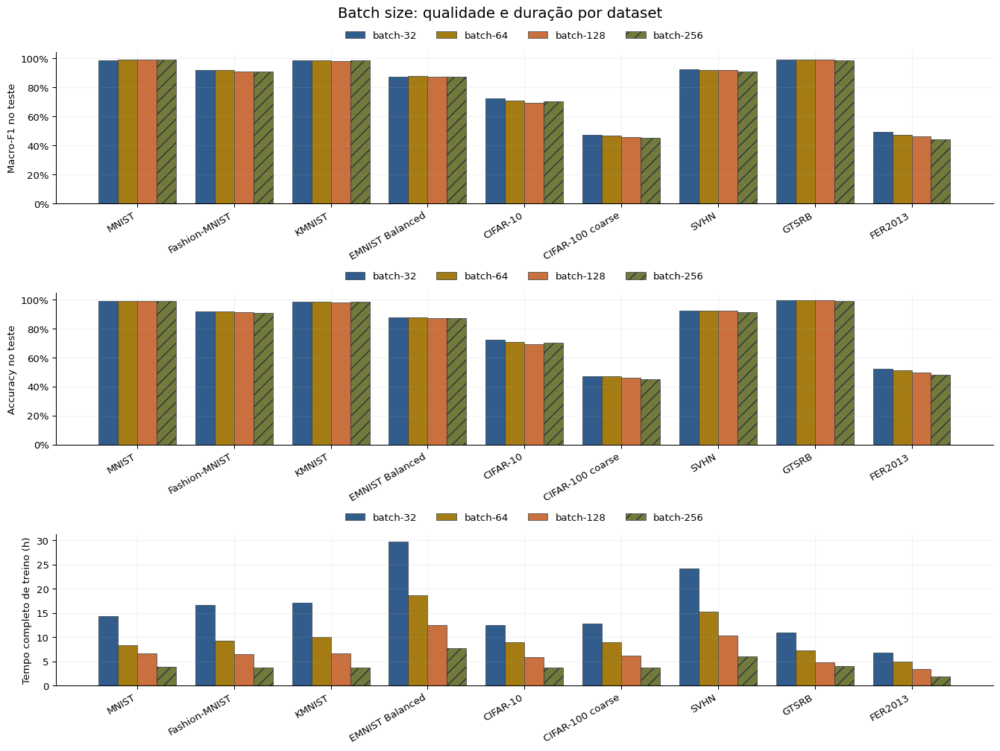

In [8]:
compare_grid('batch',[('test_macro_f1','Macro-F1 no teste',True),('test_accuracy','Accuracy no teste',True),('training_hours','Tempo completo de treino (h)',False)],'Batch size: qualidade e duração por dataset','batch_quality_time')

In [9]:
batch=main.loc[main.stage.eq('batch')]
batch_best=batch.loc[batch.groupby('dataset').test_macro_f1.idxmax()]
batch_fast=batch.loc[batch.groupby('dataset').training_seconds.idxmin(),['dataset','condition','training_hours']].rename(columns={'condition':'batch_mais_rapido','training_hours':'horas_mais_rapido'})
table(batch_best[['dataset','condition','test_macro_f1','test_accuracy','training_hours']].merge(batch_fast,on='dataset').sort_values('dataset'))
for _,r in batch_best.sort_values('dataset').iterrows():
    fast=batch_fast.loc[batch_fast.dataset.eq(r.dataset)].iloc[0]
    display(Markdown(f"**{LABELS[r.dataset]}:** {r.condition} obteve Macro-F1 {fmt(r.test_macro_f1,percent=True)} em {fmt(r.training_hours)} h; {fast.batch_mais_rapido} teve a menor duração total ({fmt(fast.horas_mais_rapido)} h). É uma troca observada entre qualidade e custo, sem estimativa de significância."))

dataset,condition,test_macro_f1,test_accuracy,training_hours,batch_mais_rapido,horas_mais_rapido
cifar10,batch-32,0.7235,0.7248,12.4116,batch-256,3.6619
cifar100_coarse,batch-32,0.4704,0.4704,12.7842,batch-256,3.7130
emnist_balanced,batch-64,0.8780,0.8794,18.6754,batch-256,7.7486
fashion_mnist,batch-32,0.9204,0.9206,16.6470,batch-256,3.7288
fer2013,batch-32,0.4947,0.5245,6.7756,batch-256,1.8763
gtsrb,batch-32,0.9933,0.9951,10.9390,batch-256,3.9951
kmnist,batch-32,0.9863,0.9863,17.1124,batch-256,3.7470
mnist,batch-64,0.9908,0.9909,8.2626,batch-256,3.8990
svhn,batch-32,0.9223,0.9259,24.0907,batch-256,6.0122


**CIFAR-10:** batch-32 obteve Macro-F1 72.35% em 12.41 h; batch-256 teve a menor duração total (3.66 h). É uma troca observada entre qualidade e custo, sem estimativa de significância.

**CIFAR-100 coarse:** batch-32 obteve Macro-F1 47.04% em 12.78 h; batch-256 teve a menor duração total (3.71 h). É uma troca observada entre qualidade e custo, sem estimativa de significância.

**EMNIST Balanced:** batch-64 obteve Macro-F1 87.80% em 18.68 h; batch-256 teve a menor duração total (7.75 h). É uma troca observada entre qualidade e custo, sem estimativa de significância.

**Fashion-MNIST:** batch-32 obteve Macro-F1 92.04% em 16.65 h; batch-256 teve a menor duração total (3.73 h). É uma troca observada entre qualidade e custo, sem estimativa de significância.

**FER2013:** batch-32 obteve Macro-F1 49.47% em 6.78 h; batch-256 teve a menor duração total (1.88 h). É uma troca observada entre qualidade e custo, sem estimativa de significância.

**GTSRB:** batch-32 obteve Macro-F1 99.33% em 10.94 h; batch-256 teve a menor duração total (4.00 h). É uma troca observada entre qualidade e custo, sem estimativa de significância.

**KMNIST:** batch-32 obteve Macro-F1 98.63% em 17.11 h; batch-256 teve a menor duração total (3.75 h). É uma troca observada entre qualidade e custo, sem estimativa de significância.

**MNIST:** batch-64 obteve Macro-F1 99.08% em 8.26 h; batch-256 teve a menor duração total (3.90 h). É uma troca observada entre qualidade e custo, sem estimativa de significância.

**SVHN:** batch-32 obteve Macro-F1 92.23% em 24.09 h; batch-256 teve a menor duração total (6.01 h). É uma troca observada entre qualidade e custo, sem estimativa de significância.

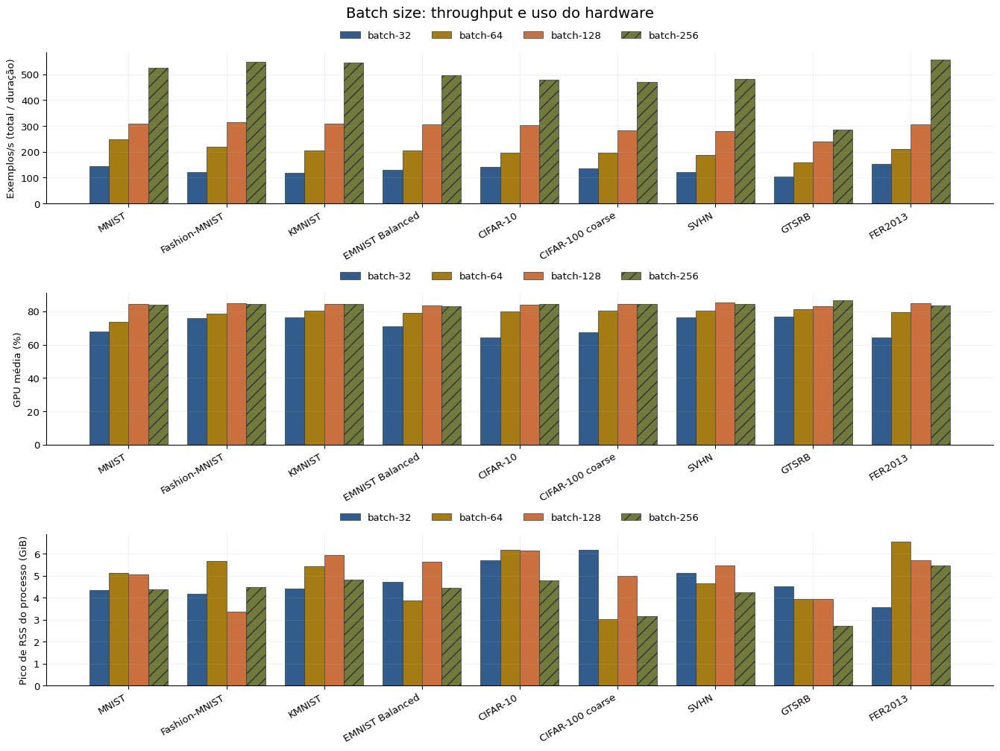

In [10]:
compare_grid('batch',[('train_examples_per_second','Exemplos/s (total / duração)',False),('gpu_mean_percent','GPU média (%)',False),('process_rss_max_gib','Pico de RSS do processo (GiB)',False)],'Batch size: throughput e uso do hardware','batch_hardware')

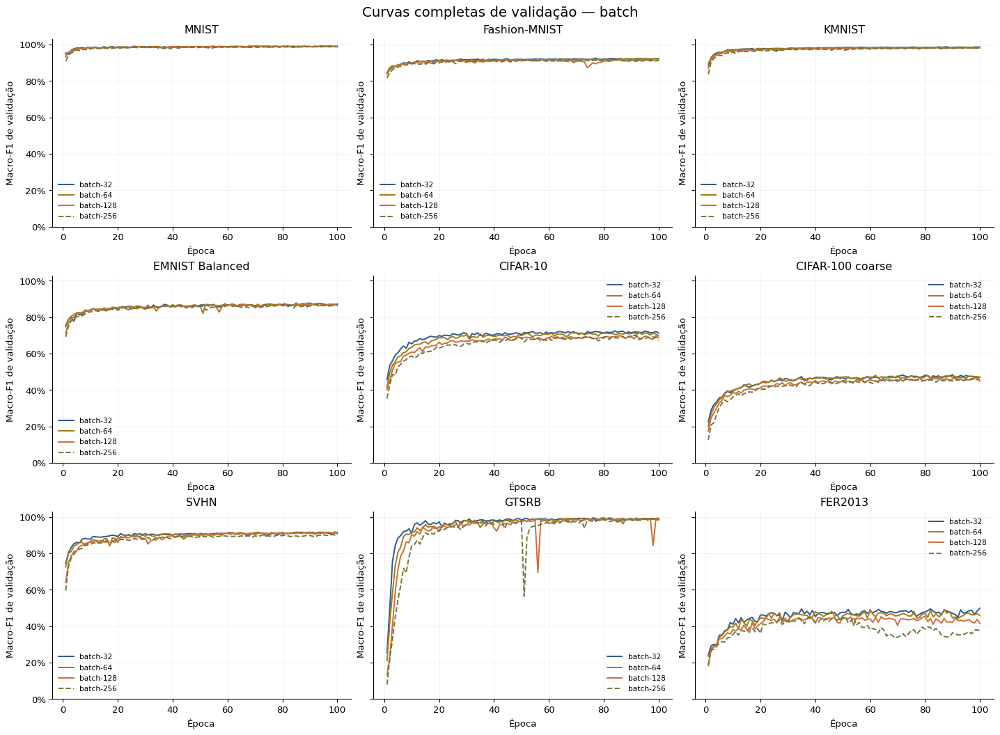

In [11]:
learning_grid('batch','batch_learning')

**Leitura das curvas:** batches menores e maiores alteram o número de atualizações por época e o custo observado. Oscilações e diferenças entre validação e teste devem ser lidas no mesmo dataset. Aumento de throughput por si só não estabelece melhora de Macro-F1. Os gráficos individuais adiante mostram loss, validação, custo e hardware de cada condição.

## Resultados de ativações ocultas

ReLU, Sigmoid e Softmax, com batch 256 e precisão mista. A saída do modelo continua em logits; a comparação altera as ativações internas. Os resumos de hardware são exportados; não há série bruta por segundo disponível localmente.

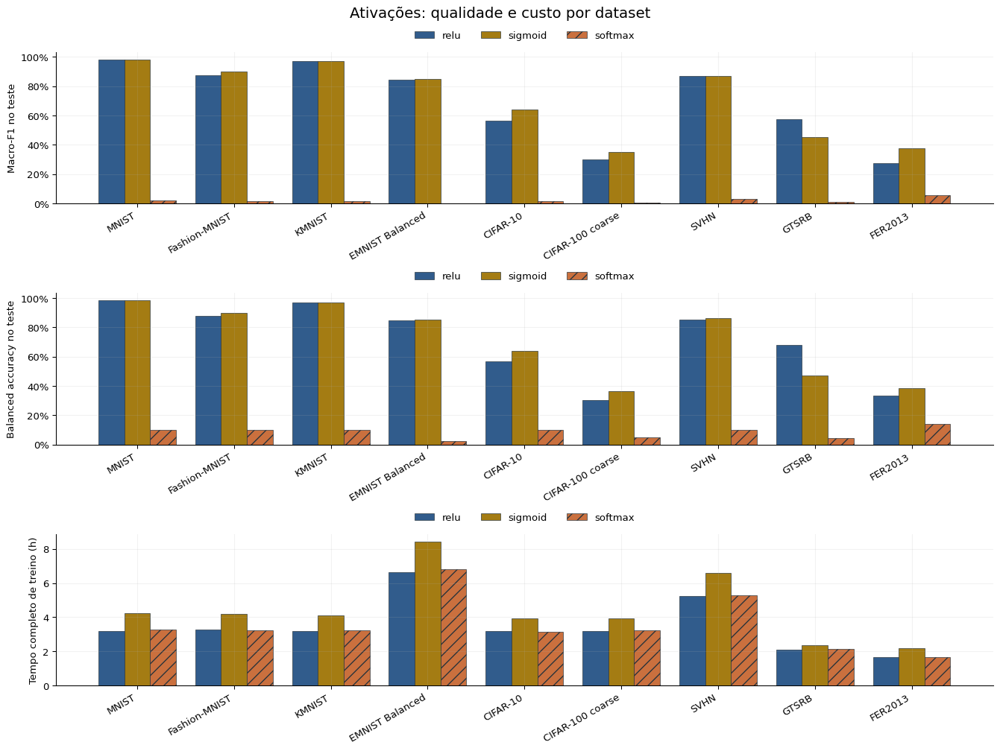

In [12]:
compare_grid('activations',[('test_macro_f1','Macro-F1 no teste',True),('test_balanced_accuracy','Balanced accuracy no teste',True),('training_hours','Tempo completo de treino (h)',False)],'Ativações: qualidade e custo por dataset','activation_quality_time')

In [13]:
acts=main.loc[main.stage.eq('activations')]
act_best=acts.loc[acts.groupby('dataset').test_macro_f1.idxmax()]
table(act_best[['dataset','condition','test_accuracy','test_macro_f1','training_hours']].sort_values('dataset'))
soft=acts.loc[acts.condition.eq('softmax')].copy()
soft['recall_uniforme_referencia']=1/soft.num_classes
table(soft[['dataset','num_classes','test_balanced_accuracy','recall_uniforme_referencia','test_macro_f1']])
display(Markdown(f"**Observado:** Sigmoid vence por Macro-F1 em {(act_best.condition=='sigmoid').sum()} datasets e ReLU em {(act_best.condition=='relu').sum()}. Softmax tem Macro-F1 entre {fmt(soft.test_macro_f1.min(),percent=True)} e {fmt(soft.test_macro_f1.max(),percent=True)}. A balanced accuracy próxima de 1/n_classes é compatível com predição concentrada em poucas classes. O uso alto de GPU nestes treinos mede atividade, não sucesso de aprendizagem. A explicação causal exigiria analisar logits/gradientes ou novas intervenções; os gráficos não demonstram a causa."))

dataset,condition,test_accuracy,test_macro_f1,training_hours
cifar10,sigmoid,0.6367,0.6390,3.9458
cifar100_coarse,sigmoid,0.3661,0.3502,3.9482
emnist_balanced,sigmoid,0.8528,0.8493,8.4390
fashion_mnist,sigmoid,0.9005,0.9004,4.1761
fer2013,sigmoid,0.4745,0.3754,2.1889
gtsrb,relu,0.6876,0.5775,2.0911
kmnist,sigmoid,0.9711,0.9711,4.1101
mnist,sigmoid,0.9846,0.9844,4.2328
svhn,sigmoid,0.8776,0.8707,6.5802


dataset,num_classes,test_balanced_accuracy,recall_uniforme_referencia,test_macro_f1
cifar10,10.0000,0.1000,0.1000,0.0182
cifar100_coarse,20.0000,0.0500,0.0500,0.0048
emnist_balanced,47.0000,0.0213,0.0213,0.0009
fashion_mnist,10.0000,0.1000,0.1000,0.0182
fer2013,7.0000,0.1429,0.1429,0.0572
gtsrb,43.0000,0.0457,0.0233,0.0096
kmnist,10.0000,0.1000,0.1000,0.0182
mnist,10.0000,0.1000,0.1000,0.0202
svhn,10.0000,0.1000,0.1000,0.0321


**Observado:** Sigmoid vence por Macro-F1 em 8 datasets e ReLU em 1. Softmax tem Macro-F1 entre 0.09% e 5.72%. A balanced accuracy próxima de 1/n_classes é compatível com predição concentrada em poucas classes. O uso alto de GPU nestes treinos mede atividade, não sucesso de aprendizagem. A explicação causal exigiria analisar logits/gradientes ou novas intervenções; os gráficos não demonstram a causa.

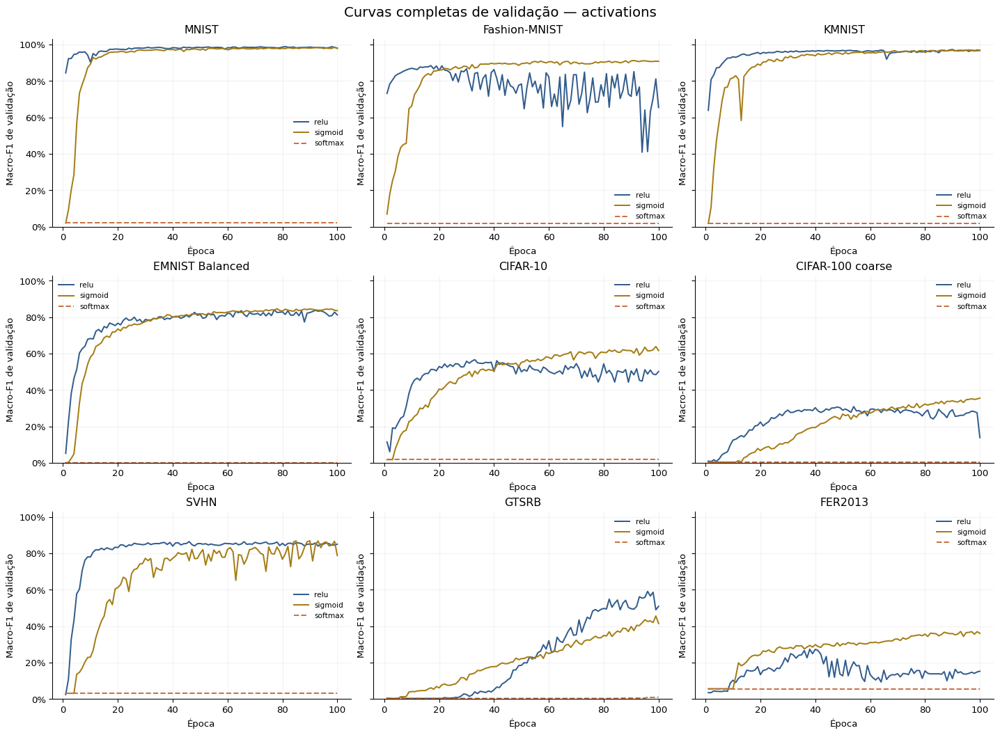

In [14]:
learning_grid('activations','activation_learning')

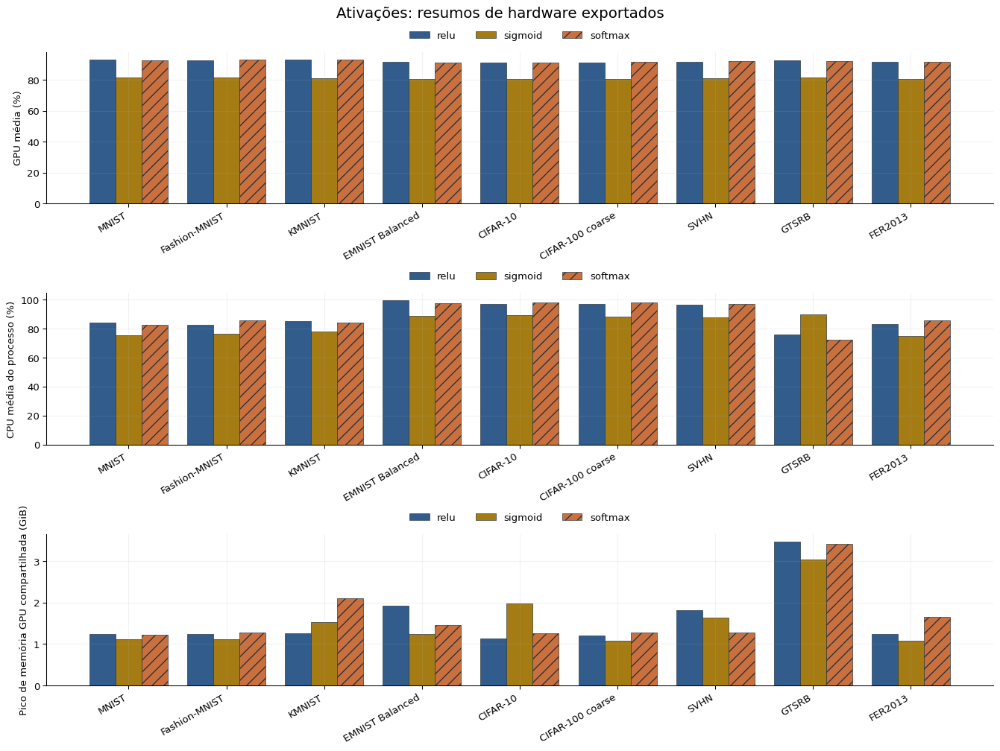

In [15]:
compare_grid('activations',[('gpu_mean_percent','GPU média (%)',False),('process_cpu_mean_percent','CPU média do processo (%)',False),('gpu_memory_max_gib','Pico de memória GPU compartilhada (GiB)',False)],'Ativações: resumos de hardware exportados','activation_hardware')

## FP32, FP16 misto e INT8 PTQ

FP16 aqui significa `mixed_float16`: computação intermediária float16, variáveis e saída em float32 conforme a implementação. Não é um modelo com todos os parâmetros armazenados em 16 bits. FP32 e FP16 são 18 treinos do zero. INT8 PTQ é uma avaliação após conversão LiteRT, vinculada à mesma campanha de augmentation 0,5.

O snapshot PTQ contém tamanho do modelo e métricas de inferência, mas não preserva todos os detalhes do dispositivo/delegate, warmup, calibração, threads ou modelo FP32 exportado equivalente. Portanto, comparar qualidade do PTQ com FP32 é uma descrição dos registros; latência PTQ não é speedup de treinamento nem demonstra vantagem sobre Metal.

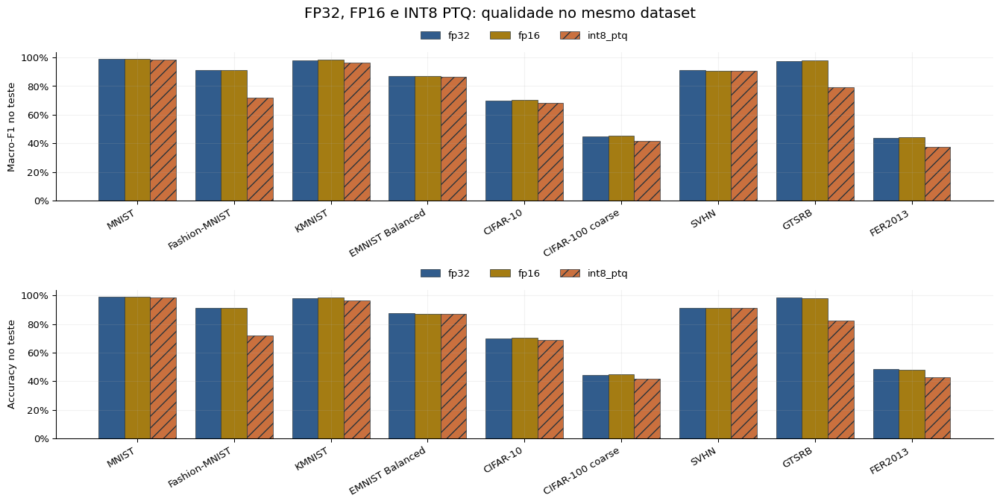

In [16]:
compare_grid('quantization_ptq',[('test_macro_f1','Macro-F1 no teste',True),('test_accuracy','Accuracy no teste',True)],'FP32, FP16 e INT8 PTQ: qualidade no mesmo dataset','quantization_quality')

In [17]:
quant=main.loc[main.stage.eq('quantization')]
paired=quant.loc[quant.condition.eq('fp16'),['dataset','test_macro_f1','training_seconds','train_examples_per_second','process_rss_max_gib']].merge(
    quant.loc[quant.condition.eq('fp32'),['dataset','test_macro_f1','training_seconds','train_examples_per_second','process_rss_max_gib']],on='dataset',suffixes=('_fp16','_fp32'))
paired['delta_f1_fp16_pp']=(paired.test_macro_f1_fp16-paired.test_macro_f1_fp32)*100
paired['razao_tempo_fp16_fp32']=paired.training_seconds_fp16/paired.training_seconds_fp32
table(paired[['dataset','test_macro_f1_fp16','test_macro_f1_fp32','delta_f1_fp16_pp','razao_tempo_fp16_fp32']])
for _,r in paired.iterrows():
    display(Markdown(f"**{LABELS[r.dataset]}:** FP16 altera o Macro-F1 em {r.delta_f1_fp16_pp:+.3f} p.p. versus FP32 e usa {r.razao_tempo_fp16_fp32:.2f}× o tempo completo registrado. Razão maior que 1 significa FP16 mais lento nesta execução; isso não implica o mesmo comportamento em outro hardware ou protocolo."))

dataset,test_macro_f1_fp16,test_macro_f1_fp32,delta_f1_fp16_pp,razao_tempo_fp16_fp32
cifar10,0.7018,0.6978,0.4046,1.6055
cifar100_coarse,0.4526,0.4463,0.6308,1.6019
emnist_balanced,0.8701,0.8714,-0.1318,1.6204
fashion_mnist,0.9097,0.9095,0.0259,1.6984
fer2013,0.4414,0.4368,0.4558,1.7216
gtsrb,0.9803,0.9762,0.4083,1.2528
kmnist,0.9846,0.9819,0.2655,1.6920
mnist,0.9882,0.9894,-0.1192,1.6701
svhn,0.9064,0.9095,-0.3094,1.4151


**CIFAR-10:** FP16 altera o Macro-F1 em +0.405 p.p. versus FP32 e usa 1.61× o tempo completo registrado. Razão maior que 1 significa FP16 mais lento nesta execução; isso não implica o mesmo comportamento em outro hardware ou protocolo.

**CIFAR-100 coarse:** FP16 altera o Macro-F1 em +0.631 p.p. versus FP32 e usa 1.60× o tempo completo registrado. Razão maior que 1 significa FP16 mais lento nesta execução; isso não implica o mesmo comportamento em outro hardware ou protocolo.

**EMNIST Balanced:** FP16 altera o Macro-F1 em -0.132 p.p. versus FP32 e usa 1.62× o tempo completo registrado. Razão maior que 1 significa FP16 mais lento nesta execução; isso não implica o mesmo comportamento em outro hardware ou protocolo.

**Fashion-MNIST:** FP16 altera o Macro-F1 em +0.026 p.p. versus FP32 e usa 1.70× o tempo completo registrado. Razão maior que 1 significa FP16 mais lento nesta execução; isso não implica o mesmo comportamento em outro hardware ou protocolo.

**FER2013:** FP16 altera o Macro-F1 em +0.456 p.p. versus FP32 e usa 1.72× o tempo completo registrado. Razão maior que 1 significa FP16 mais lento nesta execução; isso não implica o mesmo comportamento em outro hardware ou protocolo.

**GTSRB:** FP16 altera o Macro-F1 em +0.408 p.p. versus FP32 e usa 1.25× o tempo completo registrado. Razão maior que 1 significa FP16 mais lento nesta execução; isso não implica o mesmo comportamento em outro hardware ou protocolo.

**KMNIST:** FP16 altera o Macro-F1 em +0.265 p.p. versus FP32 e usa 1.69× o tempo completo registrado. Razão maior que 1 significa FP16 mais lento nesta execução; isso não implica o mesmo comportamento em outro hardware ou protocolo.

**MNIST:** FP16 altera o Macro-F1 em -0.119 p.p. versus FP32 e usa 1.67× o tempo completo registrado. Razão maior que 1 significa FP16 mais lento nesta execução; isso não implica o mesmo comportamento em outro hardware ou protocolo.

**SVHN:** FP16 altera o Macro-F1 em -0.309 p.p. versus FP32 e usa 1.42× o tempo completo registrado. Razão maior que 1 significa FP16 mais lento nesta execução; isso não implica o mesmo comportamento em outro hardware ou protocolo.

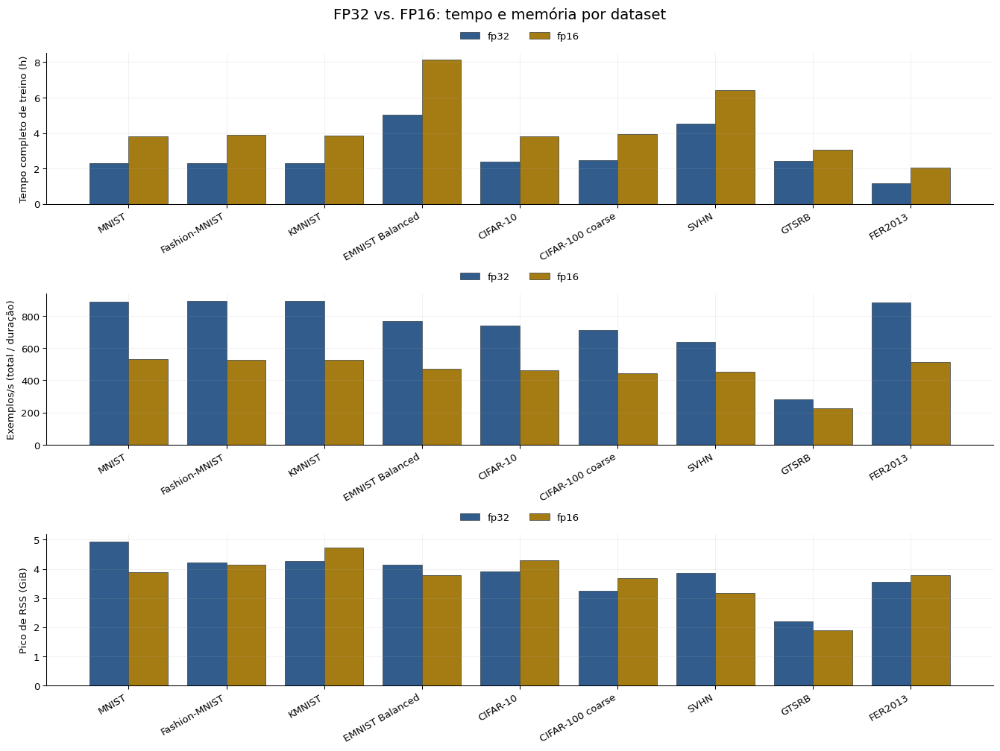

In [18]:
compare_grid('quantization',[('training_hours','Tempo completo de treino (h)',False),('train_examples_per_second','Exemplos/s (total / duração)',False),('process_rss_max_gib','Pico de RSS (GiB)',False)],'FP32 vs. FP16: tempo e memória por dataset','quantization_cost')

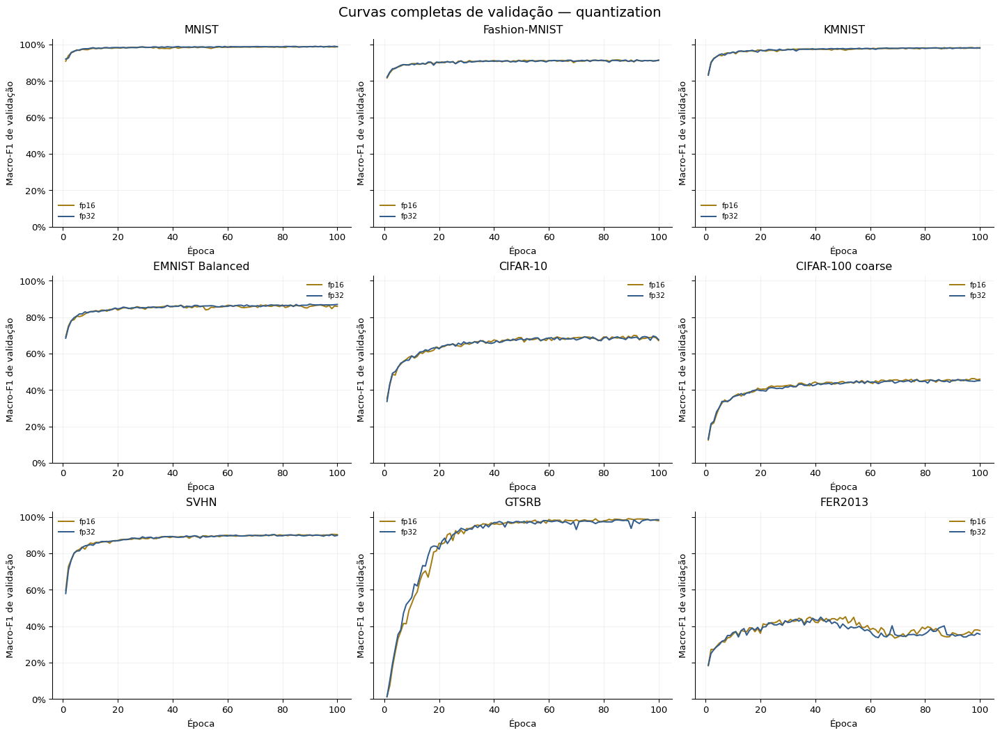

In [19]:
learning_grid('quantization','quantization_learning')

dataset,test_accuracy,test_macro_f1,ptq_batch_size,ptq_median_batch_latency_ms,ptq_p95_pass_seconds,ptq_throughput_examples_per_second,modelo_KiB
cifar10,0.6873,0.6844,256.0000,595.9387,21.3440,429.1665,302.9688
cifar100_coarse,0.4157,0.4150,256.0000,611.8766,21.7343,420.7206,305.7422
emnist_balanced,0.8691,0.8672,256.0000,616.9006,47.9575,414.9896,313.0625
fashion_mnist,0.7201,0.7180,256.0000,615.4632,25.6347,416.2078,302.8047
fer2013,0.4288,0.3781,256.0000,540.1898,11.3722,473.8475,301.9688
gtsrb,0.8216,0.7919,256.0000,2114.3019,27.7136,120.9243,312.1172
kmnist,0.9654,0.9655,256.0000,617.6719,25.6250,414.9461,302.8047
mnist,0.9834,0.9832,256.0000,612.5689,25.5295,417.8336,302.8047
svhn,0.9098,0.9047,256.0000,637.8801,37.5505,400.7119,302.9688


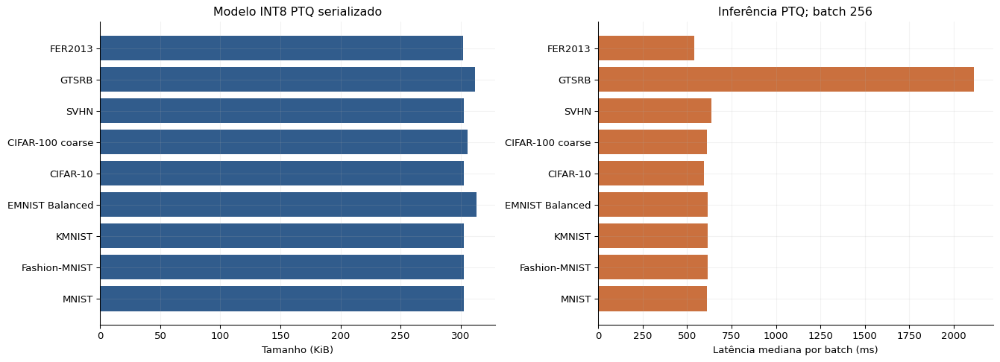

Tamanho refere-se ao arquivo serializado INT8, não ao RSS. Latência mediana é por batch; p95_pass_seconds é por passagem de avaliação, conforme o campo exportado. São denominadores diferentes. Sem referência de inferência FP32 equivalente não se calcula redução de tamanho ou speedup.

In [20]:
ptq_table=ptq[['dataset','test_accuracy','test_macro_f1','ptq_model_bytes','ptq_batch_size','ptq_median_batch_latency_ms','ptq_p95_pass_seconds','ptq_throughput_examples_per_second']].copy()
ptq_table['modelo_KiB']=ptq_table.ptq_model_bytes/1024
table(ptq_table.drop(columns='ptq_model_bytes').sort_values('dataset'))
fig,axes=plt.subplots(1,2,figsize=(14,5),layout='constrained')
ordered=ptq.set_index('dataset').reindex(ORDER)
axes[0].barh([LABELS[d] for d in ORDER],ordered.ptq_model_bytes/1024,color='#315C8C')
axes[0].set(xlabel='Tamanho (KiB)',title='Modelo INT8 PTQ serializado')
axes[1].barh([LABELS[d] for d in ORDER],ordered.ptq_median_batch_latency_ms,color='#CA703E')
axes[1].set(xlabel='Latência mediana por batch (ms)',title='Inferência PTQ; batch 256')
show(fig,'ptq_size_latency')
display(Markdown('Tamanho refere-se ao arquivo serializado INT8, não ao RSS. Latência mediana é por batch; p95_pass_seconds é por passagem de avaliação, conforme o campo exportado. São denominadores diferentes. Sem referência de inferência FP32 equivalente não se calcula redução de tamanho ou speedup.'))

## Hardware: comparação e cobertura por treinamento

Médias e p95 não representam consumo de energia. Não calcular uma média global de percentuais de campanhas com amostragem e escopo distintos. O ponto no gráfico representa uma execução, não uma relação causal entre utilização e qualidade.

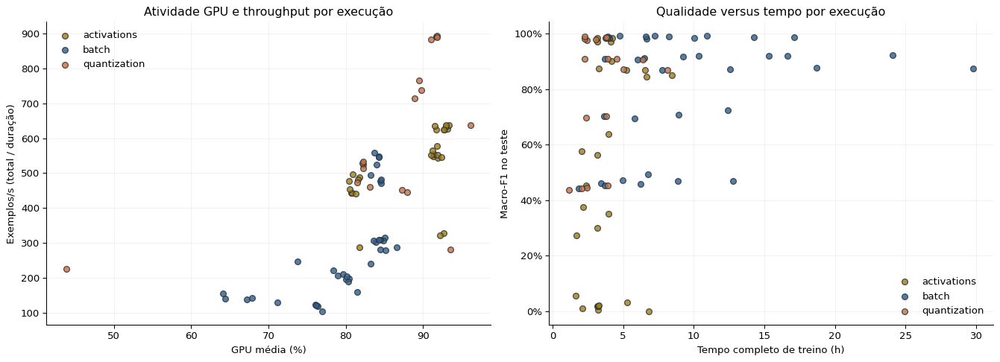

### Estatísticas completas — batch

dataset,condition,gpu_mean_percent,gpu_p95_percent,gpu_max_percent,cpu_mean_percent,process_cpu_mean_percent,ram_mean_percent,ram_max_percent,process_rss_max_gib,gpu_memory_max_gib,thermal_pressure
cifar10,batch-128,83.9420,90.0000,100.0000,16.2689,84.1436,61.4950,74.5000,6.1551,0.7959,nominal
cifar10,batch-256,84.4756,91.0000,100.0000,17.5088,93.5759,63.1670,71.1000,4.7720,1.1573,nominal
cifar10,batch-32,64.4206,81.0000,94.0000,20.5559,100.6424,76.5710,83.2000,5.7039,1.4185,nominal
cifar10,batch-64,80.0024,86.0000,100.0000,17.1114,84.0208,69.7709,83.1000,6.1760,0.7099,nominal
cifar100_coarse,batch-128,84.5281,90.0000,100.0000,17.4617,78.9931,64.8362,75.1000,4.9962,0.8559,nominal
cifar100_coarse,batch-256,84.6250,91.0000,100.0000,16.7267,92.2296,76.5639,80.4000,3.1545,1.5974,nominal
cifar100_coarse,batch-32,67.2384,82.0000,96.0000,21.3821,98.0732,70.4586,83.6000,6.1646,1.2447,nominal
cifar100_coarse,batch-64,80.3915,86.0000,95.0000,18.8805,83.9104,80.2550,88.3000,3.0307,2.3975,nominal
emnist_balanced,batch-128,83.6239,89.0000,100.0000,16.2250,83.8090,71.1695,84.2000,5.6351,2.3340,nominal
emnist_balanced,batch-256,83.2393,88.0000,100.0000,15.1227,94.3308,69.4955,78.5000,4.4296,1.4040,nominal


### Estatísticas completas — activations

dataset,condition,gpu_mean_percent,gpu_p95_percent,gpu_max_percent,cpu_mean_percent,process_cpu_mean_percent,ram_mean_percent,ram_max_percent,process_rss_max_gib,gpu_memory_max_gib,thermal_pressure
cifar10,relu,91.3300,97.0000,100.0000,19.8821,96.8564,75.4359,79.1000,3.7493,1.1376,nominal
cifar10,sigmoid,80.7342,87.0000,100.0000,18.6169,89.0183,75.2482,82.8000,3.7280,1.9795,nominal
cifar10,softmax,91.4571,96.0000,100.0000,18.3663,98.0045,74.2956,77.7000,3.7891,1.2657,nominal
cifar100_coarse,relu,91.0332,96.0000,100.0000,18.1437,97.0680,73.9258,77.9000,3.6971,1.2071,nominal
cifar100_coarse,sigmoid,80.8204,87.0000,100.0000,15.1255,88.0166,73.4025,80.0000,4.3220,1.0756,nominal
cifar100_coarse,softmax,91.8656,96.0000,100.0000,18.1918,97.9889,73.2905,76.2000,3.9719,1.2812,nominal
emnist_balanced,relu,91.8197,96.0000,100.0000,19.3924,99.5108,75.2040,84.9000,3.2279,1.9210,nominal
emnist_balanced,sigmoid,80.5233,86.0000,100.0000,16.6330,88.6518,77.0433,80.1000,3.5716,1.2369,nominal
emnist_balanced,softmax,91.2829,96.0000,100.0000,18.5211,97.3350,76.5273,80.2000,3.6605,1.4587,nominal
fashion_mnist,relu,92.7975,97.0000,100.0000,20.2137,82.5976,74.3422,78.8000,4.1115,1.2495,nominal


### Estatísticas completas — quantization

dataset,condition,gpu_mean_percent,gpu_p95_percent,gpu_max_percent,cpu_mean_percent,process_cpu_mean_percent,ram_mean_percent,ram_max_percent,process_rss_max_gib,gpu_memory_max_gib,thermal_pressure
cifar10,fp16,83.1388,90.0000,100.0000,14.6385,94.3217,69.9964,74.1000,4.2931,1.1791,nominal
cifar10,fp32,89.8150,95.0000,100.0000,19.8003,110.4169,72.2276,79.1000,3.8992,1.6939,nominal
cifar100_coarse,fp16,87.9741,94.0000,100.0000,30.3560,96.5021,79.2064,84.4000,3.6799,2.0742,nominal
cifar100_coarse,fp32,88.9571,95.0000,100.0000,30.5205,112.5529,70.7687,79.4000,3.2385,1.3804,nominal
emnist_balanced,fp16,81.4827,88.0000,100.0000,18.6058,95.6526,72.2876,74.6000,3.7890,1.7864,nominal
emnist_balanced,fp32,89.4589,95.0000,100.0000,28.8954,109.2055,73.4403,80.1000,4.1326,1.4425,nominal
fashion_mnist,fp16,82.2484,87.0000,95.0000,14.7175,84.2210,70.8716,74.8000,4.1310,1.1522,nominal
fashion_mnist,fp32,91.6904,95.0000,100.0000,16.1500,92.0795,70.5310,74.0000,4.2147,1.1511,nominal
fer2013,fp16,82.2747,88.0000,100.0000,17.8320,84.3784,67.9211,79.6000,3.7891,1.9712,nominal
fer2013,fp32,91.0296,95.0000,100.0000,20.3996,91.8819,63.8552,74.2000,3.5615,1.7887,nominal


Há séries temporais locais para os 36 treinos de batch e os nove smoke tests. Para os 45 treinos de ativações/precisão há resumos exportados. Para PTQ não há telemetria de treinamento, pois a operação é uma conversão/avaliação.

In [21]:
fig,axes=plt.subplots(1,2,figsize=(14,5),layout='constrained')
stage_colors={'batch':'#315C8C','activations':'#A47C13','quantization':'#CA703E'}
for stage,g in main.groupby('stage'):
    axes[0].scatter(g.gpu_mean_percent,g.train_examples_per_second,color=stage_colors[stage],label=stage,alpha=.8,edgecolor='#25323B',s=35)
    axes[1].scatter(g.training_hours,g.test_macro_f1,color=stage_colors[stage],label=stage,alpha=.8,edgecolor='#25323B',s=35)
axes[0].set(xlabel='GPU média (%)',ylabel='Exemplos/s (total / duração)',title='Atividade GPU e throughput por execução')
axes[1].set(xlabel='Tempo completo de treino (h)',ylabel='Macro-F1 no teste',title='Qualidade versus tempo por execução')
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
for ax in axes: ax.legend(frameon=False)
show(fig,'hardware_tradeoffs')
hardware_cols=['dataset','condition','gpu_mean_percent','gpu_p95_percent','gpu_max_percent','cpu_mean_percent','process_cpu_mean_percent','ram_mean_percent','ram_max_percent','process_rss_max_gib','gpu_memory_max_gib','thermal_pressure']
for stage in ['batch','activations','quantization']:
    display(Markdown('### Estatísticas completas — '+stage))
    table(main.loc[main.stage.eq(stage)].sort_values(['dataset','condition']),hardware_cols)
display(Markdown('Há séries temporais locais para os 36 treinos de batch e os nove smoke tests. Para os 45 treinos de ativações/precisão há resumos exportados. Para PTQ não há telemetria de treinamento, pois a operação é uma conversão/avaliação.'))

## Catálogo individual: todos os 81 treinamentos principais

Cada execução tem uma ficha, métricas exatas e seis painéis: loss, aprendizado, teste, custo por época, CPU/GPU e memória. Para batch, hardware é mostrado ao longo do tempo; para campanhas com snapshot, apenas as estatísticas realmente disponíveis são desenhadas. As diferenças entre fontes e retomadas aparecem na interpretação de cada ficha.

### Fichas — batch

#### mnist · batch-32

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|mnist|batch-32`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/mnist/runs/mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

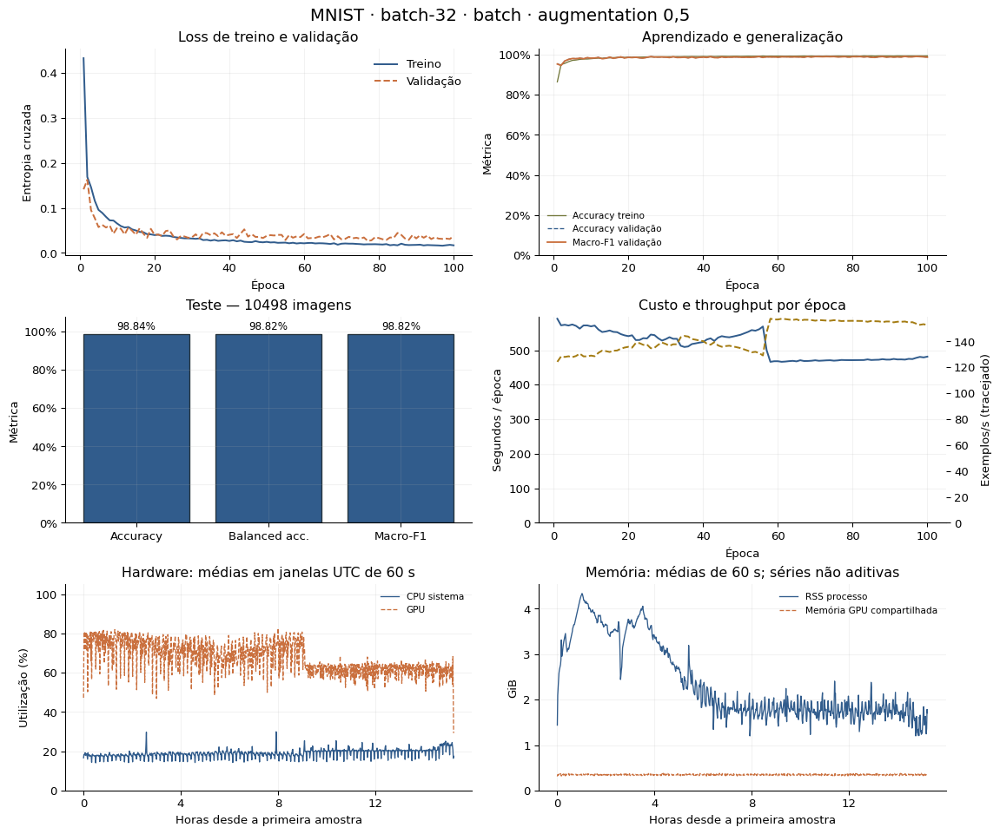

**Resultado:** accuracy 98.84%, balanced accuracy 98.82%, Macro-F1 98.82%, precisão macro 98.83%, recall macro 98.82%, AUC OVR 0.9998 e loss de teste 0.0484. **Custo:** 14.27 h pela soma das épocas; 143.12 exemplos/s, ponderando pelo tempo; avaliação final 53.26 s. **Curva:** melhor Macro-F1 de validação 99.22% na época 94; última época 98.82%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-64 teve o maior Macro-F1 (99.08%); esta condição ficou -0.257 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 67.94%, CPU do processo média 94.54%, RAM média 77.40%; pico de RSS 4.35 GiB e de memória GPU compartilhada 0.62 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 5, F1 97.73% e suporte 947 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [22]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|mnist|batch-32')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|mnist|batch-32')

#### mnist · batch-64

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|mnist|batch-64`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-064/mnist/runs/mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

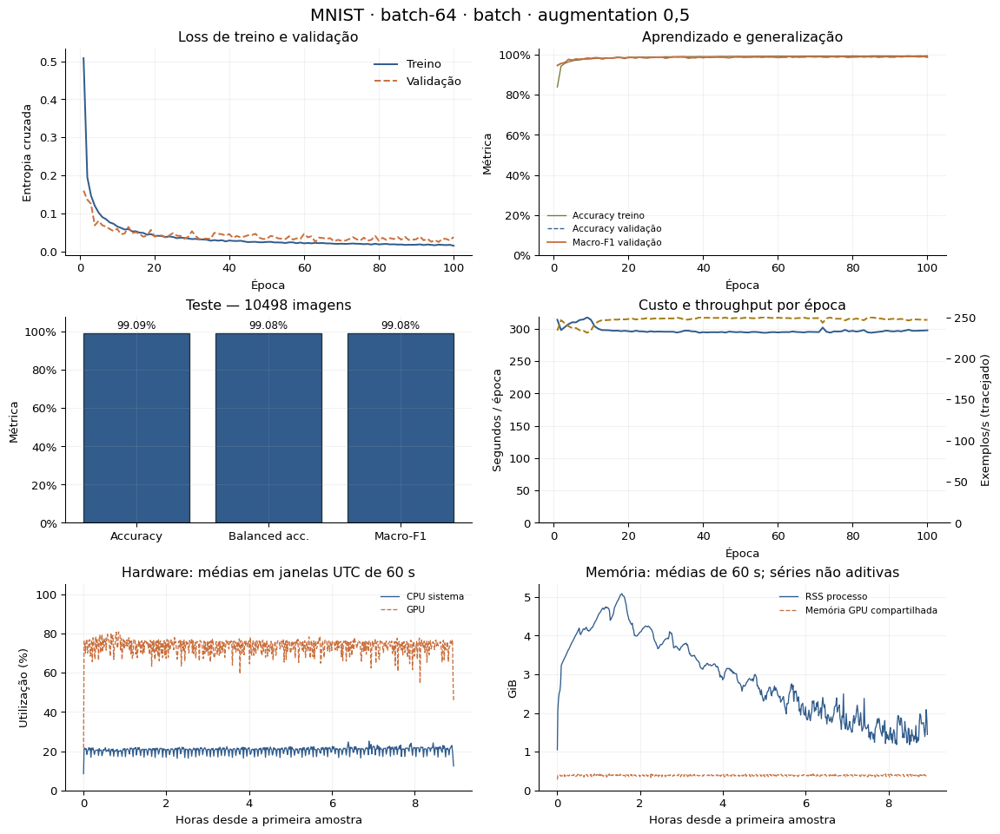

**Resultado:** accuracy 99.09%, balanced accuracy 99.08%, Macro-F1 99.08%, precisão macro 99.08%, recall macro 99.08%, AUC OVR 0.9998 e loss de teste 0.0326. **Custo:** 8.26 h pela soma das épocas; 247.09 exemplos/s, ponderando pelo tempo; avaliação final 40.44 s. **Curva:** melhor Macro-F1 de validação 99.18% na época 63; última época 98.83%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-64 teve o maior Macro-F1 (99.08%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 73.73%, CPU do processo média 92.26%, RAM média 71.39%; pico de RSS 5.11 GiB e de memória GPU compartilhada 0.70 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 2, F1 98.28% e suporte 1048 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [23]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|mnist|batch-64')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|mnist|batch-64')

#### mnist · batch-128

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|mnist|batch-128`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-128/mnist/runs/mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

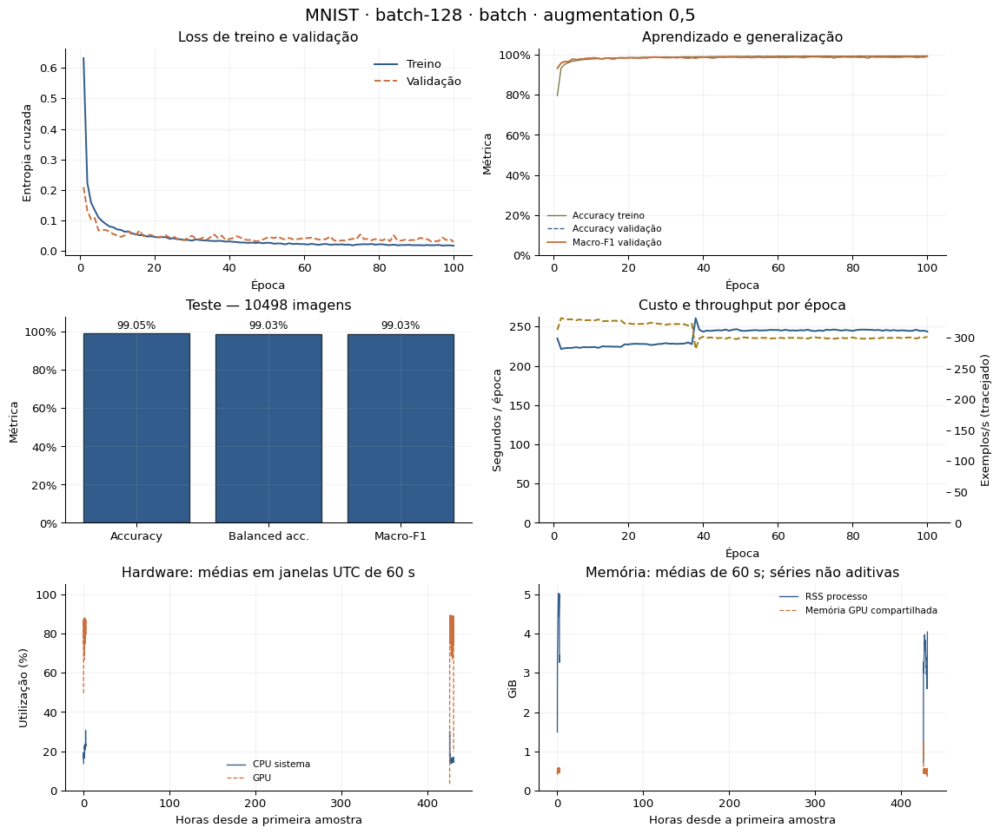

**Resultado:** accuracy 99.05%, balanced accuracy 99.03%, Macro-F1 99.03%, precisão macro 99.04%, recall macro 99.03%, AUC OVR 0.9998 e loss de teste 0.0343. **Custo:** 6.62 h pela soma das épocas; 308.40 exemplos/s, ponderando pelo tempo; avaliação final 31.37 s. **Curva:** melhor Macro-F1 de validação 99.22% na época 100; última época 99.22%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-64 teve o maior Macro-F1 (99.08%); esta condição ficou -0.044 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 84.29%, CPU do processo média 72.73%, RAM média 64.59%; pico de RSS 5.04 GiB e de memória GPU compartilhada 1.51 GiB. **Reconciliação:** resumo de treino 4.30 h versus soma das épocas 6.62 h; diferença 2.32 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 2, F1 98.24% e suporte 1048 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [24]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|mnist|batch-128')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|mnist|batch-128')

#### mnist · batch-256

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|mnist|batch-256`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-256/mnist/runs/mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

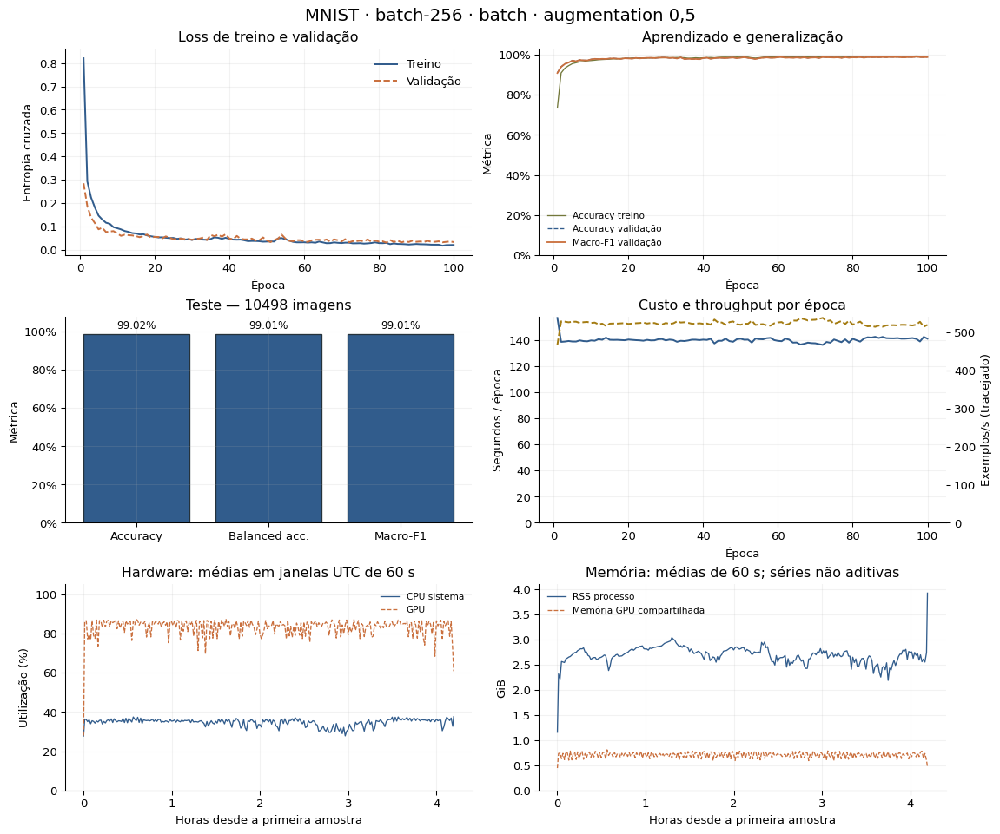

**Resultado:** accuracy 99.02%, balanced accuracy 99.01%, Macro-F1 99.01%, precisão macro 99.01%, recall macro 99.01%, AUC OVR 0.9998 e loss de teste 0.0352. **Custo:** 3.90 h pela soma das épocas; 523.63 exemplos/s, ponderando pelo tempo; avaliação final 22.33 s. **Curva:** melhor Macro-F1 de validação 99.08% na época 97; última época 98.88%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-64 teve o maior Macro-F1 (99.08%); esta condição ficou -0.072 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 84.01%, CPU do processo média 85.47%, RAM média 71.74%; pico de RSS 4.37 GiB e de memória GPU compartilhada 1.46 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 2, F1 98.36% e suporte 1048 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [25]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|mnist|batch-256')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|mnist|batch-256')

#### fashion_mnist · batch-32

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|fashion_mnist|batch-32`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/fashion_mnist/runs/fashion_mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

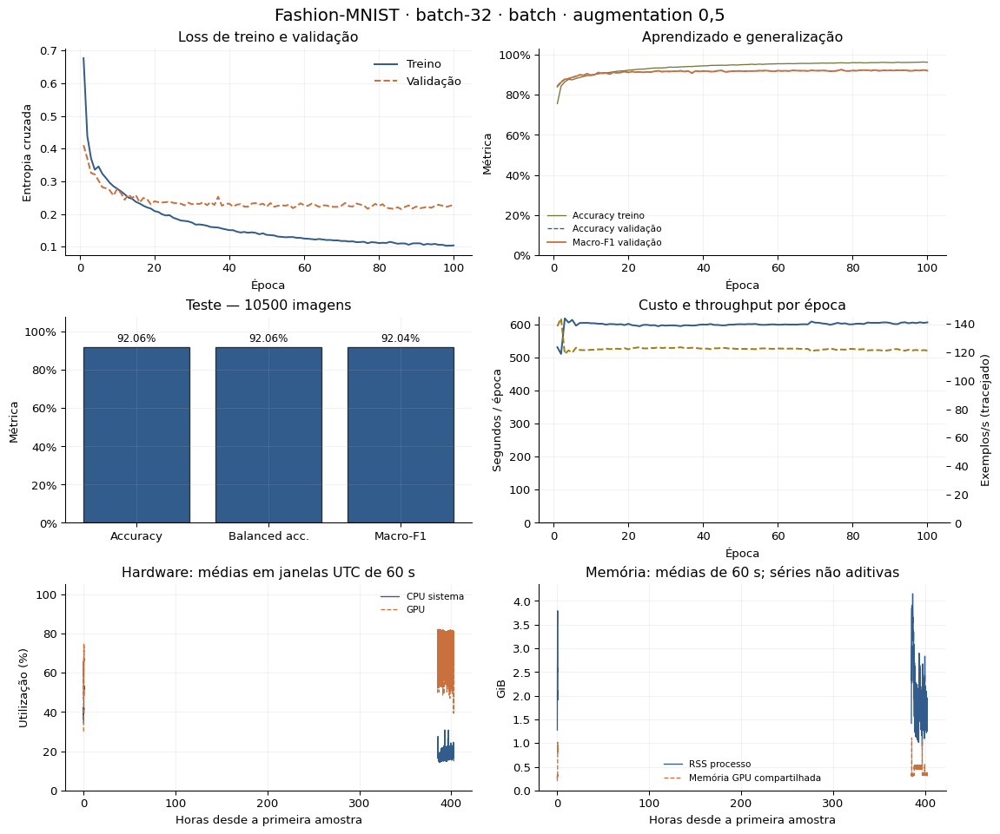

**Resultado:** accuracy 92.06%, balanced accuracy 92.06%, Macro-F1 92.04%, precisão macro 92.09%, recall macro 92.06%, AUC OVR 0.9951 e loss de teste 0.2312. **Custo:** 16.65 h pela soma das épocas; 122.64 exemplos/s, ponderando pelo tempo; avaliação final 58.20 s. **Curva:** melhor Macro-F1 de validação 92.60% na época 77; última época 92.07%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (92.04%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 76.12%, CPU do processo média 82.68%, RAM média 78.57%; pico de RSS 4.18 GiB e de memória GPU compartilhada 1.79 GiB. **Reconciliação:** resumo de treino 16.36 h versus soma das épocas 16.65 h; diferença 0.29 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 6, F1 77.41% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [26]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|fashion_mnist|batch-32')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|fashion_mnist|batch-32')

#### fashion_mnist · batch-64

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|fashion_mnist|batch-64`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-064/fashion_mnist/runs/fashion_mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

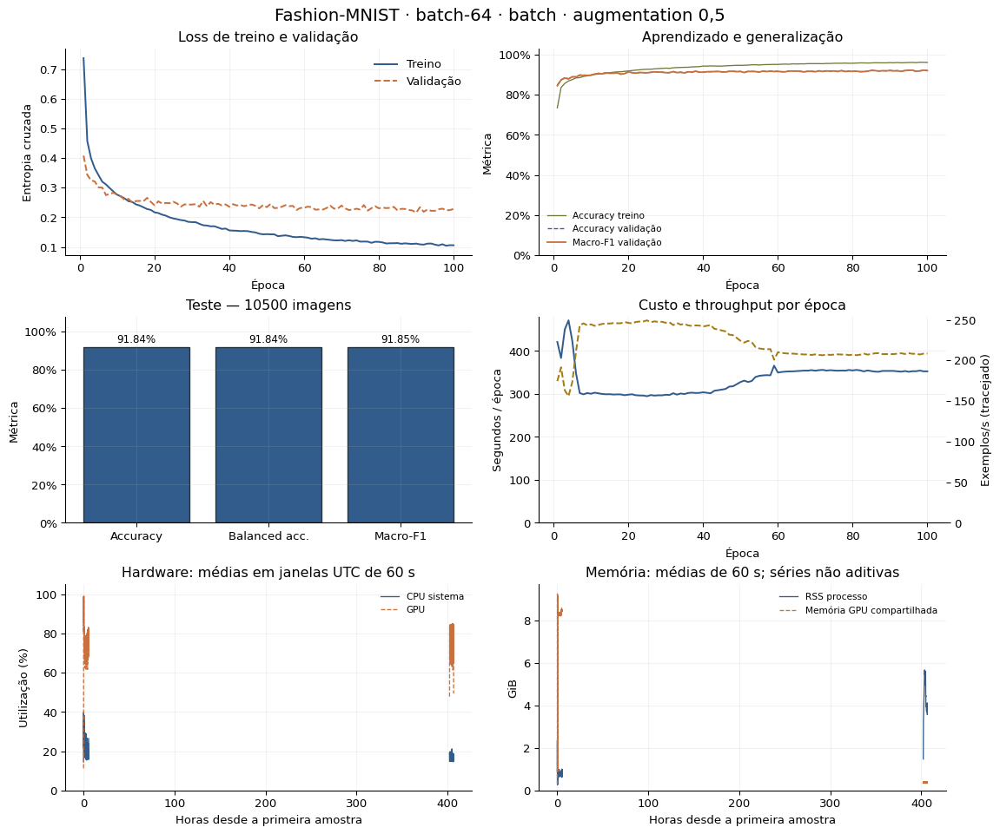

**Resultado:** accuracy 91.84%, balanced accuracy 91.84%, Macro-F1 91.85%, precisão macro 91.87%, recall macro 91.84%, AUC OVR 0.9951 e loss de teste 0.2368. **Custo:** 9.27 h pela soma das épocas; 220.27 exemplos/s, ponderando pelo tempo; avaliação final 45.27 s. **Curva:** melhor Macro-F1 de validação 92.32% na época 96; última época 92.12%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (92.04%); esta condição ficou -0.193 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 78.39%, CPU do processo média 82.53%, RAM média 79.21%; pico de RSS 5.68 GiB e de memória GPU compartilhada 9.50 GiB. **Reconciliação:** resumo de treino 4.13 h versus soma das épocas 9.27 h; diferença 5.14 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 6, F1 77.62% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [27]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|fashion_mnist|batch-64')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|fashion_mnist|batch-64')

#### fashion_mnist · batch-128

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|fashion_mnist|batch-128`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-128/fashion_mnist/runs/fashion_mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

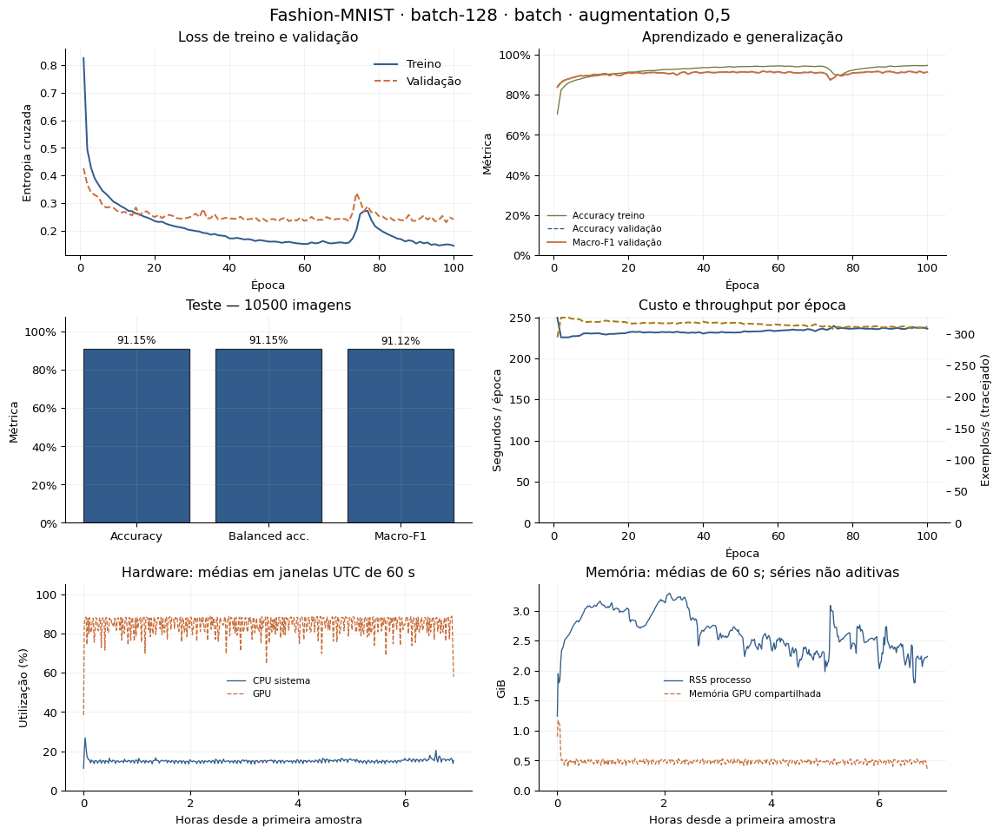

**Resultado:** accuracy 91.15%, balanced accuracy 91.15%, Macro-F1 91.12%, precisão macro 91.12%, recall macro 91.15%, AUC OVR 0.9944 e loss de teste 0.2469. **Custo:** 6.48 h pela soma das épocas; 315.12 exemplos/s, ponderando pelo tempo; avaliação final 29.62 s. **Curva:** melhor Macro-F1 de validação 91.87% na época 56; última época 91.39%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (92.04%); esta condição ficou -0.924 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 85.05%, CPU do processo média 72.32%, RAM média 74.29%; pico de RSS 3.36 GiB e de memória GPU compartilhada 1.32 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 6, F1 76.63% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [28]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|fashion_mnist|batch-128')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|fashion_mnist|batch-128')

#### fashion_mnist · batch-256

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|fashion_mnist|batch-256`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-256/fashion_mnist/runs/fashion_mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

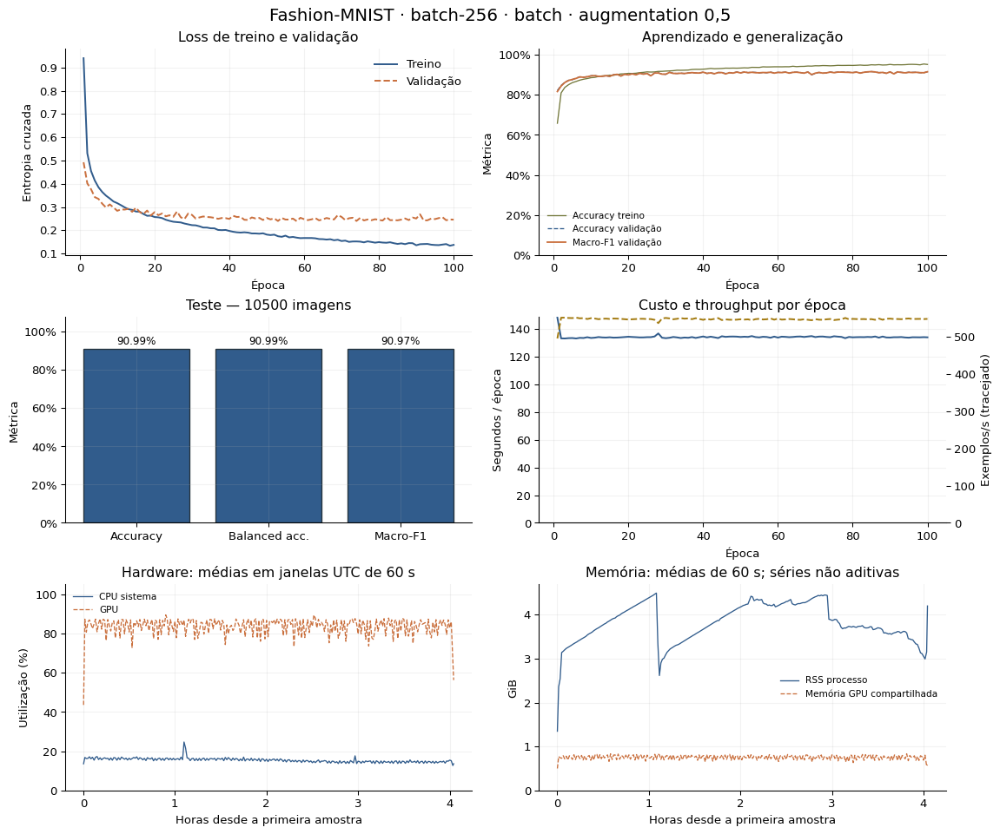

**Resultado:** accuracy 90.99%, balanced accuracy 90.99%, Macro-F1 90.97%, precisão macro 90.98%, recall macro 90.99%, AUC OVR 0.9942 e loss de teste 0.2537. **Custo:** 3.73 h pela soma das épocas; 547.54 exemplos/s, ponderando pelo tempo; avaliação final 21.86 s. **Curva:** melhor Macro-F1 de validação 91.61% na época 85; última época 91.55%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (92.04%); esta condição ficou -1.068 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 84.28%, CPU do processo média 81.88%, RAM média 68.81%; pico de RSS 4.49 GiB e de memória GPU compartilhada 1.10 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 6, F1 76.22% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [29]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|fashion_mnist|batch-256')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|fashion_mnist|batch-256')

#### kmnist · batch-32

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|kmnist|batch-32`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/kmnist/runs/kmnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

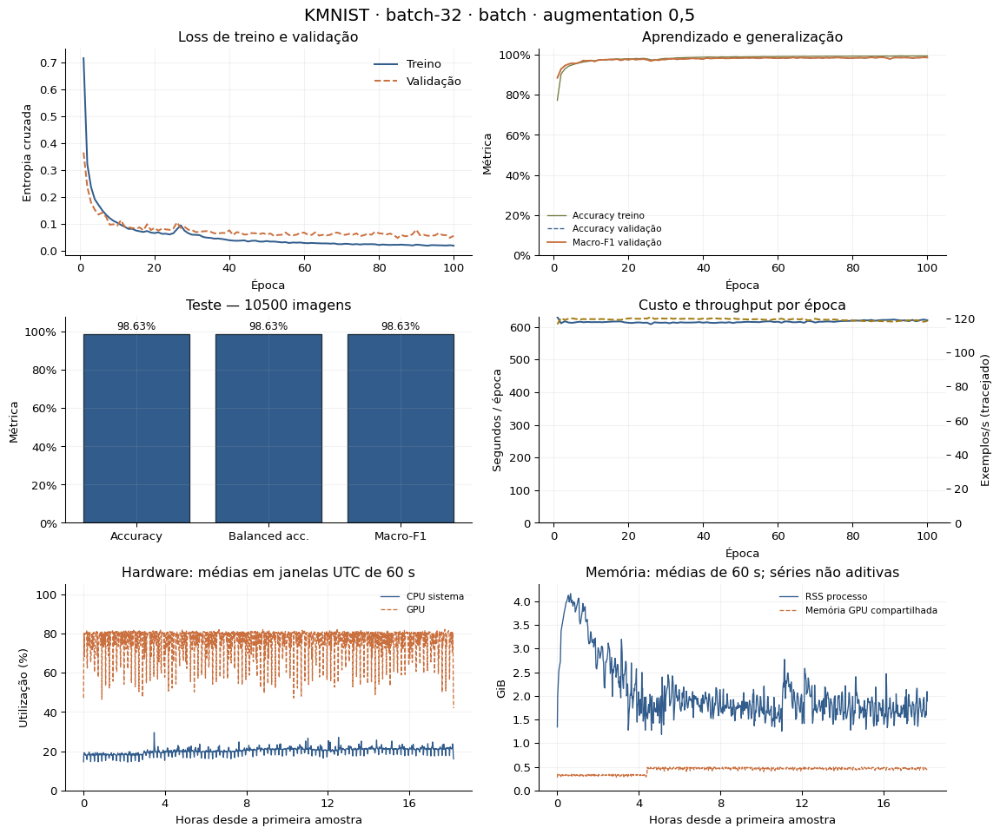

**Resultado:** accuracy 98.63%, balanced accuracy 98.63%, Macro-F1 98.63%, precisão macro 98.63%, recall macro 98.63%, AUC OVR 0.9998 e loss de teste 0.0576. **Custo:** 17.11 h pela soma das épocas; 119.31 exemplos/s, ponderando pelo tempo; avaliação final 56.05 s. **Curva:** melhor Macro-F1 de validação 98.78% na época 85; última época 98.62%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (98.63%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 76.37%, CPU do processo média 83.54%, RAM média 79.92%; pico de RSS 4.43 GiB e de memória GPU compartilhada 0.58 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 1, F1 97.72% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [30]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|kmnist|batch-32')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|kmnist|batch-32')

#### kmnist · batch-64

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|kmnist|batch-64`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-064/kmnist/runs/kmnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

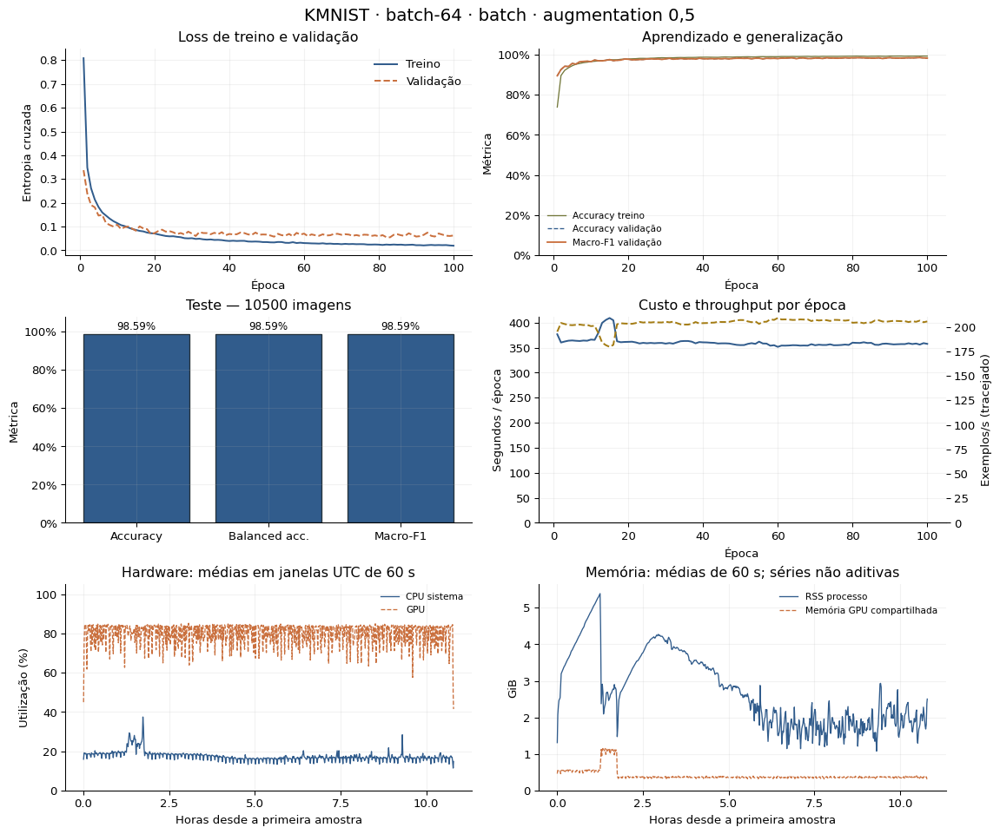

**Resultado:** accuracy 98.59%, balanced accuracy 98.59%, Macro-F1 98.59%, precisão macro 98.60%, recall macro 98.59%, AUC OVR 0.9998 e loss de teste 0.0590. **Custo:** 10.02 h pela soma das épocas; 203.70 exemplos/s, ponderando pelo tempo; avaliação final 44.62 s. **Curva:** melhor Macro-F1 de validação 98.64% na época 98; última época 98.36%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (98.63%); esta condição ficou -0.037 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 80.18%, CPU do processo média 77.53%, RAM média 72.85%; pico de RSS 5.42 GiB e de memória GPU compartilhada 1.96 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 2, F1 97.98% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [31]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|kmnist|batch-64')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|kmnist|batch-64')

#### kmnist · batch-128

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|kmnist|batch-128`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-128/kmnist/runs/kmnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

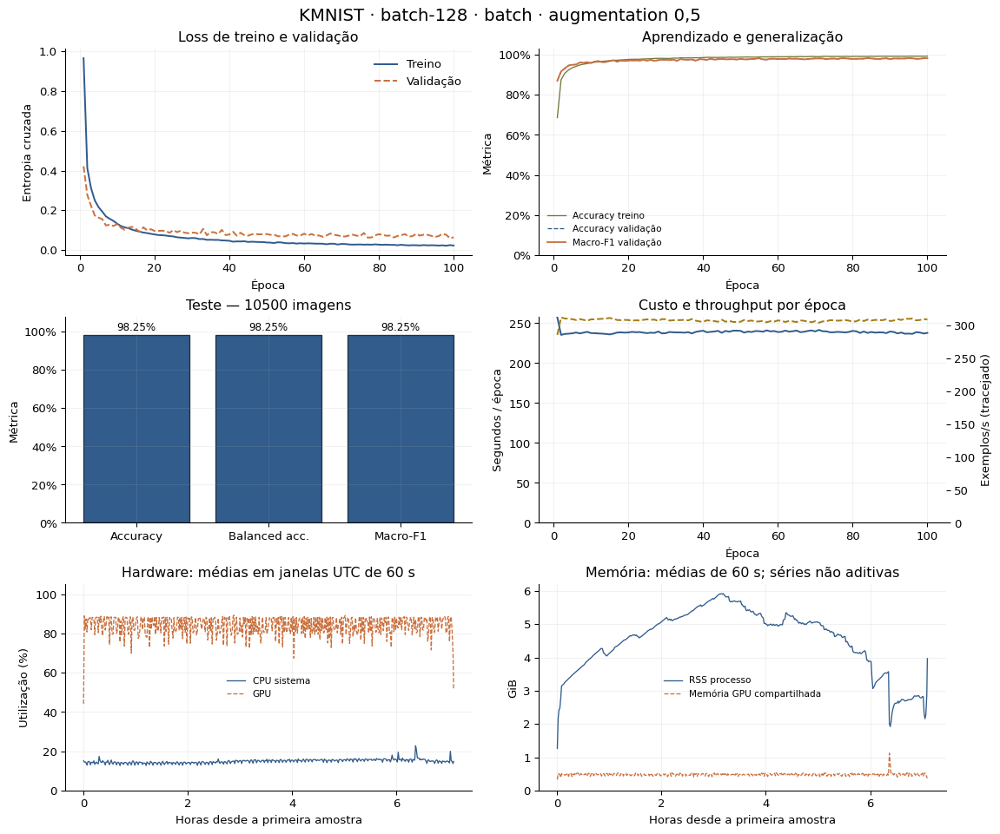

**Resultado:** accuracy 98.25%, balanced accuracy 98.25%, Macro-F1 98.25%, precisão macro 98.26%, recall macro 98.25%, AUC OVR 0.9996 e loss de teste 0.0753. **Custo:** 6.64 h pela soma das épocas; 307.56 exemplos/s, ponderando pelo tempo; avaliação final 31.22 s. **Curva:** melhor Macro-F1 de validação 98.41% na época 84; última época 98.28%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (98.63%); esta condição ficou -0.379 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 84.49%, CPU do processo média 70.92%, RAM média 63.54%; pico de RSS 5.94 GiB e de memória GPU compartilhada 1.42 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 6, F1 97.50% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [32]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|kmnist|batch-128')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|kmnist|batch-128')

#### kmnist · batch-256

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|kmnist|batch-256`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-256/kmnist/runs/kmnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

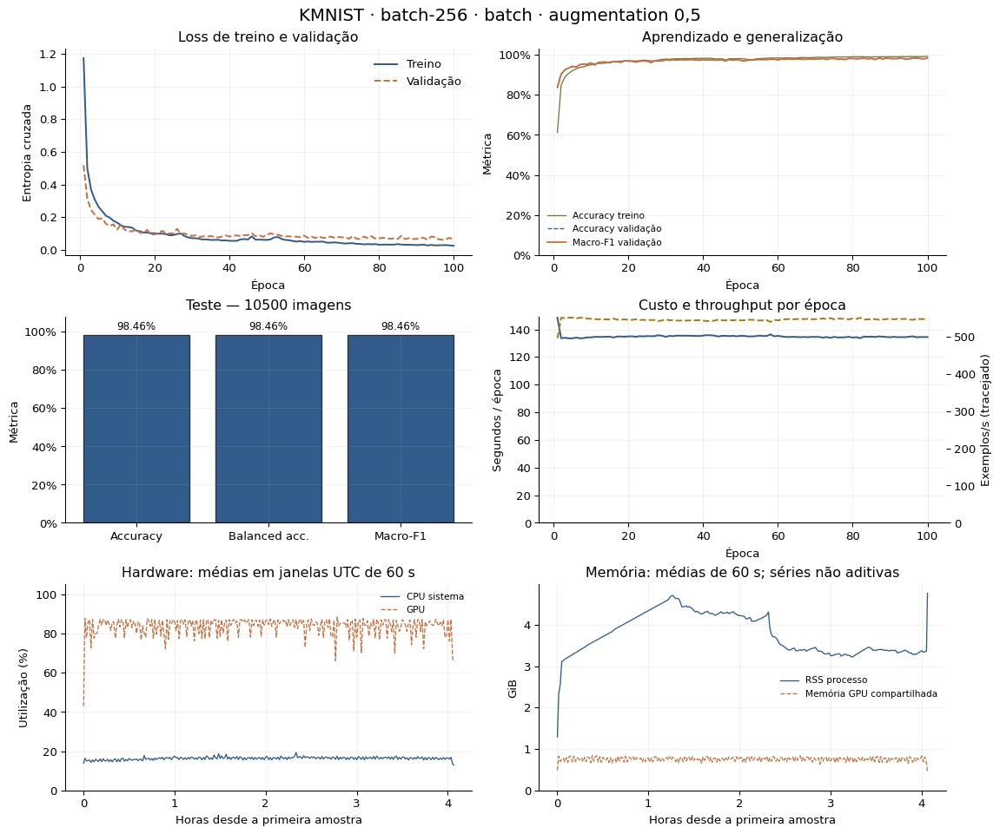

**Resultado:** accuracy 98.46%, balanced accuracy 98.46%, Macro-F1 98.46%, precisão macro 98.46%, recall macro 98.46%, AUC OVR 0.9997 e loss de teste 0.0606. **Custo:** 3.75 h pela soma das épocas; 544.87 exemplos/s, ponderando pelo tempo; avaliação final 21.69 s. **Curva:** melhor Macro-F1 de validação 98.42% na época 97; última época 98.35%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (98.63%); esta condição ficou -0.172 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 84.29%, CPU do processo média 81.12%, RAM média 65.12%; pico de RSS 4.81 GiB e de memória GPU compartilhada 1.12 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 6, F1 97.87% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [33]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|kmnist|batch-256')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|kmnist|batch-256')

#### emnist_balanced · batch-32

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|emnist_balanced|batch-32`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/emnist_balanced/runs/emnist_balanced__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

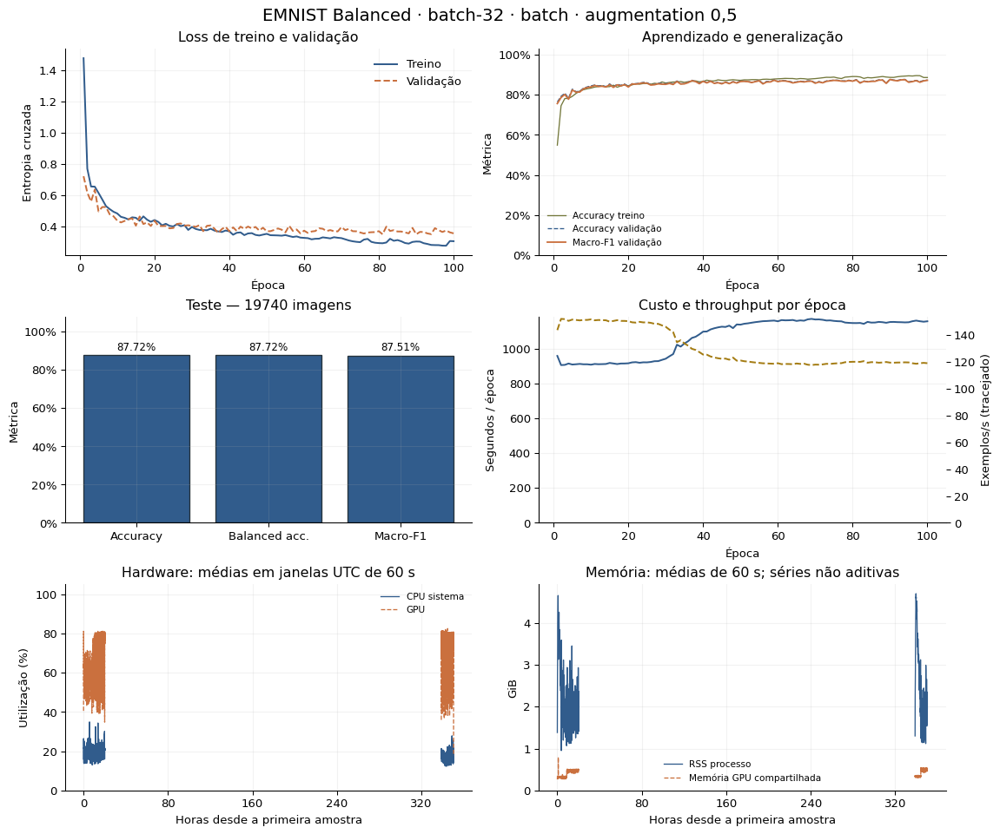

**Resultado:** accuracy 87.72%, balanced accuracy 87.72%, Macro-F1 87.51%, precisão macro 88.02%, recall macro 87.72%, AUC OVR 0.9972 e loss de teste 0.3555. **Custo:** 29.76 h pela soma das épocas; 128.96 exemplos/s, ponderando pelo tempo; avaliação final 106.39 s. **Curva:** melhor Macro-F1 de validação 87.69% na época 90; última época 87.27%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-64 teve o maior Macro-F1 (87.80%); esta condição ficou -0.286 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 71.17%, CPU do processo média 92.14%, RAM média 77.73%; pico de RSS 4.72 GiB e de memória GPU compartilhada 1.22 GiB. **Reconciliação:** resumo de treino 10.94 h versus soma das épocas 29.76 h; diferença 18.83 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 21, F1 44.08% e suporte 420 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [34]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|emnist_balanced|batch-32')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|emnist_balanced|batch-32')

#### emnist_balanced · batch-64

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|emnist_balanced|batch-64`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-064/emnist_balanced/runs/emnist_balanced__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

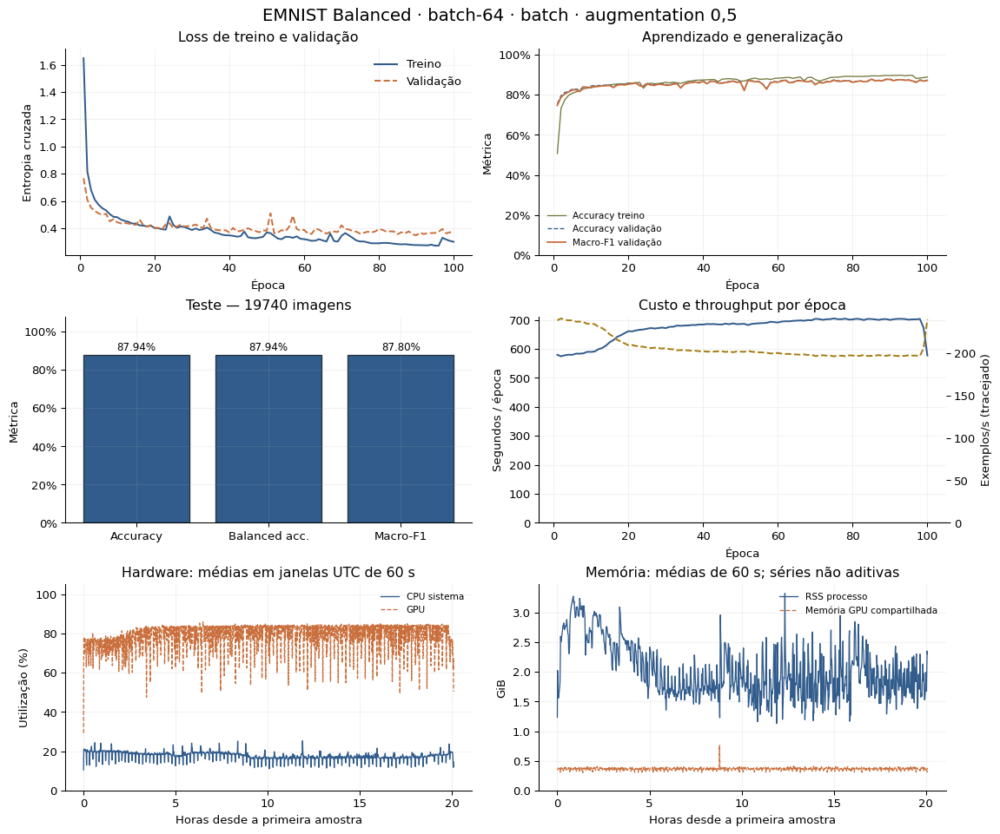

**Resultado:** accuracy 87.94%, balanced accuracy 87.94%, Macro-F1 87.80%, precisão macro 88.06%, recall macro 87.94%, AUC OVR 0.9974 e loss de teste 0.3431. **Custo:** 18.68 h pela soma das épocas; 205.53 exemplos/s, ponderando pelo tempo; avaliação final 74.67 s. **Curva:** melhor Macro-F1 de validação 87.81% na época 85; última época 87.23%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-64 teve o maior Macro-F1 (87.80%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 78.99%, CPU do processo média 86.40%, RAM média 79.57%; pico de RSS 3.88 GiB e de memória GPU compartilhada 2.12 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 21, F1 54.33% e suporte 420 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [35]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|emnist_balanced|batch-64')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|emnist_balanced|batch-64')

#### emnist_balanced · batch-128

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|emnist_balanced|batch-128`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-128/emnist_balanced/runs/emnist_balanced__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

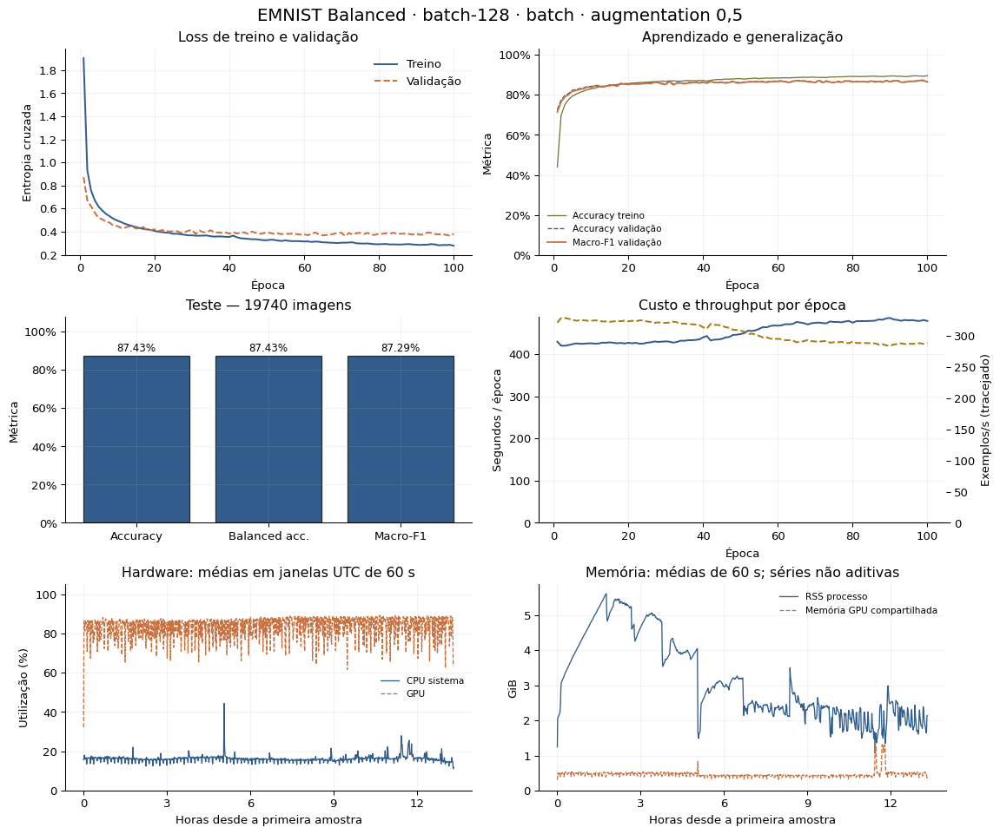

**Resultado:** accuracy 87.43%, balanced accuracy 87.43%, Macro-F1 87.29%, precisão macro 87.86%, recall macro 87.43%, AUC OVR 0.9972 e loss de teste 0.3582. **Custo:** 12.56 h pela soma das épocas; 305.71 exemplos/s, ponderando pelo tempo; avaliação final 53.60 s. **Curva:** melhor Macro-F1 de validação 87.20% na época 71; última época 86.45%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-64 teve o maior Macro-F1 (87.80%); esta condição ficou -0.504 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 83.62%, CPU do processo média 83.81%, RAM média 71.17%; pico de RSS 5.64 GiB e de memória GPU compartilhada 2.33 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 21, F1 52.88% e suporte 420 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [36]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|emnist_balanced|batch-128')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|emnist_balanced|batch-128')

#### emnist_balanced · batch-256

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|emnist_balanced|batch-256`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-256/emnist_balanced/runs/emnist_balanced__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

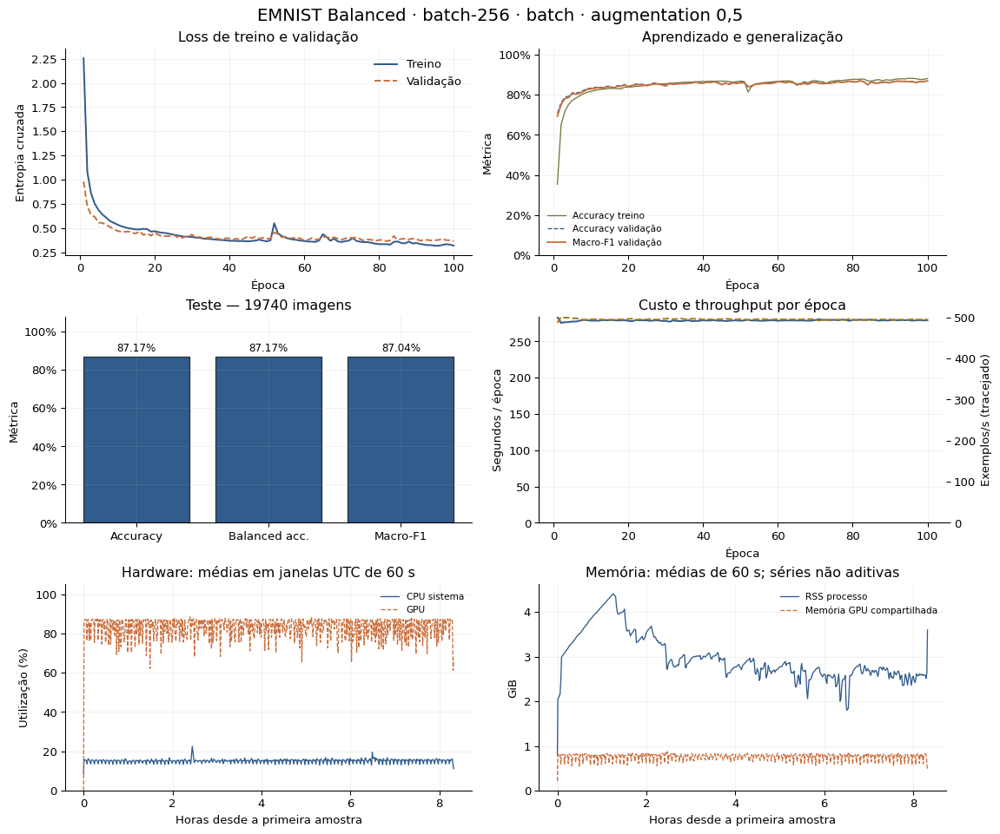

**Resultado:** accuracy 87.17%, balanced accuracy 87.17%, Macro-F1 87.04%, precisão macro 87.50%, recall macro 87.17%, AUC OVR 0.9972 e loss de teste 0.3644. **Custo:** 7.75 h pela soma das épocas; 495.36 exemplos/s, ponderando pelo tempo; avaliação final 38.51 s. **Curva:** melhor Macro-F1 de validação 87.02% na época 82; última época 86.94%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-64 teve o maior Macro-F1 (87.80%); esta condição ficou -0.755 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 83.24%, CPU do processo média 94.33%, RAM média 69.50%; pico de RSS 4.43 GiB e de memória GPU compartilhada 1.40 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 21, F1 53.99% e suporte 420 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [37]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|emnist_balanced|batch-256')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|emnist_balanced|batch-256')

#### cifar10 · batch-32

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|cifar10|batch-32`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

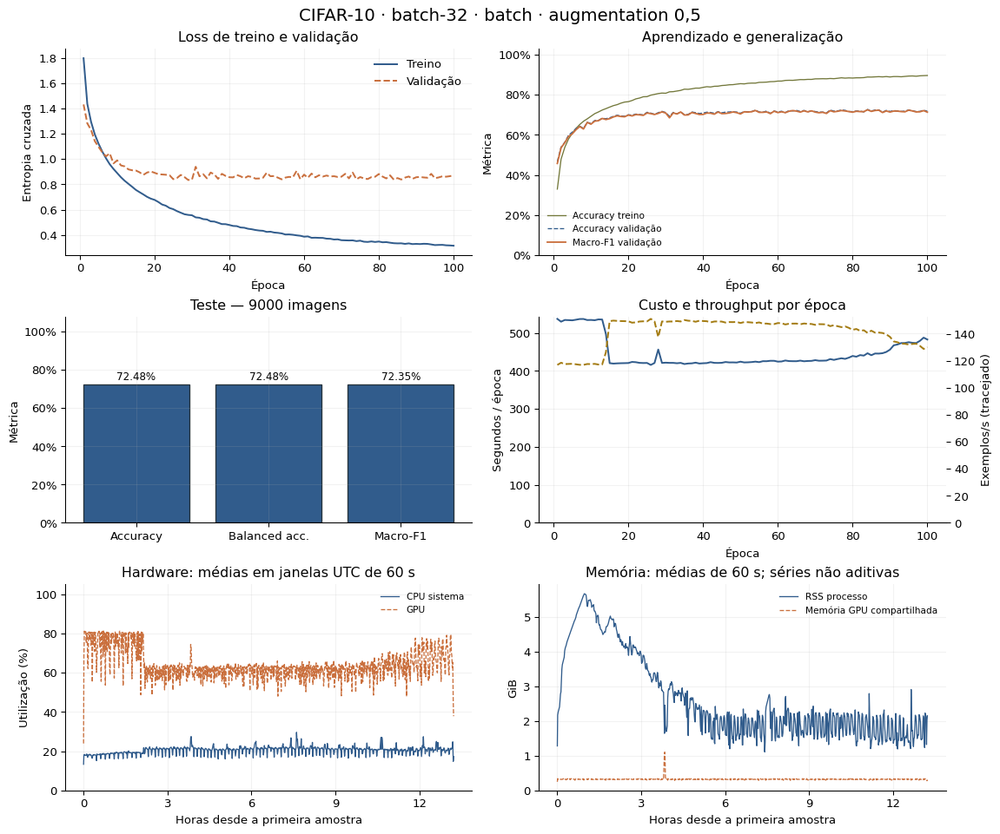

**Resultado:** accuracy 72.48%, balanced accuracy 72.48%, Macro-F1 72.35%, precisão macro 72.37%, recall macro 72.48%, AUC OVR 0.9592 e loss de teste 0.8317. **Custo:** 12.41 h pela soma das épocas; 141.00 exemplos/s, ponderando pelo tempo; avaliação final 47.36 s. **Curva:** melhor Macro-F1 de validação 72.56% na época 84; última época 71.38%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (72.35%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 64.42%, CPU do processo média 100.64%, RAM média 76.57%; pico de RSS 5.70 GiB e de memória GPU compartilhada 1.42 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** cat, F1 53.36% e suporte 900 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [38]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|cifar10|batch-32')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|cifar10|batch-32')

#### cifar10 · batch-64

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|cifar10|batch-64`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-064/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

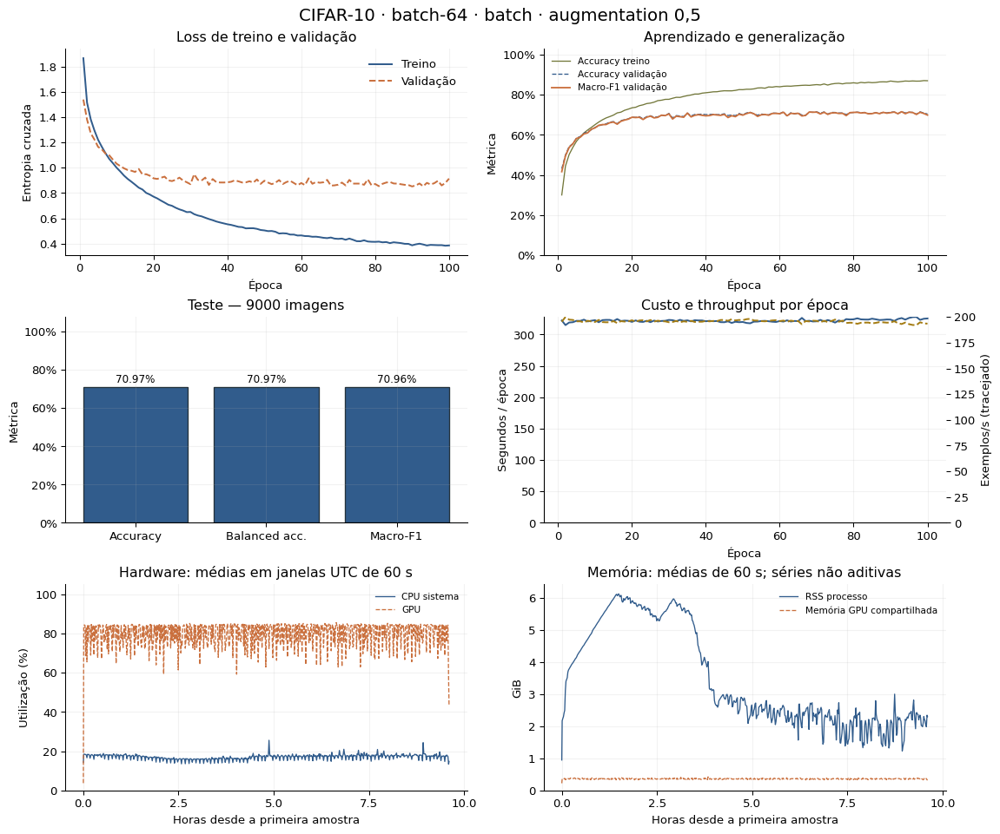

**Resultado:** accuracy 70.97%, balanced accuracy 70.97%, Macro-F1 70.96%, precisão macro 71.30%, recall macro 70.97%, AUC OVR 0.9571 e loss de teste 0.8533. **Custo:** 8.95 h pela soma das épocas; 195.58 exemplos/s, ponderando pelo tempo; avaliação final 37.63 s. **Curva:** melhor Macro-F1 de validação 71.59% na época 93; última época 69.93%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (72.35%); esta condição ficou -1.394 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 80.00%, CPU do processo média 84.02%, RAM média 69.77%; pico de RSS 6.18 GiB e de memória GPU compartilhada 0.71 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** cat, F1 50.52% e suporte 900 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [39]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|cifar10|batch-64')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|cifar10|batch-64')

#### cifar10 · batch-128

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|cifar10|batch-128`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-128/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

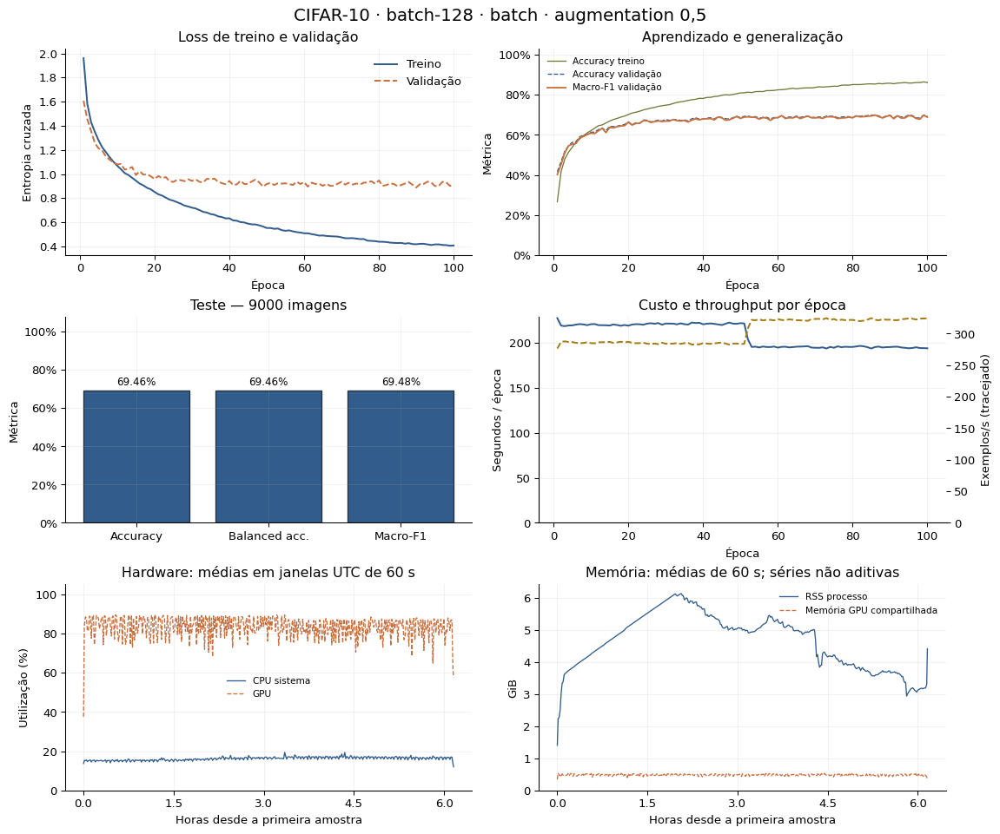

**Resultado:** accuracy 69.46%, balanced accuracy 69.46%, Macro-F1 69.48%, precisão macro 69.98%, recall macro 69.46%, AUC OVR 0.9526 e loss de teste 0.9023. **Custo:** 5.80 h pela soma das épocas; 301.95 exemplos/s, ponderando pelo tempo; avaliação final 24.24 s. **Curva:** melhor Macro-F1 de validação 69.92% na época 86; última época 68.89%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (72.35%); esta condição ficou -2.868 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 83.94%, CPU do processo média 84.14%, RAM média 61.49%; pico de RSS 6.16 GiB e de memória GPU compartilhada 0.80 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** cat, F1 49.21% e suporte 900 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [40]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|cifar10|batch-128')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|cifar10|batch-128')

#### cifar10 · batch-256

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|cifar10|batch-256`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-256/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

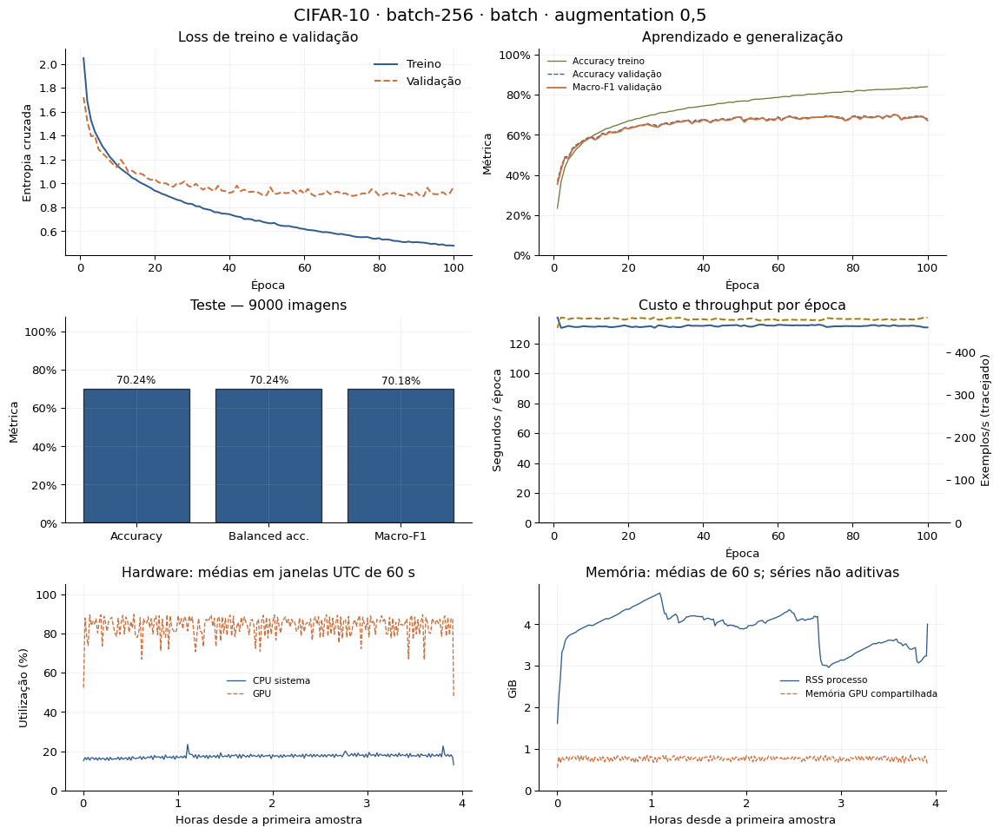

**Resultado:** accuracy 70.24%, balanced accuracy 70.24%, Macro-F1 70.18%, precisão macro 70.48%, recall macro 70.24%, AUC OVR 0.9551 e loss de teste 0.8714. **Custo:** 3.66 h pela soma das épocas; 477.89 exemplos/s, ponderando pelo tempo; avaliação final 18.10 s. **Curva:** melhor Macro-F1 de validação 70.08% na época 91; última época 67.22%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (72.35%); esta condição ficou -2.168 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 84.48%, CPU do processo média 93.58%, RAM média 63.17%; pico de RSS 4.77 GiB e de memória GPU compartilhada 1.16 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** cat, F1 50.43% e suporte 900 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [41]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|cifar10|batch-256')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|cifar10|batch-256')

#### cifar100_coarse · batch-32

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|cifar100_coarse|batch-32`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/cifar100_coarse/runs/cifar100_coarse__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

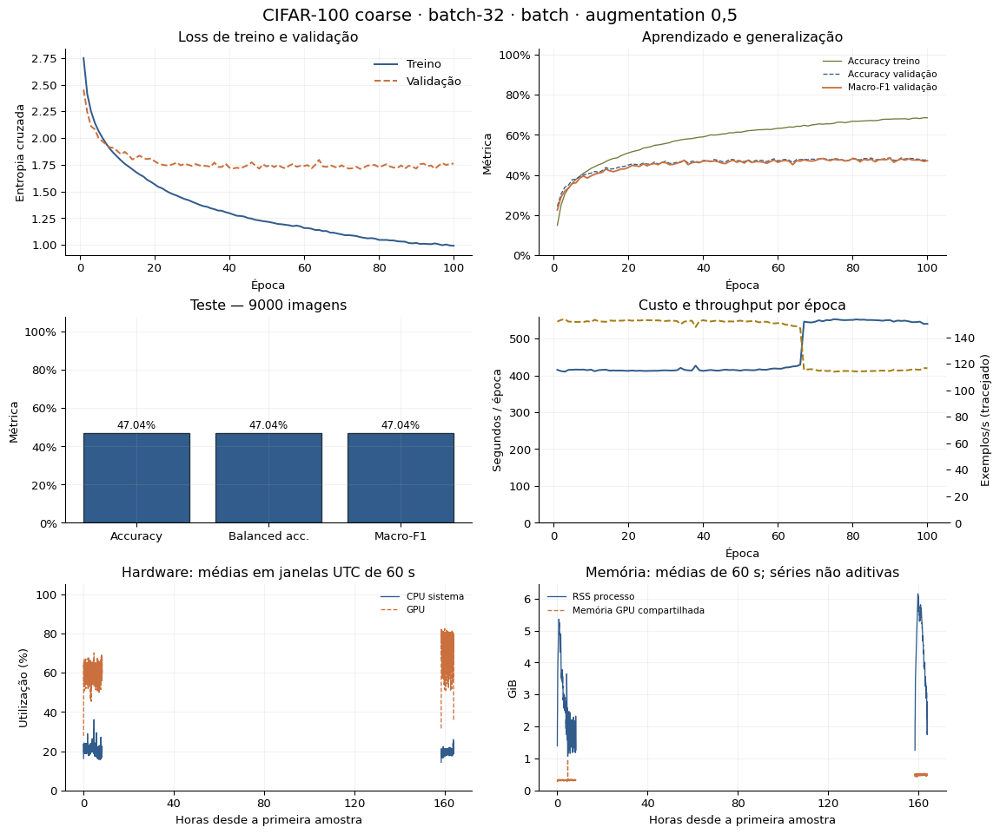

**Resultado:** accuracy 47.04%, balanced accuracy 47.04%, Macro-F1 47.04%, precisão macro 47.61%, recall macro 47.04%, AUC OVR 0.9034 e loss de teste 1.7369. **Custo:** 12.78 h pela soma das épocas; 136.89 exemplos/s, ponderando pelo tempo; avaliação final 49.62 s. **Curva:** melhor Macro-F1 de validação 48.47% na época 90; última época 47.13%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (47.04%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 67.24%, CPU do processo média 98.07%, RAM média 70.46%; pico de RSS 6.16 GiB e de memória GPU compartilhada 1.24 GiB. **Reconciliação:** resumo de treino 5.17 h versus soma das épocas 12.78 h; diferença 7.61 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** reptiles, F1 23.72% e suporte 450 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [42]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|cifar100_coarse|batch-32')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|cifar100_coarse|batch-32')

#### cifar100_coarse · batch-64

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|cifar100_coarse|batch-64`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-064/cifar100_coarse/runs/cifar100_coarse__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

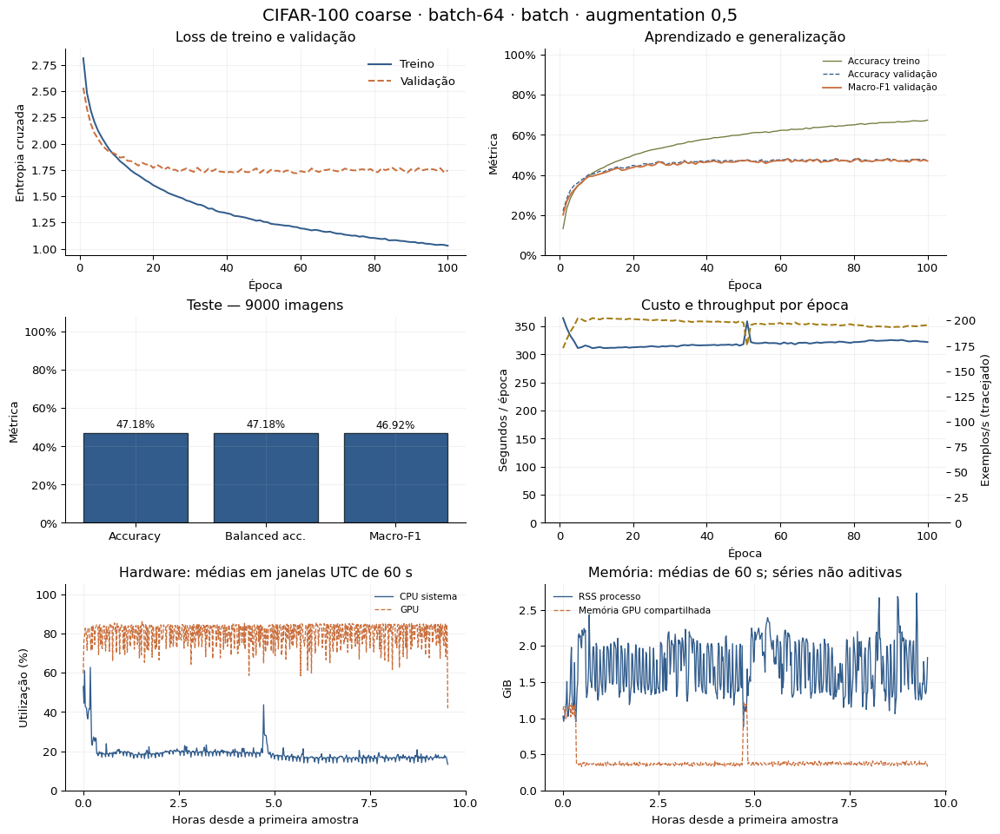

**Resultado:** accuracy 47.18%, balanced accuracy 47.18%, Macro-F1 46.92%, precisão macro 47.07%, recall macro 47.18%, AUC OVR 0.9011 e loss de teste 1.7553. **Custo:** 8.89 h pela soma das épocas; 196.95 exemplos/s, ponderando pelo tempo; avaliação final 38.40 s. **Curva:** melhor Macro-F1 de validação 48.13% na época 81; última época 47.01%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (47.04%); esta condição ficou -0.120 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 80.39%, CPU do processo média 83.91%, RAM média 80.25%; pico de RSS 3.03 GiB e de memória GPU compartilhada 2.40 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** reptiles, F1 25.86% e suporte 450 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [43]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|cifar100_coarse|batch-64')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|cifar100_coarse|batch-64')

#### cifar100_coarse · batch-128

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|cifar100_coarse|batch-128`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-128/cifar100_coarse/runs/cifar100_coarse__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

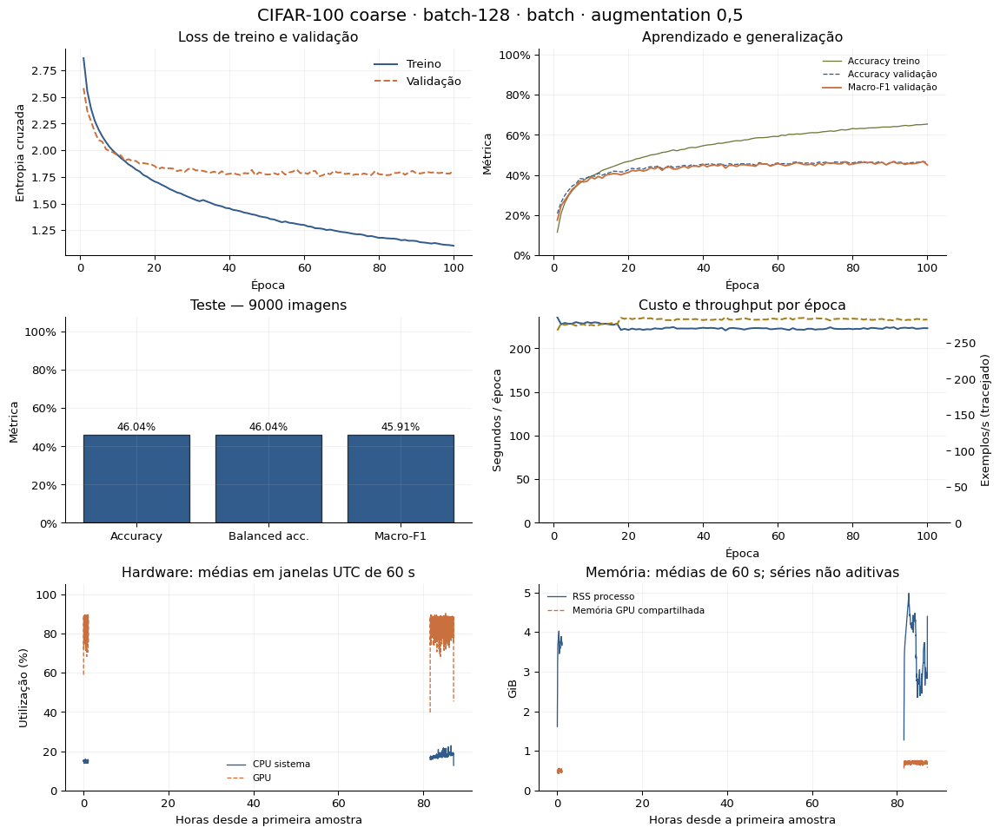

**Resultado:** accuracy 46.04%, balanced accuracy 46.04%, Macro-F1 45.91%, precisão macro 46.18%, recall macro 46.04%, AUC OVR 0.8937 e loss de teste 1.8093. **Custo:** 6.22 h pela soma das épocas; 281.49 exemplos/s, ponderando pelo tempo; avaliação final 26.52 s. **Curva:** melhor Macro-F1 de validação 46.63% na época 99; última época 44.98%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (47.04%); esta condição ficou -1.133 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 84.53%, CPU do processo média 78.99%, RAM média 64.84%; pico de RSS 5.00 GiB e de memória GPU compartilhada 0.86 GiB. **Reconciliação:** resumo de treino 5.20 h versus soma das épocas 6.22 h; diferença 1.02 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** small_mammals, F1 21.81% e suporte 450 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [44]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|cifar100_coarse|batch-128')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|cifar100_coarse|batch-128')

#### cifar100_coarse · batch-256

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|cifar100_coarse|batch-256`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-256/cifar100_coarse/runs/cifar100_coarse__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

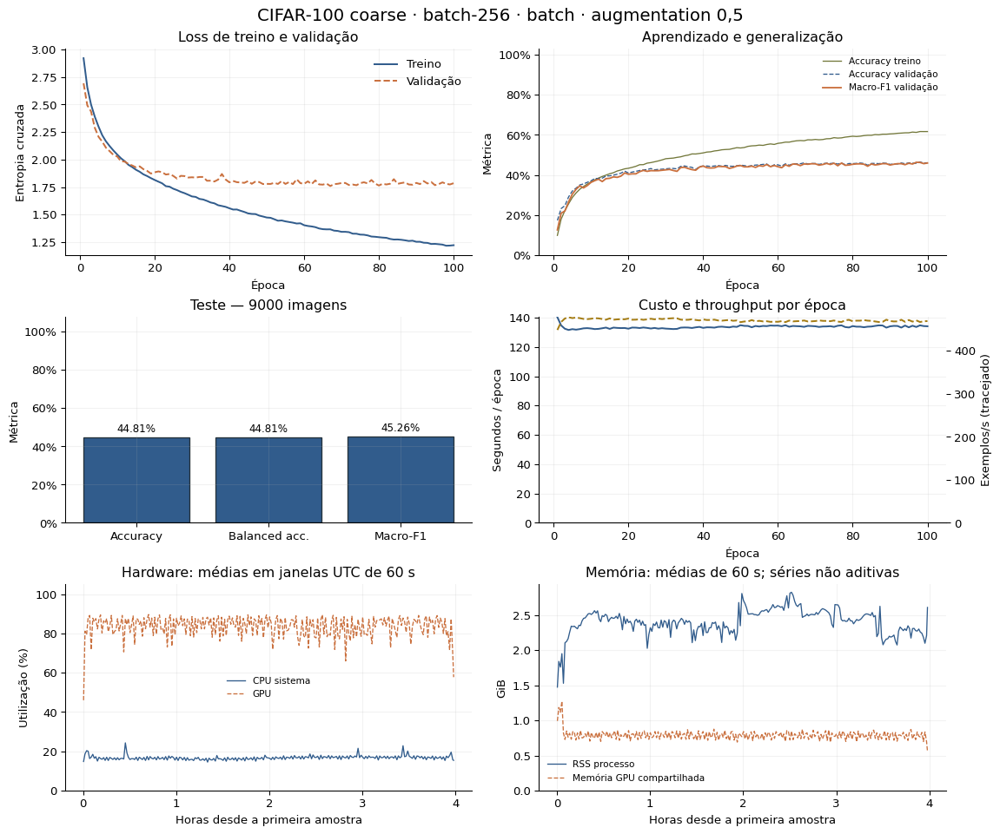

**Resultado:** accuracy 44.81%, balanced accuracy 44.81%, Macro-F1 45.26%, precisão macro 46.53%, recall macro 44.81%, AUC OVR 0.8933 e loss de teste 1.8306. **Custo:** 3.71 h pela soma das épocas; 471.32 exemplos/s, ponderando pelo tempo; avaliação final 17.28 s. **Curva:** melhor Macro-F1 de validação 46.33% na época 97; última época 45.98%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (47.04%); esta condição ficou -1.786 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 84.63%, CPU do processo média 92.23%, RAM média 76.56%; pico de RSS 3.15 GiB e de memória GPU compartilhada 1.60 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** small_mammals, F1 25.24% e suporte 450 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [45]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|cifar100_coarse|batch-256')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|cifar100_coarse|batch-256')

#### svhn · batch-32

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|svhn|batch-32`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/svhn/runs/svhn__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

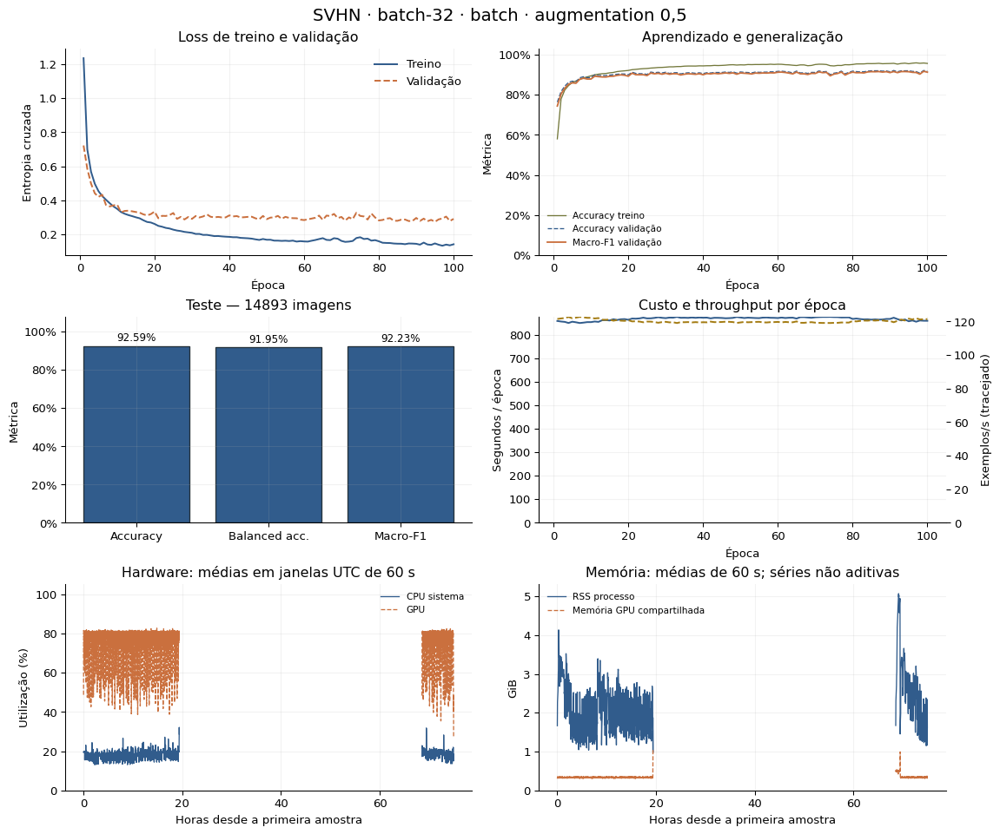

**Resultado:** accuracy 92.59%, balanced accuracy 91.95%, Macro-F1 92.23%, precisão macro 92.55%, recall macro 91.95%, AUC OVR 0.9947 e loss de teste 0.2618. **Custo:** 24.09 h pela soma das épocas; 120.21 exemplos/s, ponderando pelo tempo; avaliação final 81.24 s. **Curva:** melhor Macro-F1 de validação 91.78% na época 99; última época 91.35%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (92.23%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 76.20%, CPU do processo média 85.37%, RAM média 78.32%; pico de RSS 5.11 GiB e de memória GPU compartilhada 1.70 GiB. **Reconciliação:** resumo de treino 6.01 h versus soma das épocas 24.09 h; diferença 18.08 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 6, F1 89.93% e suporte 1155 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [46]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|svhn|batch-32')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|svhn|batch-32')

#### svhn · batch-64

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|svhn|batch-64`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-064/svhn/runs/svhn__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

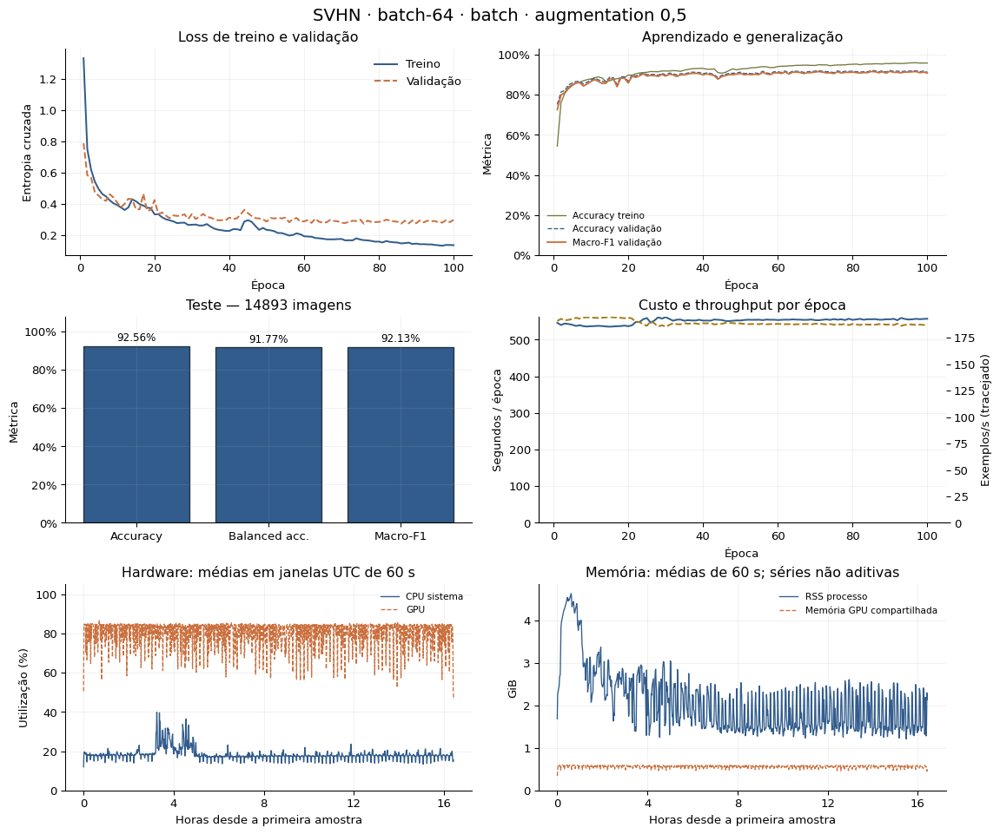

**Resultado:** accuracy 92.56%, balanced accuracy 91.77%, Macro-F1 92.13%, precisão macro 92.56%, recall macro 91.77%, AUC OVR 0.9947 e loss de teste 0.2583. **Custo:** 15.31 h pela soma das épocas; 189.11 exemplos/s, ponderando pelo tempo; avaliação final 62.62 s. **Curva:** melhor Macro-F1 de validação 91.78% na época 90; última época 90.93%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (92.23%); esta condição ficou -0.108 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 80.32%, CPU do processo média 79.93%, RAM média 77.44%; pico de RSS 4.65 GiB e de memória GPU compartilhada 0.73 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 8, F1 89.41% e suporte 1006 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [47]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|svhn|batch-64')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|svhn|batch-64')

#### svhn · batch-128

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|svhn|batch-128`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-128/svhn/runs/svhn__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

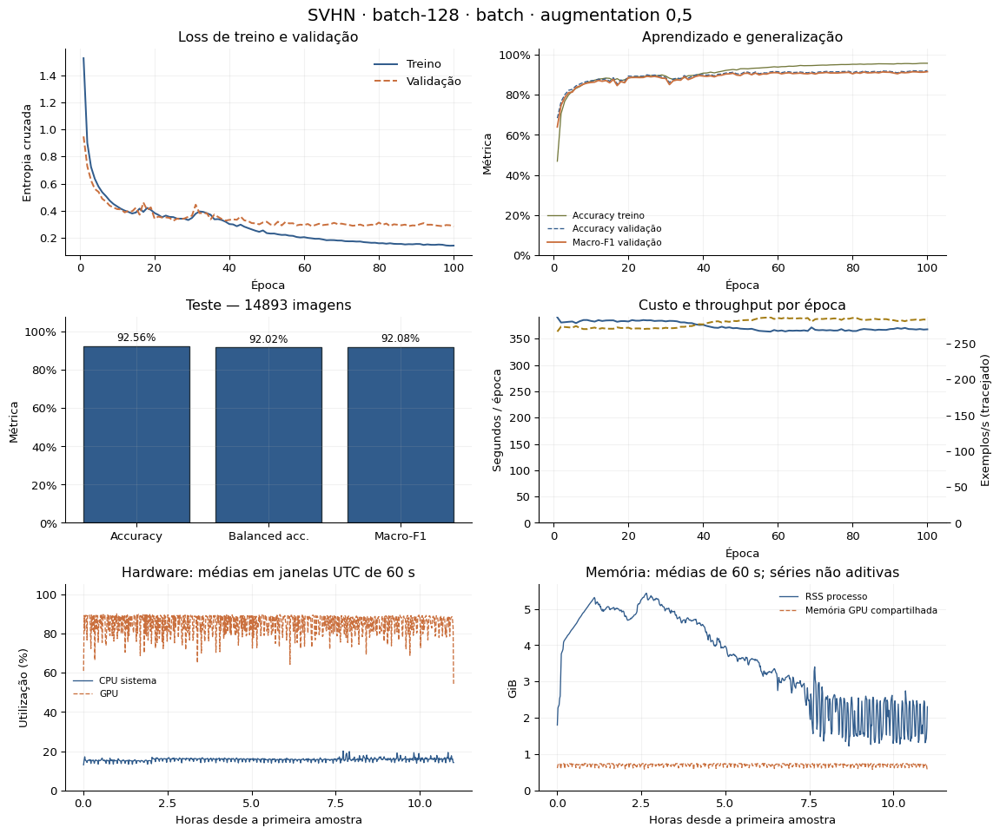

**Resultado:** accuracy 92.56%, balanced accuracy 92.02%, Macro-F1 92.08%, precisão macro 92.16%, recall macro 92.02%, AUC OVR 0.9948 e loss de teste 0.2603. **Custo:** 10.38 h pela soma das épocas; 279.03 exemplos/s, ponderando pelo tempo; avaliação final 40.42 s. **Curva:** melhor Macro-F1 de validação 91.60% na época 100; última época 91.60%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (92.23%); esta condição ficou -0.158 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 85.21%, CPU do processo média 77.31%, RAM média 70.16%; pico de RSS 5.45 GiB e de memória GPU compartilhada 0.88 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 8, F1 88.72% e suporte 1006 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [48]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|svhn|batch-128')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|svhn|batch-128')

#### svhn · batch-256

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|svhn|batch-256`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-256/svhn/runs/svhn__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

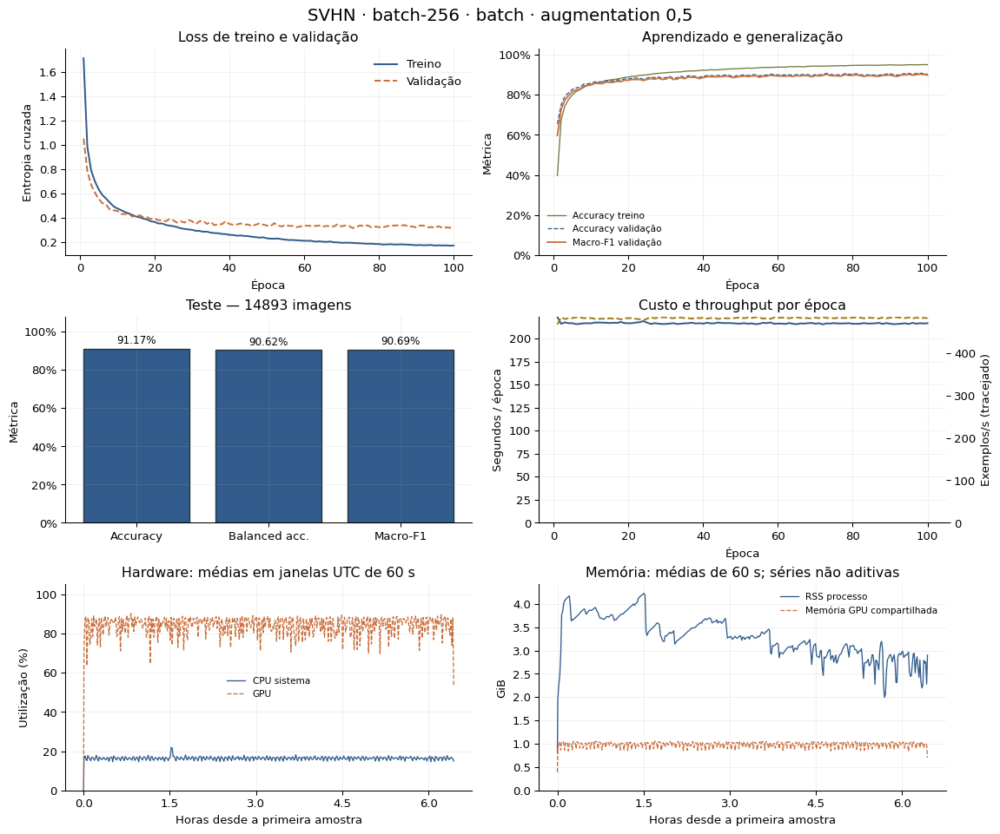

**Resultado:** accuracy 91.17%, balanced accuracy 90.62%, Macro-F1 90.69%, precisão macro 90.79%, recall macro 90.62%, AUC OVR 0.9932 e loss de teste 0.3039. **Custo:** 6.01 h pela soma das épocas; 481.68 exemplos/s, ponderando pelo tempo; avaliação final 30.65 s. **Curva:** melhor Macro-F1 de validação 90.34% na época 98; última época 89.85%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (92.23%); esta condição ficou -1.544 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 84.57%, CPU do processo média 91.78%, RAM média 67.77%; pico de RSS 4.24 GiB e de memória GPU compartilhada 1.19 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 3, F1 87.87% e suporte 1707 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [49]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|svhn|batch-256')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|svhn|batch-256')

#### gtsrb · batch-32

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|gtsrb|batch-32`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/gtsrb/runs/gtsrb__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

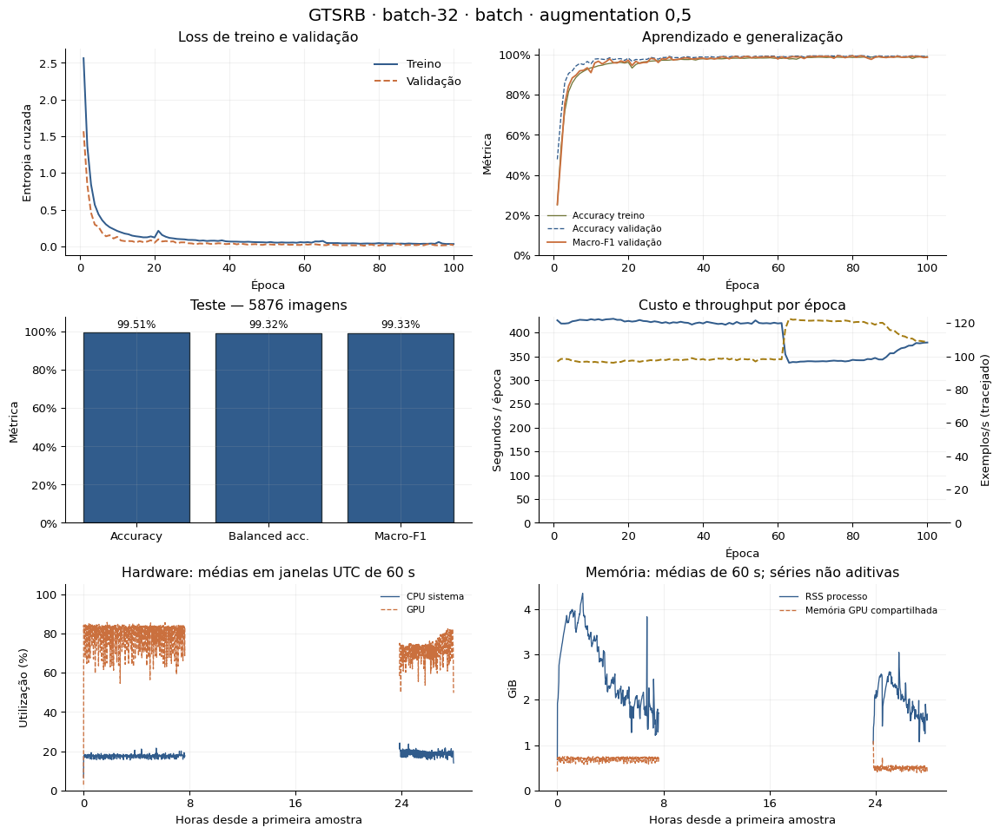

**Resultado:** accuracy 99.51%, balanced accuracy 99.32%, Macro-F1 99.33%, precisão macro 99.36%, recall macro 99.32%, AUC OVR 1.0000 e loss de teste 0.0174. **Custo:** 10.94 h pela soma das épocas; 104.70 exemplos/s, ponderando pelo tempo; avaliação final 40.60 s. **Curva:** melhor Macro-F1 de validação 99.52% na época 82; última época 98.79%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (99.33%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 76.93%, CPU do processo média 86.66%, RAM média 72.68%; pico de RSS 4.51 GiB e de memória GPU compartilhada 1.53 GiB. **Reconciliação:** resumo de treino 3.79 h versus soma das épocas 10.94 h; diferença 7.15 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 39, F1 95.45% e suporte 45 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [50]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|gtsrb|batch-32')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|gtsrb|batch-32')

#### gtsrb · batch-64

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|gtsrb|batch-64`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-064/gtsrb/runs/gtsrb__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

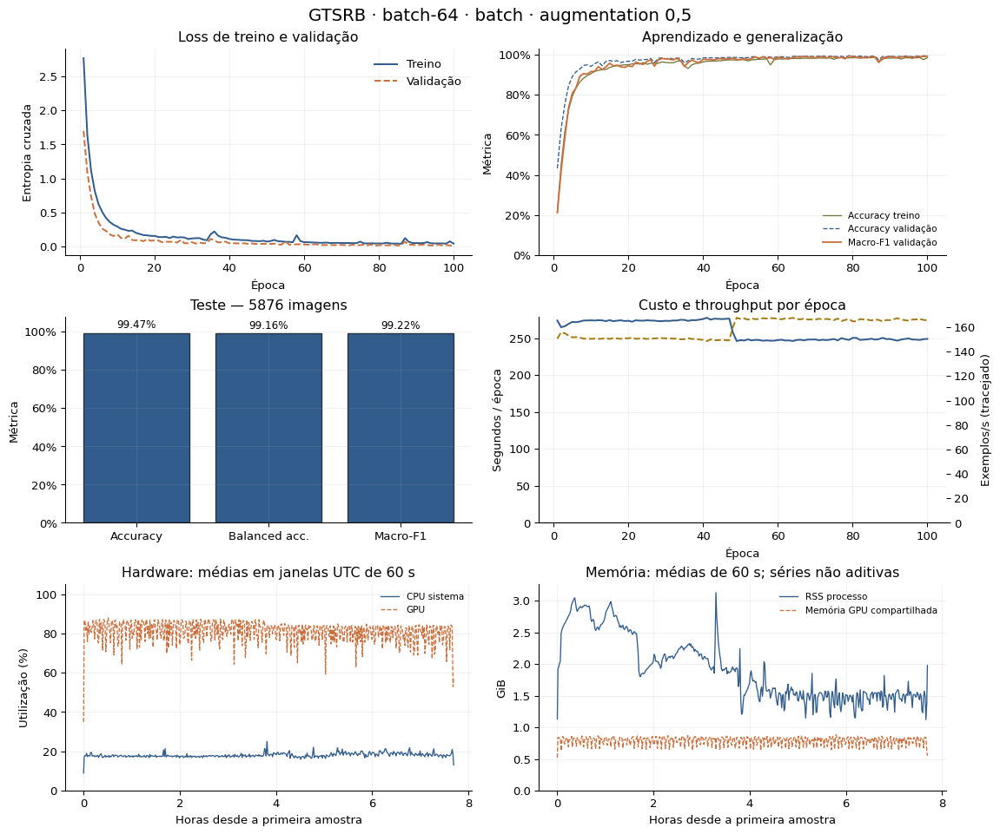

**Resultado:** accuracy 99.47%, balanced accuracy 99.16%, Macro-F1 99.22%, precisão macro 99.28%, recall macro 99.16%, AUC OVR 1.0000 e loss de teste 0.0174. **Custo:** 7.22 h pela soma das épocas; 158.60 exemplos/s, ponderando pelo tempo; avaliação final 28.21 s. **Curva:** melhor Macro-F1 de validação 99.41% na época 79; última época 99.33%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (99.33%); esta condição ficou -0.114 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 81.46%, CPU do processo média 88.60%, RAM média 78.68%; pico de RSS 3.92 GiB e de memória GPU compartilhada 1.13 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 34, F1 92.80% e suporte 63 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [51]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|gtsrb|batch-64')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|gtsrb|batch-64')

#### gtsrb · batch-128

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|gtsrb|batch-128`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-128/gtsrb/runs/gtsrb__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

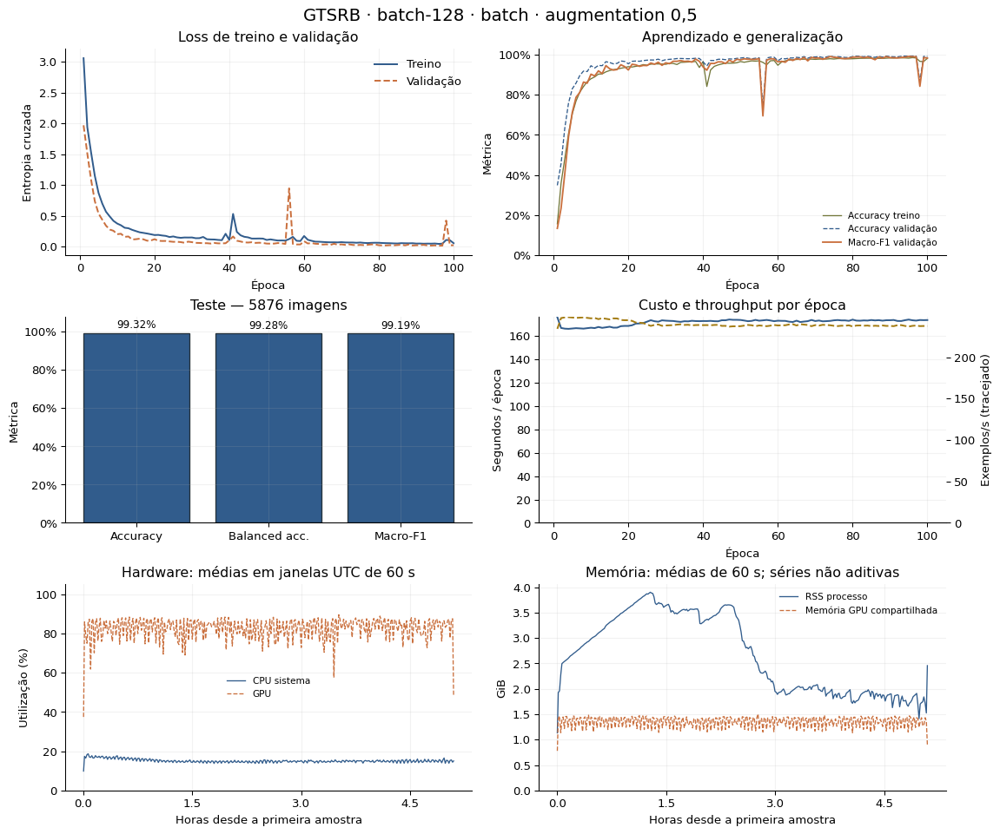

**Resultado:** accuracy 99.32%, balanced accuracy 99.28%, Macro-F1 99.19%, precisão macro 99.12%, recall macro 99.28%, AUC OVR 1.0000 e loss de teste 0.0246. **Custo:** 4.77 h pela soma das épocas; 239.94 exemplos/s, ponderando pelo tempo; avaliação final 23.17 s. **Curva:** melhor Macro-F1 de validação 99.17% na época 95; última época 98.41%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (99.33%); esta condição ficou -0.144 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 83.21%, CPU do processo média 94.48%, RAM média 71.63%; pico de RSS 3.93 GiB e de memória GPU compartilhada 1.79 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 34, F1 96.88% e suporte 63 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [52]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|gtsrb|batch-128')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|gtsrb|batch-128')

#### gtsrb · batch-256

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|gtsrb|batch-256`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-256/gtsrb/runs/gtsrb__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

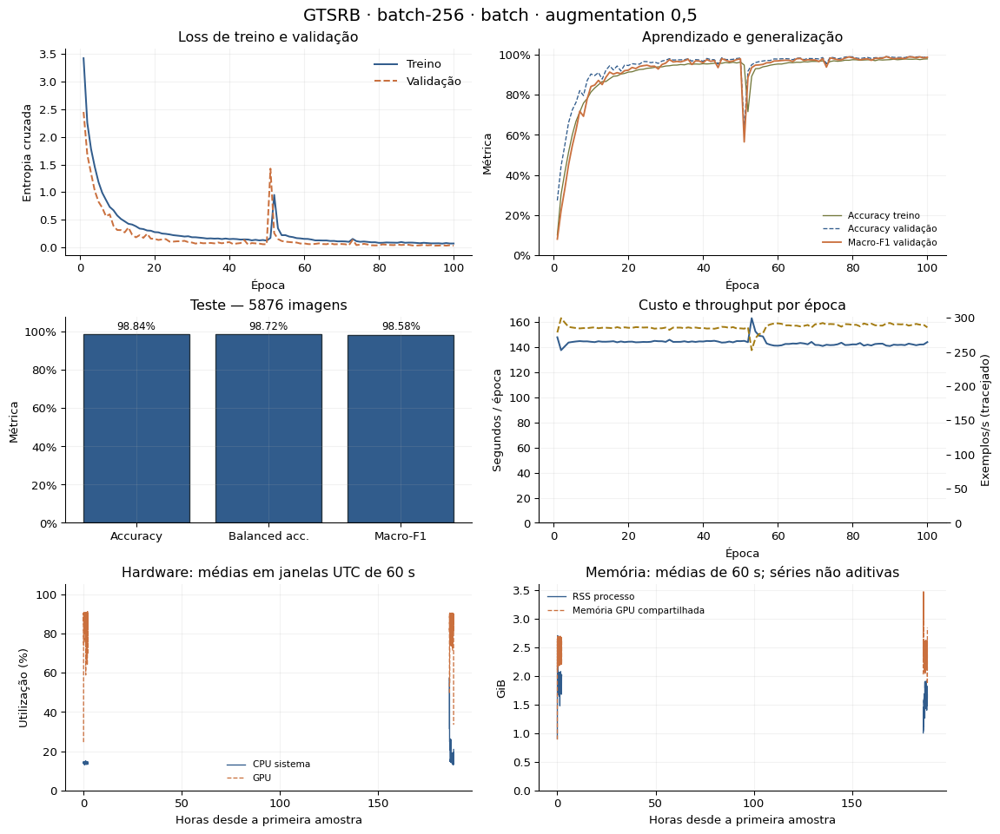

**Resultado:** accuracy 98.84%, balanced accuracy 98.72%, Macro-F1 98.58%, precisão macro 98.46%, recall macro 98.72%, AUC OVR 1.0000 e loss de teste 0.0383. **Custo:** 4.00 h pela soma das épocas; 286.69 exemplos/s, ponderando pelo tempo; avaliação final 17.64 s. **Curva:** melhor Macro-F1 de validação 99.09% na época 89; última época 98.77%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (99.33%); esta condição ficou -0.754 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 86.63%, CPU do processo média 92.92%, RAM média 77.89%; pico de RSS 2.72 GiB e de memória GPU compartilhada 3.82 GiB. **Reconciliação:** resumo de treino 1.86 h versus soma das épocas 4.00 h; diferença 2.13 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 39, F1 94.51% e suporte 45 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [53]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|gtsrb|batch-256')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|gtsrb|batch-256')

#### fer2013 · batch-32

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|fer2013|batch-32`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/fer2013/runs/fer2013__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

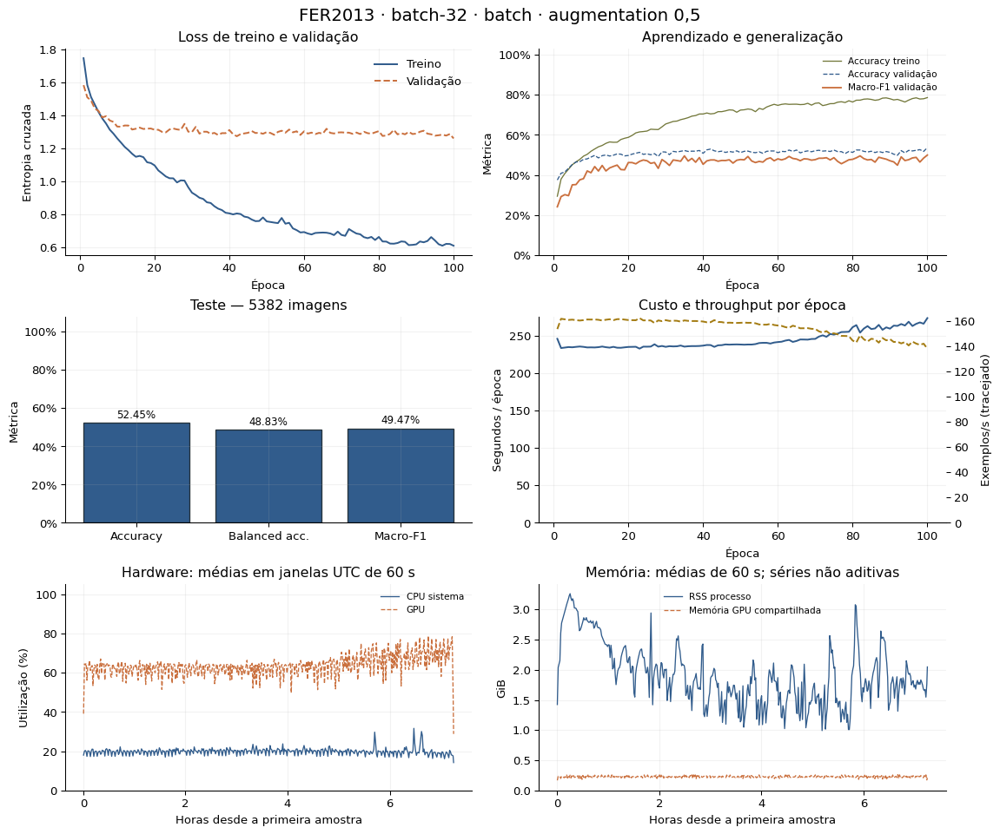

**Resultado:** accuracy 52.45%, balanced accuracy 48.83%, Macro-F1 49.47%, precisão macro 52.22%, recall macro 48.83%, AUC OVR 0.8321 e loss de teste 1.2669. **Custo:** 6.78 h pela soma das épocas; 154.48 exemplos/s, ponderando pelo tempo; avaliação final 29.32 s. **Curva:** melhor Macro-F1 de validação 49.95% na época 100; última época 49.95%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (49.47%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 64.13%, CPU do processo média 99.30%, RAM média 78.33%; pico de RSS 3.57 GiB e de memória GPU compartilhada 0.34 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** fear, F1 30.07% e suporte 768 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [54]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|fer2013|batch-32')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|fer2013|batch-32')

#### fer2013 · batch-64

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|fer2013|batch-64`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-064/fer2013/runs/fer2013__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

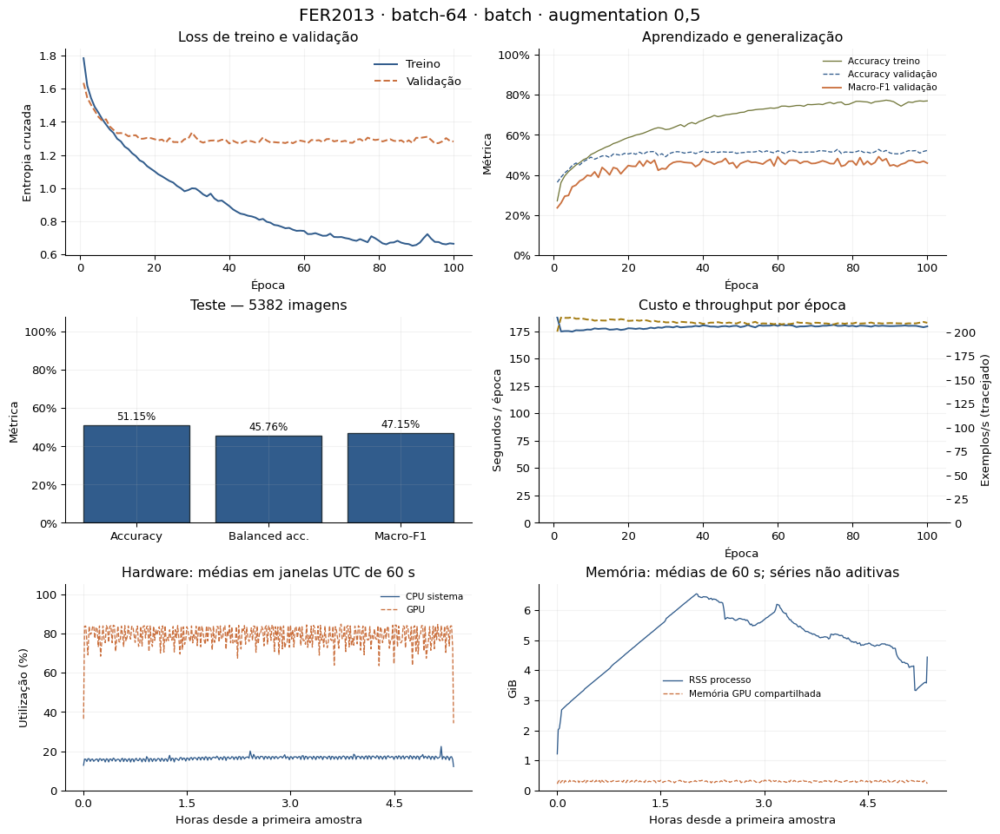

**Resultado:** accuracy 51.15%, balanced accuracy 45.76%, Macro-F1 47.15%, precisão macro 51.02%, recall macro 45.76%, AUC OVR 0.8308 e loss de teste 1.2704. **Custo:** 4.97 h pela soma das épocas; 210.53 exemplos/s, ponderando pelo tempo; avaliação final 23.92 s. **Curva:** melhor Macro-F1 de validação 49.15% na época 87; última época 45.92%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (49.47%); esta condição ficou -2.326 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 79.62%, CPU do processo média 78.87%, RAM média 61.07%; pico de RSS 6.56 GiB e de memória GPU compartilhada 0.46 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** fear, F1 34.92% e suporte 768 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [55]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|fer2013|batch-64')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|fer2013|batch-64')

#### fer2013 · batch-128

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|fer2013|batch-128`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-128/fer2013/runs/fer2013__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

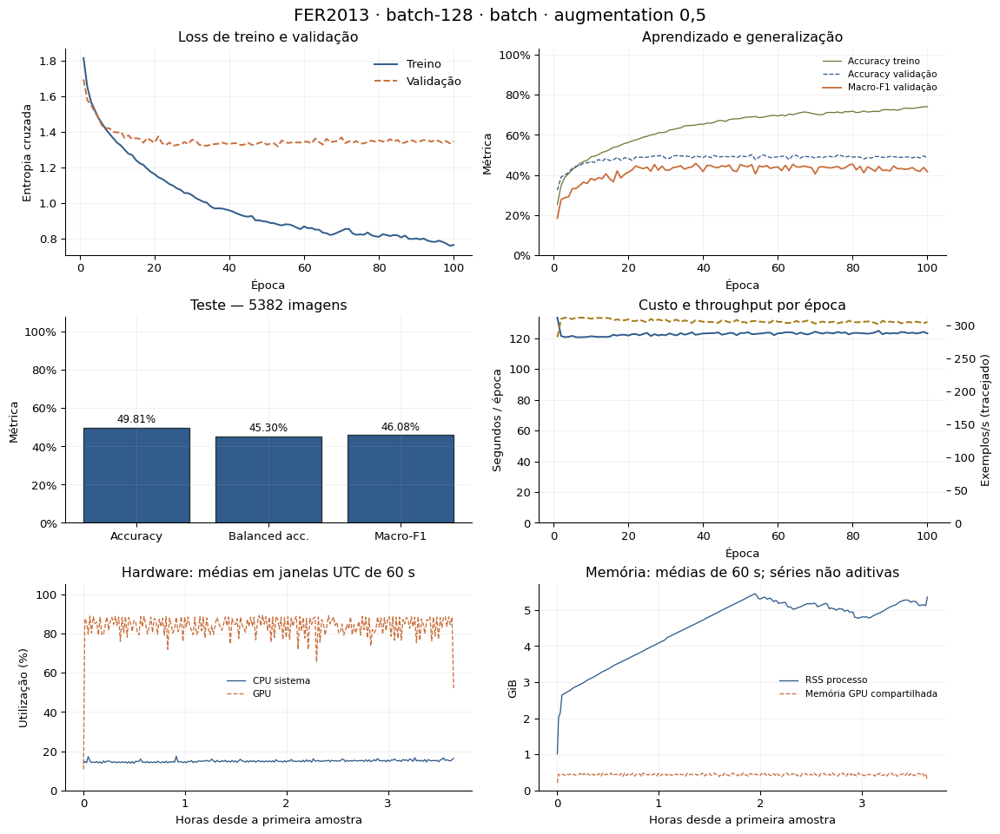

**Resultado:** accuracy 49.81%, balanced accuracy 45.30%, Macro-F1 46.08%, precisão macro 50.73%, recall macro 45.30%, AUC OVR 0.8141 e loss de teste 1.3324. **Custo:** 3.41 h pela soma das épocas; 306.64 exemplos/s, ponderando pelo tempo; avaliação final 16.10 s. **Curva:** melhor Macro-F1 de validação 45.76% na época 38; última época 41.67%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (49.47%); esta condição ficou -3.395 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 84.90%, CPU do processo média 71.21%, RAM média 59.89%; pico de RSS 5.70 GiB e de memória GPU compartilhada 0.60 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** fear, F1 30.87% e suporte 768 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [56]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|fer2013|batch-128')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|fer2013|batch-128')

#### fer2013 · batch-256

Identidade: `controlled-augmentation2-mac-m4-aug05|batch|fer2013|batch-256`. Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-256/fer2013/runs/fer2013__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `raw`.

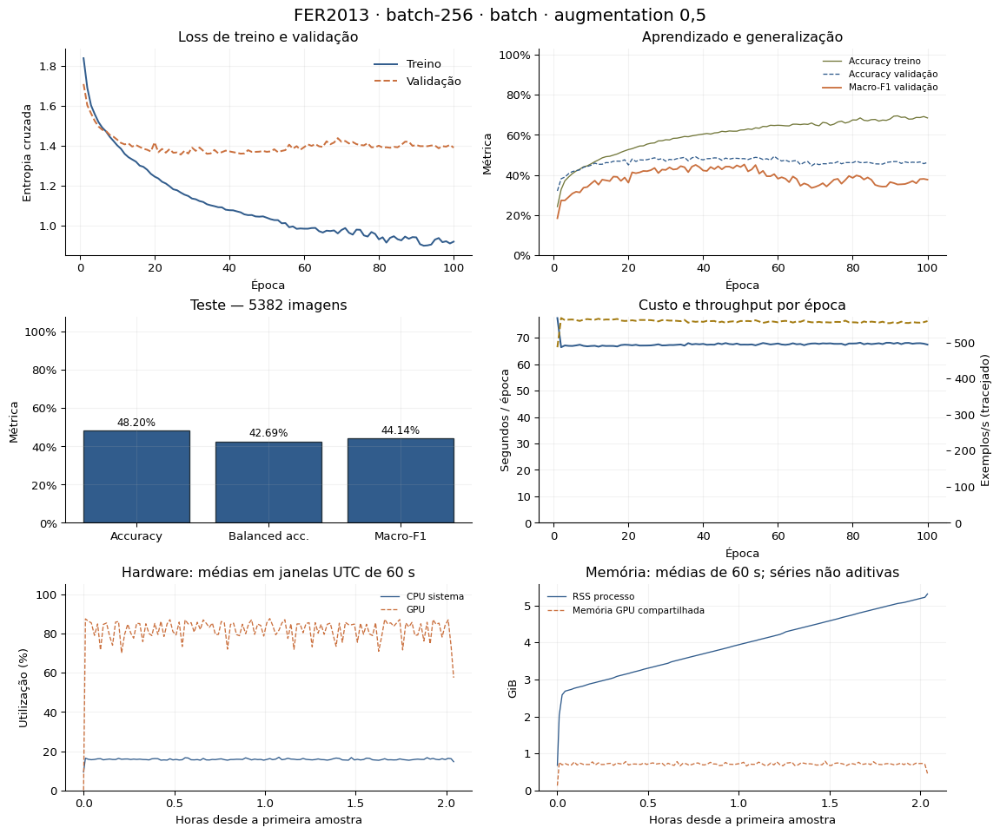

**Resultado:** accuracy 48.20%, balanced accuracy 42.69%, Macro-F1 44.14%, precisão macro 49.82%, recall macro 42.69%, AUC OVR 0.8051 e loss de teste 1.3537. **Custo:** 1.88 h pela soma das épocas; 557.86 exemplos/s, ponderando pelo tempo; avaliação final 11.45 s. **Curva:** melhor Macro-F1 de validação 45.25% na época 51; última época 37.69%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** batch-32 teve o maior Macro-F1 (49.47%); esta condição ficou -5.334 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 83.68%, CPU do processo média 81.73%, RAM média 55.99%; pico de RSS 5.45 GiB e de memória GPU compartilhada 0.91 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** fear, F1 29.04% e suporte 768 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [57]:
plot_run('controlled-augmentation2-mac-m4-aug05|batch|fer2013|batch-256')
explain_run('controlled-augmentation2-mac-m4-aug05|batch|fer2013|batch-256')

### Fichas — activations

#### mnist · relu

Identidade: `controlled-augmentation05-activations-mac2|activations|mnist|relu`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/mnist/relu/mnist/runs/mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

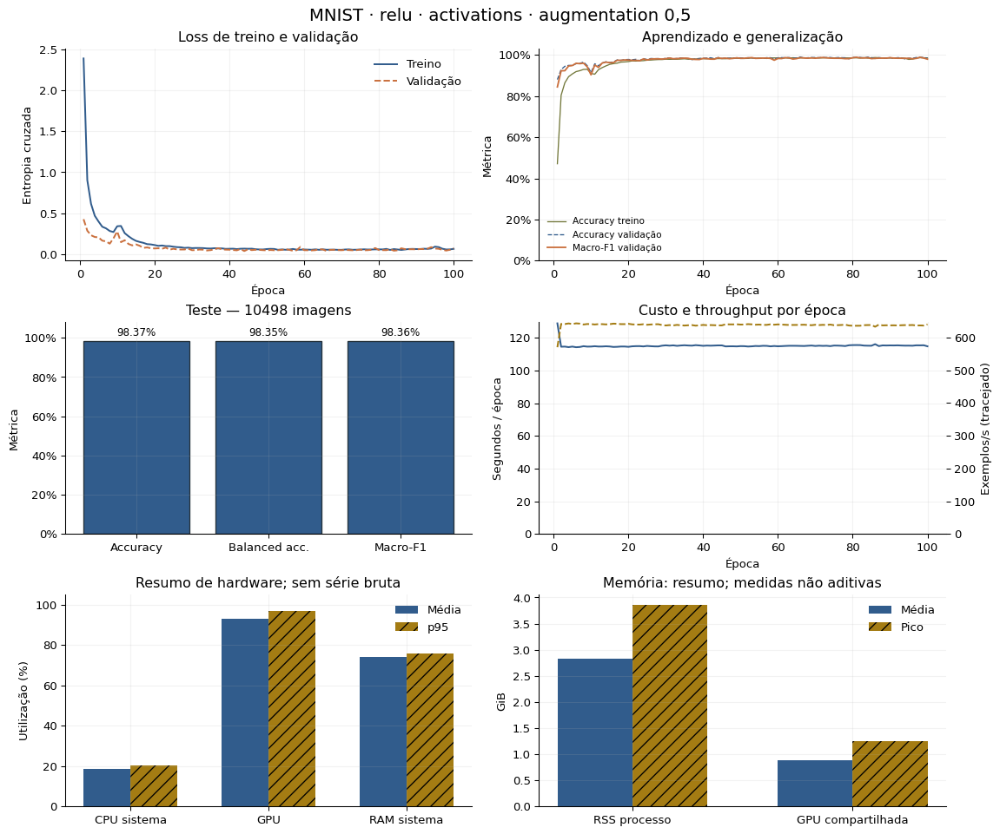

**Resultado:** accuracy 98.37%, balanced accuracy 98.35%, Macro-F1 98.36%, precisão macro 98.38%, recall macro 98.35%, AUC OVR 0.9997 e loss de teste 0.0594. **Custo:** 3.20 h pela soma das épocas; 638.11 exemplos/s, ponderando pelo tempo; avaliação final 10.83 s. **Curva:** melhor Macro-F1 de validação 98.90% na época 81; última época 97.97%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (98.44%); esta condição ficou -0.076 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 92.99%, CPU do processo média 84.27%, RAM média 74.13%; pico de RSS 3.86 GiB e de memória GPU compartilhada 1.25 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 2, F1 97.50% e suporte 1048 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [58]:
plot_run('controlled-augmentation05-activations-mac2|activations|mnist|relu')
explain_run('controlled-augmentation05-activations-mac2|activations|mnist|relu')

#### mnist · sigmoid

Identidade: `controlled-augmentation05-activations-mac2|activations|mnist|sigmoid`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/mnist/sigmoid/mnist/runs/mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

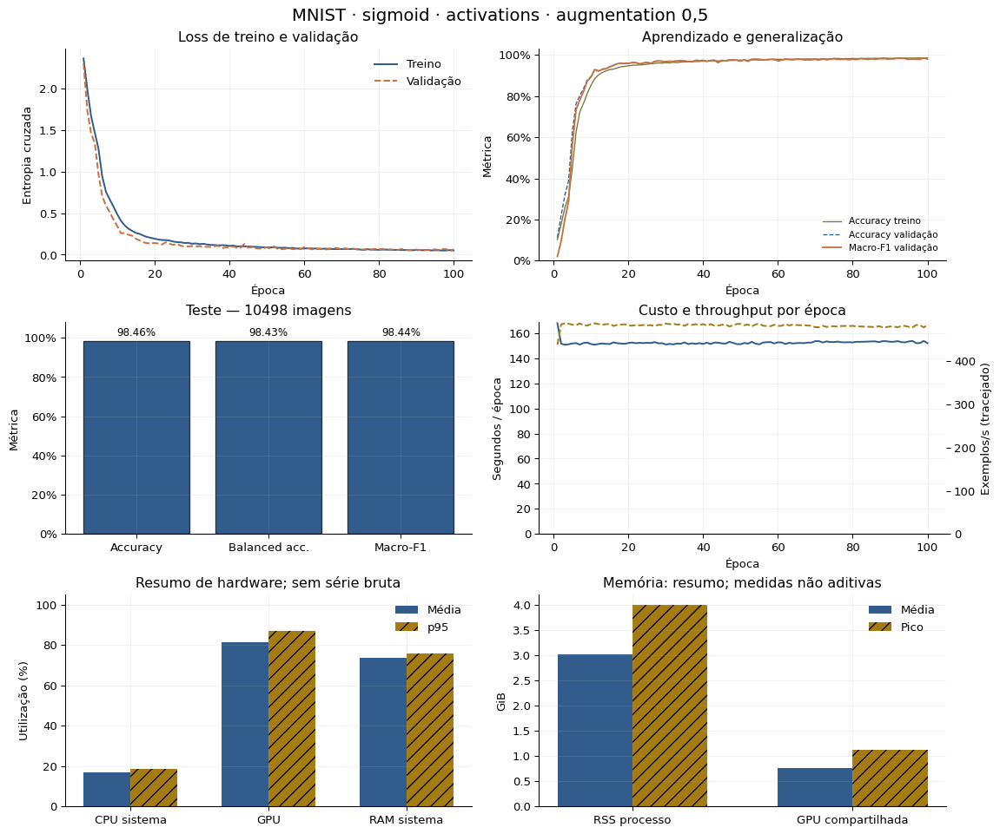

**Resultado:** accuracy 98.46%, balanced accuracy 98.43%, Macro-F1 98.44%, precisão macro 98.45%, recall macro 98.43%, AUC OVR 0.9997 e loss de teste 0.0556. **Custo:** 4.23 h pela soma das épocas; 482.33 exemplos/s, ponderando pelo tempo; avaliação final 21.72 s. **Curva:** melhor Macro-F1 de validação 98.57% na época 99; última época 98.05%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (98.44%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 81.62%, CPU do processo média 75.52%, RAM média 73.81%; pico de RSS 4.00 GiB e de memória GPU compartilhada 1.12 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 2, F1 96.91% e suporte 1048 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [59]:
plot_run('controlled-augmentation05-activations-mac2|activations|mnist|sigmoid')
explain_run('controlled-augmentation05-activations-mac2|activations|mnist|sigmoid')

#### mnist · softmax

Identidade: `controlled-augmentation05-activations-mac2|activations|mnist|softmax`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/mnist/softmax/mnist/runs/mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

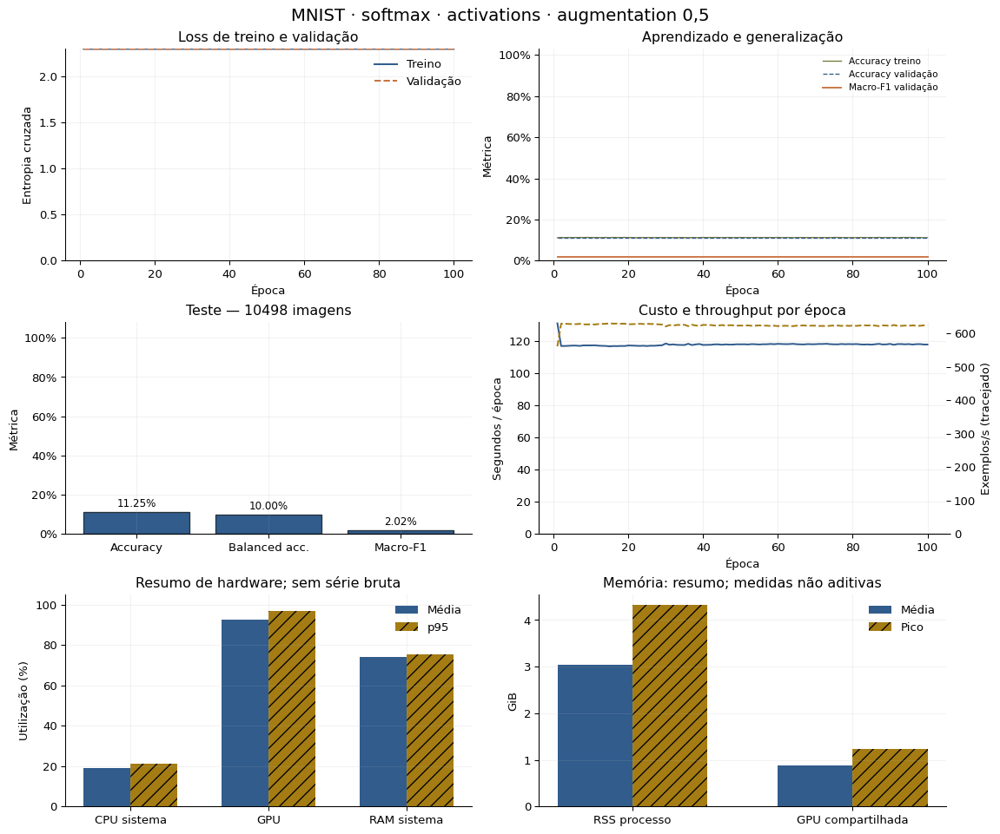

**Resultado:** accuracy 11.25%, balanced accuracy 10.00%, Macro-F1 2.02%, precisão macro 1.12%, recall macro 10.00%, AUC OVR 0.5000 e loss de teste 2.3014. **Custo:** 3.27 h pela soma das épocas; 624.18 exemplos/s, ponderando pelo tempo; avaliação final 11.26 s. **Curva:** melhor Macro-F1 de validação 2.02% na época 1; última época 2.02%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. A balanced accuracy próxima a 1/n_classes e o F1 muito baixo são compatíveis com colapso para poucas classes; confirme a distribuição por classe na tabela de evidências. Maior uso de GPU não garante aprendizado. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (98.44%); esta condição ficou -96.414 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 92.65%, CPU do processo média 82.55%, RAM média 74.07%; pico de RSS 4.33 GiB e de memória GPU compartilhada 1.23 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 0, F1 0.00% e suporte 1035 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [60]:
plot_run('controlled-augmentation05-activations-mac2|activations|mnist|softmax')
explain_run('controlled-augmentation05-activations-mac2|activations|mnist|softmax')

#### fashion_mnist · relu

Identidade: `controlled-augmentation05-activations-mac2|activations|fashion_mnist|relu`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/fashion_mnist/relu/fashion_mnist/runs/fashion_mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

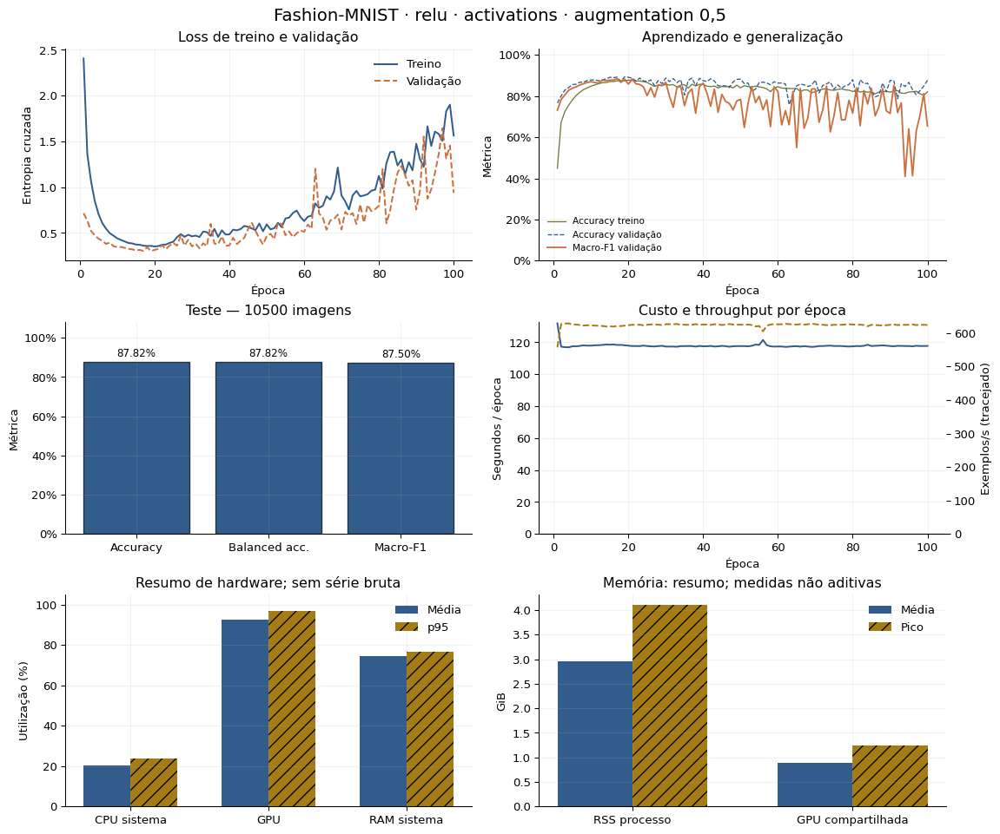

**Resultado:** accuracy 87.82%, balanced accuracy 87.82%, Macro-F1 87.50%, precisão macro 88.18%, recall macro 87.82%, AUC OVR 0.9878 e loss de teste 0.3273. **Custo:** 3.27 h pela soma das épocas; 623.60 exemplos/s, ponderando pelo tempo; avaliação final 11.04 s. **Curva:** melhor Macro-F1 de validação 88.48% na época 17; última época 65.46%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (90.04%); esta condição ficou -2.541 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 92.80%, CPU do processo média 82.60%, RAM média 74.34%; pico de RSS 4.11 GiB e de memória GPU compartilhada 1.25 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 6, F1 60.82% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [61]:
plot_run('controlled-augmentation05-activations-mac2|activations|fashion_mnist|relu')
explain_run('controlled-augmentation05-activations-mac2|activations|fashion_mnist|relu')

#### fashion_mnist · sigmoid

Identidade: `controlled-augmentation05-activations-mac2|activations|fashion_mnist|sigmoid`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/fashion_mnist/sigmoid/fashion_mnist/runs/fashion_mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

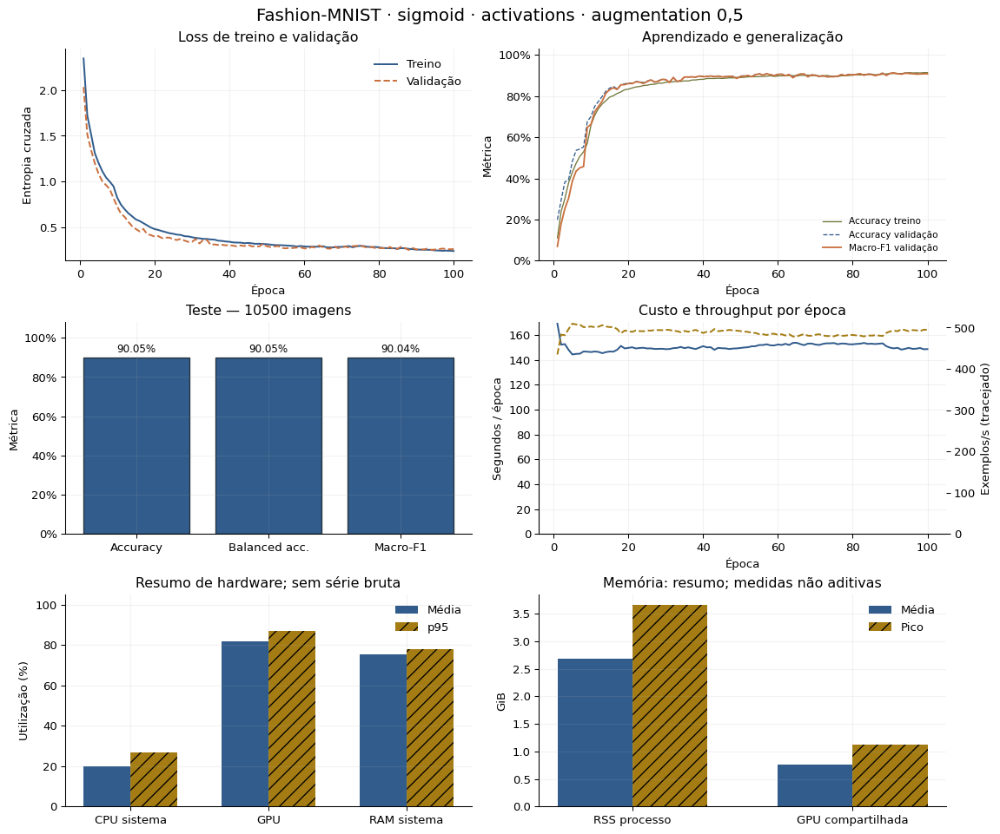

**Resultado:** accuracy 90.05%, balanced accuracy 90.05%, Macro-F1 90.04%, precisão macro 90.20%, recall macro 90.05%, AUC OVR 0.9935 e loss de teste 0.2771. **Custo:** 4.18 h pela soma das épocas; 488.90 exemplos/s, ponderando pelo tempo; avaliação final 21.95 s. **Curva:** melhor Macro-F1 de validação 91.28% na época 91; última época 90.82%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (90.04%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 81.76%, CPU do processo média 76.21%, RAM média 75.39%; pico de RSS 3.66 GiB e de memória GPU compartilhada 1.12 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 6, F1 73.55% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [62]:
plot_run('controlled-augmentation05-activations-mac2|activations|fashion_mnist|sigmoid')
explain_run('controlled-augmentation05-activations-mac2|activations|fashion_mnist|sigmoid')

#### fashion_mnist · softmax

Identidade: `controlled-augmentation05-activations-mac2|activations|fashion_mnist|softmax`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/fashion_mnist/softmax/fashion_mnist/runs/fashion_mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

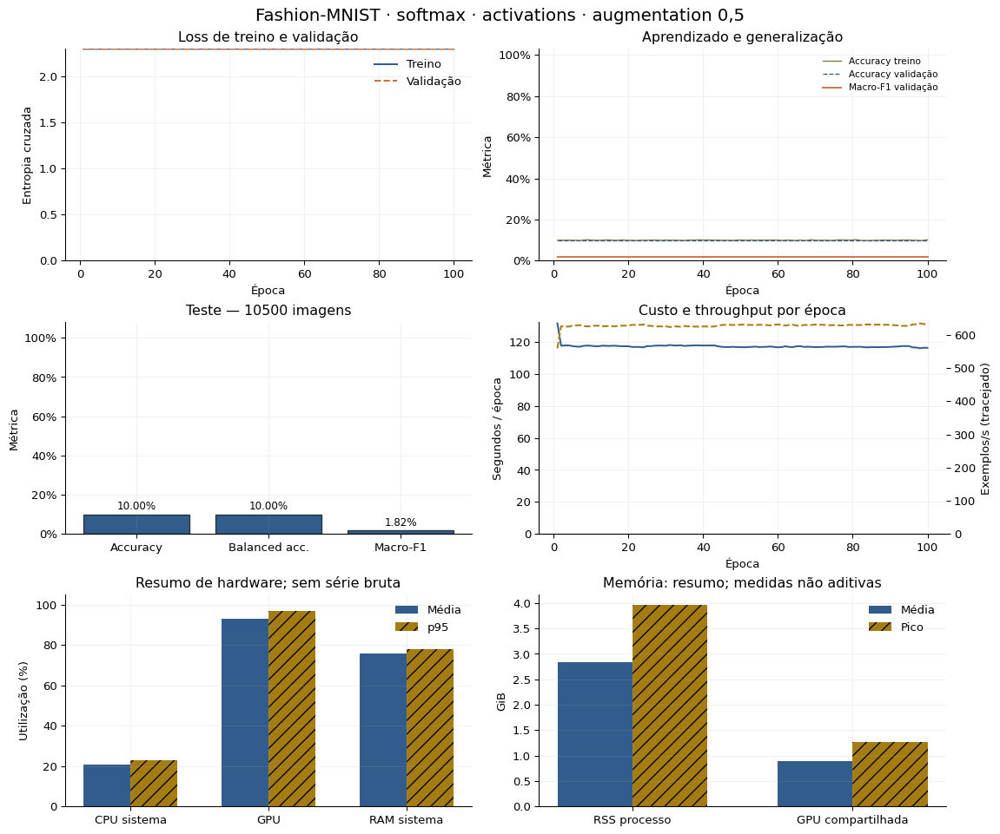

**Resultado:** accuracy 10.00%, balanced accuracy 10.00%, Macro-F1 1.82%, precisão macro 1.00%, recall macro 10.00%, AUC OVR 0.5000 e loss de teste 2.3026. **Custo:** 3.25 h pela soma das épocas; 627.44 exemplos/s, ponderando pelo tempo; avaliação final 11.13 s. **Curva:** melhor Macro-F1 de validação 1.82% na época 1; última época 1.82%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. A balanced accuracy próxima a 1/n_classes e o F1 muito baixo são compatíveis com colapso para poucas classes; confirme a distribuição por classe na tabela de evidências. Maior uso de GPU não garante aprendizado. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (90.04%); esta condição ficou -88.223 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 93.20%, CPU do processo média 85.54%, RAM média 75.76%; pico de RSS 3.97 GiB e de memória GPU compartilhada 1.27 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 0, F1 0.00% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [63]:
plot_run('controlled-augmentation05-activations-mac2|activations|fashion_mnist|softmax')
explain_run('controlled-augmentation05-activations-mac2|activations|fashion_mnist|softmax')

#### kmnist · relu

Identidade: `controlled-augmentation05-activations-mac2|activations|kmnist|relu`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/kmnist/relu/kmnist/runs/kmnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

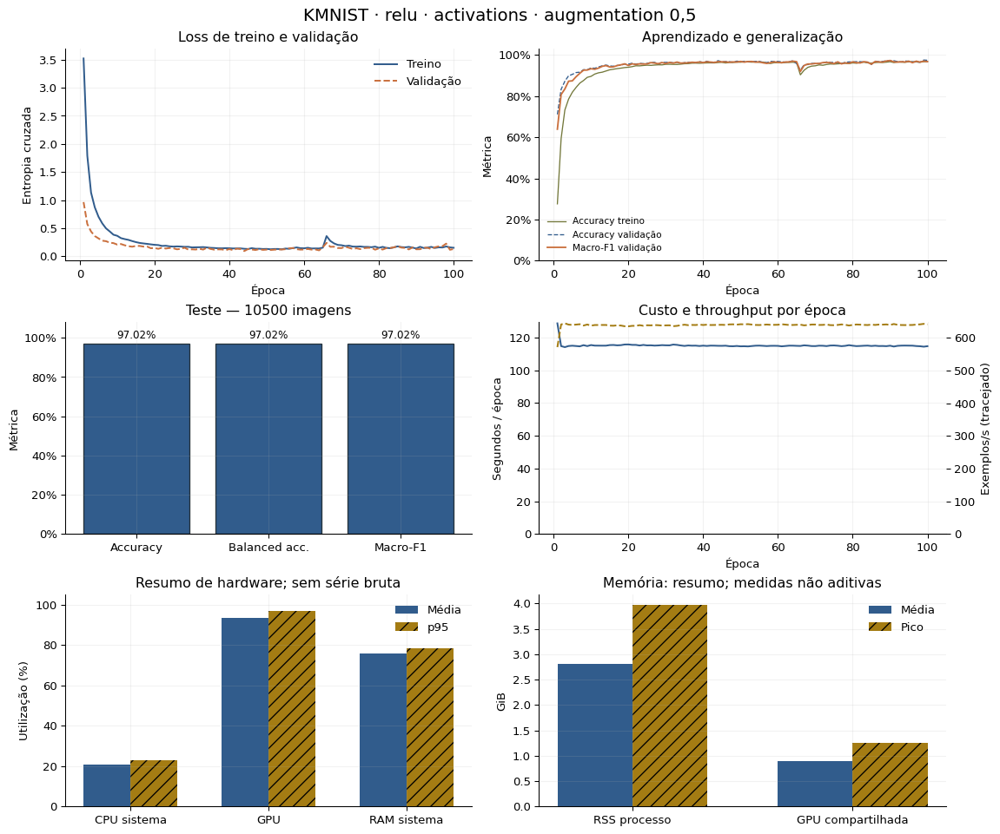

**Resultado:** accuracy 97.02%, balanced accuracy 97.02%, Macro-F1 97.02%, precisão macro 97.06%, recall macro 97.02%, AUC OVR 0.9989 e loss de teste 0.1384. **Custo:** 3.20 h pela soma das épocas; 638.41 exemplos/s, ponderando pelo tempo; avaliação final 10.76 s. **Curva:** melhor Macro-F1 de validação 97.31% na época 90; última época 96.78%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (97.11%); esta condição ficou -0.098 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 93.37%, CPU do processo média 85.05%, RAM média 76.01%; pico de RSS 3.97 GiB e de memória GPU compartilhada 1.26 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 4, F1 95.03% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [64]:
plot_run('controlled-augmentation05-activations-mac2|activations|kmnist|relu')
explain_run('controlled-augmentation05-activations-mac2|activations|kmnist|relu')

#### kmnist · sigmoid

Identidade: `controlled-augmentation05-activations-mac2|activations|kmnist|sigmoid`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/kmnist/sigmoid/kmnist/runs/kmnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

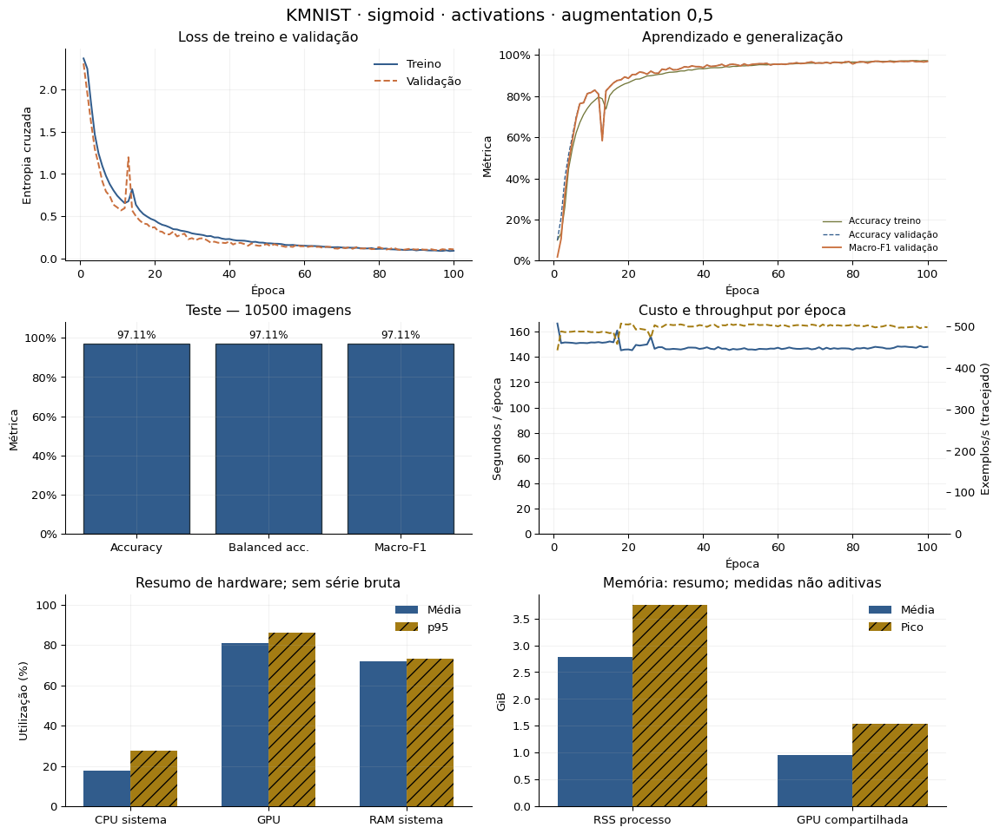

**Resultado:** accuracy 97.11%, balanced accuracy 97.11%, Macro-F1 97.11%, precisão macro 97.13%, recall macro 97.11%, AUC OVR 0.9988 e loss de teste 0.1064. **Custo:** 4.11 h pela soma das épocas; 496.74 exemplos/s, ponderando pelo tempo; avaliação final 21.20 s. **Curva:** melhor Macro-F1 de validação 97.12% na época 96; última época 96.89%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (97.11%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 80.90%, CPU do processo média 77.91%, RAM média 71.95%; pico de RSS 3.76 GiB e de memória GPU compartilhada 1.53 GiB. **Reconciliação:** resumo de treino 3.43 h versus soma das épocas 4.11 h; diferença 0.68 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 2, F1 95.71% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [65]:
plot_run('controlled-augmentation05-activations-mac2|activations|kmnist|sigmoid')
explain_run('controlled-augmentation05-activations-mac2|activations|kmnist|sigmoid')

#### kmnist · softmax

Identidade: `controlled-augmentation05-activations-mac2|activations|kmnist|softmax`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/kmnist/softmax/kmnist/runs/kmnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

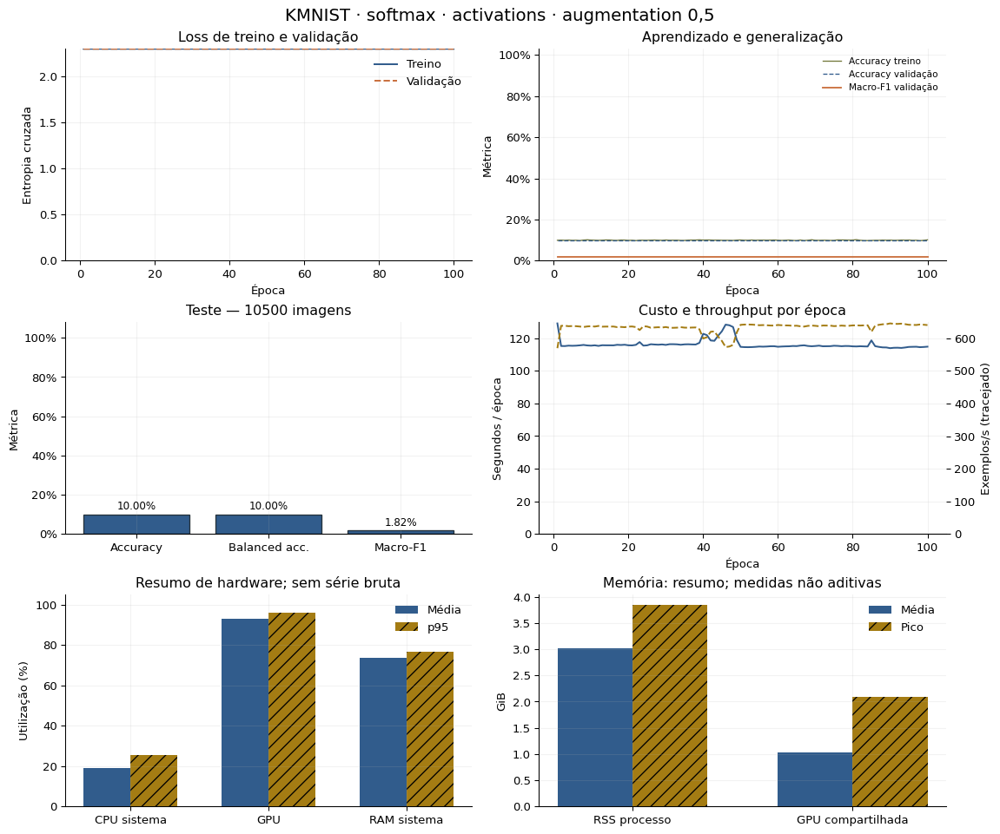

**Resultado:** accuracy 10.00%, balanced accuracy 10.00%, Macro-F1 1.82%, precisão macro 1.00%, recall macro 10.00%, AUC OVR 0.5000 e loss de teste 2.3026. **Custo:** 3.23 h pela soma das épocas; 632.67 exemplos/s, ponderando pelo tempo; avaliação final 10.47 s. **Curva:** melhor Macro-F1 de validação 1.82% na época 1; última época 1.82%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. A balanced accuracy próxima a 1/n_classes e o F1 muito baixo são compatíveis com colapso para poucas classes; confirme a distribuição por classe na tabela de evidências. Maior uso de GPU não garante aprendizado. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (97.11%); esta condição ficou -95.296 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 92.99%, CPU do processo média 84.13%, RAM média 73.47%; pico de RSS 3.85 GiB e de memória GPU compartilhada 2.09 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 0, F1 0.00% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [66]:
plot_run('controlled-augmentation05-activations-mac2|activations|kmnist|softmax')
explain_run('controlled-augmentation05-activations-mac2|activations|kmnist|softmax')

#### emnist_balanced · relu

Identidade: `controlled-augmentation05-activations-mac2|activations|emnist_balanced|relu`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/emnist_balanced/relu/emnist_balanced/runs/emnist_balanced__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

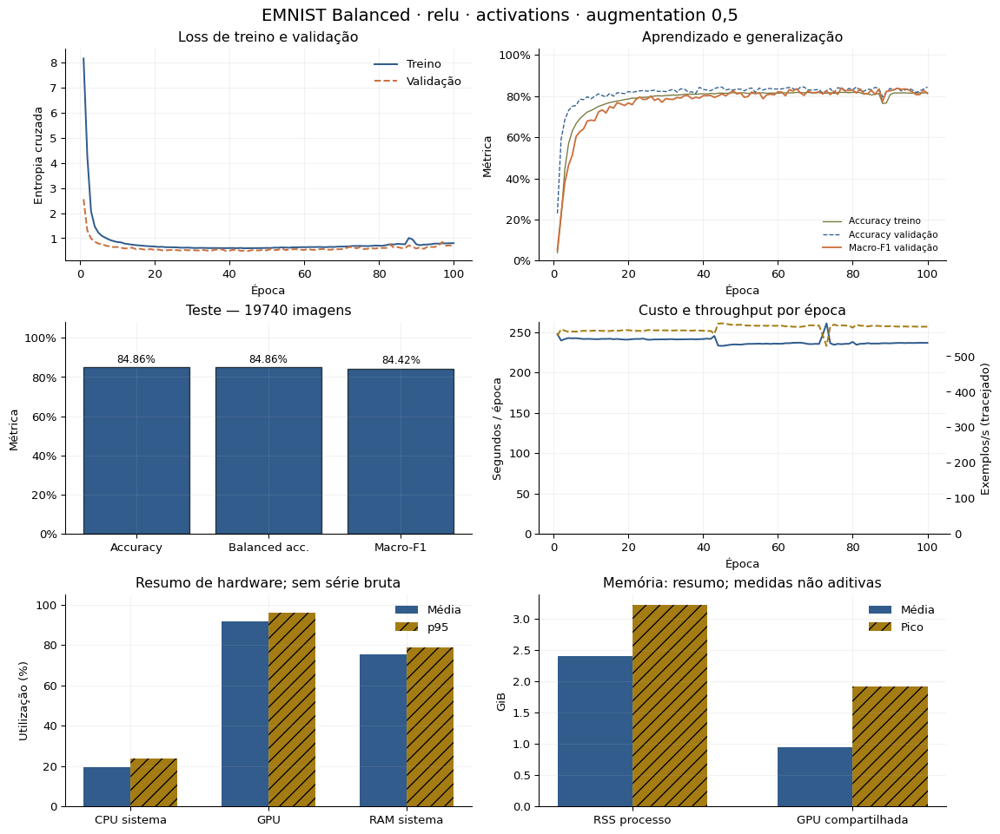

**Resultado:** accuracy 84.86%, balanced accuracy 84.86%, Macro-F1 84.42%, precisão macro 85.95%, recall macro 84.86%, AUC OVR 0.9941 e loss de teste 0.5687. **Custo:** 6.63 h pela soma das épocas; 578.53 exemplos/s, ponderando pelo tempo; avaliação final 18.54 s. **Curva:** melhor Macro-F1 de validação 84.02% na época 77; última época 81.30%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (84.93%); esta condição ficou -0.513 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 91.82%, CPU do processo média 99.51%, RAM média 75.20%; pico de RSS 3.23 GiB e de memória GPU compartilhada 1.92 GiB. **Reconciliação:** resumo de treino 3.81 h versus soma das épocas 6.63 h; diferença 2.82 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 21, F1 43.04% e suporte 420 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [67]:
plot_run('controlled-augmentation05-activations-mac2|activations|emnist_balanced|relu')
explain_run('controlled-augmentation05-activations-mac2|activations|emnist_balanced|relu')

#### emnist_balanced · sigmoid

Identidade: `controlled-augmentation05-activations-mac2|activations|emnist_balanced|sigmoid`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/emnist_balanced/sigmoid/emnist_balanced/runs/emnist_balanced__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

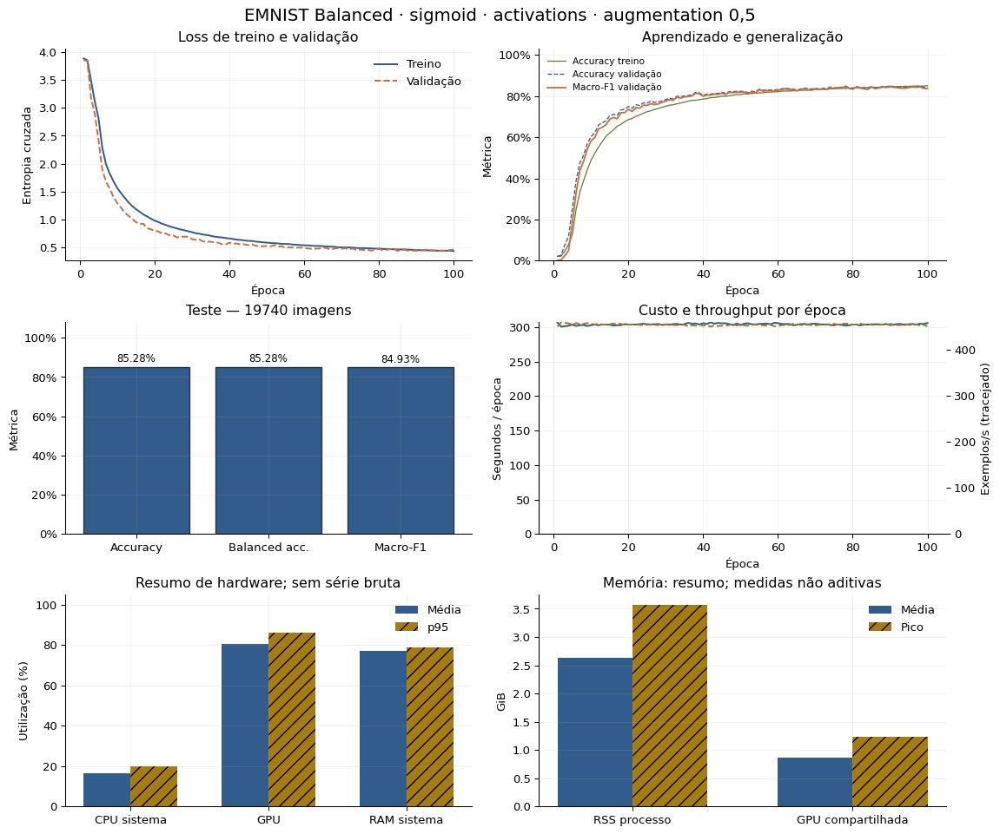

**Resultado:** accuracy 85.28%, balanced accuracy 85.28%, Macro-F1 84.93%, precisão macro 85.93%, recall macro 85.28%, AUC OVR 0.9961 e loss de teste 0.4362. **Custo:** 8.44 h pela soma das épocas; 454.83 exemplos/s, ponderando pelo tempo; avaliação final 38.25 s. **Curva:** melhor Macro-F1 de validação 84.64% na época 78; última época 83.60%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (84.93%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 80.52%, CPU do processo média 88.65%, RAM média 77.04%; pico de RSS 3.57 GiB e de memória GPU compartilhada 1.24 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 21, F1 36.76% e suporte 420 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [68]:
plot_run('controlled-augmentation05-activations-mac2|activations|emnist_balanced|sigmoid')
explain_run('controlled-augmentation05-activations-mac2|activations|emnist_balanced|sigmoid')

#### emnist_balanced · softmax

Identidade: `controlled-augmentation05-activations-mac2|activations|emnist_balanced|softmax`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/emnist_balanced/softmax/emnist_balanced/runs/emnist_balanced__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

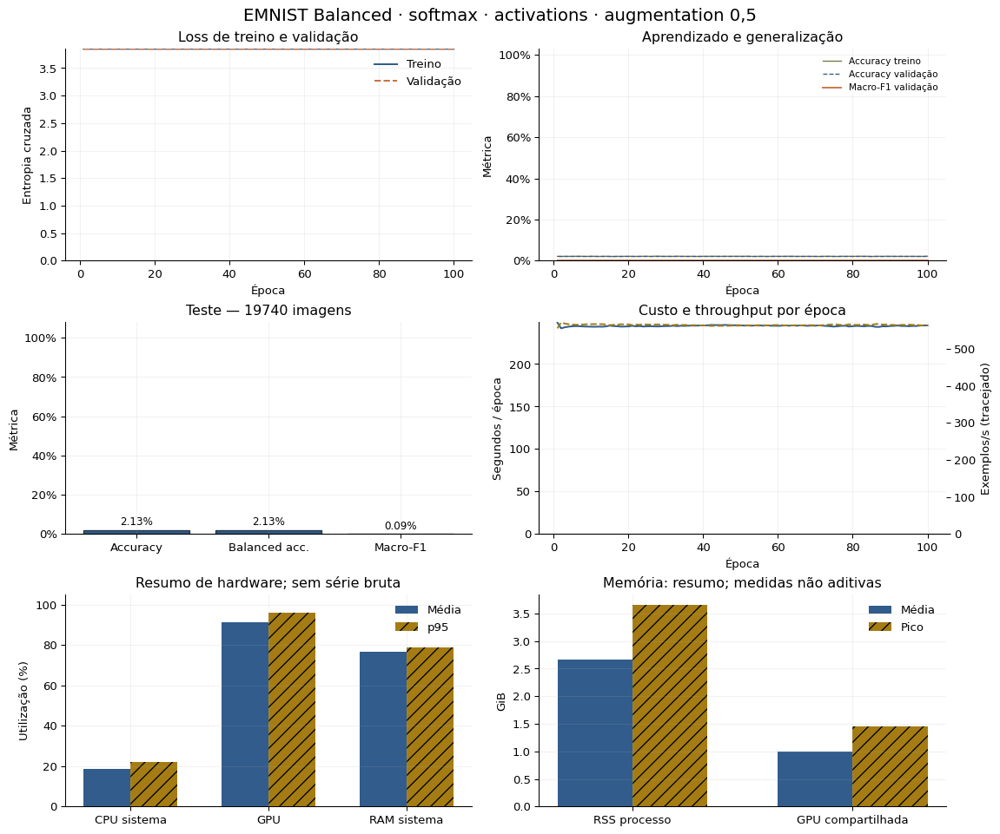

**Resultado:** accuracy 2.13%, balanced accuracy 2.13%, Macro-F1 0.09%, precisão macro 0.05%, recall macro 2.13%, AUC OVR 0.5000 e loss de teste 3.8502. **Custo:** 6.80 h pela soma das épocas; 564.33 exemplos/s, ponderando pelo tempo; avaliação final 18.75 s. **Curva:** melhor Macro-F1 de validação 0.09% na época 1; última época 0.09%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. A balanced accuracy próxima a 1/n_classes e o F1 muito baixo são compatíveis com colapso para poucas classes; confirme a distribuição por classe na tabela de evidências. Maior uso de GPU não garante aprendizado. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (84.93%); esta condição ficou -84.840 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 91.28%, CPU do processo média 97.33%, RAM média 76.53%; pico de RSS 3.66 GiB e de memória GPU compartilhada 1.46 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 0, F1 0.00% e suporte 420 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [69]:
plot_run('controlled-augmentation05-activations-mac2|activations|emnist_balanced|softmax')
explain_run('controlled-augmentation05-activations-mac2|activations|emnist_balanced|softmax')

#### cifar10 · relu

Identidade: `controlled-augmentation05-activations-mac2|activations|cifar10|relu`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/cifar10/relu/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

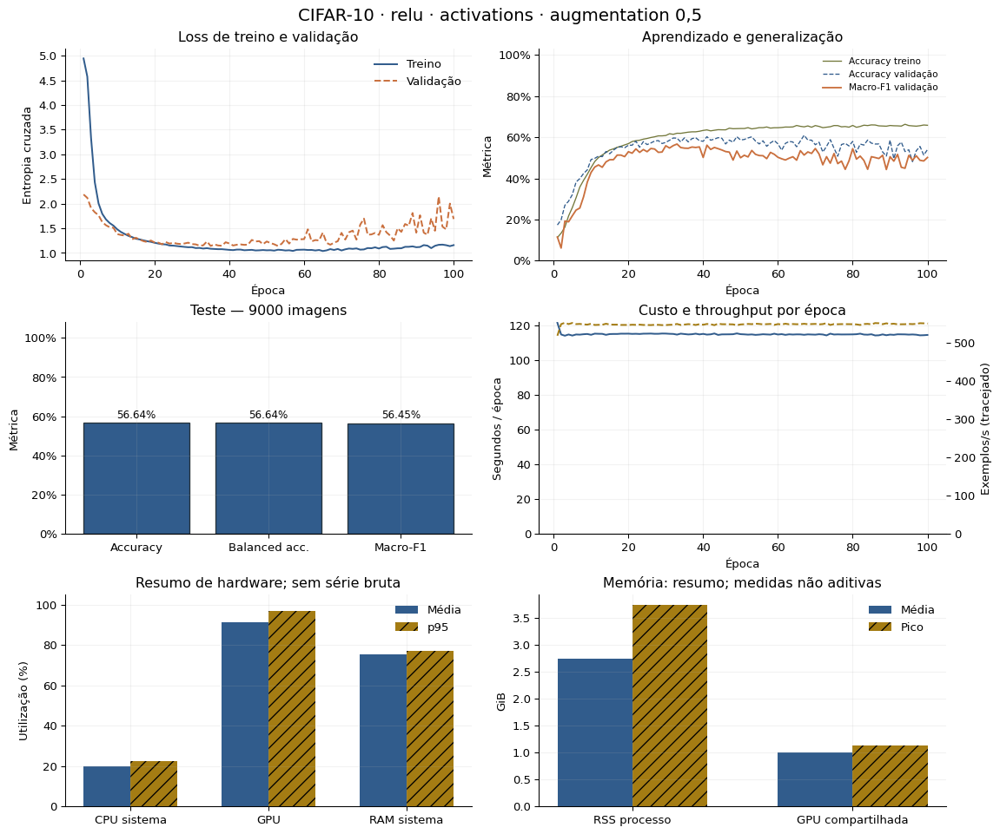

**Resultado:** accuracy 56.64%, balanced accuracy 56.64%, Macro-F1 56.45%, precisão macro 58.81%, recall macro 56.64%, AUC OVR 0.8987 e loss de teste 1.1607. **Custo:** 3.20 h pela soma das épocas; 547.24 exemplos/s, ponderando pelo tempo; avaliação final 9.96 s. **Curva:** melhor Macro-F1 de validação 56.70% na época 33; última época 50.18%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (63.90%); esta condição ficou -7.452 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 91.33%, CPU do processo média 96.86%, RAM média 75.44%; pico de RSS 3.75 GiB e de memória GPU compartilhada 1.14 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** cat, F1 24.62% e suporte 900 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [70]:
plot_run('controlled-augmentation05-activations-mac2|activations|cifar10|relu')
explain_run('controlled-augmentation05-activations-mac2|activations|cifar10|relu')

#### cifar10 · sigmoid

Identidade: `controlled-augmentation05-activations-mac2|activations|cifar10|sigmoid`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/cifar10/sigmoid/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

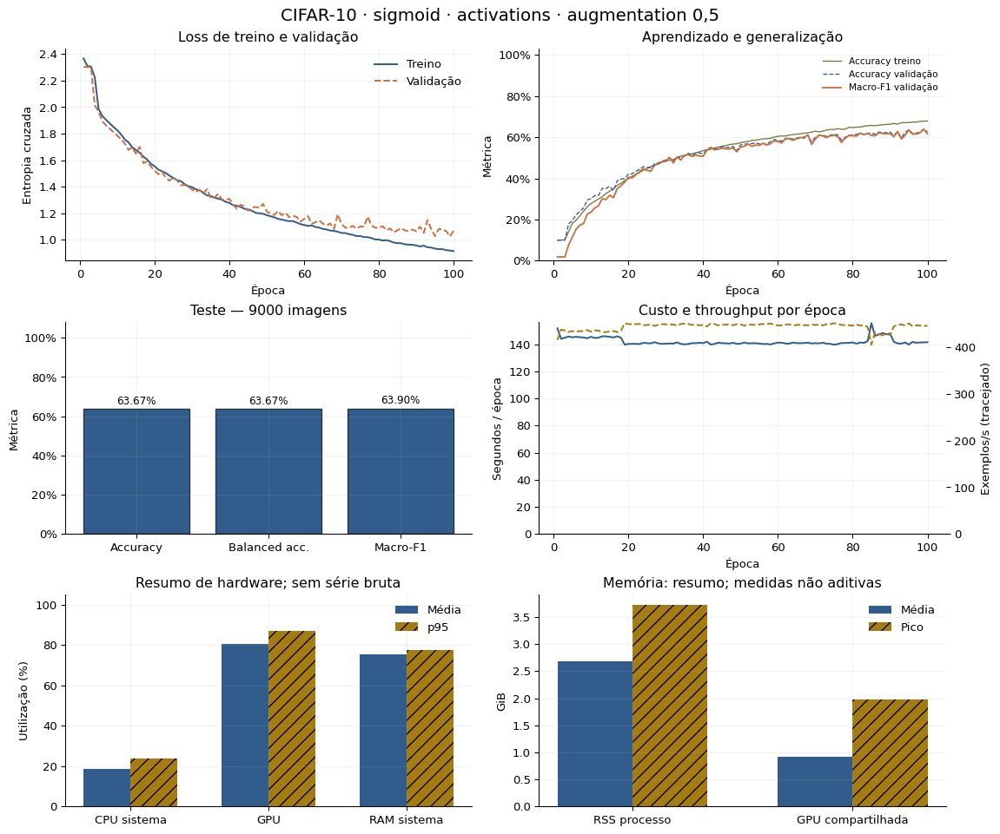

**Resultado:** accuracy 63.67%, balanced accuracy 63.67%, Macro-F1 63.90%, precisão macro 64.79%, recall macro 63.67%, AUC OVR 0.9383 e loss de teste 1.0122. **Custo:** 3.95 h pela soma das épocas; 443.51 exemplos/s, ponderando pelo tempo; avaliação final 17.89 s. **Curva:** melhor Macro-F1 de validação 63.94% na época 99; última época 61.71%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (63.90%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 80.73%, CPU do processo média 89.02%, RAM média 75.25%; pico de RSS 3.73 GiB e de memória GPU compartilhada 1.98 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** cat, F1 41.53% e suporte 900 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [71]:
plot_run('controlled-augmentation05-activations-mac2|activations|cifar10|sigmoid')
explain_run('controlled-augmentation05-activations-mac2|activations|cifar10|sigmoid')

#### cifar10 · softmax

Identidade: `controlled-augmentation05-activations-mac2|activations|cifar10|softmax`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/cifar10/softmax/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

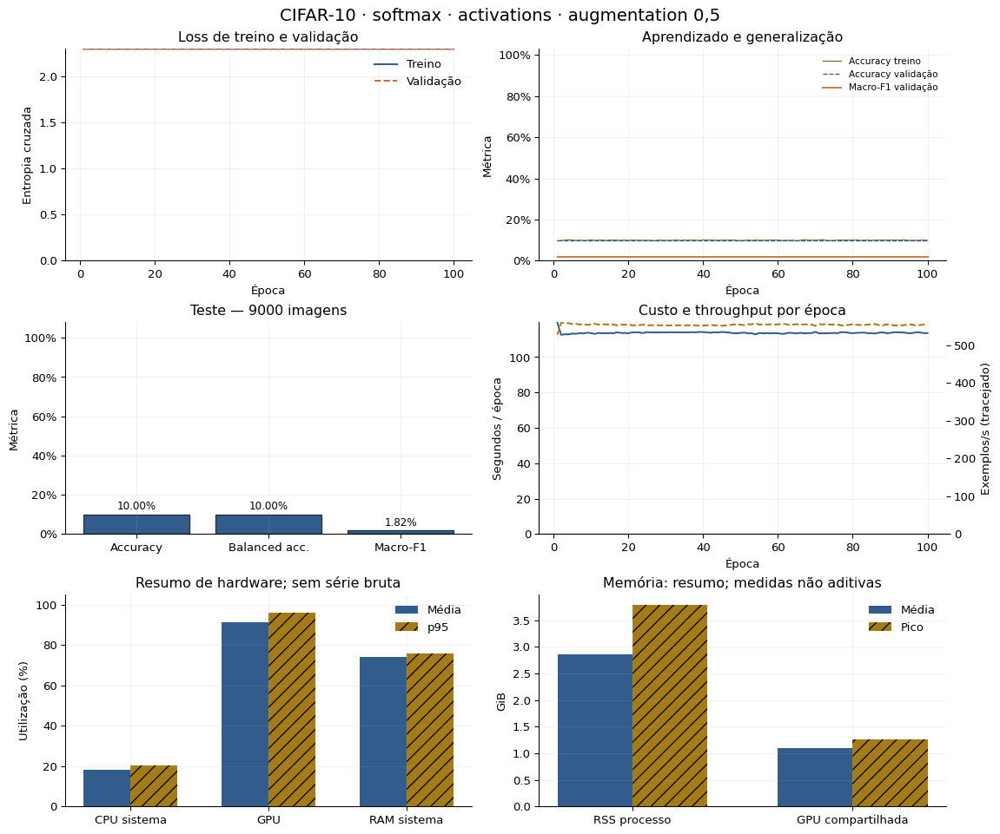

**Resultado:** accuracy 10.00%, balanced accuracy 10.00%, Macro-F1 1.82%, precisão macro 1.00%, recall macro 10.00%, AUC OVR 0.5000 e loss de teste 2.3026. **Custo:** 3.16 h pela soma das épocas; 553.92 exemplos/s, ponderando pelo tempo; avaliação final 10.09 s. **Curva:** melhor Macro-F1 de validação 1.82% na época 1; última época 1.82%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. A balanced accuracy próxima a 1/n_classes e o F1 muito baixo são compatíveis com colapso para poucas classes; confirme a distribuição por classe na tabela de evidências. Maior uso de GPU não garante aprendizado. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (63.90%); esta condição ficou -62.080 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 91.46%, CPU do processo média 98.00%, RAM média 74.30%; pico de RSS 3.79 GiB e de memória GPU compartilhada 1.27 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** automobile, F1 0.00% e suporte 900 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [72]:
plot_run('controlled-augmentation05-activations-mac2|activations|cifar10|softmax')
explain_run('controlled-augmentation05-activations-mac2|activations|cifar10|softmax')

#### cifar100_coarse · relu

Identidade: `controlled-augmentation05-activations-mac2|activations|cifar100_coarse|relu`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/cifar100_coarse/relu/cifar100_coarse/runs/cifar100_coarse__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

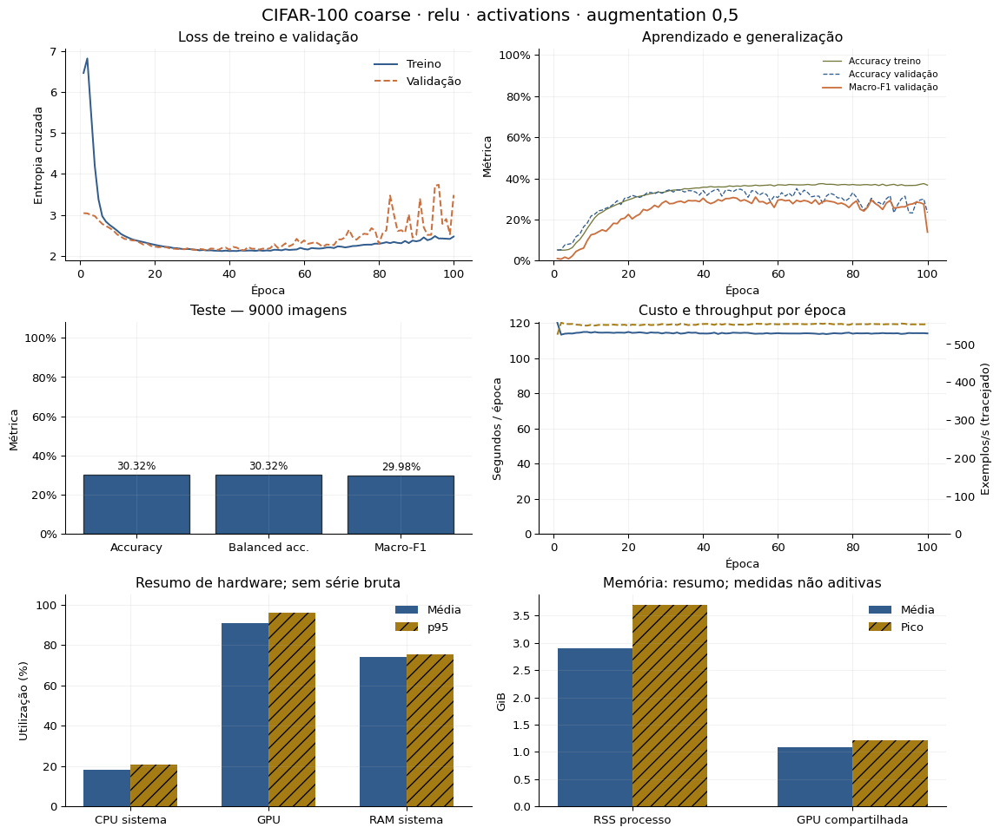

**Resultado:** accuracy 30.32%, balanced accuracy 30.32%, Macro-F1 29.98%, precisão macro 36.90%, recall macro 30.32%, AUC OVR 0.7920 e loss de teste 2.2578. **Custo:** 3.17 h pela soma das épocas; 551.65 exemplos/s, ponderando pelo tempo; avaliação final 9.75 s. **Curva:** melhor Macro-F1 de validação 30.94% na época 54; última época 13.89%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (35.02%); esta condição ficou -5.037 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 91.03%, CPU do processo média 97.07%, RAM média 73.93%; pico de RSS 3.70 GiB e de memória GPU compartilhada 1.21 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** non-insect_invertebrates, F1 0.00% e suporte 450 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [73]:
plot_run('controlled-augmentation05-activations-mac2|activations|cifar100_coarse|relu')
explain_run('controlled-augmentation05-activations-mac2|activations|cifar100_coarse|relu')

#### cifar100_coarse · sigmoid

Identidade: `controlled-augmentation05-activations-mac2|activations|cifar100_coarse|sigmoid`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/cifar100_coarse/sigmoid/cifar100_coarse/runs/cifar100_coarse__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

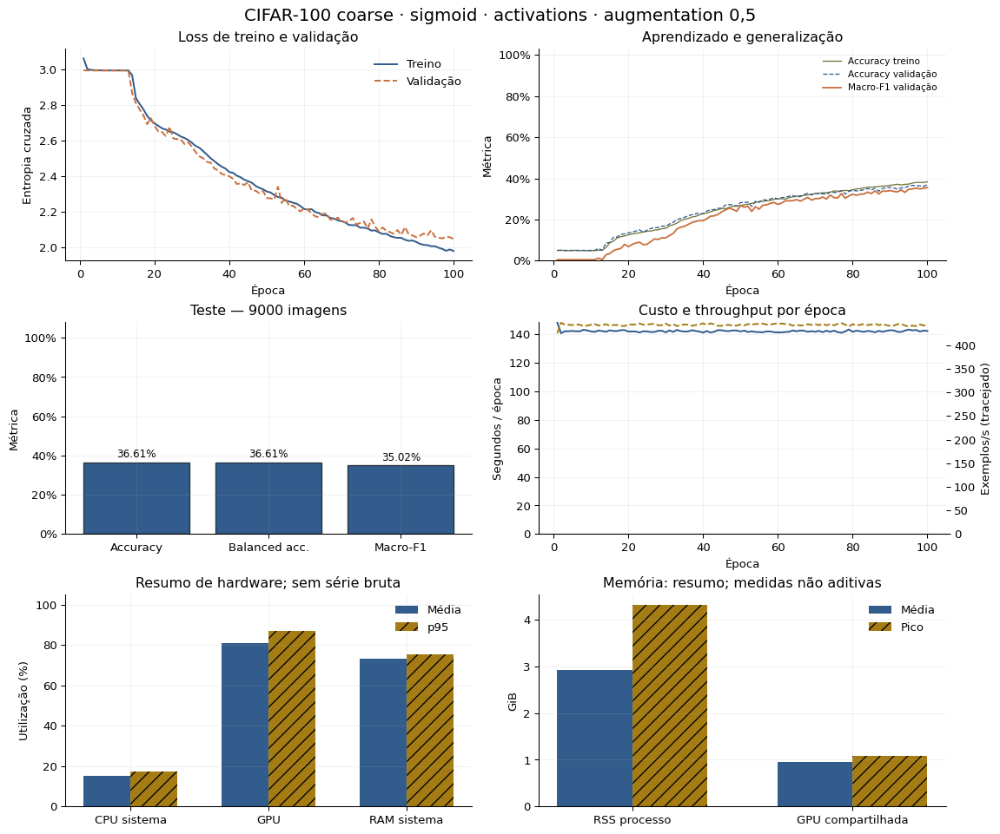

**Resultado:** accuracy 36.61%, balanced accuracy 36.61%, Macro-F1 35.02%, precisão macro 36.26%, recall macro 36.61%, AUC OVR 0.8552 e loss de teste 2.0522. **Custo:** 3.95 h pela soma das épocas; 443.24 exemplos/s, ponderando pelo tempo; avaliação final 18.76 s. **Curva:** melhor Macro-F1 de validação 35.60% na época 100; última época 35.60%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (35.02%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 80.82%, CPU do processo média 88.02%, RAM média 73.40%; pico de RSS 4.32 GiB e de memória GPU compartilhada 1.08 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** reptiles, F1 4.32% e suporte 450 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [74]:
plot_run('controlled-augmentation05-activations-mac2|activations|cifar100_coarse|sigmoid')
explain_run('controlled-augmentation05-activations-mac2|activations|cifar100_coarse|sigmoid')

#### cifar100_coarse · softmax

Identidade: `controlled-augmentation05-activations-mac2|activations|cifar100_coarse|softmax`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/cifar100_coarse/softmax/cifar100_coarse/runs/cifar100_coarse__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

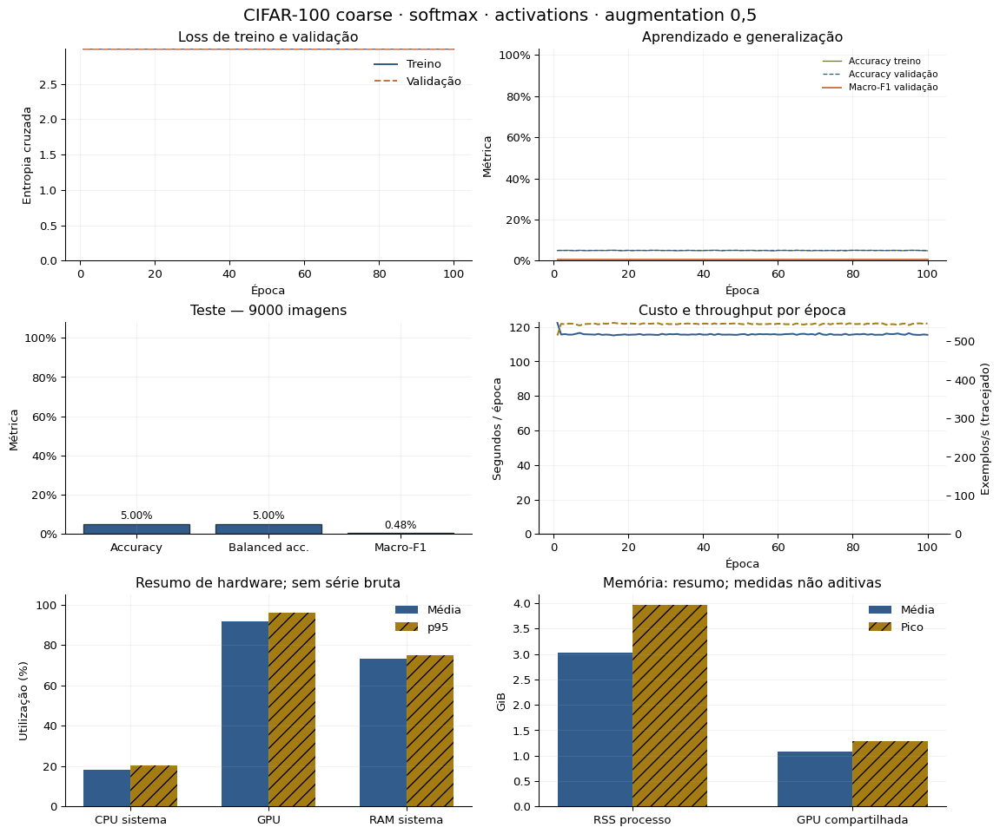

**Resultado:** accuracy 5.00%, balanced accuracy 5.00%, Macro-F1 0.48%, precisão macro 0.25%, recall macro 5.00%, AUC OVR 0.5000 e loss de teste 2.9957. **Custo:** 3.21 h pela soma das épocas; 544.45 exemplos/s, ponderando pelo tempo; avaliação final 9.85 s. **Curva:** melhor Macro-F1 de validação 0.48% na época 1; última época 0.48%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. A balanced accuracy próxima a 1/n_classes e o F1 muito baixo são compatíveis com colapso para poucas classes; confirme a distribuição por classe na tabela de evidências. Maior uso de GPU não garante aprendizado. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (35.02%); esta condição ficou -34.539 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 91.87%, CPU do processo média 97.99%, RAM média 73.29%; pico de RSS 3.97 GiB e de memória GPU compartilhada 1.28 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** aquatic_mammals, F1 0.00% e suporte 450 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [75]:
plot_run('controlled-augmentation05-activations-mac2|activations|cifar100_coarse|softmax')
explain_run('controlled-augmentation05-activations-mac2|activations|cifar100_coarse|softmax')

#### svhn · relu

Identidade: `controlled-augmentation05-activations-mac2|activations|svhn|relu`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/svhn/relu/svhn/runs/svhn__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

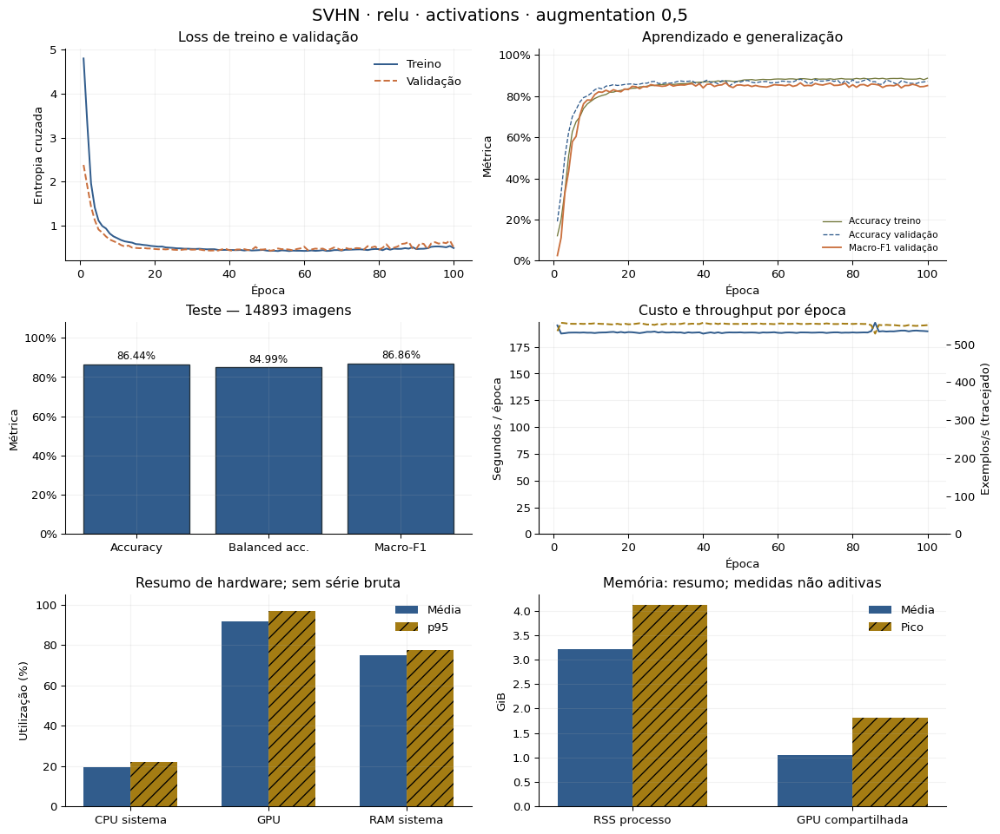

**Resultado:** accuracy 86.44%, balanced accuracy 84.99%, Macro-F1 86.86%, precisão macro 89.78%, recall macro 84.99%, AUC OVR 0.9860 e loss de teste 0.4234. **Custo:** 5.24 h pela soma das épocas; 552.44 exemplos/s, ponderando pelo tempo; avaliação final 15.27 s. **Curva:** melhor Macro-F1 de validação 86.52% na época 46; última época 85.12%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (87.07%); esta condição ficou -0.203 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 91.87%, CPU do processo média 96.58%, RAM média 74.99%; pico de RSS 4.12 GiB e de memória GPU compartilhada 1.82 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 2, F1 78.69% e suporte 2210 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [76]:
plot_run('controlled-augmentation05-activations-mac2|activations|svhn|relu')
explain_run('controlled-augmentation05-activations-mac2|activations|svhn|relu')

#### svhn · sigmoid

Identidade: `controlled-augmentation05-activations-mac2|activations|svhn|sigmoid`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/svhn/sigmoid/svhn/runs/svhn__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

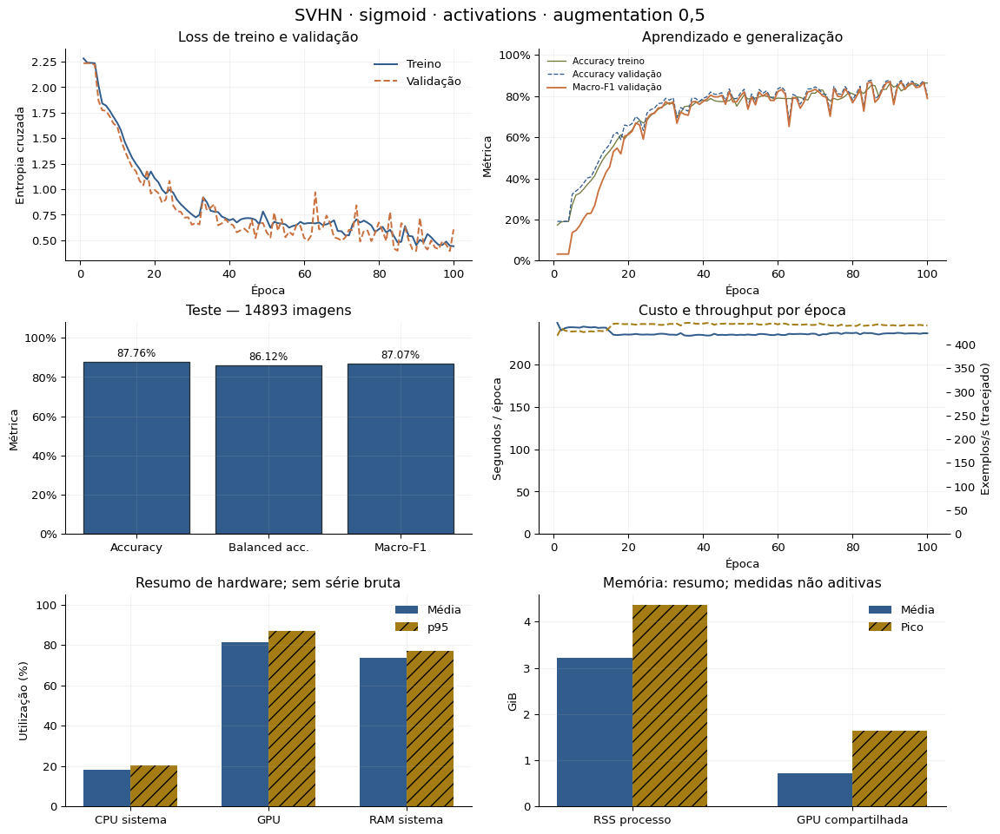

**Resultado:** accuracy 87.76%, balanced accuracy 86.12%, Macro-F1 87.07%, precisão macro 88.28%, recall macro 86.12%, AUC OVR 0.9896 e loss de teste 0.3869. **Custo:** 6.58 h pela soma das épocas; 440.09 exemplos/s, ponderando pelo tempo; avaliação final 29.92 s. **Curva:** melhor Macro-F1 de validação 86.97% na época 90; última época 78.86%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (87.07%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 81.33%, CPU do processo média 87.72%, RAM média 73.64%; pico de RSS 4.37 GiB e de memória GPU compartilhada 1.63 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 3, F1 81.30% e suporte 1707 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [77]:
plot_run('controlled-augmentation05-activations-mac2|activations|svhn|sigmoid')
explain_run('controlled-augmentation05-activations-mac2|activations|svhn|sigmoid')

#### svhn · softmax

Identidade: `controlled-augmentation05-activations-mac2|activations|svhn|softmax`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/svhn/softmax/svhn/runs/svhn__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

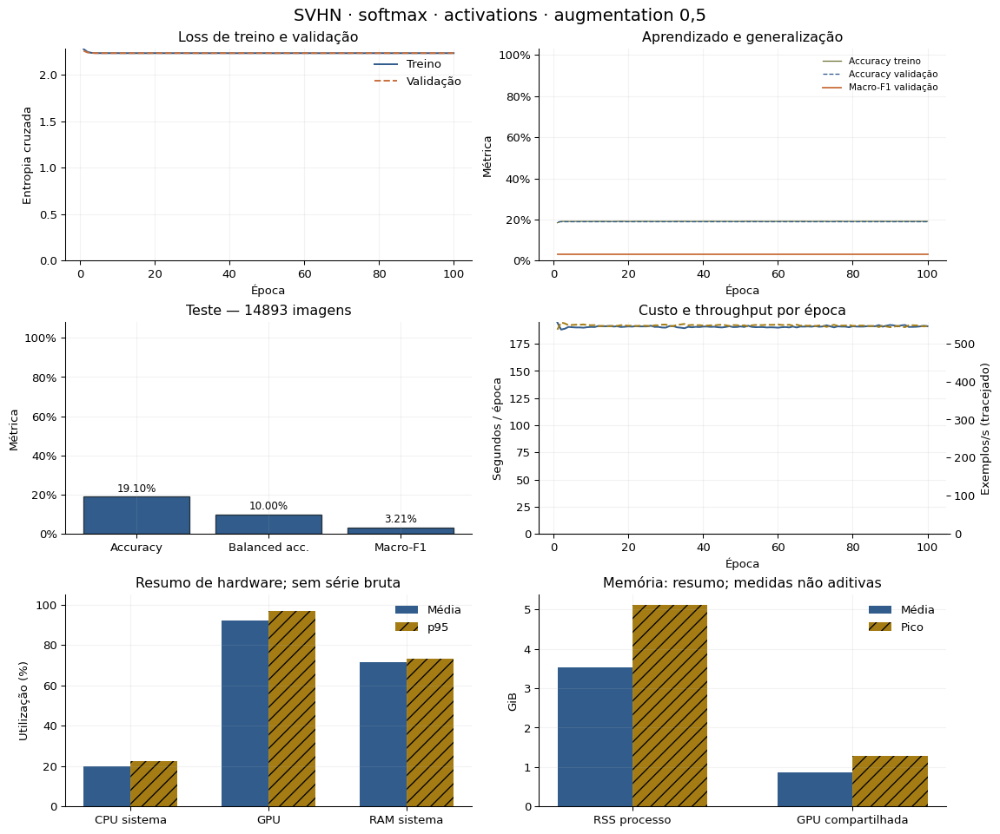

**Resultado:** accuracy 19.10%, balanced accuracy 10.00%, Macro-F1 3.21%, precisão macro 1.91%, recall macro 10.00%, AUC OVR 0.5000 e loss de teste 2.2578. **Custo:** 5.30 h pela soma das épocas; 546.61 exemplos/s, ponderando pelo tempo; avaliação final 15.97 s. **Curva:** melhor Macro-F1 de validação 3.21% na época 1; última época 3.21%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. A balanced accuracy próxima a 1/n_classes e o F1 muito baixo são compatíveis com colapso para poucas classes; confirme a distribuição por classe na tabela de evidências. Maior uso de GPU não garante aprendizado. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (87.07%); esta condição ficou -83.859 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 92.36%, CPU do processo média 96.73%, RAM média 71.59%; pico de RSS 5.12 GiB e de memória GPU compartilhada 1.28 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 0, F1 0.00% e suporte 1004 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [78]:
plot_run('controlled-augmentation05-activations-mac2|activations|svhn|softmax')
explain_run('controlled-augmentation05-activations-mac2|activations|svhn|softmax')

#### gtsrb · relu

Identidade: `controlled-augmentation05-activations-mac2|activations|gtsrb|relu`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/gtsrb/relu/gtsrb/runs/gtsrb__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

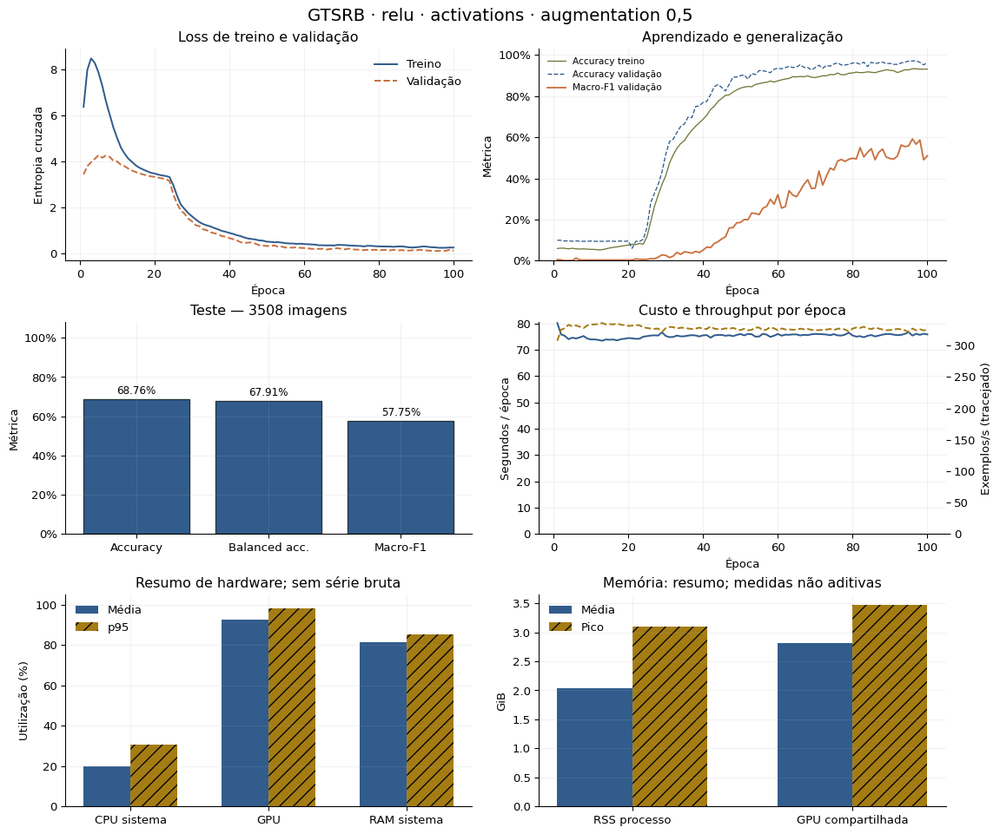

**Resultado:** accuracy 68.76%, balanced accuracy 67.91%, Macro-F1 57.75%, precisão macro 62.13%, recall macro 67.91%, AUC OVR 0.9968 e loss de teste 0.1083. **Custo:** 2.09 h pela soma das épocas; 327.45 exemplos/s, ponderando pelo tempo; avaliação final 7.35 s. **Curva:** melhor Macro-F1 de validação 59.18% na época 96; última época 50.96%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** relu teve o maior Macro-F1 (57.75%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 92.71%, CPU do processo média 76.01%, RAM média 81.56%; pico de RSS 3.09 GiB e de memória GPU compartilhada 3.48 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 28, F1 0.00% e suporte 22 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [79]:
plot_run('controlled-augmentation05-activations-mac2|activations|gtsrb|relu')
explain_run('controlled-augmentation05-activations-mac2|activations|gtsrb|relu')

#### gtsrb · sigmoid

Identidade: `controlled-augmentation05-activations-mac2|activations|gtsrb|sigmoid`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/gtsrb/sigmoid/gtsrb/runs/gtsrb__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

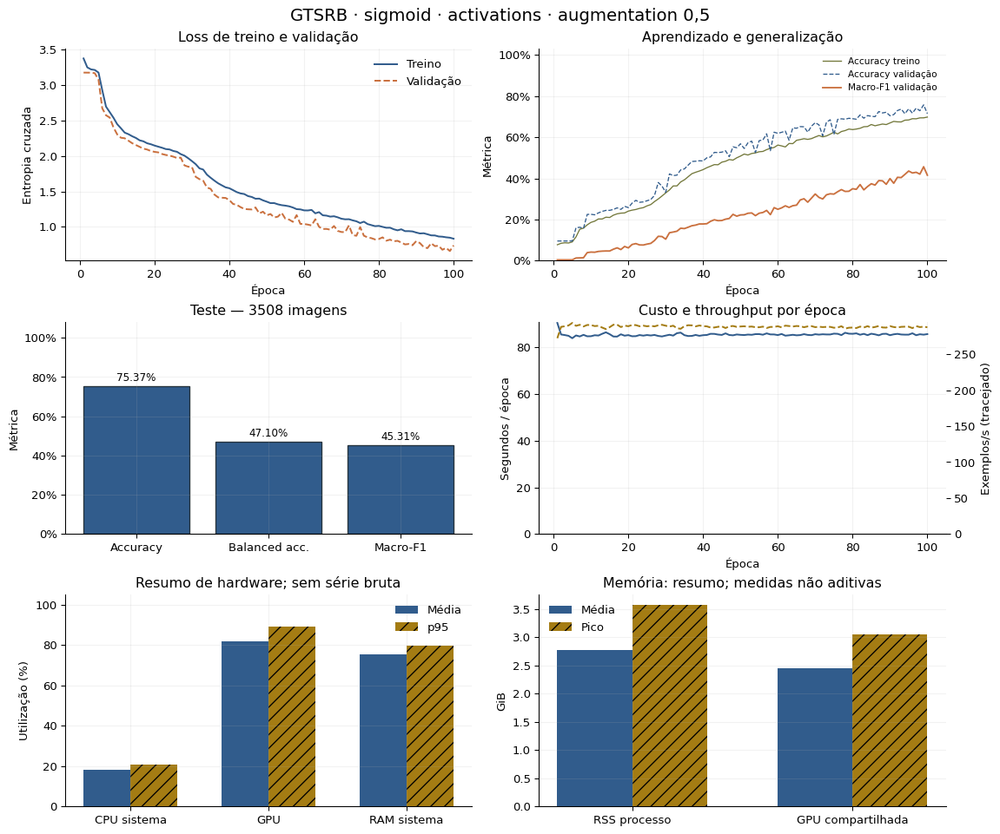

**Resultado:** accuracy 75.37%, balanced accuracy 47.10%, Macro-F1 45.31%, precisão macro 51.11%, recall macro 47.10%, AUC OVR 0.9901 e loss de teste 0.6583. **Custo:** 2.38 h pela soma das épocas; 288.31 exemplos/s, ponderando pelo tempo; avaliação final 9.18 s. **Curva:** melhor Macro-F1 de validação 45.67% na época 99; última época 41.55%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** relu teve o maior Macro-F1 (57.75%); esta condição ficou -12.440 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 81.81%, CPU do processo média 89.72%, RAM média 75.33%; pico de RSS 3.58 GiB e de memória GPU compartilhada 3.04 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 0, F1 0.00% e suporte 31 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [80]:
plot_run('controlled-augmentation05-activations-mac2|activations|gtsrb|sigmoid')
explain_run('controlled-augmentation05-activations-mac2|activations|gtsrb|sigmoid')

#### gtsrb · softmax

Identidade: `controlled-augmentation05-activations-mac2|activations|gtsrb|softmax`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/gtsrb/softmax/gtsrb/runs/gtsrb__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

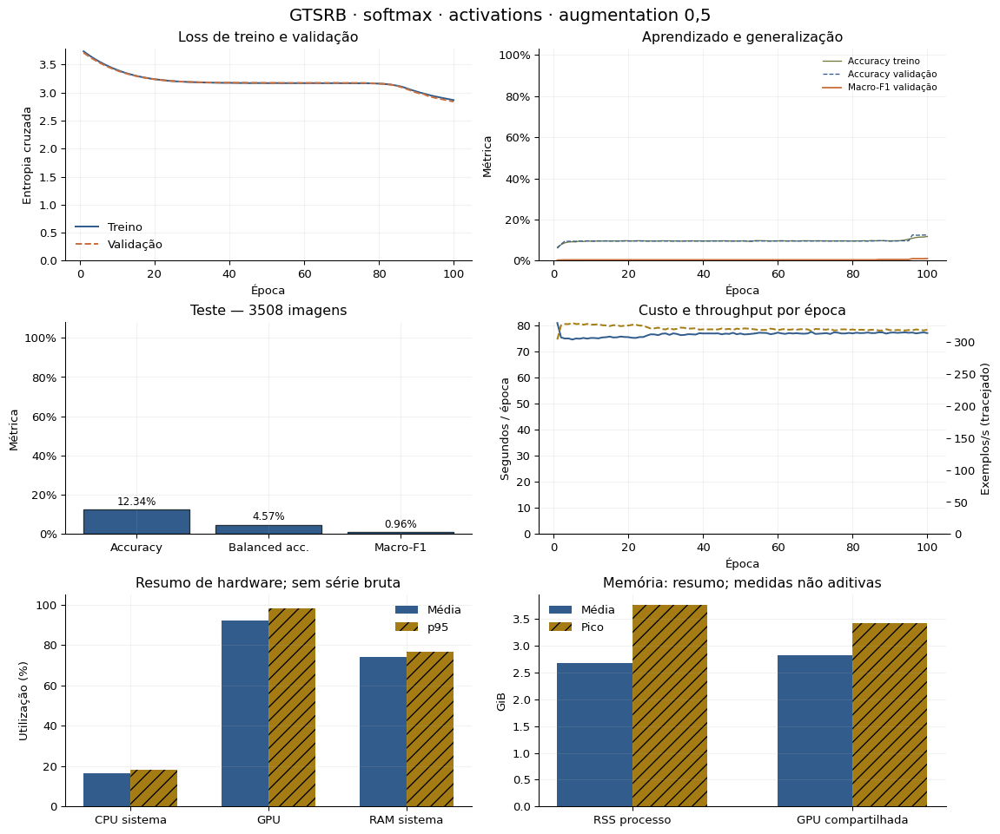

**Resultado:** accuracy 12.34%, balanced accuracy 4.57%, Macro-F1 0.96%, precisão macro 0.54%, recall macro 4.57%, AUC OVR 0.7940 e loss de teste 2.8331. **Custo:** 2.13 h pela soma das épocas; 321.37 exemplos/s, ponderando pelo tempo; avaliação final 7.45 s. **Curva:** melhor Macro-F1 de validação 1.05% na época 100; última época 1.05%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** relu teve o maior Macro-F1 (57.75%); esta condição ficou -56.797 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 92.22%, CPU do processo média 72.07%, RAM média 73.97%; pico de RSS 3.77 GiB e de memória GPU compartilhada 3.42 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 0, F1 0.00% e suporte 31 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [81]:
plot_run('controlled-augmentation05-activations-mac2|activations|gtsrb|softmax')
explain_run('controlled-augmentation05-activations-mac2|activations|gtsrb|softmax')

#### fer2013 · relu

Identidade: `controlled-augmentation05-activations-mac2|activations|fer2013|relu`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/fer2013/relu/fer2013/runs/fer2013__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

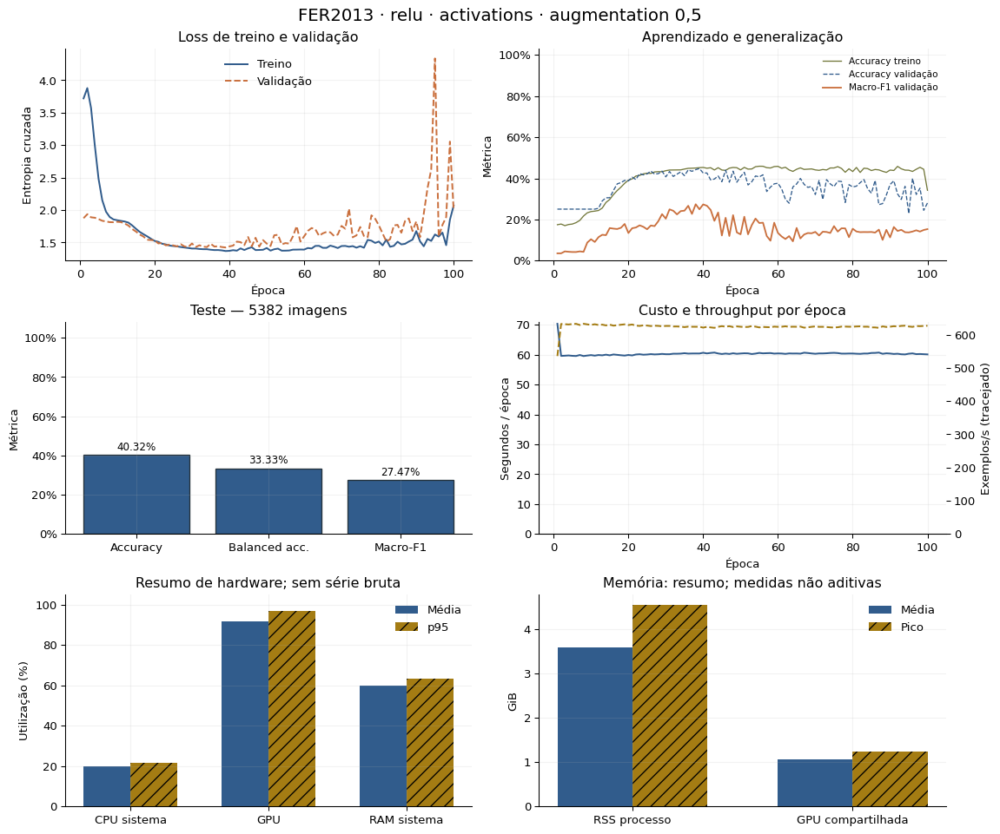

**Resultado:** accuracy 40.32%, balanced accuracy 33.33%, Macro-F1 27.47%, precisão macro 24.26%, recall macro 33.33%, AUC OVR 0.7322 e loss de teste 1.4326. **Custo:** 1.68 h pela soma das épocas; 624.39 exemplos/s, ponderando pelo tempo; avaliação final 6.35 s. **Curva:** melhor Macro-F1 de validação 27.43% na época 38; última época 15.33%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (37.54%); esta condição ficou -10.076 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 91.73%, CPU do processo média 83.11%, RAM média 60.08%; pico de RSS 4.54 GiB e de memória GPU compartilhada 1.23 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** angry, F1 0.00% e suporte 743 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [82]:
plot_run('controlled-augmentation05-activations-mac2|activations|fer2013|relu')
explain_run('controlled-augmentation05-activations-mac2|activations|fer2013|relu')

#### fer2013 · sigmoid

Identidade: `controlled-augmentation05-activations-mac2|activations|fer2013|sigmoid`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/fer2013/sigmoid/fer2013/runs/fer2013__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

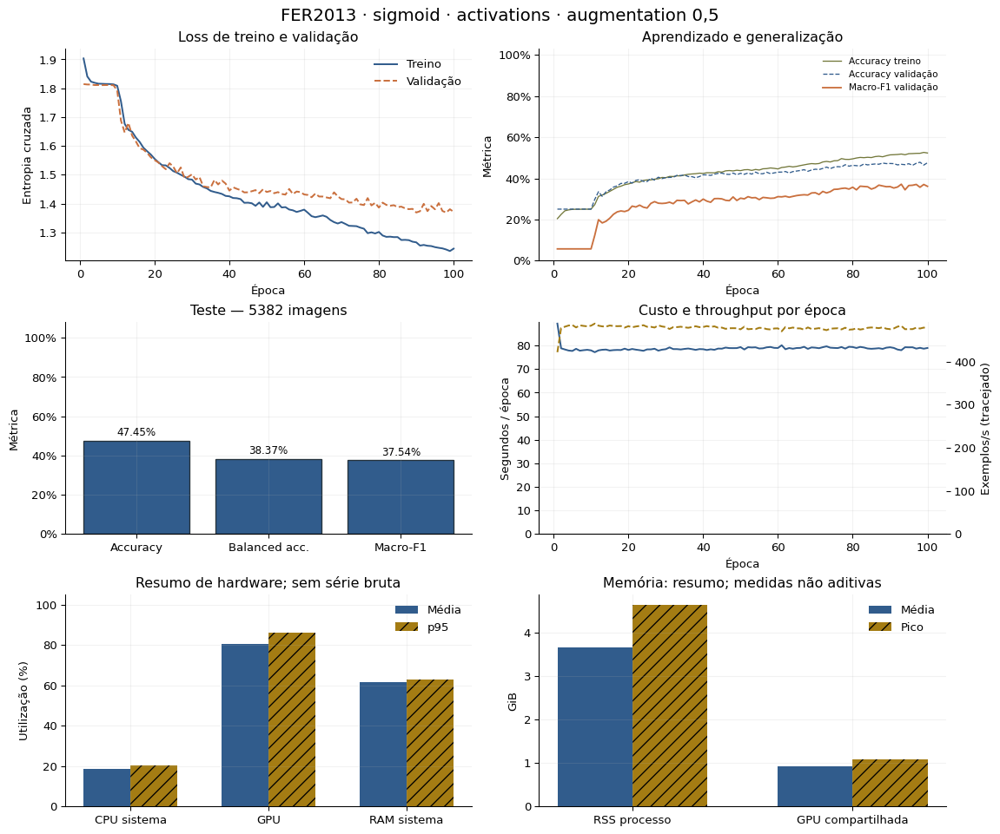

**Resultado:** accuracy 47.45%, balanced accuracy 38.37%, Macro-F1 37.54%, precisão macro 39.17%, recall macro 38.37%, AUC OVR 0.7901 e loss de teste 1.3520. **Custo:** 2.19 h pela soma das épocas; 478.19 exemplos/s, ponderando pelo tempo; avaliação final 11.22 s. **Curva:** melhor Macro-F1 de validação 37.17% na época 93; última época 36.15%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (37.54%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 80.45%, CPU do processo média 74.94%, RAM média 61.53%; pico de RSS 4.63 GiB e de memória GPU compartilhada 1.09 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** disgust, F1 0.00% e suporte 82 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [83]:
plot_run('controlled-augmentation05-activations-mac2|activations|fer2013|sigmoid')
explain_run('controlled-augmentation05-activations-mac2|activations|fer2013|sigmoid')

#### fer2013 · softmax

Identidade: `controlled-augmentation05-activations-mac2|activations|fer2013|softmax`. Fonte: `outputs/controlled-augmentation05-activations-mac2/activations/fer2013/softmax/fer2013/runs/fer2013__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

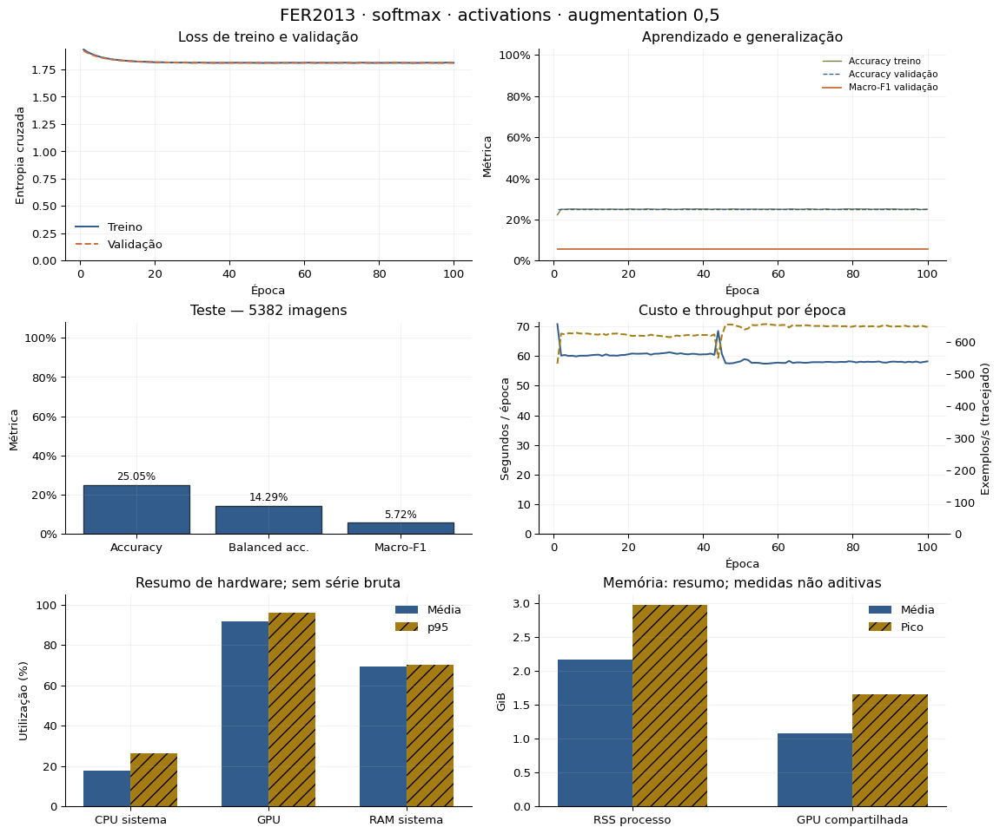

**Resultado:** accuracy 25.05%, balanced accuracy 14.29%, Macro-F1 5.72%, precisão macro 3.58%, recall macro 14.29%, AUC OVR 0.5000 e loss de teste 1.8104. **Custo:** 1.65 h pela soma das épocas; 635.72 exemplos/s, ponderando pelo tempo; avaliação final 5.91 s. **Curva:** melhor Macro-F1 de validação 5.72% na época 1; última época 5.72%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. A balanced accuracy próxima a 1/n_classes e o F1 muito baixo são compatíveis com colapso para poucas classes; confirme a distribuição por classe na tabela de evidências. Maior uso de GPU não garante aprendizado. **Comparação no mesmo dataset e fase:** sigmoid teve o maior Macro-F1 (37.54%); esta condição ficou -31.822 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 91.52%, CPU do processo média 85.43%, RAM média 69.20%; pico de RSS 2.98 GiB e de memória GPU compartilhada 1.66 GiB. **Reconciliação:** resumo de treino 0.92 h versus soma das épocas 1.65 h; diferença 0.73 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** angry, F1 0.00% e suporte 743 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [84]:
plot_run('controlled-augmentation05-activations-mac2|activations|fer2013|softmax')
explain_run('controlled-augmentation05-activations-mac2|activations|fer2013|softmax')

### Fichas — quantization

#### mnist · fp16

Identidade: `controlled-quantization-fast-mac-m4|quantization|mnist|fp16`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/mnist/fp16/mnist/runs/mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

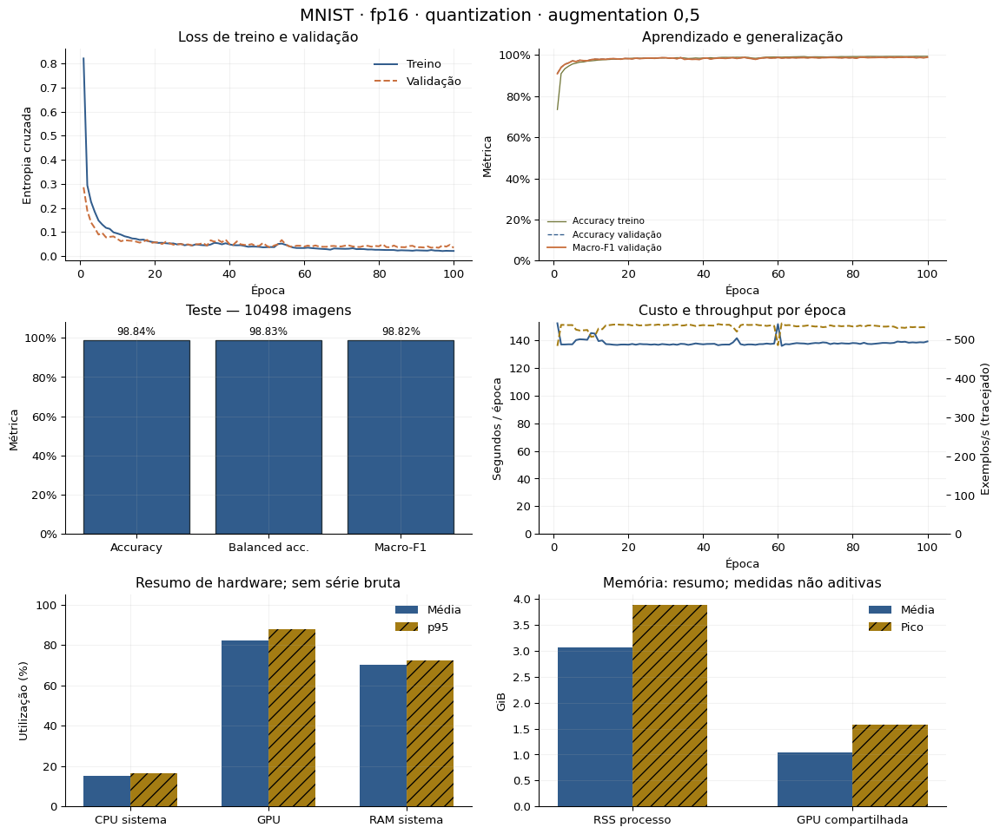

**Resultado:** accuracy 98.84%, balanced accuracy 98.83%, Macro-F1 98.82%, precisão macro 98.82%, recall macro 98.83%, AUC OVR 0.9998 e loss de teste 0.0417. **Custo:** 3.83 h pela soma das épocas; 532.85 exemplos/s, ponderando pelo tempo; avaliação final 20.80 s. **Curva:** melhor Macro-F1 de validação 98.96% na época 94; última época 98.91%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp32 teve o maior Macro-F1 (98.94%); esta condição ficou -0.119 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 82.28%, CPU do processo média 83.58%, RAM média 70.27%; pico de RSS 3.89 GiB e de memória GPU compartilhada 1.57 GiB. **Reconciliação:** resumo de treino 1.57 h versus soma das épocas 3.83 h; diferença 2.26 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 5, F1 97.79% e suporte 947 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [85]:
plot_run('controlled-quantization-fast-mac-m4|quantization|mnist|fp16')
explain_run('controlled-quantization-fast-mac-m4|quantization|mnist|fp16')

#### mnist · fp32

Identidade: `controlled-quantization-fast-mac-m4|quantization|mnist|fp32`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/mnist/fp32/mnist/runs/mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

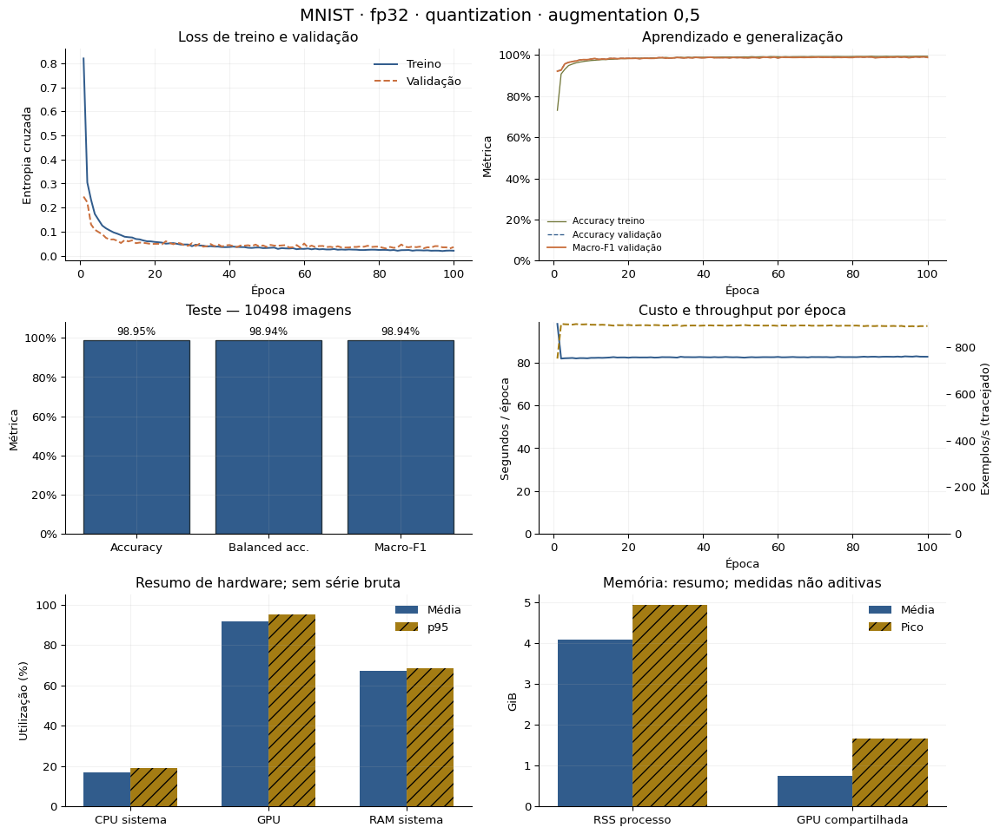

**Resultado:** accuracy 98.95%, balanced accuracy 98.94%, Macro-F1 98.94%, precisão macro 98.95%, recall macro 98.94%, AUC OVR 0.9998 e loss de teste 0.0399. **Custo:** 2.29 h pela soma das épocas; 889.90 exemplos/s, ponderando pelo tempo; avaliação final 9.91 s. **Curva:** melhor Macro-F1 de validação 99.11% na época 99; última época 98.81%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp32 teve o maior Macro-F1 (98.94%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 91.80%, CPU do processo média 92.22%, RAM média 67.29%; pico de RSS 4.94 GiB e de memória GPU compartilhada 1.65 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 2, F1 97.82% e suporte 1048 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [86]:
plot_run('controlled-quantization-fast-mac-m4|quantization|mnist|fp32')
explain_run('controlled-quantization-fast-mac-m4|quantization|mnist|fp32')

#### fashion_mnist · fp16

Identidade: `controlled-quantization-fast-mac-m4|quantization|fashion_mnist|fp16`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/fashion_mnist/fp16/fashion_mnist/runs/fashion_mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

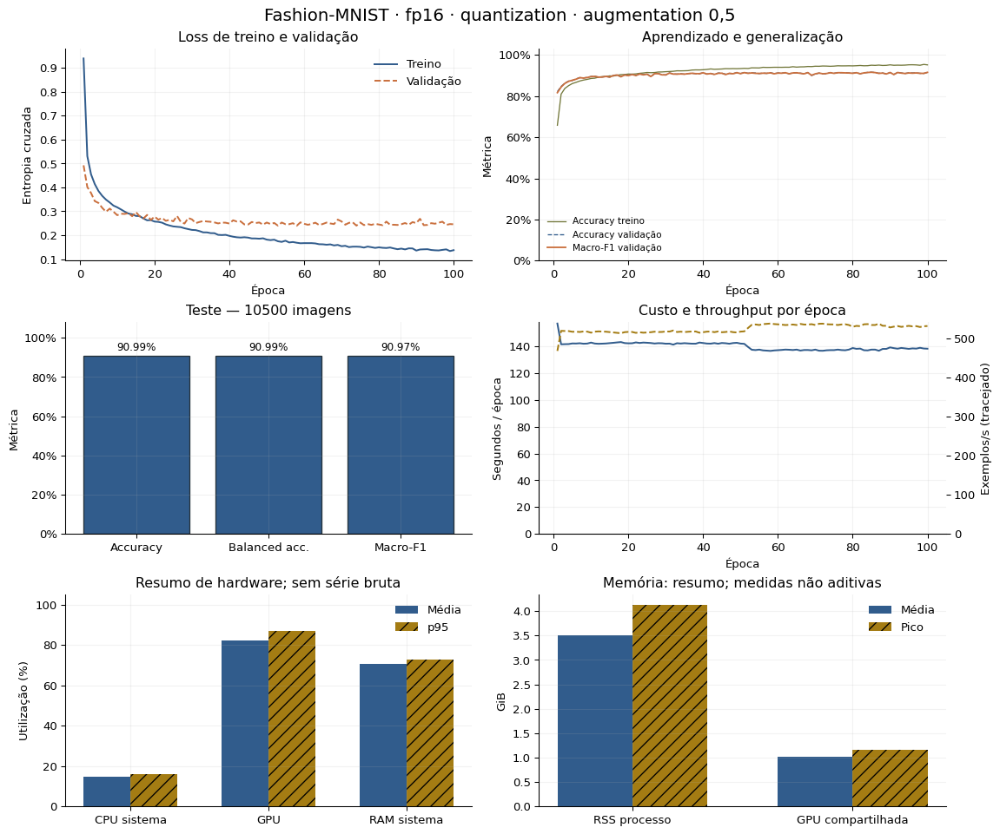

**Resultado:** accuracy 90.99%, balanced accuracy 90.99%, Macro-F1 90.97%, precisão macro 90.98%, recall macro 90.99%, AUC OVR 0.9942 e loss de teste 0.2537. **Custo:** 3.89 h pela soma das épocas; 524.97 exemplos/s, ponderando pelo tempo; avaliação final 20.15 s. **Curva:** melhor Macro-F1 de validação 91.61% na época 85; última época 91.55%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp16 teve o maior Macro-F1 (90.97%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 82.25%, CPU do processo média 84.22%, RAM média 70.87%; pico de RSS 4.13 GiB e de memória GPU compartilhada 1.15 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 6, F1 76.22% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [87]:
plot_run('controlled-quantization-fast-mac-m4|quantization|fashion_mnist|fp16')
explain_run('controlled-quantization-fast-mac-m4|quantization|fashion_mnist|fp16')

#### fashion_mnist · fp32

Identidade: `controlled-quantization-fast-mac-m4|quantization|fashion_mnist|fp32`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/fashion_mnist/fp32/fashion_mnist/runs/fashion_mnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

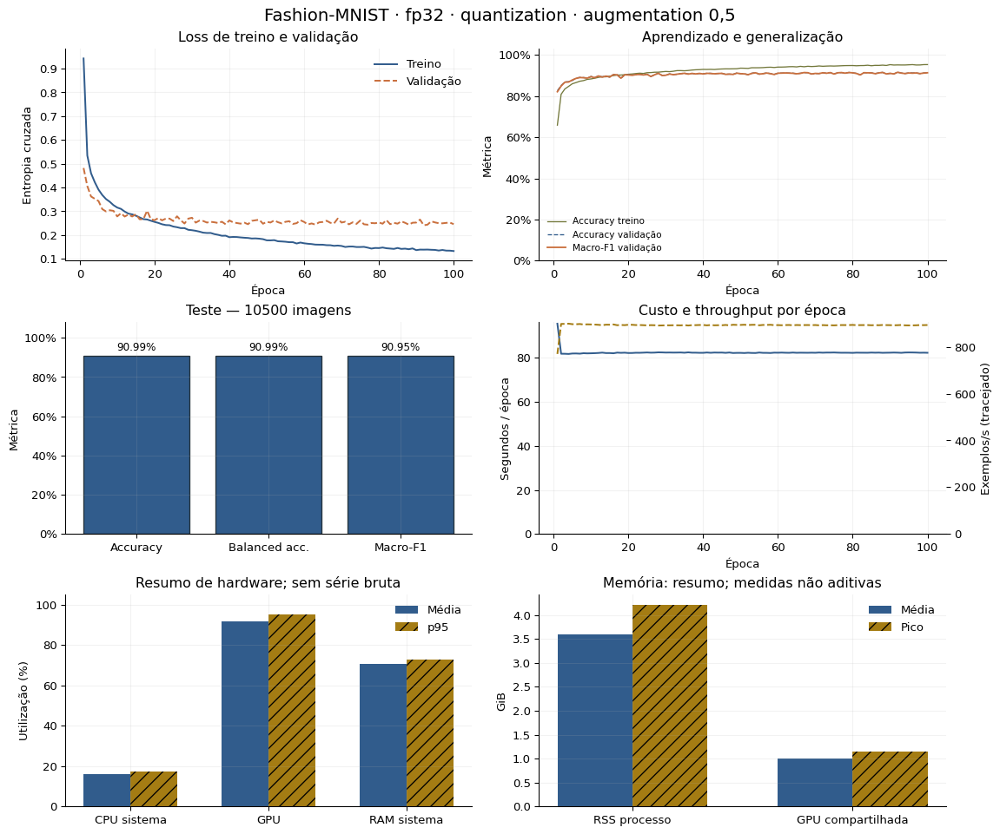

**Resultado:** accuracy 90.99%, balanced accuracy 90.99%, Macro-F1 90.95%, precisão macro 90.95%, recall macro 90.99%, AUC OVR 0.9943 e loss de teste 0.2486. **Custo:** 2.29 h pela soma das épocas; 891.63 exemplos/s, ponderando pelo tempo; avaliação final 9.57 s. **Curva:** melhor Macro-F1 de validação 91.60% na época 92; última época 91.35%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp16 teve o maior Macro-F1 (90.97%); esta condição ficou -0.026 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 91.69%, CPU do processo média 92.08%, RAM média 70.53%; pico de RSS 4.21 GiB e de memória GPU compartilhada 1.15 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 6, F1 75.75% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [88]:
plot_run('controlled-quantization-fast-mac-m4|quantization|fashion_mnist|fp32')
explain_run('controlled-quantization-fast-mac-m4|quantization|fashion_mnist|fp32')

#### kmnist · fp16

Identidade: `controlled-quantization-fast-mac-m4|quantization|kmnist|fp16`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/kmnist/fp16/kmnist/runs/kmnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

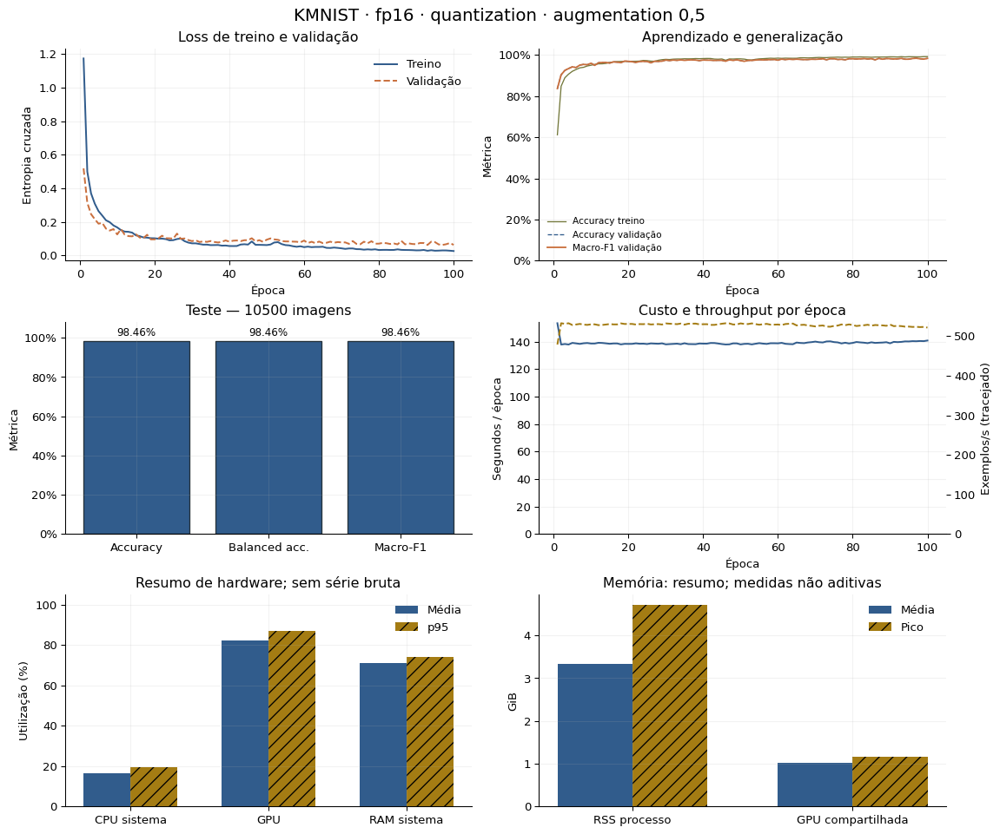

**Resultado:** accuracy 98.46%, balanced accuracy 98.46%, Macro-F1 98.46%, precisão macro 98.46%, recall macro 98.46%, AUC OVR 0.9997 e loss de teste 0.0606. **Custo:** 3.86 h pela soma das épocas; 528.39 exemplos/s, ponderando pelo tempo; avaliação final 21.01 s. **Curva:** melhor Macro-F1 de validação 98.42% na época 97; última época 98.35%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp16 teve o maior Macro-F1 (98.46%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 82.13%, CPU do processo média 84.06%, RAM média 71.26%; pico de RSS 4.72 GiB e de memória GPU compartilhada 1.16 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 6, F1 97.87% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [89]:
plot_run('controlled-quantization-fast-mac-m4|quantization|kmnist|fp16')
explain_run('controlled-quantization-fast-mac-m4|quantization|kmnist|fp16')

#### kmnist · fp32

Identidade: `controlled-quantization-fast-mac-m4|quantization|kmnist|fp32`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/kmnist/fp32/kmnist/runs/kmnist__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

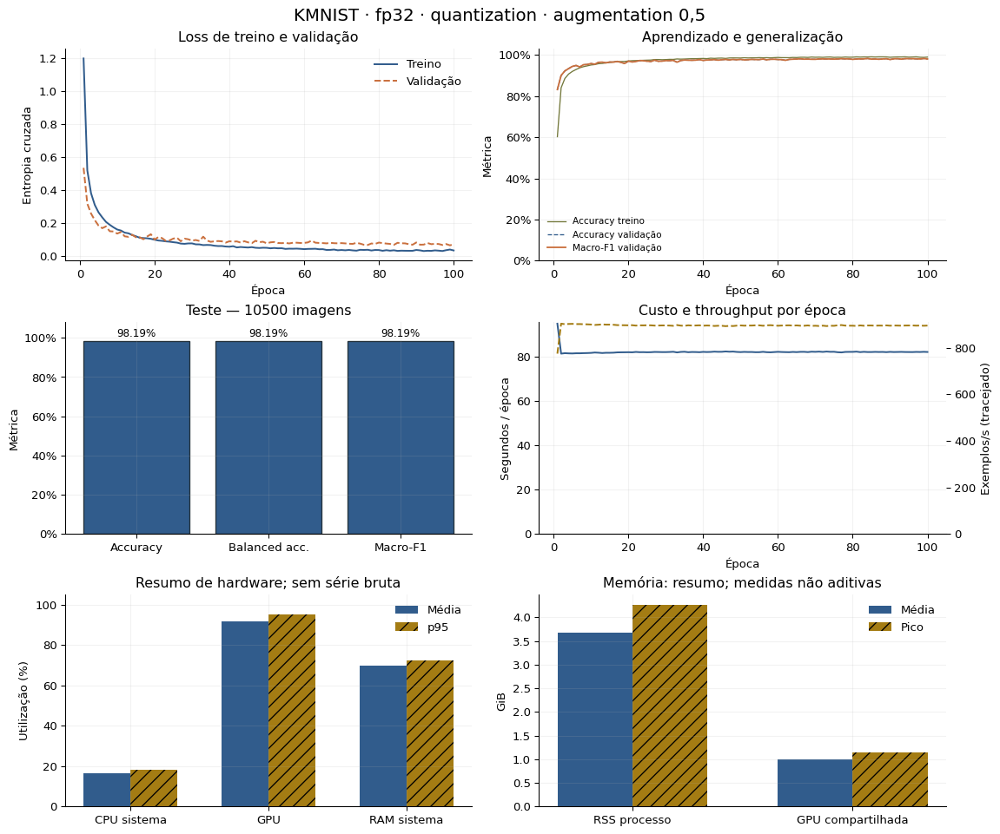

**Resultado:** accuracy 98.19%, balanced accuracy 98.19%, Macro-F1 98.19%, precisão macro 98.20%, recall macro 98.19%, AUC OVR 0.9996 e loss de teste 0.0690. **Custo:** 2.28 h pela soma das épocas; 894.03 exemplos/s, ponderando pelo tempo; avaliação final 9.60 s. **Curva:** melhor Macro-F1 de validação 98.30% na época 84; última época 98.06%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp16 teve o maior Macro-F1 (98.46%); esta condição ficou -0.265 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 91.86%, CPU do processo média 92.66%, RAM média 69.83%; pico de RSS 4.27 GiB e de memória GPU compartilhada 1.13 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 6, F1 97.45% e suporte 1050 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [90]:
plot_run('controlled-quantization-fast-mac-m4|quantization|kmnist|fp32')
explain_run('controlled-quantization-fast-mac-m4|quantization|kmnist|fp32')

#### emnist_balanced · fp16

Identidade: `controlled-quantization-fast-mac-m4|quantization|emnist_balanced|fp16`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/emnist_balanced/fp16/emnist_balanced/runs/emnist_balanced__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

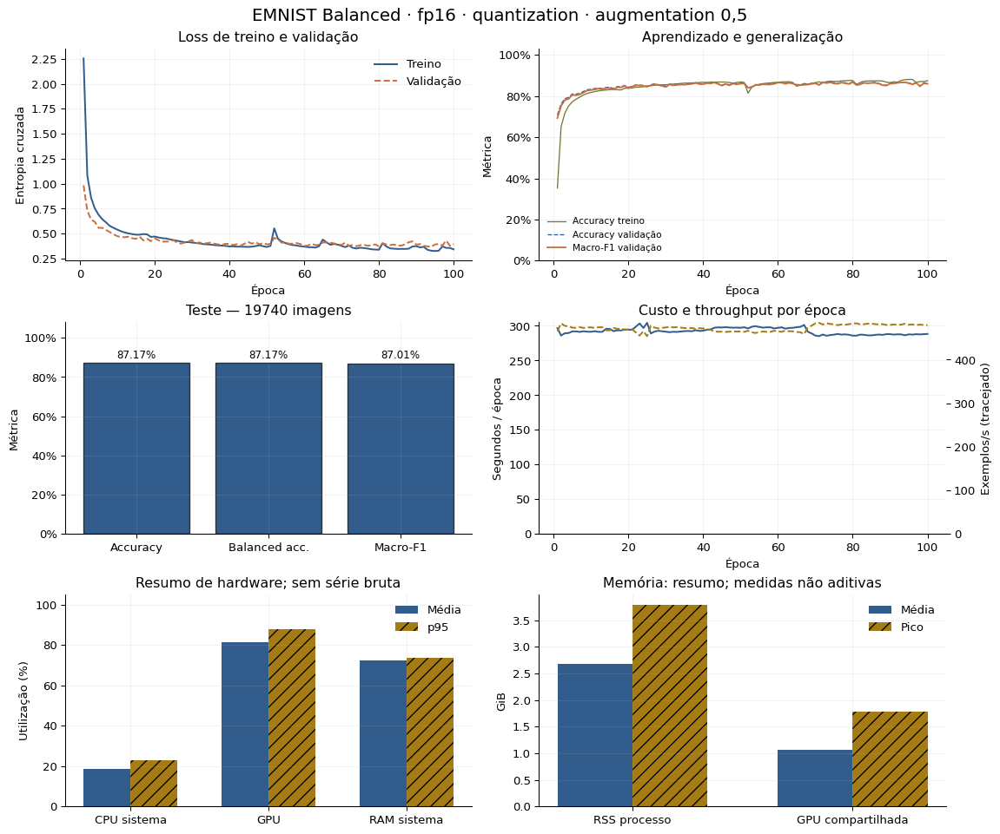

**Resultado:** accuracy 87.17%, balanced accuracy 87.17%, Macro-F1 87.01%, precisão macro 87.33%, recall macro 87.17%, AUC OVR 0.9973 e loss de teste 0.3640. **Custo:** 8.12 h pela soma das épocas; 472.55 exemplos/s, ponderando pelo tempo; avaliação final 37.28 s. **Curva:** melhor Macro-F1 de validação 86.82% na época 80; última época 85.97%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp32 teve o maior Macro-F1 (87.14%); esta condição ficou -0.132 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 81.48%, CPU do processo média 95.65%, RAM média 72.29%; pico de RSS 3.79 GiB e de memória GPU compartilhada 1.79 GiB. **Reconciliação:** resumo de treino 2.72 h versus soma das épocas 8.12 h; diferença 5.40 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 21, F1 52.80% e suporte 420 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [91]:
plot_run('controlled-quantization-fast-mac-m4|quantization|emnist_balanced|fp16')
explain_run('controlled-quantization-fast-mac-m4|quantization|emnist_balanced|fp16')

#### emnist_balanced · fp32

Identidade: `controlled-quantization-fast-mac-m4|quantization|emnist_balanced|fp32`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/emnist_balanced/fp32/emnist_balanced/runs/emnist_balanced__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

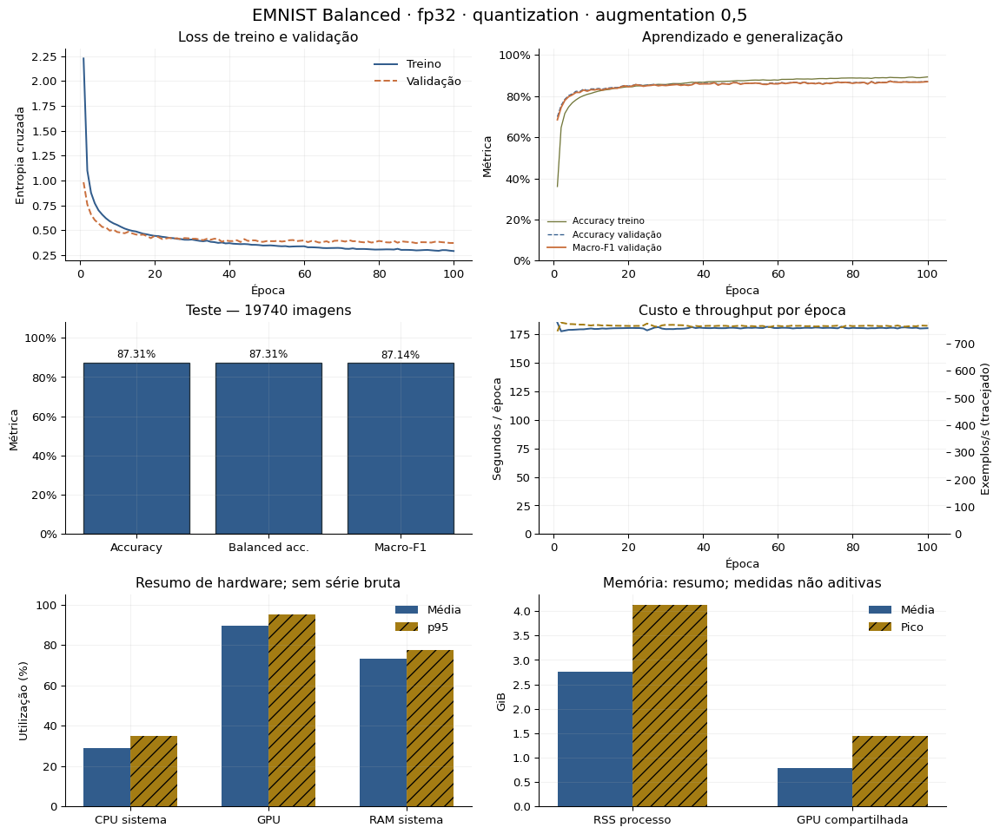

**Resultado:** accuracy 87.31%, balanced accuracy 87.31%, Macro-F1 87.14%, precisão macro 87.67%, recall macro 87.31%, AUC OVR 0.9972 e loss de teste 0.3649. **Custo:** 5.01 h pela soma das épocas; 765.72 exemplos/s, ponderando pelo tempo; avaliação final 18.43 s. **Curva:** melhor Macro-F1 de validação 87.22% na época 90; última época 87.03%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp32 teve o maior Macro-F1 (87.14%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 89.46%, CPU do processo média 109.21%, RAM média 73.44%; pico de RSS 4.13 GiB e de memória GPU compartilhada 1.44 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 21, F1 51.96% e suporte 420 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [92]:
plot_run('controlled-quantization-fast-mac-m4|quantization|emnist_balanced|fp32')
explain_run('controlled-quantization-fast-mac-m4|quantization|emnist_balanced|fp32')

#### cifar10 · fp16

Identidade: `controlled-quantization-fast-mac-m4|quantization|cifar10|fp16`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/cifar10/fp16/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

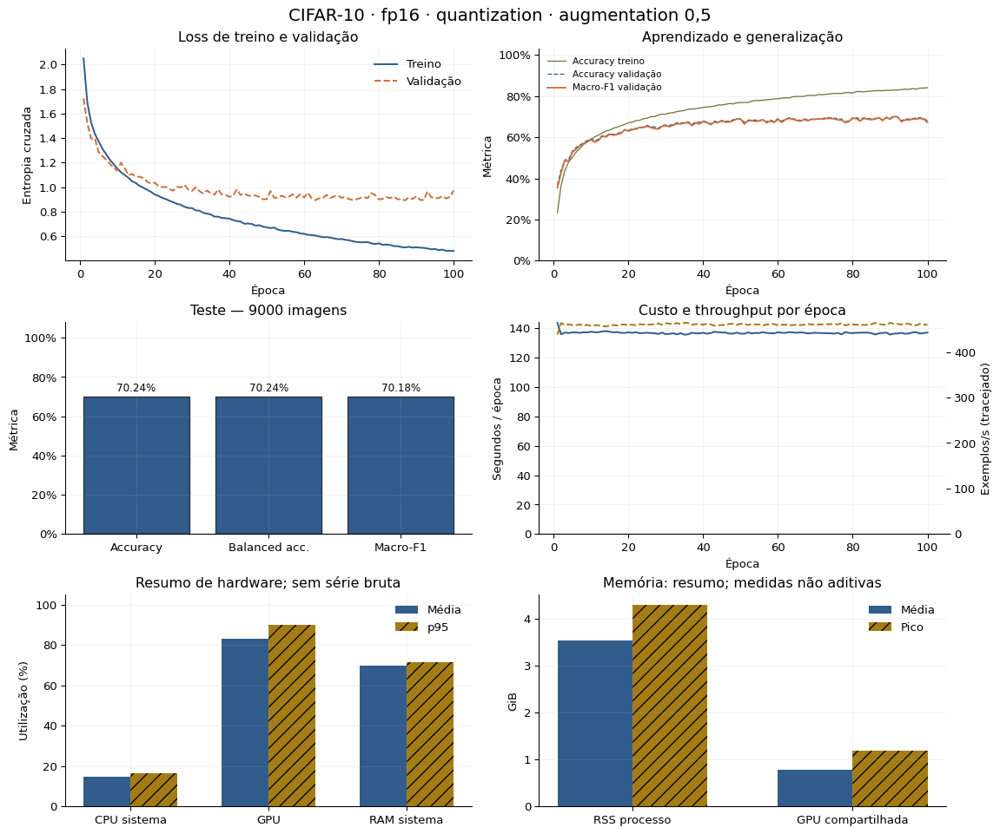

**Resultado:** accuracy 70.24%, balanced accuracy 70.24%, Macro-F1 70.18%, precisão macro 70.48%, recall macro 70.24%, AUC OVR 0.9551 e loss de teste 0.8714. **Custo:** 3.80 h pela soma das épocas; 460.17 exemplos/s, ponderando pelo tempo; avaliação final 17.84 s. **Curva:** melhor Macro-F1 de validação 70.08% na época 91; última época 67.22%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp16 teve o maior Macro-F1 (70.18%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 83.14%, CPU do processo média 94.32%, RAM média 70.00%; pico de RSS 4.29 GiB e de memória GPU compartilhada 1.18 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** cat, F1 50.43% e suporte 900 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [93]:
plot_run('controlled-quantization-fast-mac-m4|quantization|cifar10|fp16')
explain_run('controlled-quantization-fast-mac-m4|quantization|cifar10|fp16')

#### cifar10 · fp32

Identidade: `controlled-quantization-fast-mac-m4|quantization|cifar10|fp32`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/cifar10/fp32/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

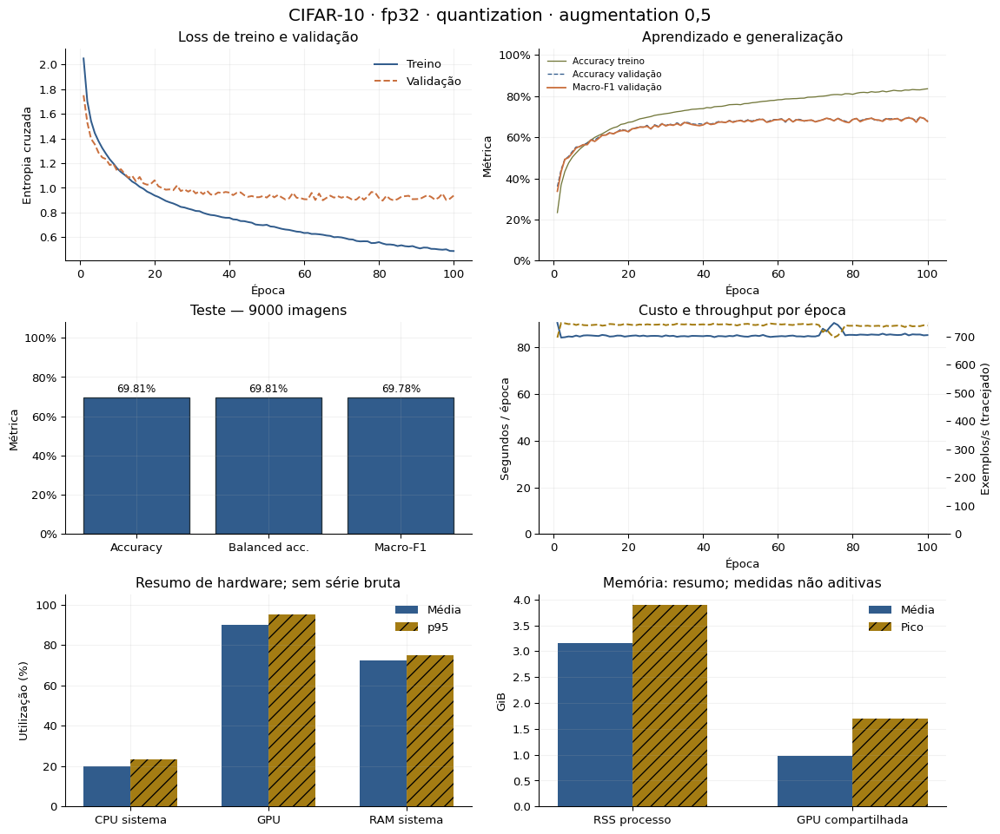

**Resultado:** accuracy 69.81%, balanced accuracy 69.81%, Macro-F1 69.78%, precisão macro 70.10%, recall macro 69.81%, AUC OVR 0.9524 e loss de teste 0.8907. **Custo:** 2.37 h pela soma das épocas; 738.80 exemplos/s, ponderando pelo tempo; avaliação final 8.45 s. **Curva:** melhor Macro-F1 de validação 69.72% na época 98; última época 67.72%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp16 teve o maior Macro-F1 (70.18%); esta condição ficou -0.405 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 89.81%, CPU do processo média 110.42%, RAM média 72.23%; pico de RSS 3.90 GiB e de memória GPU compartilhada 1.69 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** cat, F1 46.50% e suporte 900 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [94]:
plot_run('controlled-quantization-fast-mac-m4|quantization|cifar10|fp32')
explain_run('controlled-quantization-fast-mac-m4|quantization|cifar10|fp32')

#### cifar100_coarse · fp16

Identidade: `controlled-quantization-fast-mac-m4|quantization|cifar100_coarse|fp16`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/cifar100_coarse/fp16/cifar100_coarse/runs/cifar100_coarse__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

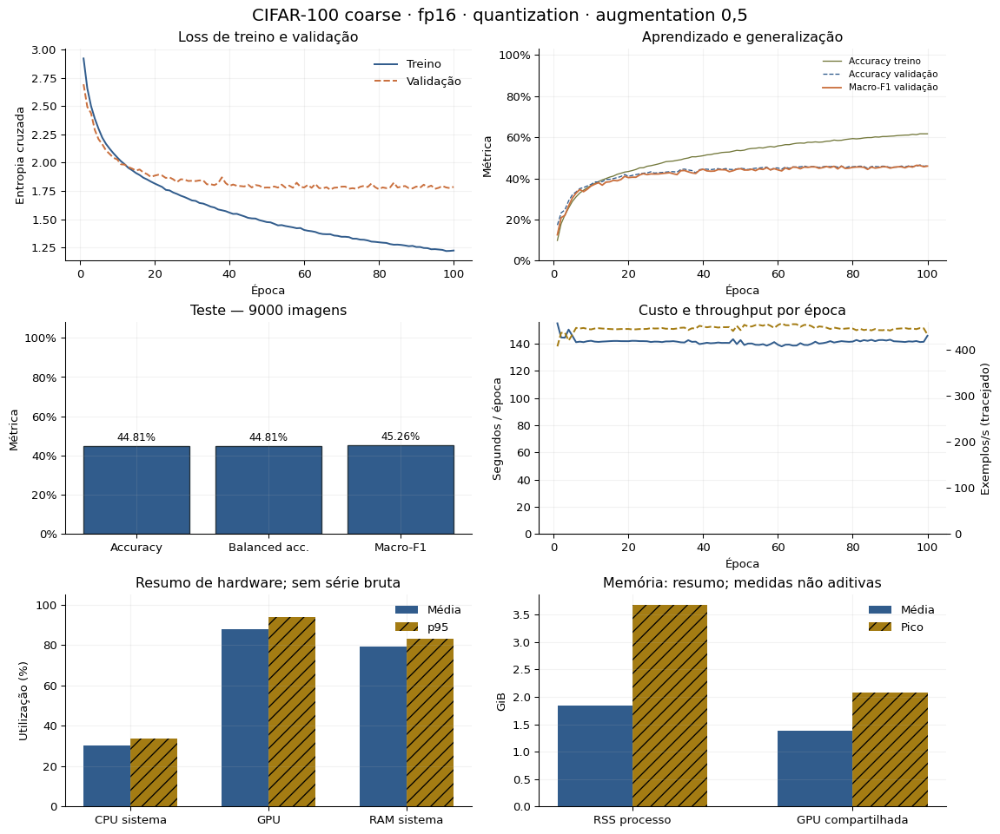

**Resultado:** accuracy 44.81%, balanced accuracy 44.81%, Macro-F1 45.26%, precisão macro 46.53%, recall macro 44.81%, AUC OVR 0.8933 e loss de teste 1.8306. **Custo:** 3.93 h pela soma das épocas; 445.72 exemplos/s, ponderando pelo tempo; avaliação final 17.13 s. **Curva:** melhor Macro-F1 de validação 46.33% na época 97; última época 45.98%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp16 teve o maior Macro-F1 (45.26%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 87.97%, CPU do processo média 96.50%, RAM média 79.21%; pico de RSS 3.68 GiB e de memória GPU compartilhada 2.07 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** small_mammals, F1 25.24% e suporte 450 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [95]:
plot_run('controlled-quantization-fast-mac-m4|quantization|cifar100_coarse|fp16')
explain_run('controlled-quantization-fast-mac-m4|quantization|cifar100_coarse|fp16')

#### cifar100_coarse · fp32

Identidade: `controlled-quantization-fast-mac-m4|quantization|cifar100_coarse|fp32`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/cifar100_coarse/fp32/cifar100_coarse/runs/cifar100_coarse__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

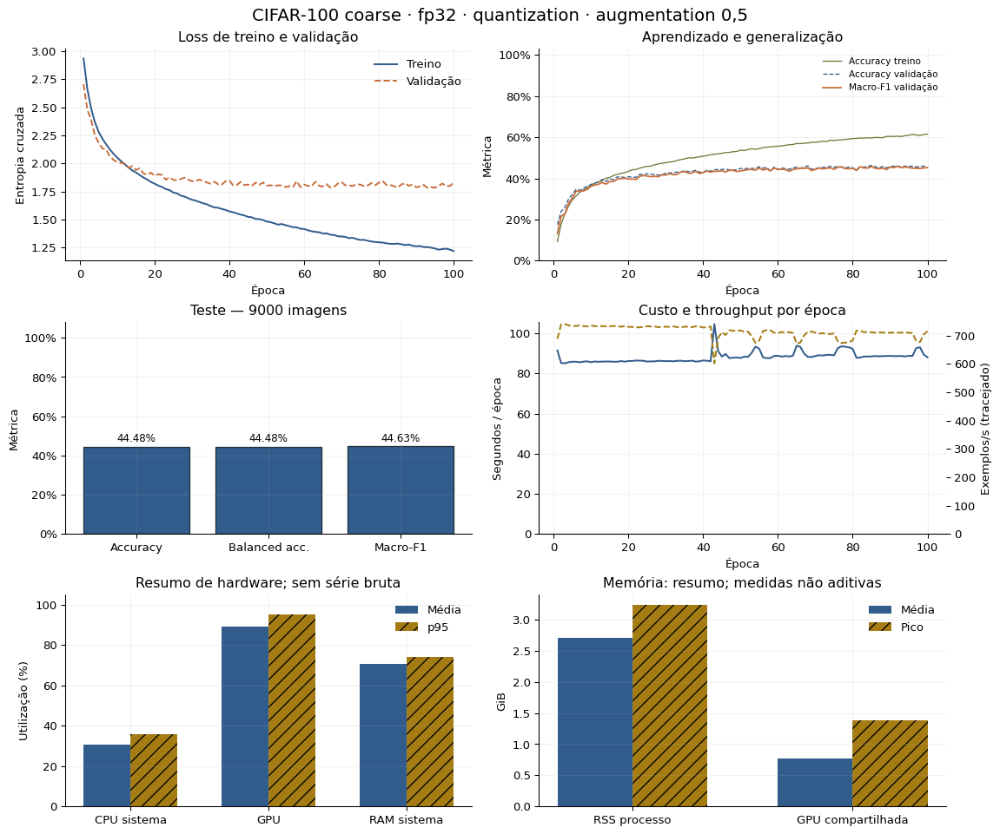

**Resultado:** accuracy 44.48%, balanced accuracy 44.48%, Macro-F1 44.63%, precisão macro 45.46%, recall macro 44.48%, AUC OVR 0.8921 e loss de teste 1.8363. **Custo:** 2.45 h pela soma das épocas; 713.98 exemplos/s, ponderando pelo tempo; avaliação final 8.70 s. **Curva:** melhor Macro-F1 de validação 45.84% na época 92; última época 45.21%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp16 teve o maior Macro-F1 (45.26%); esta condição ficou -0.631 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 88.96%, CPU do processo média 112.55%, RAM média 70.77%; pico de RSS 3.24 GiB e de memória GPU compartilhada 1.38 GiB. **Reconciliação:** resumo de treino 1.45 h versus soma das épocas 2.45 h; diferença 1.01 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** small_mammals, F1 23.72% e suporte 450 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [96]:
plot_run('controlled-quantization-fast-mac-m4|quantization|cifar100_coarse|fp32')
explain_run('controlled-quantization-fast-mac-m4|quantization|cifar100_coarse|fp32')

#### svhn · fp16

Identidade: `controlled-quantization-fast-mac-m4|quantization|svhn|fp16`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/svhn/fp16/svhn/runs/svhn__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

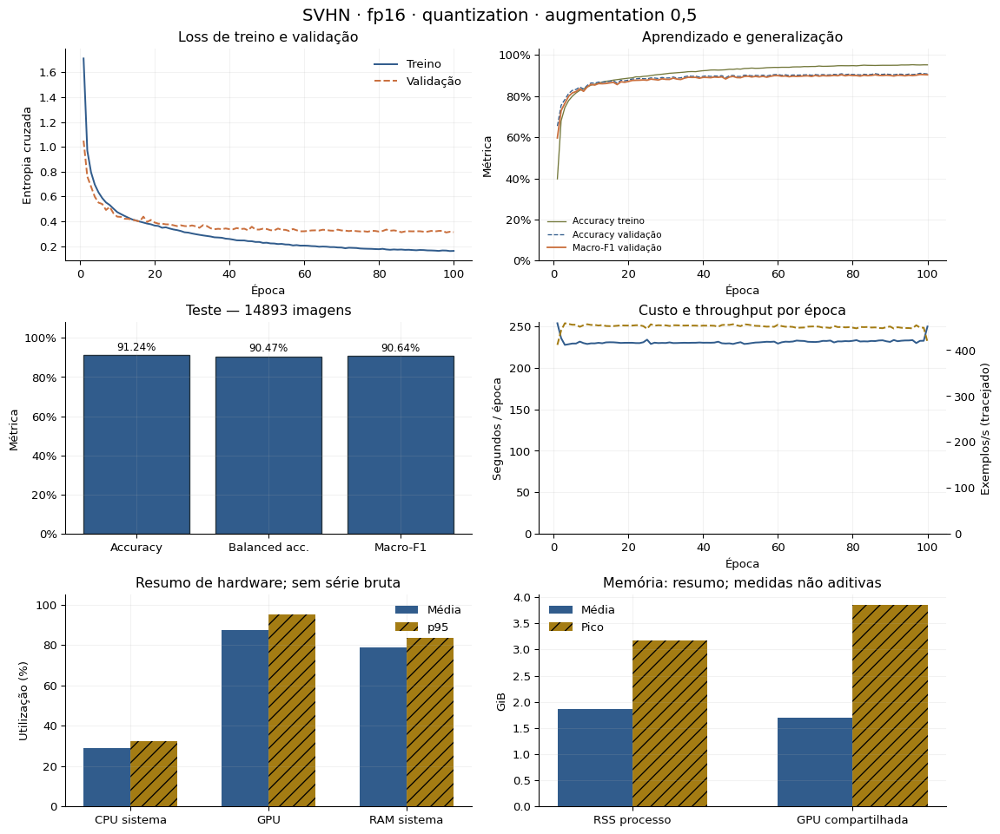

**Resultado:** accuracy 91.24%, balanced accuracy 90.47%, Macro-F1 90.64%, precisão macro 90.85%, recall macro 90.47%, AUC OVR 0.9937 e loss de teste 0.2918. **Custo:** 6.42 h pela soma das épocas; 451.19 exemplos/s, ponderando pelo tempo; avaliação final 27.46 s. **Curva:** melhor Macro-F1 de validação 90.51% na época 98; última época 90.37%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp32 teve o maior Macro-F1 (90.95%); esta condição ficou -0.309 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 87.29%, CPU do processo média 95.45%, RAM média 78.91%; pico de RSS 3.17 GiB e de memória GPU compartilhada 3.86 GiB. **Reconciliação:** resumo de treino 6.35 h versus soma das épocas 6.42 h; diferença 0.07 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 6, F1 87.85% e suporte 1155 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [97]:
plot_run('controlled-quantization-fast-mac-m4|quantization|svhn|fp16')
explain_run('controlled-quantization-fast-mac-m4|quantization|svhn|fp16')

#### svhn · fp32

Identidade: `controlled-quantization-fast-mac-m4|quantization|svhn|fp32`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/svhn/fp32/svhn/runs/svhn__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

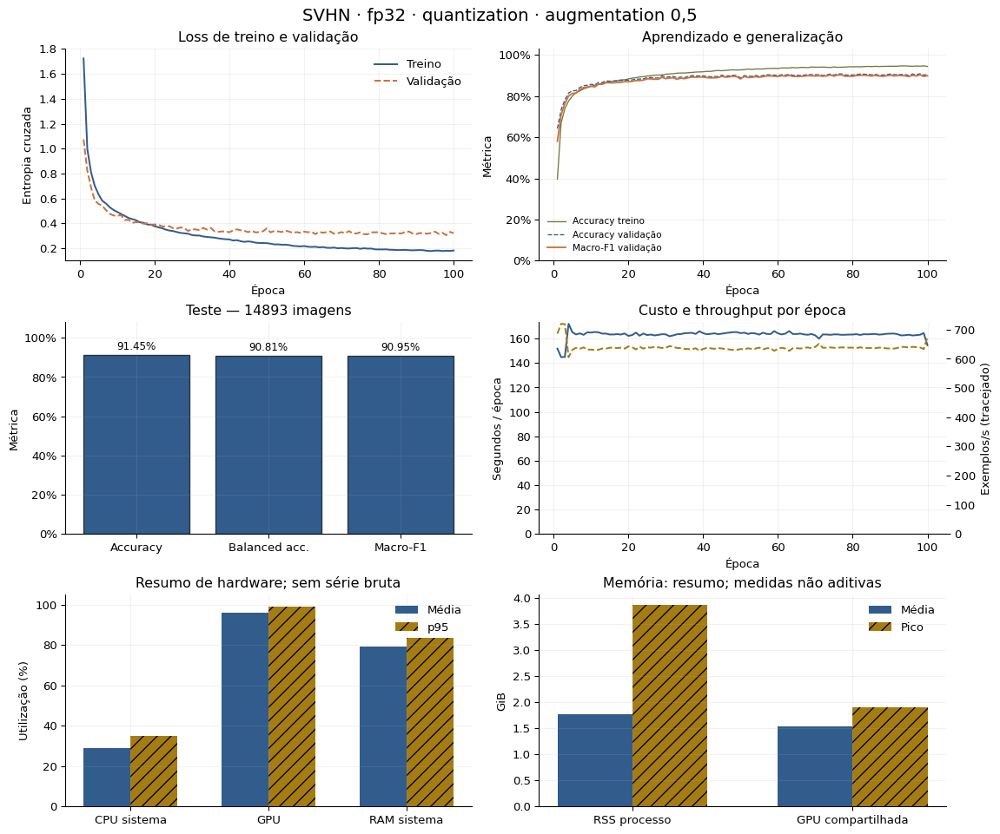

**Resultado:** accuracy 91.45%, balanced accuracy 90.81%, Macro-F1 90.95%, precisão macro 91.13%, recall macro 90.81%, AUC OVR 0.9937 e loss de teste 0.2835. **Custo:** 4.54 h pela soma das épocas; 638.49 exemplos/s, ponderando pelo tempo; avaliação final 14.48 s. **Curva:** melhor Macro-F1 de validação 90.38% na época 98; última época 89.91%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp32 teve o maior Macro-F1 (90.95%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 96.11%, CPU do processo média 100.84%, RAM média 79.39%; pico de RSS 3.86 GiB e de memória GPU compartilhada 1.90 GiB. **Reconciliação:** resumo de treino 4.41 h versus soma das épocas 4.54 h; diferença 0.12 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 8, F1 87.87% e suporte 1006 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [98]:
plot_run('controlled-quantization-fast-mac-m4|quantization|svhn|fp32')
explain_run('controlled-quantization-fast-mac-m4|quantization|svhn|fp32')

#### gtsrb · fp16

Identidade: `controlled-quantization-fast-mac-m4|quantization|gtsrb|fp16`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/gtsrb/fp16/gtsrb/runs/gtsrb__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

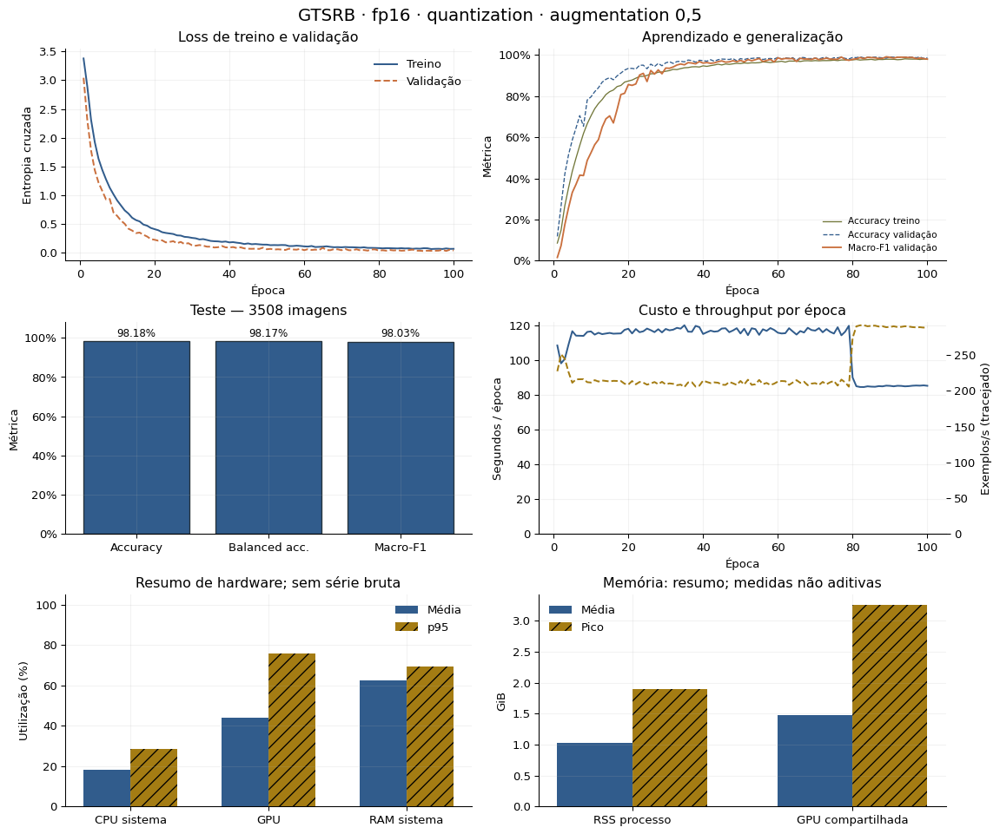

**Resultado:** accuracy 98.18%, balanced accuracy 98.17%, Macro-F1 98.03%, precisão macro 97.99%, recall macro 98.17%, AUC OVR 0.9999 e loss de teste 0.0633. **Custo:** 3.05 h pela soma das épocas; 224.60 exemplos/s, ponderando pelo tempo; avaliação final 9.63 s. **Curva:** melhor Macro-F1 de validação 99.11% na época 89; última época 97.97%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp16 teve o maior Macro-F1 (98.03%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 43.90%, CPU do processo média 65.87%, RAM média 62.54%; pico de RSS 1.90 GiB e de memória GPU compartilhada 3.26 GiB. **Reconciliação:** resumo de treino 0.00 h versus soma das épocas 3.05 h; diferença 3.05 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 39, F1 91.67% e suporte 13 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [99]:
plot_run('controlled-quantization-fast-mac-m4|quantization|gtsrb|fp16')
explain_run('controlled-quantization-fast-mac-m4|quantization|gtsrb|fp16')

#### gtsrb · fp32

Identidade: `controlled-quantization-fast-mac-m4|quantization|gtsrb|fp32`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/gtsrb/fp32/gtsrb/runs/gtsrb__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

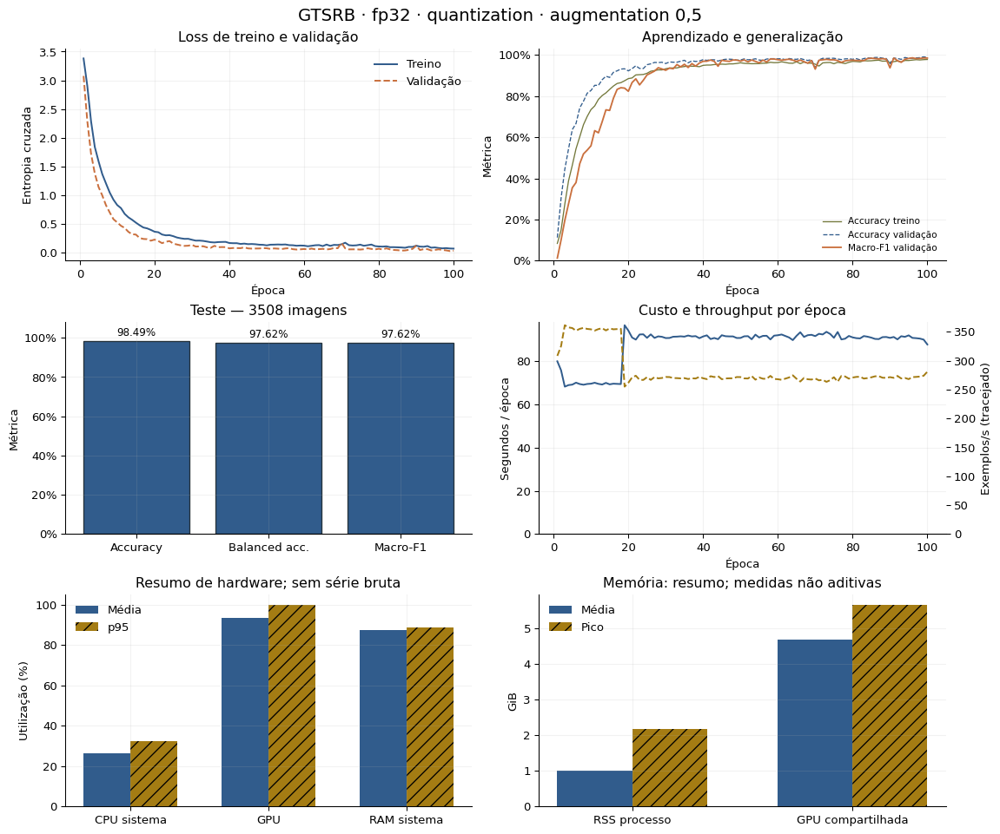

**Resultado:** accuracy 98.49%, balanced accuracy 97.62%, Macro-F1 97.62%, precisão macro 97.78%, recall macro 97.62%, AUC OVR 1.0000 e loss de teste 0.0439. **Custo:** 2.43 h pela soma das épocas; 281.37 exemplos/s, ponderando pelo tempo; avaliação final 9.21 s. **Curva:** melhor Macro-F1 de validação 98.62% na época 96; última época 98.51%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp16 teve o maior Macro-F1 (98.03%); esta condição ficou -0.408 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 93.59%, CPU do processo média 65.53%, RAM média 87.64%; pico de RSS 2.19 GiB e de memória GPU compartilhada 5.67 GiB. **Reconciliação:** resumo de treino 2.08 h versus soma das épocas 2.43 h; diferença 0.35 h. O resumo não representa todas as épocas preservadas. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** 24, F1 88.00% e suporte 13 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [100]:
plot_run('controlled-quantization-fast-mac-m4|quantization|gtsrb|fp32')
explain_run('controlled-quantization-fast-mac-m4|quantization|gtsrb|fp32')

#### fer2013 · fp16

Identidade: `controlled-quantization-fast-mac-m4|quantization|fer2013|fp16`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/fer2013/fp16/fer2013/runs/fer2013__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

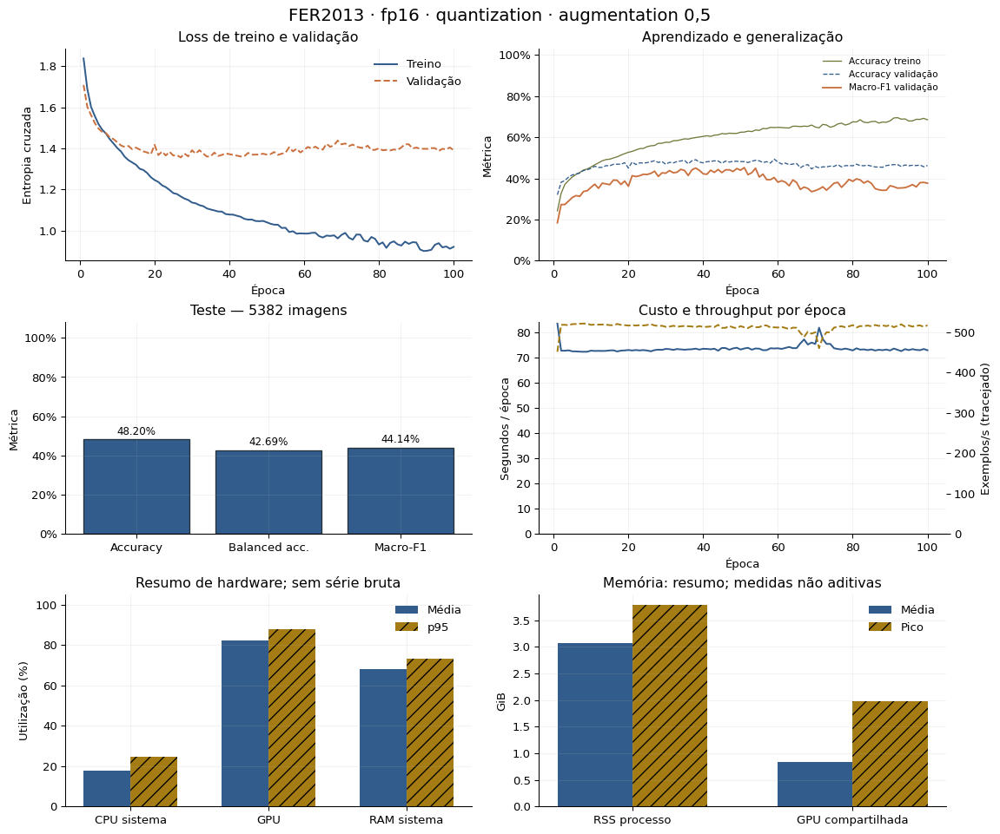

**Resultado:** accuracy 48.20%, balanced accuracy 42.69%, Macro-F1 44.14%, precisão macro 49.82%, recall macro 42.69%, AUC OVR 0.8051 e loss de teste 1.3537. **Custo:** 2.04 h pela soma das épocas; 512.75 exemplos/s, ponderando pelo tempo; avaliação final 11.39 s. **Curva:** melhor Macro-F1 de validação 45.25% na época 51; última época 37.69%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp16 teve o maior Macro-F1 (44.14%); esta condição ficou +0.000 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 82.27%, CPU do processo média 84.38%, RAM média 67.92%; pico de RSS 3.79 GiB e de memória GPU compartilhada 1.97 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** fear, F1 29.04% e suporte 768 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [101]:
plot_run('controlled-quantization-fast-mac-m4|quantization|fer2013|fp16')
explain_run('controlled-quantization-fast-mac-m4|quantization|fer2013|fp16')

#### fer2013 · fp32

Identidade: `controlled-quantization-fast-mac-m4|quantization|fer2013|fp32`. Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/fer2013/fp32/fer2013/runs/fer2013__unit_interval__all_raw__seed-42/status.json`. Status: `completed`; fonte `exported_snapshot`.

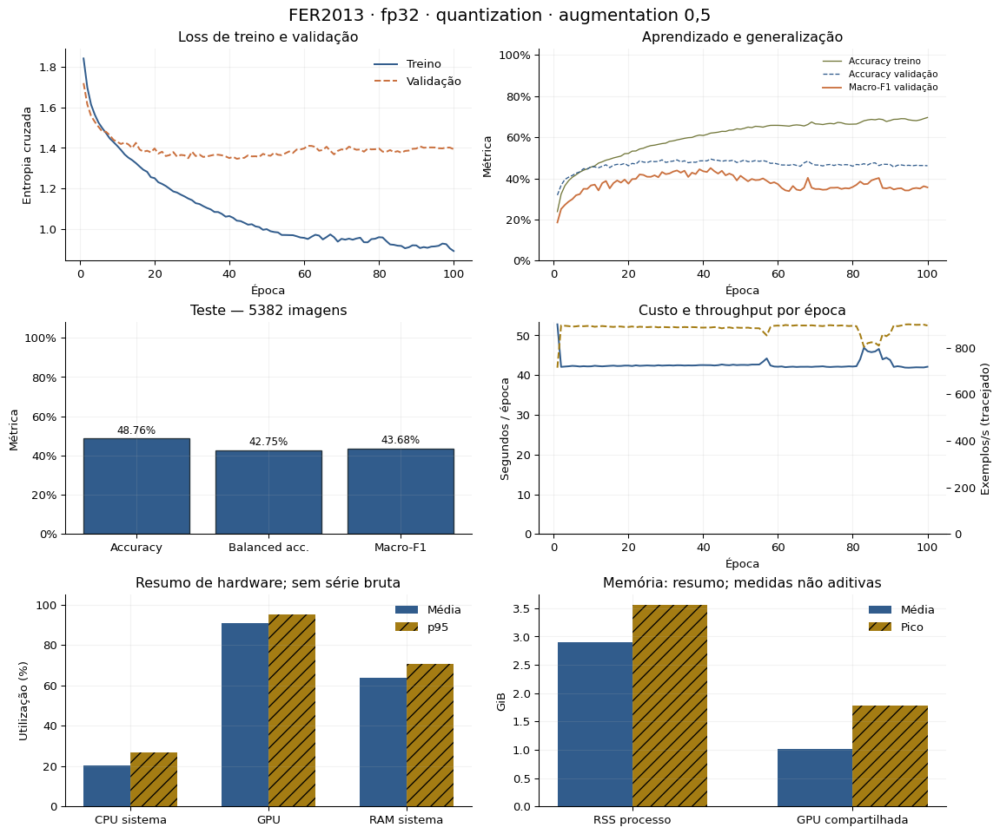

**Resultado:** accuracy 48.76%, balanced accuracy 42.75%, Macro-F1 43.68%, precisão macro 47.40%, recall macro 42.75%, AUC OVR 0.8081 e loss de teste 1.3437. **Custo:** 1.19 h pela soma das épocas; 882.76 exemplos/s, ponderando pelo tempo; avaliação final 5.58 s. **Curva:** melhor Macro-F1 de validação 45.03% na época 42; última época 35.64%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Comparação no mesmo dataset e fase:** fp16 teve o maior Macro-F1 (44.14%); esta condição ficou -0.456 p.p. em relação a ela. Diferenças são descritivas, com uma seed. **Hardware:** GPU média 91.03%, CPU do processo média 91.88%, RAM média 63.86%; pico de RSS 3.56 GiB e de memória GPU compartilhada 1.79 GiB. **Cobertura da telemetria:** Resumo exportado; ciclo da execução, inclui eventos; amostras brutas indisponíveis. Não há amostras brutas locais para reconstruir a evolução temporal; os gráficos de hardware mostram apenas as estatísticas exportadas.

**Classe com menor F1:** fear, F1 28.02% e suporte 768 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [102]:
plot_run('controlled-quantization-fast-mac-m4|quantization|fer2013|fp32')
explain_run('controlled-quantization-fast-mac-m4|quantization|fer2013|fp32')

## Fichas das nove avaliações INT8 PTQ

Sem gráficos de treino ou hardware inventados. As métricas por classe, tamanho e desempenho de inferência estão preservados na tabela de cada avaliação.

### cifar10 · INT8 PTQ

Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/cifar10/int8_ptq/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/status.json`. Operação de pós-treinamento vinculada à campanha de augmentation 0,5.

Accuracy 68.73%, Macro-F1 68.44%; diferença descritiva vs. FP32 -1.333 p.p. Modelo 302.97 KiB, latência mediana por batch 595.94 ms e throughput 429.17 exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação.

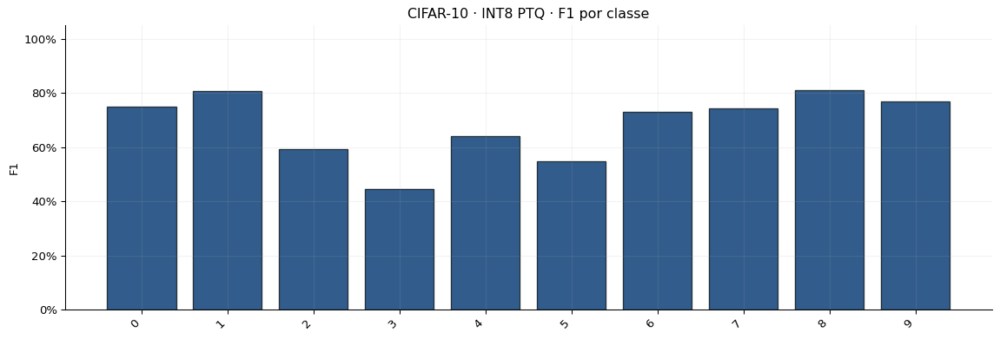

class_name,precision,recall,f1,support
0,0.7303,0.7733,0.7512,900
1,0.8405,0.7789,0.8085,900
2,0.5832,0.6033,0.5931,900
3,0.4837,0.4133,0.4458,900
4,0.5938,0.7000,0.6425,900
5,0.6232,0.4889,0.5479,900
6,0.6745,0.7967,0.7305,900
7,0.7805,0.7111,0.7442,900
8,0.8077,0.8167,0.8122,900
9,0.7471,0.7911,0.7685,900


In [103]:
r = ptq.set_index('uid').loc['controlled-quantization-fast-mac-m4|ptq|cifar10|int8_ptq']
base = main.loc[(main.stage=='quantization') & (main.dataset==r.dataset) & (main.condition=='fp32')].iloc[0]
display(Markdown(f"Accuracy {fmt(r.test_accuracy,percent=True)}, Macro-F1 {fmt(r.test_macro_f1,percent=True)}; diferença descritiva vs. FP32 {(r.test_macro_f1-base.test_macro_f1)*100:+.3f} p.p. Modelo {r.ptq_model_bytes/1024:.2f} KiB, latência mediana por batch {r.ptq_median_batch_latency_ms:.2f} ms e throughput {r.ptq_throughput_examples_per_second:.2f} exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação."))
cs = classes.loc[classes.uid.eq(r.name)].sort_values('class_label')
fig,ax=plt.subplots(figsize=(12,4),layout='constrained')
ax.bar(np.arange(len(cs)),cs.f1,color='#315C8C',edgecolor='#25323B')
ax.set_xticks(np.arange(len(cs)),cs.class_name,rotation=45,ha='right')
ax.set(title=LABELS[r.dataset]+' · INT8 PTQ · F1 por classe',ylabel='F1',ylim=(0,1.05))
ax.yaxis.set_major_formatter(PercentFormatter(1))
show(fig,'ptq_classes_'+r.dataset)
table(cs,['class_name','precision','recall','f1','support'])

### cifar100_coarse · INT8 PTQ

Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/cifar100_coarse/int8_ptq/cifar100_coarse/runs/cifar100_coarse__unit_interval__all_raw__seed-42/status.json`. Operação de pós-treinamento vinculada à campanha de augmentation 0,5.

Accuracy 41.57%, Macro-F1 41.50%; diferença descritiva vs. FP32 -3.122 p.p. Modelo 305.74 KiB, latência mediana por batch 611.88 ms e throughput 420.72 exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação.

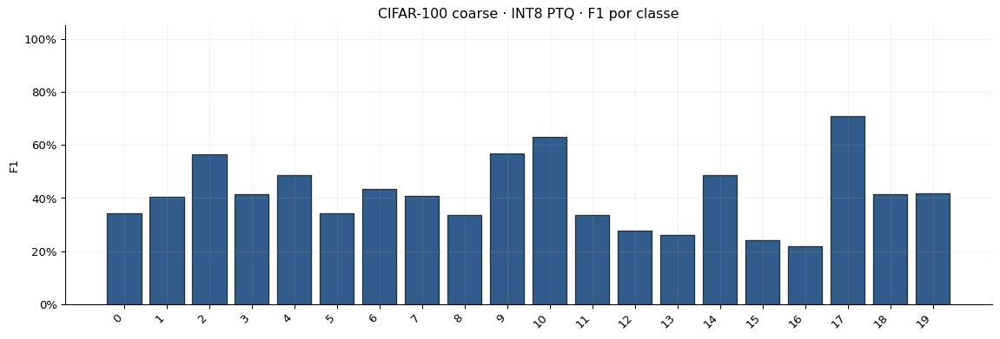

class_name,precision,recall,f1,support
0,0.3695,0.3178,0.3417,450
1,0.4200,0.3911,0.4051,450
2,0.4625,0.7267,0.5653,450
3,0.5292,0.3422,0.4157,450
4,0.4653,0.5067,0.4851,450
5,0.3222,0.3644,0.3420,450
6,0.5470,0.3622,0.4358,450
7,0.3612,0.4711,0.4089,450
8,0.3131,0.3667,0.3378,450
9,0.6322,0.5156,0.5679,450


In [104]:
r = ptq.set_index('uid').loc['controlled-quantization-fast-mac-m4|ptq|cifar100_coarse|int8_ptq']
base = main.loc[(main.stage=='quantization') & (main.dataset==r.dataset) & (main.condition=='fp32')].iloc[0]
display(Markdown(f"Accuracy {fmt(r.test_accuracy,percent=True)}, Macro-F1 {fmt(r.test_macro_f1,percent=True)}; diferença descritiva vs. FP32 {(r.test_macro_f1-base.test_macro_f1)*100:+.3f} p.p. Modelo {r.ptq_model_bytes/1024:.2f} KiB, latência mediana por batch {r.ptq_median_batch_latency_ms:.2f} ms e throughput {r.ptq_throughput_examples_per_second:.2f} exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação."))
cs = classes.loc[classes.uid.eq(r.name)].sort_values('class_label')
fig,ax=plt.subplots(figsize=(12,4),layout='constrained')
ax.bar(np.arange(len(cs)),cs.f1,color='#315C8C',edgecolor='#25323B')
ax.set_xticks(np.arange(len(cs)),cs.class_name,rotation=45,ha='right')
ax.set(title=LABELS[r.dataset]+' · INT8 PTQ · F1 por classe',ylabel='F1',ylim=(0,1.05))
ax.yaxis.set_major_formatter(PercentFormatter(1))
show(fig,'ptq_classes_'+r.dataset)
table(cs,['class_name','precision','recall','f1','support'])

### emnist_balanced · INT8 PTQ

Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/emnist_balanced/int8_ptq/emnist_balanced/runs/emnist_balanced__unit_interval__all_raw__seed-42/status.json`. Operação de pós-treinamento vinculada à campanha de augmentation 0,5.

Accuracy 86.91%, Macro-F1 86.72%; diferença descritiva vs. FP32 -0.428 p.p. Modelo 313.06 KiB, latência mediana por batch 616.90 ms e throughput 414.99 exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação.

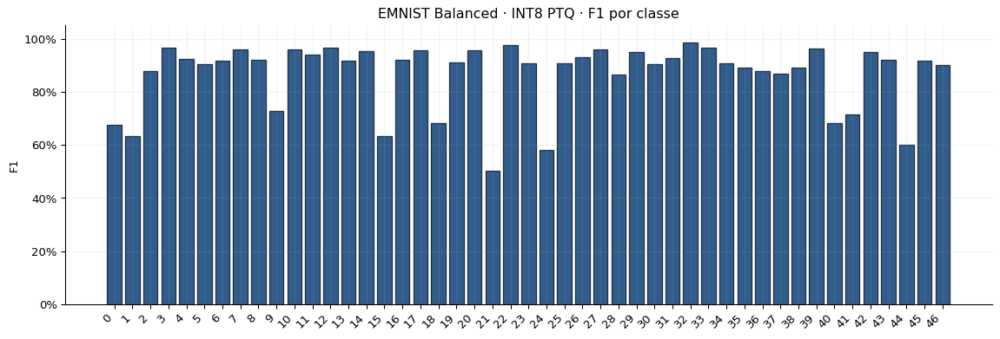

class_name,precision,recall,f1,support
0,0.5904,0.7929,0.6768,420
1,0.5512,0.7429,0.6329,420
2,0.8621,0.8929,0.8772,420
3,0.9623,0.9714,0.9668,420
4,0.9543,0.8952,0.9238,420
5,0.8930,0.9143,0.9035,420
6,0.8850,0.9524,0.9174,420
7,0.9616,0.9548,0.9582,420
8,0.9037,0.9381,0.9206,420
9,0.6233,0.8786,0.7292,420


In [105]:
r = ptq.set_index('uid').loc['controlled-quantization-fast-mac-m4|ptq|emnist_balanced|int8_ptq']
base = main.loc[(main.stage=='quantization') & (main.dataset==r.dataset) & (main.condition=='fp32')].iloc[0]
display(Markdown(f"Accuracy {fmt(r.test_accuracy,percent=True)}, Macro-F1 {fmt(r.test_macro_f1,percent=True)}; diferença descritiva vs. FP32 {(r.test_macro_f1-base.test_macro_f1)*100:+.3f} p.p. Modelo {r.ptq_model_bytes/1024:.2f} KiB, latência mediana por batch {r.ptq_median_batch_latency_ms:.2f} ms e throughput {r.ptq_throughput_examples_per_second:.2f} exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação."))
cs = classes.loc[classes.uid.eq(r.name)].sort_values('class_label')
fig,ax=plt.subplots(figsize=(12,4),layout='constrained')
ax.bar(np.arange(len(cs)),cs.f1,color='#315C8C',edgecolor='#25323B')
ax.set_xticks(np.arange(len(cs)),cs.class_name,rotation=45,ha='right')
ax.set(title=LABELS[r.dataset]+' · INT8 PTQ · F1 por classe',ylabel='F1',ylim=(0,1.05))
ax.yaxis.set_major_formatter(PercentFormatter(1))
show(fig,'ptq_classes_'+r.dataset)
table(cs,['class_name','precision','recall','f1','support'])

### fashion_mnist · INT8 PTQ

Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/fashion_mnist/int8_ptq/fashion_mnist/runs/fashion_mnist__unit_interval__all_raw__seed-42/status.json`. Operação de pós-treinamento vinculada à campanha de augmentation 0,5.

Accuracy 72.01%, Macro-F1 71.80%; diferença descritiva vs. FP32 -19.147 p.p. Modelo 302.80 KiB, latência mediana por batch 615.46 ms e throughput 416.21 exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação.

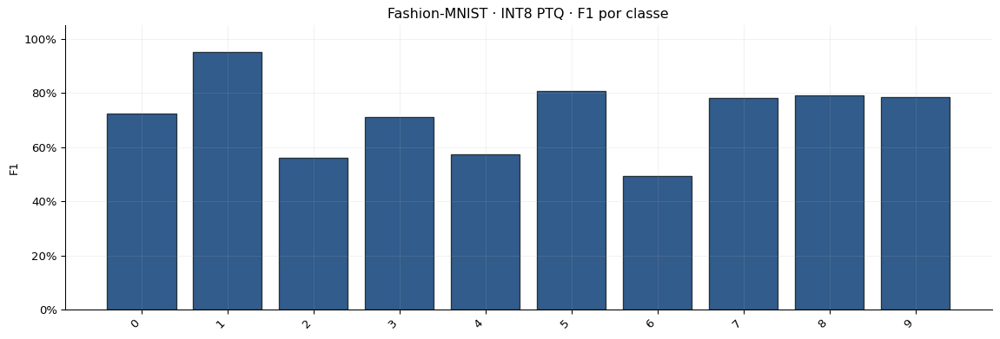

class_name,precision,recall,f1,support
0,0.7445,0.7076,0.7256,1050
1,0.9969,0.9076,0.9501,1050
2,0.5575,0.5629,0.5602,1050
3,0.7309,0.6933,0.7116,1050
4,0.5733,0.5771,0.5752,1050
5,0.6834,0.9867,0.8075,1050
6,0.5337,0.4600,0.4941,1050
7,0.9649,0.6552,0.7805,1050
8,0.6883,0.9276,0.7903,1050
9,0.8586,0.7229,0.7849,1050


In [106]:
r = ptq.set_index('uid').loc['controlled-quantization-fast-mac-m4|ptq|fashion_mnist|int8_ptq']
base = main.loc[(main.stage=='quantization') & (main.dataset==r.dataset) & (main.condition=='fp32')].iloc[0]
display(Markdown(f"Accuracy {fmt(r.test_accuracy,percent=True)}, Macro-F1 {fmt(r.test_macro_f1,percent=True)}; diferença descritiva vs. FP32 {(r.test_macro_f1-base.test_macro_f1)*100:+.3f} p.p. Modelo {r.ptq_model_bytes/1024:.2f} KiB, latência mediana por batch {r.ptq_median_batch_latency_ms:.2f} ms e throughput {r.ptq_throughput_examples_per_second:.2f} exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação."))
cs = classes.loc[classes.uid.eq(r.name)].sort_values('class_label')
fig,ax=plt.subplots(figsize=(12,4),layout='constrained')
ax.bar(np.arange(len(cs)),cs.f1,color='#315C8C',edgecolor='#25323B')
ax.set_xticks(np.arange(len(cs)),cs.class_name,rotation=45,ha='right')
ax.set(title=LABELS[r.dataset]+' · INT8 PTQ · F1 por classe',ylabel='F1',ylim=(0,1.05))
ax.yaxis.set_major_formatter(PercentFormatter(1))
show(fig,'ptq_classes_'+r.dataset)
table(cs,['class_name','precision','recall','f1','support'])

### fer2013 · INT8 PTQ

Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/fer2013/int8_ptq/fer2013/runs/fer2013__unit_interval__all_raw__seed-42/status.json`. Operação de pós-treinamento vinculada à campanha de augmentation 0,5.

Accuracy 42.88%, Macro-F1 37.81%; diferença descritiva vs. FP32 -5.877 p.p. Modelo 301.97 KiB, latência mediana por batch 540.19 ms e throughput 473.85 exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação.

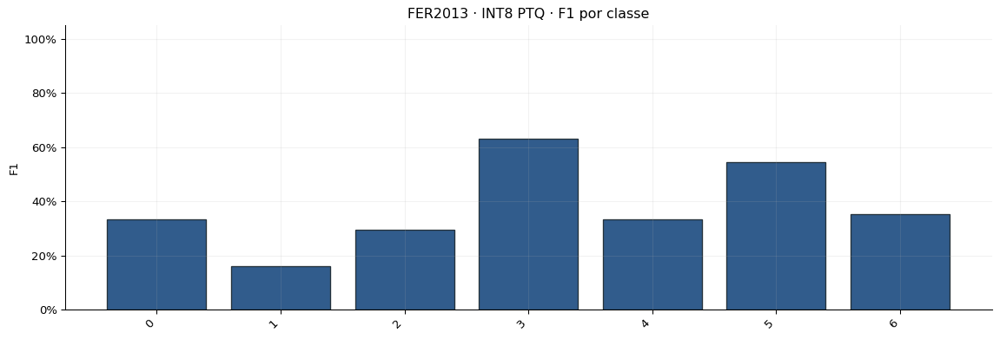

class_name,precision,recall,f1,support
0,0.3236,0.3419,0.3325,743
1,0.4444,0.0976,0.1600,82
2,0.2686,0.3242,0.2938,768
3,0.6140,0.6491,0.6311,1348
4,0.3112,0.3557,0.3320,911
5,0.5266,0.5617,0.5435,600
6,0.4780,0.2806,0.3537,930


In [107]:
r = ptq.set_index('uid').loc['controlled-quantization-fast-mac-m4|ptq|fer2013|int8_ptq']
base = main.loc[(main.stage=='quantization') & (main.dataset==r.dataset) & (main.condition=='fp32')].iloc[0]
display(Markdown(f"Accuracy {fmt(r.test_accuracy,percent=True)}, Macro-F1 {fmt(r.test_macro_f1,percent=True)}; diferença descritiva vs. FP32 {(r.test_macro_f1-base.test_macro_f1)*100:+.3f} p.p. Modelo {r.ptq_model_bytes/1024:.2f} KiB, latência mediana por batch {r.ptq_median_batch_latency_ms:.2f} ms e throughput {r.ptq_throughput_examples_per_second:.2f} exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação."))
cs = classes.loc[classes.uid.eq(r.name)].sort_values('class_label')
fig,ax=plt.subplots(figsize=(12,4),layout='constrained')
ax.bar(np.arange(len(cs)),cs.f1,color='#315C8C',edgecolor='#25323B')
ax.set_xticks(np.arange(len(cs)),cs.class_name,rotation=45,ha='right')
ax.set(title=LABELS[r.dataset]+' · INT8 PTQ · F1 por classe',ylabel='F1',ylim=(0,1.05))
ax.yaxis.set_major_formatter(PercentFormatter(1))
show(fig,'ptq_classes_'+r.dataset)
table(cs,['class_name','precision','recall','f1','support'])

### gtsrb · INT8 PTQ

Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/gtsrb/int8_ptq/gtsrb/runs/gtsrb__unit_interval__all_raw__seed-42/status.json`. Operação de pós-treinamento vinculada à campanha de augmentation 0,5.

Accuracy 82.16%, Macro-F1 79.19%; diferença descritiva vs. FP32 -18.427 p.p. Modelo 312.12 KiB, latência mediana por batch 2114.30 ms e throughput 120.92 exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação.

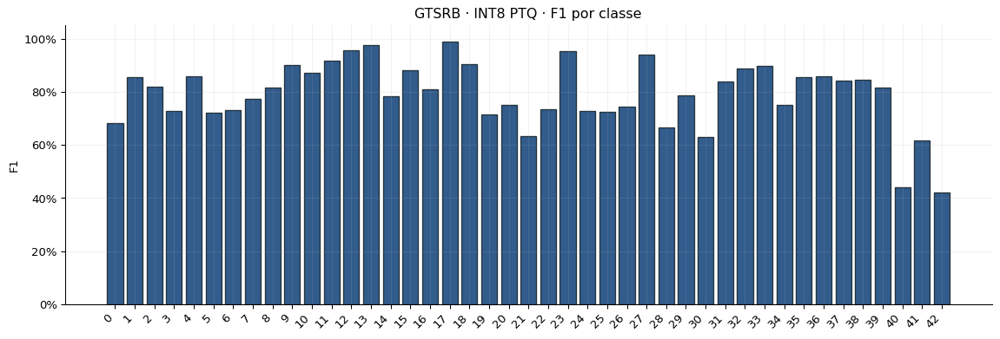

class_name,precision,recall,f1,support
0,0.5167,1.0000,0.6813,31
1,0.7729,0.9610,0.8568,333
2,0.7737,0.8724,0.8201,337
3,0.6790,0.7820,0.7269,211
4,0.9545,0.7778,0.8571,297
5,0.7608,0.6855,0.7212,283
6,0.9111,0.6119,0.7321,67
7,0.9853,0.6351,0.7723,211
8,0.9075,0.7441,0.8177,211
9,0.8929,0.9091,0.9009,220


In [108]:
r = ptq.set_index('uid').loc['controlled-quantization-fast-mac-m4|ptq|gtsrb|int8_ptq']
base = main.loc[(main.stage=='quantization') & (main.dataset==r.dataset) & (main.condition=='fp32')].iloc[0]
display(Markdown(f"Accuracy {fmt(r.test_accuracy,percent=True)}, Macro-F1 {fmt(r.test_macro_f1,percent=True)}; diferença descritiva vs. FP32 {(r.test_macro_f1-base.test_macro_f1)*100:+.3f} p.p. Modelo {r.ptq_model_bytes/1024:.2f} KiB, latência mediana por batch {r.ptq_median_batch_latency_ms:.2f} ms e throughput {r.ptq_throughput_examples_per_second:.2f} exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação."))
cs = classes.loc[classes.uid.eq(r.name)].sort_values('class_label')
fig,ax=plt.subplots(figsize=(12,4),layout='constrained')
ax.bar(np.arange(len(cs)),cs.f1,color='#315C8C',edgecolor='#25323B')
ax.set_xticks(np.arange(len(cs)),cs.class_name,rotation=45,ha='right')
ax.set(title=LABELS[r.dataset]+' · INT8 PTQ · F1 por classe',ylabel='F1',ylim=(0,1.05))
ax.yaxis.set_major_formatter(PercentFormatter(1))
show(fig,'ptq_classes_'+r.dataset)
table(cs,['class_name','precision','recall','f1','support'])

### kmnist · INT8 PTQ

Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/kmnist/int8_ptq/kmnist/runs/kmnist__unit_interval__all_raw__seed-42/status.json`. Operação de pós-treinamento vinculada à campanha de augmentation 0,5.

Accuracy 96.54%, Macro-F1 96.55%; diferença descritiva vs. FP32 -1.646 p.p. Modelo 302.80 KiB, latência mediana por batch 617.67 ms e throughput 414.95 exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação.

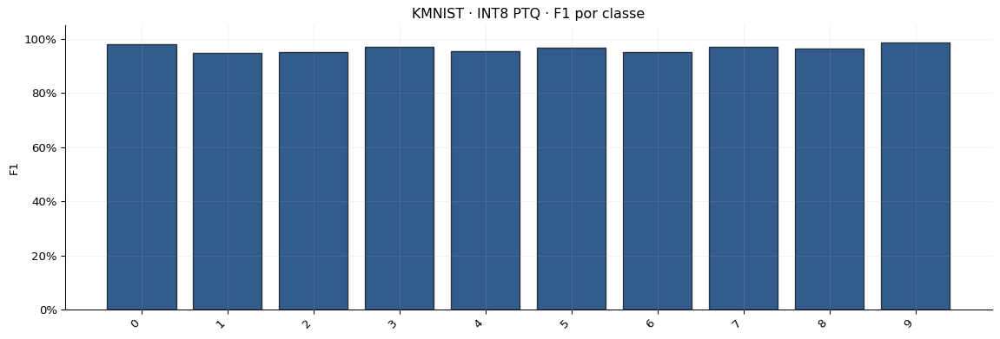

class_name,precision,recall,f1,support
0,0.9874,0.9733,0.9803,1050
1,0.9730,0.9276,0.9498,1050
2,0.9455,0.9590,0.9522,1050
3,0.9644,0.9790,0.9716,1050
4,0.9571,0.9552,0.9561,1050
5,0.9624,0.9762,0.9693,1050
6,0.9325,0.9733,0.9525,1050
7,0.9901,0.9533,0.9714,1050
8,0.9526,0.9771,0.9647,1050
9,0.9932,0.9800,0.9866,1050


In [109]:
r = ptq.set_index('uid').loc['controlled-quantization-fast-mac-m4|ptq|kmnist|int8_ptq']
base = main.loc[(main.stage=='quantization') & (main.dataset==r.dataset) & (main.condition=='fp32')].iloc[0]
display(Markdown(f"Accuracy {fmt(r.test_accuracy,percent=True)}, Macro-F1 {fmt(r.test_macro_f1,percent=True)}; diferença descritiva vs. FP32 {(r.test_macro_f1-base.test_macro_f1)*100:+.3f} p.p. Modelo {r.ptq_model_bytes/1024:.2f} KiB, latência mediana por batch {r.ptq_median_batch_latency_ms:.2f} ms e throughput {r.ptq_throughput_examples_per_second:.2f} exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação."))
cs = classes.loc[classes.uid.eq(r.name)].sort_values('class_label')
fig,ax=plt.subplots(figsize=(12,4),layout='constrained')
ax.bar(np.arange(len(cs)),cs.f1,color='#315C8C',edgecolor='#25323B')
ax.set_xticks(np.arange(len(cs)),cs.class_name,rotation=45,ha='right')
ax.set(title=LABELS[r.dataset]+' · INT8 PTQ · F1 por classe',ylabel='F1',ylim=(0,1.05))
ax.yaxis.set_major_formatter(PercentFormatter(1))
show(fig,'ptq_classes_'+r.dataset)
table(cs,['class_name','precision','recall','f1','support'])

### mnist · INT8 PTQ

Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/mnist/int8_ptq/mnist/runs/mnist__unit_interval__all_raw__seed-42/status.json`. Operação de pós-treinamento vinculada à campanha de augmentation 0,5.

Accuracy 98.34%, Macro-F1 98.32%; diferença descritiva vs. FP32 -0.617 p.p. Modelo 302.80 KiB, latência mediana por batch 612.57 ms e throughput 417.83 exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação.

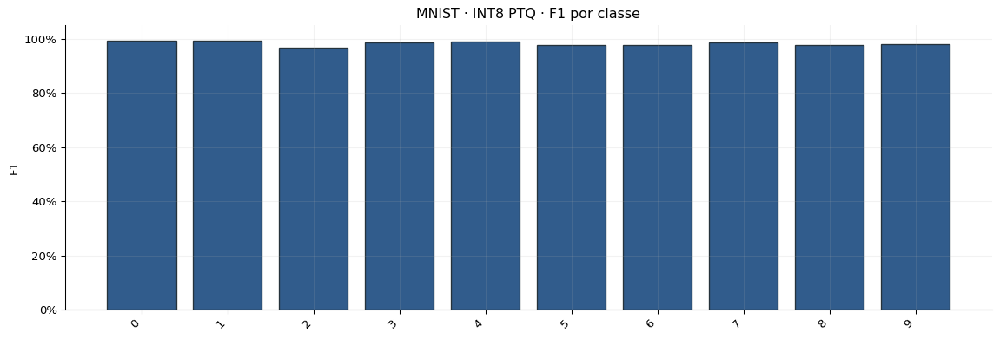

class_name,precision,recall,f1,support
0,0.9951,0.9903,0.9927,1035
1,0.9957,0.9898,0.9928,1181
2,0.9537,0.9828,0.9680,1048
3,0.9833,0.9925,0.9879,1071
4,0.9912,0.9883,0.9897,1023
5,0.9669,0.9873,0.9770,947
6,0.9920,0.9661,0.9789,1031
7,0.9827,0.9890,0.9859,1094
8,0.9930,0.9629,0.9777,1024
9,0.9800,0.9837,0.9818,1044


In [110]:
r = ptq.set_index('uid').loc['controlled-quantization-fast-mac-m4|ptq|mnist|int8_ptq']
base = main.loc[(main.stage=='quantization') & (main.dataset==r.dataset) & (main.condition=='fp32')].iloc[0]
display(Markdown(f"Accuracy {fmt(r.test_accuracy,percent=True)}, Macro-F1 {fmt(r.test_macro_f1,percent=True)}; diferença descritiva vs. FP32 {(r.test_macro_f1-base.test_macro_f1)*100:+.3f} p.p. Modelo {r.ptq_model_bytes/1024:.2f} KiB, latência mediana por batch {r.ptq_median_batch_latency_ms:.2f} ms e throughput {r.ptq_throughput_examples_per_second:.2f} exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação."))
cs = classes.loc[classes.uid.eq(r.name)].sort_values('class_label')
fig,ax=plt.subplots(figsize=(12,4),layout='constrained')
ax.bar(np.arange(len(cs)),cs.f1,color='#315C8C',edgecolor='#25323B')
ax.set_xticks(np.arange(len(cs)),cs.class_name,rotation=45,ha='right')
ax.set(title=LABELS[r.dataset]+' · INT8 PTQ · F1 por classe',ylabel='F1',ylim=(0,1.05))
ax.yaxis.set_major_formatter(PercentFormatter(1))
show(fig,'ptq_classes_'+r.dataset)
table(cs,['class_name','precision','recall','f1','support'])

### svhn · INT8 PTQ

Fonte: `outputs/controlled-quantization-fast-mac-m4/quantization/svhn/int8_ptq/svhn/runs/svhn__unit_interval__all_raw__seed-42/status.json`. Operação de pós-treinamento vinculada à campanha de augmentation 0,5.

Accuracy 90.98%, Macro-F1 90.47%; diferença descritiva vs. FP32 -0.478 p.p. Modelo 302.97 KiB, latência mediana por batch 637.88 ms e throughput 400.71 exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação.

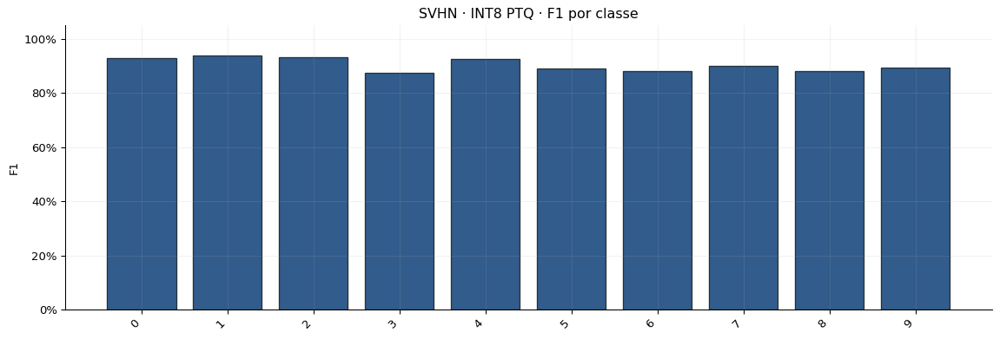

class_name,precision,recall,f1,support
0,0.9481,0.9094,0.9283,1004
1,0.9321,0.9459,0.9389,2844
2,0.9409,0.9213,0.9310,2210
3,0.8625,0.8858,0.8740,1707
4,0.9206,0.9299,0.9252,1497
5,0.8743,0.9108,0.8922,1390
6,0.8955,0.8684,0.8818,1155
7,0.8885,0.9142,0.9012,1142
8,0.9173,0.8489,0.8818,1006
9,0.8916,0.8945,0.8930,938


In [111]:
r = ptq.set_index('uid').loc['controlled-quantization-fast-mac-m4|ptq|svhn|int8_ptq']
base = main.loc[(main.stage=='quantization') & (main.dataset==r.dataset) & (main.condition=='fp32')].iloc[0]
display(Markdown(f"Accuracy {fmt(r.test_accuracy,percent=True)}, Macro-F1 {fmt(r.test_macro_f1,percent=True)}; diferença descritiva vs. FP32 {(r.test_macro_f1-base.test_macro_f1)*100:+.3f} p.p. Modelo {r.ptq_model_bytes/1024:.2f} KiB, latência mediana por batch {r.ptq_median_batch_latency_ms:.2f} ms e throughput {r.ptq_throughput_examples_per_second:.2f} exemplos/s. Não há medição de treino INT8 nem telemetria de treino nesta avaliação."))
cs = classes.loc[classes.uid.eq(r.name)].sort_values('class_label')
fig,ax=plt.subplots(figsize=(12,4),layout='constrained')
ax.bar(np.arange(len(cs)),cs.f1,color='#315C8C',edgecolor='#25323B')
ax.set_xticks(np.arange(len(cs)),cs.class_name,rotation=45,ha='right')
ax.set(title=LABELS[r.dataset]+' · INT8 PTQ · F1 por classe',ylabel='F1',ylim=(0,1.05))
ax.yaxis.set_major_formatter(PercentFormatter(1))
show(fig,'ptq_classes_'+r.dataset)
table(cs,['class_name','precision','recall','f1','support'])

## Apêndice: nove smoke tests Mac com augmentation 0,5

Estes testes de duas épocas usam amostras pequenas e verificam o funcionamento da infraestrutura. Seus resultados não entram nas comparações de qualidade ou nas 81 execuções principais. O custo e uso de hardware estão documentados porque também foram treinos executados no Mac.

In [112]:
table(smoke,['dataset','epochs_completed','test_samples','test_accuracy','test_macro_f1','training_seconds','gpu_mean_percent','process_rss_max_gib'])

dataset,epochs_completed,test_samples,test_accuracy,test_macro_f1,training_seconds,gpu_mean_percent,process_rss_max_gib
cifar10,2.0000,20,0.1500,0.0900,9.3733,40.5000,2.2317
cifar100_coarse,2.0000,40,0.0500,0.0417,11.8430,13.0000,2.2130
emnist_balanced,2.0000,94,0.0638,0.0264,19.4000,54.5000,2.1934
fashion_mnist,2.0000,20,0.4500,0.3600,9.1859,44.5000,1.9817
fer2013,2.0000,14,0.1429,0.0952,8.4407,41.0000,1.9532
gtsrb,2.0000,86,0.0349,0.0145,21.0374,52.6000,2.2554
kmnist,2.0000,20,0.2000,0.0800,9.1119,43.5000,1.9408
mnist,2.0000,20,0.3000,0.2008,9.7643,5.0000,2.0212
svhn,2.0000,20,0.1000,0.0786,9.2731,44.5000,2.2485


### Smoke · cifar10

Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/smoke/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/status.json`. Apenas validação da infraestrutura.

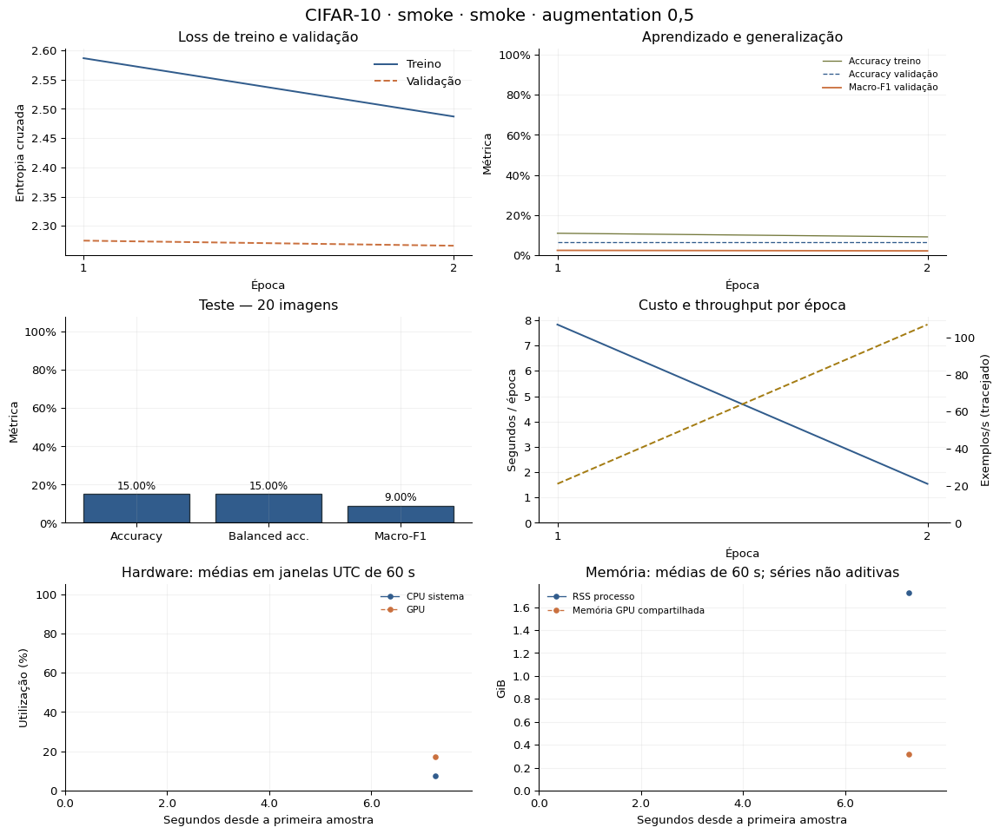

**Resultado:** accuracy 15.00%, balanced accuracy 15.00%, Macro-F1 9.00%, precisão macro 6.83%, recall macro 15.00%, AUC OVR 0.5306 e loss de teste 2.3029. **Custo:** 9.37 s pela soma das épocas; 35.21 exemplos/s, ponderando pelo tempo; avaliação final 0.95 s. **Curva:** melhor Macro-F1 de validação 2.35% na época 1; última época 2.11%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Hardware:** GPU média 40.50%, CPU do processo média 94.30%, RAM média 57.95%; pico de RSS 2.23 GiB e de memória GPU compartilhada 0.37 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** airplane, F1 0.00% e suporte 2 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [113]:
plot_run('controlled-augmentation2-mac-m4-aug05|smoke|cifar10|smoke')
explain_run('controlled-augmentation2-mac-m4-aug05|smoke|cifar10|smoke')

### Smoke · cifar100_coarse

Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/smoke/cifar100_coarse/runs/cifar100_coarse__unit_interval__all_raw__seed-42/status.json`. Apenas validação da infraestrutura.

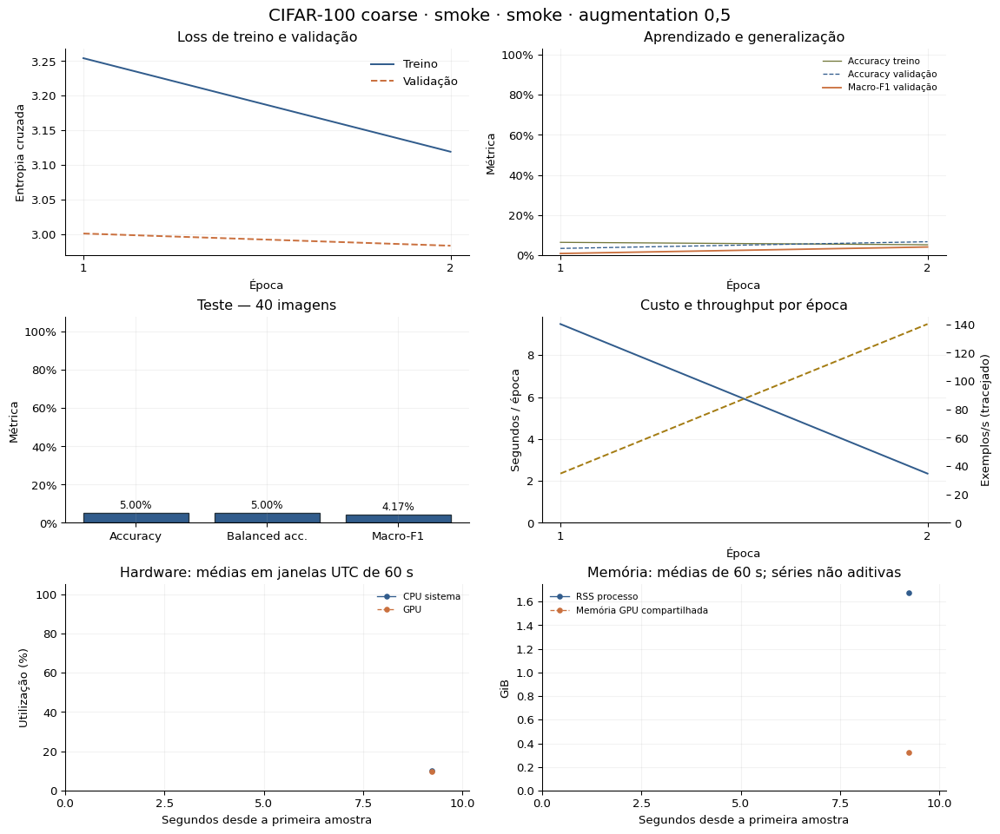

**Resultado:** accuracy 5.00%, balanced accuracy 5.00%, Macro-F1 4.17%, precisão macro 3.75%, recall macro 5.00%, AUC OVR 0.4803 e loss de teste 3.0049. **Custo:** 11.84 s pela soma das épocas; 55.73 exemplos/s, ponderando pelo tempo; avaliação final 1.45 s. **Curva:** melhor Macro-F1 de validação 4.04% na época 2; última época 4.04%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Hardware:** GPU média 13.00%, CPU do processo média 95.70%, RAM média 58.23%; pico de RSS 2.21 GiB e de memória GPU compartilhada 0.35 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** aquatic_mammals, F1 0.00% e suporte 2 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [114]:
plot_run('controlled-augmentation2-mac-m4-aug05|smoke|cifar100_coarse|smoke')
explain_run('controlled-augmentation2-mac-m4-aug05|smoke|cifar100_coarse|smoke')

### Smoke · emnist_balanced

Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/smoke/emnist_balanced/runs/emnist_balanced__unit_interval__all_raw__seed-42/status.json`. Apenas validação da infraestrutura.

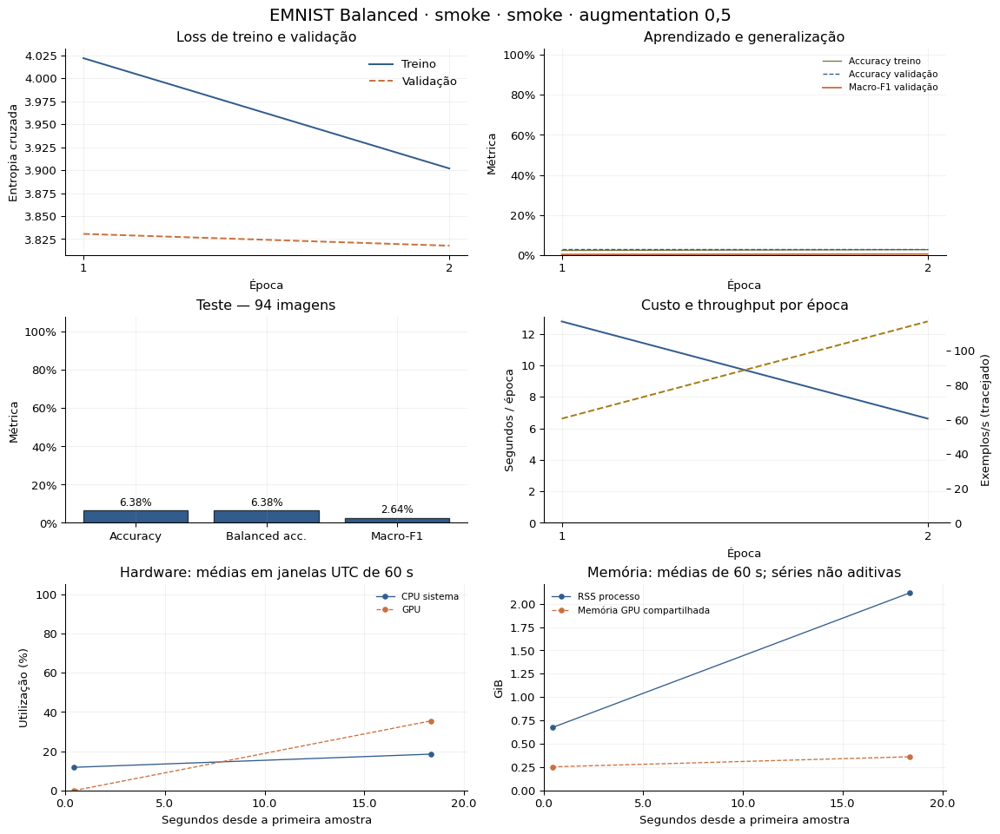

**Resultado:** accuracy 6.38%, balanced accuracy 6.38%, Macro-F1 2.64%, precisão macro 2.85%, recall macro 6.38%, AUC OVR 0.6840 e loss de teste 3.8102. **Custo:** 19.40 s pela soma das épocas; 79.90 exemplos/s, ponderando pelo tempo; avaliação final 1.59 s. **Curva:** melhor Macro-F1 de validação 0.52% na época 2; última época 0.52%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Hardware:** GPU média 54.50%, CPU do processo média 90.80%, RAM média 57.50%; pico de RSS 2.19 GiB e de memória GPU compartilhada 0.59 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 0, F1 0.00% e suporte 2 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [115]:
plot_run('controlled-augmentation2-mac-m4-aug05|smoke|emnist_balanced|smoke')
explain_run('controlled-augmentation2-mac-m4-aug05|smoke|emnist_balanced|smoke')

### Smoke · fashion_mnist

Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/smoke/fashion_mnist/runs/fashion_mnist__unit_interval__all_raw__seed-42/status.json`. Apenas validação da infraestrutura.

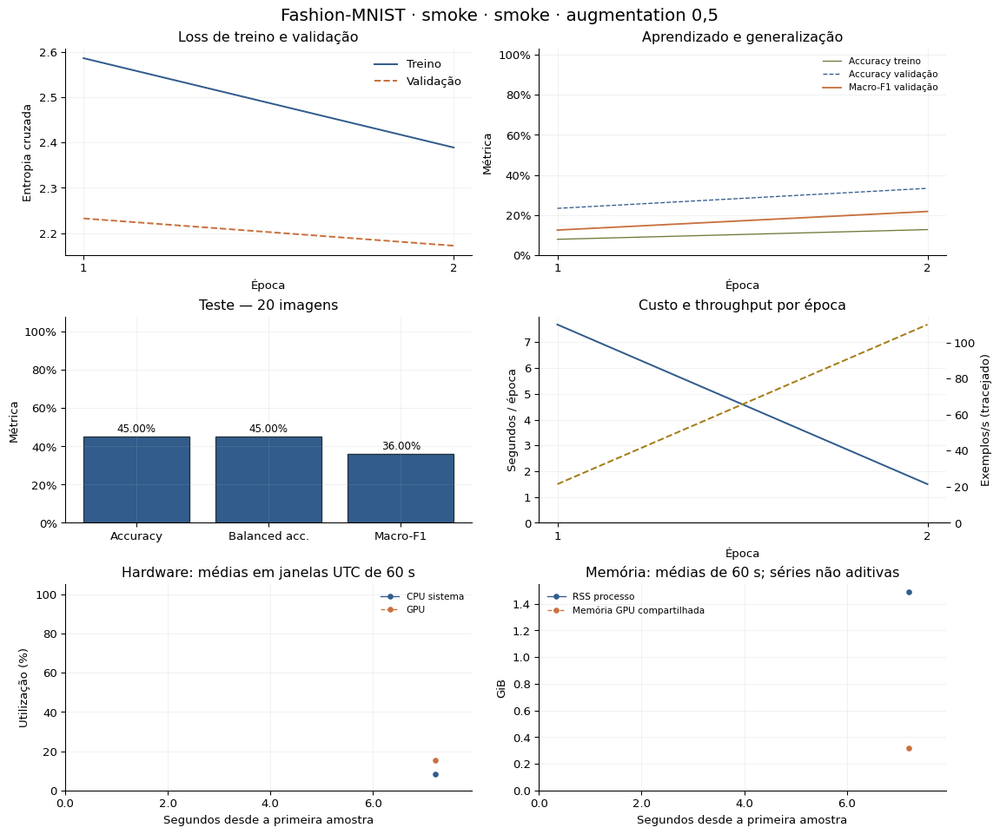

**Resultado:** accuracy 45.00%, balanced accuracy 45.00%, Macro-F1 36.00%, precisão macro 35.33%, recall macro 45.00%, AUC OVR 0.8139 e loss de teste 2.1565. **Custo:** 9.19 s pela soma das épocas; 35.92 exemplos/s, ponderando pelo tempo; avaliação final 0.95 s. **Curva:** melhor Macro-F1 de validação 21.79% na época 2; última época 21.79%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Hardware:** GPU média 44.50%, CPU do processo média 93.55%, RAM média 56.15%; pico de RSS 1.98 GiB e de memória GPU compartilhada 0.37 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 0, F1 0.00% e suporte 2 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [116]:
plot_run('controlled-augmentation2-mac-m4-aug05|smoke|fashion_mnist|smoke')
explain_run('controlled-augmentation2-mac-m4-aug05|smoke|fashion_mnist|smoke')

### Smoke · fer2013

Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/smoke/fer2013/runs/fer2013__unit_interval__all_raw__seed-42/status.json`. Apenas validação da infraestrutura.

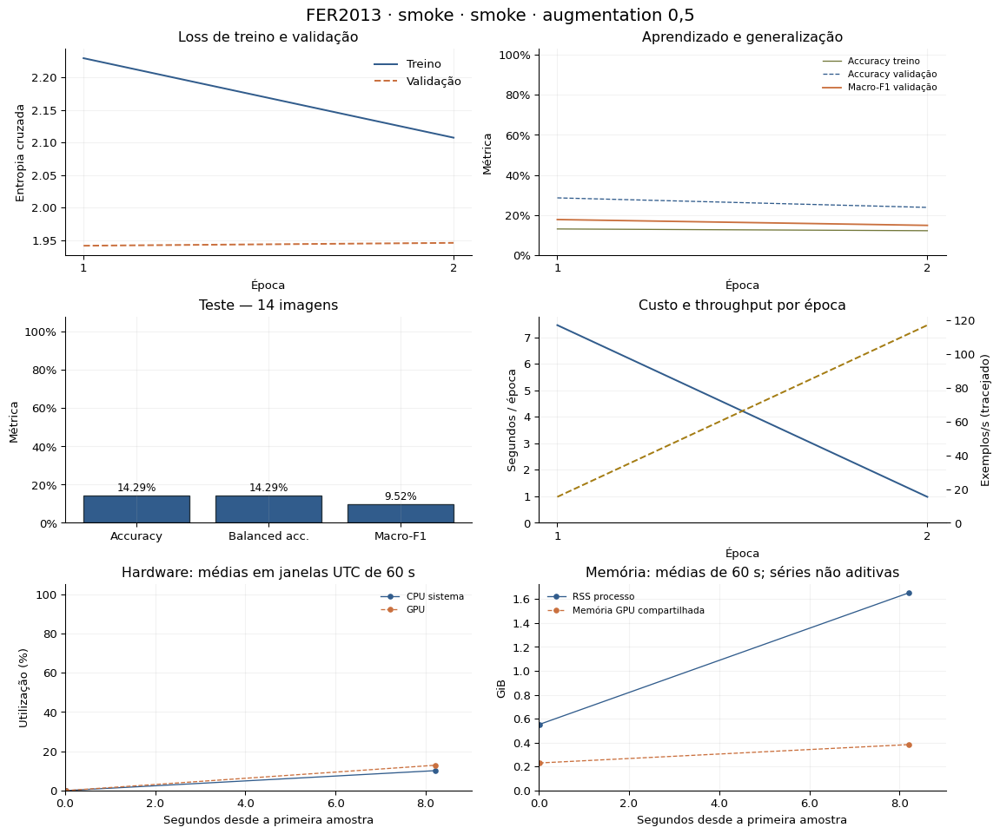

**Resultado:** accuracy 14.29%, balanced accuracy 14.29%, Macro-F1 9.52%, precisão macro 7.14%, recall macro 14.29%, AUC OVR 0.6012 e loss de teste 1.9442. **Custo:** 8.44 s pela soma das épocas; 27.25 exemplos/s, ponderando pelo tempo; avaliação final 0.96 s. **Curva:** melhor Macro-F1 de validação 17.75% na época 1; última época 14.84%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Hardware:** GPU média 41.00%, CPU do processo média 97.85%, RAM média 58.20%; pico de RSS 1.95 GiB e de memória GPU compartilhada 0.36 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** angry, F1 0.00% e suporte 2 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [117]:
plot_run('controlled-augmentation2-mac-m4-aug05|smoke|fer2013|smoke')
explain_run('controlled-augmentation2-mac-m4-aug05|smoke|fer2013|smoke')

### Smoke · gtsrb

Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/smoke/gtsrb/runs/gtsrb__unit_interval__all_raw__seed-42/status.json`. Apenas validação da infraestrutura.

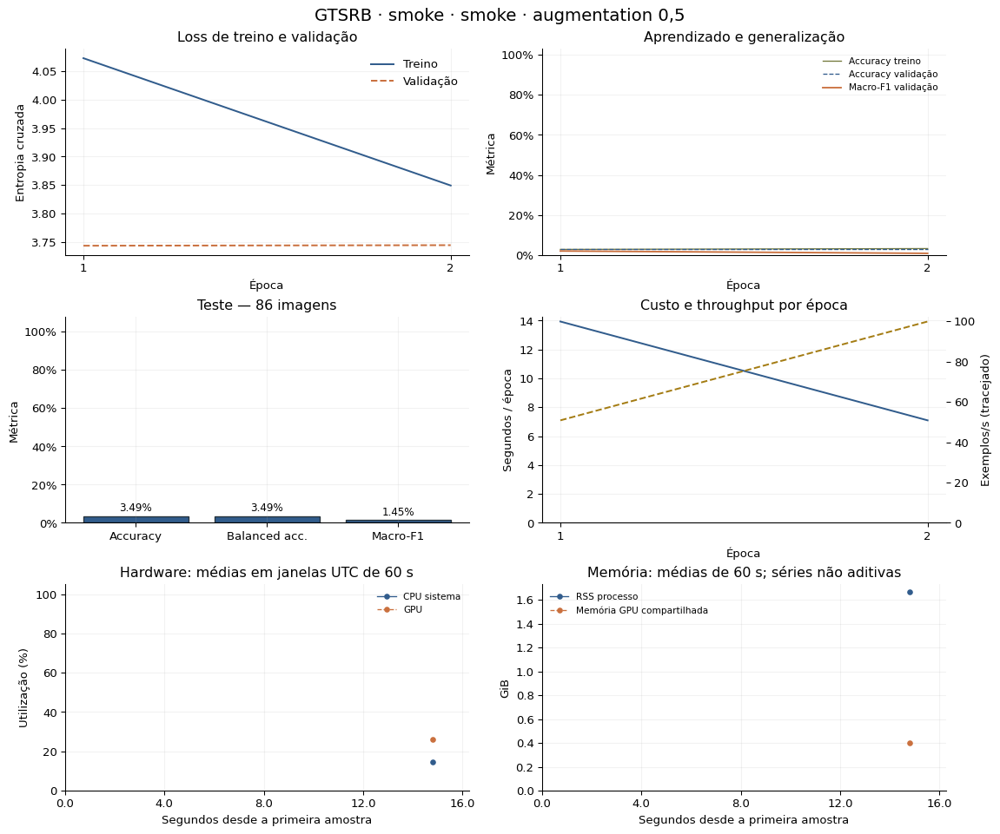

**Resultado:** accuracy 3.49%, balanced accuracy 3.49%, Macro-F1 1.45%, precisão macro 1.07%, recall macro 3.49%, AUC OVR 0.5612 e loss de teste 3.7557. **Custo:** 21.04 s pela soma das épocas; 67.40 exemplos/s, ponderando pelo tempo; avaliação final 1.81 s. **Curva:** melhor Macro-F1 de validação 2.04% na época 1; última época 0.87%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Hardware:** GPU média 52.60%, CPU do processo média 93.36%, RAM média 60.98%; pico de RSS 2.26 GiB e de memória GPU compartilhada 0.51 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 0, F1 0.00% e suporte 2 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [118]:
plot_run('controlled-augmentation2-mac-m4-aug05|smoke|gtsrb|smoke')
explain_run('controlled-augmentation2-mac-m4-aug05|smoke|gtsrb|smoke')

### Smoke · kmnist

Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/smoke/kmnist/runs/kmnist__unit_interval__all_raw__seed-42/status.json`. Apenas validação da infraestrutura.

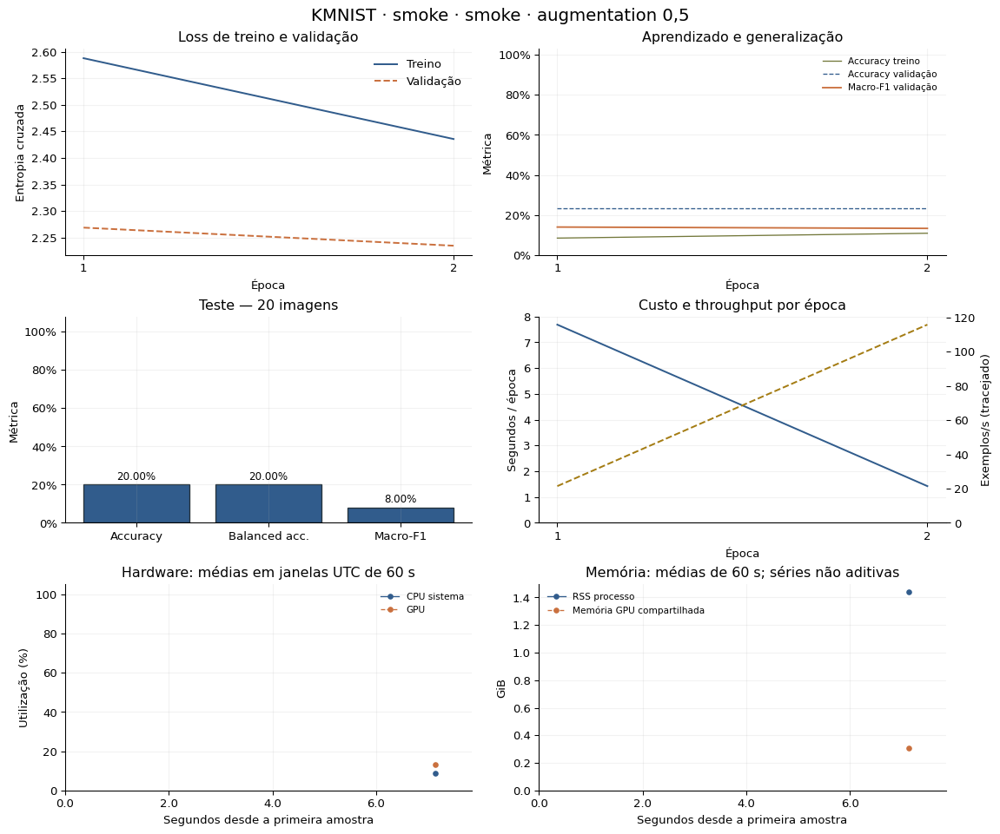

**Resultado:** accuracy 20.00%, balanced accuracy 20.00%, Macro-F1 8.00%, precisão macro 5.00%, recall macro 20.00%, AUC OVR 0.5278 e loss de teste 2.3045. **Custo:** 9.11 s pela soma das épocas; 36.22 exemplos/s, ponderando pelo tempo; avaliação final 0.97 s. **Curva:** melhor Macro-F1 de validação 14.00% na época 1; última época 13.33%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Hardware:** GPU média 43.50%, CPU do processo média 96.45%, RAM média 56.00%; pico de RSS 1.94 GiB e de memória GPU compartilhada 0.35 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 0, F1 0.00% e suporte 2 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [119]:
plot_run('controlled-augmentation2-mac-m4-aug05|smoke|kmnist|smoke')
explain_run('controlled-augmentation2-mac-m4-aug05|smoke|kmnist|smoke')

### Smoke · mnist

Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/smoke/mnist/runs/mnist__unit_interval__all_raw__seed-42/status.json`. Apenas validação da infraestrutura.

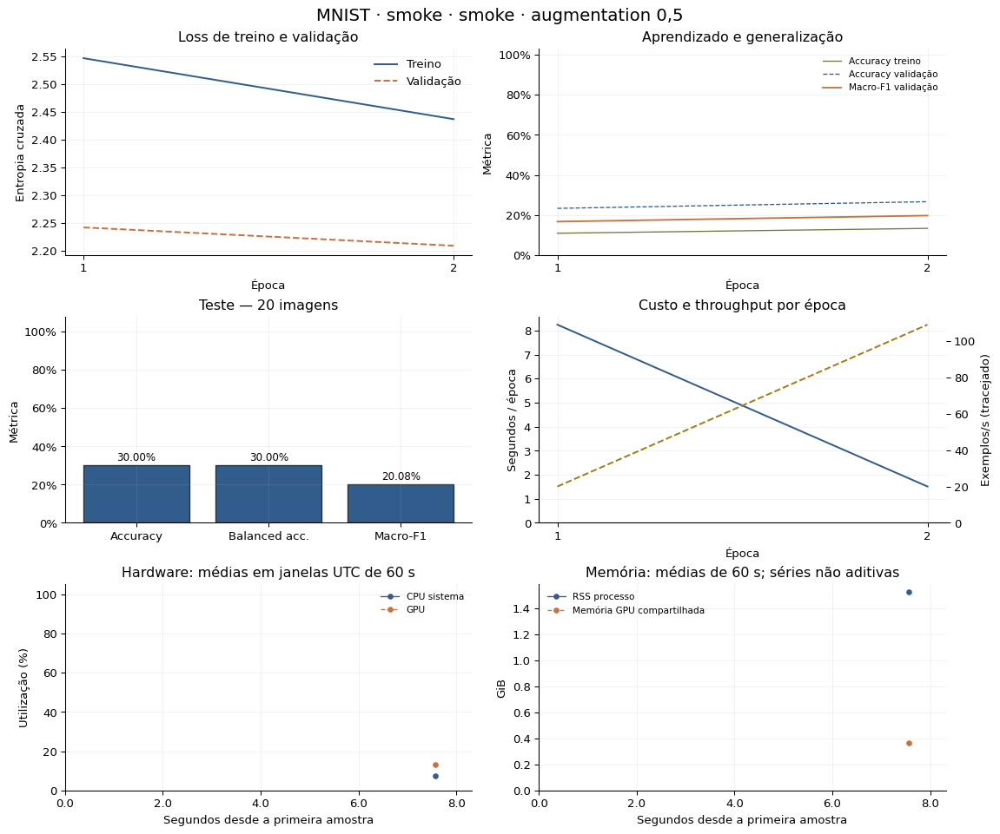

**Resultado:** accuracy 30.00%, balanced accuracy 30.00%, Macro-F1 20.08%, precisão macro 16.82%, recall macro 30.00%, AUC OVR 0.8083 e loss de teste 2.1937. **Custo:** 9.76 s pela soma das épocas; 33.80 exemplos/s, ponderando pelo tempo; avaliação final 1.01 s. **Curva:** melhor Macro-F1 de validação 19.73% na época 2; última época 19.73%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Hardware:** GPU média 5.00%, CPU do processo média 87.95%, RAM média 55.85%; pico de RSS 2.02 GiB e de memória GPU compartilhada 0.36 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 0, F1 0.00% e suporte 2 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [120]:
plot_run('controlled-augmentation2-mac-m4-aug05|smoke|mnist|smoke')
explain_run('controlled-augmentation2-mac-m4-aug05|smoke|mnist|smoke')

### Smoke · svhn

Fonte: `outputs/controlled-augmentation2-mac-m4-aug05/smoke/svhn/runs/svhn__unit_interval__all_raw__seed-42/status.json`. Apenas validação da infraestrutura.

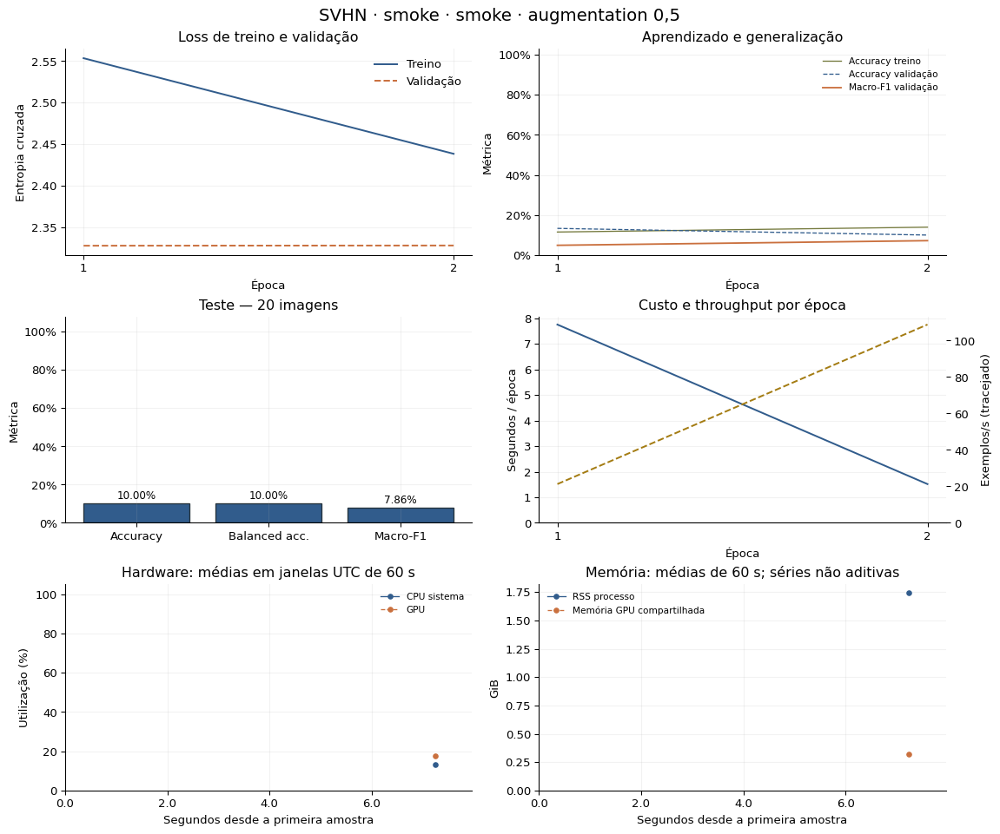

**Resultado:** accuracy 10.00%, balanced accuracy 10.00%, Macro-F1 7.86%, precisão macro 7.00%, recall macro 10.00%, AUC OVR 0.6111 e loss de teste 2.2831. **Custo:** 9.27 s pela soma das épocas; 35.59 exemplos/s, ponderando pelo tempo; avaliação final 0.97 s. **Curva:** melhor Macro-F1 de validação 7.21% na época 2; última época 7.21%. O resultado de teste refere-se ao checkpoint selecionado por validação, não necessariamente à última época. **Hardware:** GPU média 44.50%, CPU do processo média 91.75%, RAM média 58.85%; pico de RSS 2.25 GiB e de memória GPU compartilhada 0.37 GiB. **Cobertura da telemetria:** Todas as amostras periódicas preservadas no CSV (ciclo inteiro, todas as sessões disponíveis). 

**Classe com menor F1:** 0, F1 0.00% e suporte 2 imagens. Métricas de todas as classes permanecem em `per_class_metrics.csv`.

In [121]:
plot_run('controlled-augmentation2-mac-m4-aug05|smoke|svhn|smoke')
explain_run('controlled-augmentation2-mac-m4-aug05|smoke|svhn|smoke')

## Conclusões, limitações e reprodução

O catálogo cobre todos os resultados preservados das campanhas Mac com augmentation 0,5, incluindo custo reconciliado e hardware por treino. Vencedores por teste descrevem estas execuções e não substituem uma seleção prospectiva por validação. Batch, ativação e precisão têm efeitos diferentes em cada dataset; não há um ranking universal entre bases.

As principais limitações são uma seed por condição, ausência de telemetria bruta dos 45 treinos companheiros, escopos de amostragem diferentes, resumos de tempo inconsistentes em retomadas e detalhes incompletos do runtime PTQ. Não é possível concluir eficiência energética nem estimar variabilidade estatística a partir destes dados.

**Arquivos para reproduzir:** este notebook e a pasta `analysis_reports/mac_training_complete_2026-09-30/evidence/`. O notebook não usa checkpoints ou datasets e não inicia treinamento. Para regenerar o pacote a partir das fontes locais: `python scripts/build_mac_training_complete_report.py`; isso exige os outputs originais de batch e os snapshots existentes. Para apenas reexecutar: `python -m jupyter nbconvert --execute --to notebook --inplace notebooks/mac_all_training_complete_report.ipynb`, em um ambiente com as dependências abaixo. Novas versões das bibliotecas podem alterar o desenho sem alterar os dados.

Dependências usadas e hashes SHA-256 dos arquivos-fonte são registrados abaixo. As saídas do notebook já estão preenchidas, para leitura sem execução.

In [122]:
print(f'Figuras renderizadas: {figure_count}')
print('Dependências: Python',platform.python_version(),'| pandas',pd.__version__,'| NumPy',np.__version__,'| Matplotlib',__import__('matplotlib').__version__)
print('Snapshot:',manifest['scope'])
print('Validação: 81 históricos completos; métricas reconciliadas por classe; nenhuma identidade/época duplicada.')
sources.to_csv(FIGURES.parent / 'source_index.csv',index=False)
table(sources.head(12))
display(Markdown('O catálogo completo de arquivos e hashes está em `evidence/sources.json` e `source_index.csv`. Os campos de origem de cada run estão em `evidence/runs.csv`; todos os históricos e classes ficam nos CSVs associados.'))

Figuras renderizadas: 110
Dependências: Python 3.10.21 | pandas 2.3.3 | NumPy 2.2.6 | Matplotlib 3.10.9
Snapshot: Apenas Mac com extra_fraction=0.5, nas saídas e snapshots do projeto. INT8 PTQ vinculado à campanha; smoke em apêndice.
Validação: 81 históricos completos; métricas reconciliadas por classe; nenhuma identidade/época duplicada.


path,bytes,sha256
outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/status.json,270,4fefd12b573407abbd575b20afa2837a552b22359ae423515e3085a7061ff3be
outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/manifest.json,18814,f2d069a2323ae692f61890ee0073904ef85cfac46ad373409a1e5f5ddccb75df
outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/telemetry/environment.json,1782,24ac02a969719a593b8f2bd0f7a34305028a56857715da42a86ba80659e939ed
outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/checkpoints/epoch_metrics.csv,80466,76ff0cf7f2140b60c8288124931bbb631811bda423a2734fffcf5204a88fb90f
outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/telemetry/samples.csv,9173219,35f68cafea3225dc2e7973a4d64edfe2fbc140f8abf3189cd29ef0cea779603a
outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/artifacts/test_metrics.json,3511,c11ee14079d370d8efaed24acb42560d6a2cf4d4f5457c9e2b74c5af8ecd44ed
outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/logs/training_summary.json,767,bbfe77c2cd4e8afd815b3357eef83f31e2e3b4ef6b8c8870a2eaf0a3b44073cf
outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/cifar10/runs/cifar10__unit_interval__all_raw__seed-42/telemetry/summary.json,5255,a5d66a7891a7fe619b2a615c62537eff8bf93428bb6b13a1e9ee2535f6026017
outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/cifar100_coarse/runs/cifar100_coarse__unit_interval__all_raw__seed-42/status.json,278,a43290772010c88c61e5595c68b6d6661e348573e5cabe3469ff3133c7c9feb7
outputs/controlled-augmentation2-mac-m4-aug05/batch/batch-032/cifar100_coarse/runs/cifar100_coarse__unit_interval__all_raw__seed-42/manifest.json,27341,91c1159a31fbe5e4ac1f08a40eb66d642b028f0c6d60107294052b02fe75d429


O catálogo completo de arquivos e hashes está em `evidence/sources.json` e `source_index.csv`. Os campos de origem de cada run estão em `evidence/runs.csv`; todos os históricos e classes ficam nos CSVs associados.